<img src = "https://drive.google.com/uc?export=view&id=1ljiY7gV0TKs3nnTMPA5UBdED8KGzzZnX" alt = "Encabezado MLDS" width = "100%">  </img>

# **Proyecto aplicado — Entrega final**
---

**Análisis del desenlace neurológico tras paro cardíaco**
Conjunto de datos **I-CARE v2.1** (PhysioNet) · metadatos clínicos de 607 pacientes en coma

Maestría en Ingeniería de Sistemas y Computación · Universidad Nacional de Colombia


## **0. Integrantes del equipo de trabajo**
---

1. **Alejandra Jaramillo Mejía** 
2. **Santiago Chaparro Suzunaga** 
3. **Brayan Sebastián Yepes García** 

**Video explicativo:** https://youtu.be/p1JJlJUBVAw *(enlace de YouTube, máximo 5 minutos)*


## **Guía de lectura**
---

Este documento reúne las cuatro fases del proyecto aplicado en un único notebook,
siguiendo la metodología CRISP-DM. Cada sección corresponde a una fase y conserva
tanto las decisiones tomadas como su justificación.

| Sección | Fase CRISP-DM | Contenido |
|---|---|---|
| 1 | Entendimiento del negocio | Contexto clínico, objetivos, alcance y plan de trabajo |
| 2 | Entendimiento de los datos | Adquisición, exploración descriptiva y evaluación de calidad |
| 3 | Preparación de los datos | Limpieza, tratamiento de anomalías y construcción del conjunto preparado |
| 4 | Análisis | Correlaciones, regresiones y estadística inferencial |
| 5 | Visualizaciones | Figuras estáticas e interactivas |
| 6 | Interpretación de resultados | Respuesta a las preguntas del análisis |
| 7 | Conclusiones y recomendaciones | Cumplimiento de objetivos y trabajo futuro |

**Cómo ejecutarlo.** El notebook está diseñado para correr de principio a fin
(*Kernel → Restart and Run All*). La celda de adquisición verifica primero si
existe una copia local de los datos: si la encuentra, la lee; si no, la descarga
de PhysioNet. La primera ejecución puede tardar varios minutos; las siguientes,
segundos.

**Alcance.** El análisis se restringe a los **metadatos clínicos** de los 607
pacientes. El apartado 1.2 detalla esta delimitación.


In [1]:
# Ejecutar solo si alguna de estas librerías no está instalada en el entorno.
# %pip install seaborn plotly statsmodels

In [2]:
# ---------------------------------------------------------------------------
# Entorno de trabajo. Todas las dependencias del notebook se declaran aquí.
# ---------------------------------------------------------------------------
import sys, os, re, warnings, itertools
from pathlib import Path

import numpy as np
import pandas as pd

import requests
import urllib3
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from scipy import stats
from scipy.stats import spearmanr, pearsonr

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportion_confint

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

print("Python     :", sys.version.split()[0])
print("pandas     :", pd.__version__)
print("numpy      :", np.__version__)
print("statsmodels:", sm.__version__)
print("plotly     :", __import__("plotly").__version__)

KeyboardInterrupt: 

# **1. Entendimiento del negocio**
---

Esta sección corresponde a la primera fase de CRISP-DM. Su propósito es
establecer el problema que motiva el análisis, los objetivos que se persiguen,
los límites del proyecto y el plan de trabajo con el que se desarrolla.


## Contexto de la situación

**Contexto clínico y epidemiológico**

Para comprender la relevancia de este proyecto, es necesario considerar qué ocurre después de que un paciente sobrevive a un paro cardíaco y logra el retorno de la circulación espontánea (ROSC). Este evento puede ocurrir fuera del hospital (out-of-hospital cardiac arrest, OHCA) o dentro de él (in-hospital cardiac arrest, IHCA), y en ambos casos provoca una interrupción del flujo sanguíneo que, como consecuencia, puede producir una lesión cerebral de diferente gravedad. Sin embargo, recuperar la circulación espontánea no implica necesariamente una recuperación neurológica favorable: de acuerdo con la información presentada en I-CARE, la mayoría de los pacientes que sobreviven hasta el ingreso a una unidad de cuidados intensivos permanecen en estado de coma, y la lesión cerebral grave constituye uno de los principales determinantes de un desenlace desfavorable después de la reanimación.

**Fisiopatologia**

Durante el paro, la ausencia de flujo sanguíneo priva al cerebro de oxígeno y glucosa, y cuando la circulación se restablece, en lugar de simplemente "reanudarse" la normalidad, se dispara una cascada de daños secundarios,(disfunción mitocondrial, muerte neuronal). En el entorno clinico se conoce como lesión cerebral hipóxico-isquémica (HIBI). Esta lesión es la que termina explicando la mayoría de las muertes y discapacidades severas en estos pacientes.

**El manejo de temperatura dirigido (TTM)**

Una de las intervenciones estándar es el manejo de temperatura dirigido (TTM), cuyo objetivo es reducir el metabolismo cerebral y así atenuar el daño secundario a la reperfusión. Sin embargo, junto con la sedación que normalmente lo acompaña, hace que el examen neurológico clásico (reflejos pupilares, respuesta motora, etc.) pierda fiabilidad durante los primeros días. Esto obliga a buscar informacion adicional que no dependan unicamente de la respuesta motora del paciente.

**Pronóstico neurológico multimodal**

Según las guías internacionales vigentes (ERC-ESICM, 2021), el pronóstico neurológico debe establecerse de manera multimodal, integrando el examen clínico, la neuroimagen y los biomarcadores. La práctica clínica actual reconoce ya la necesidad de integrar múltiples fuentes de información, por lo que resulta pertinente un análisis de datos que combine sistemáticamente variables clínicas y electroencefalográficas (EEG).

**El papel específico del EEG**

Debido a estas complicaciones, una herramienta como el EEG resulta de gran importancia, ya que registra la actividad eléctrica cerebral momento a momento sin necesidad de que el paciente reaccione a ningún estímulo. La literatura agrupa los trazados en dos familias con implicaciones pronósticas: los patrones "malignos", como una señal plana o de voltaje muy bajo y la supresión de ráfagas (burst-suppression), y los patrones "benignos", caracterizados por una actividad continua y reactiva ante estímulos externos, que suelen asociarse con una recuperación favorable.


**CPC como medida de desenlace**

Formalmente, se trata de una escala ordinal de cinco niveles, que va desde 1 (función cerebral conservada) hasta 5 (muerte). En la práctica, sin embargo, las distancias entre esos niveles no son clínicamente equivalentes, por lo que estudios como el I-CARE suelen colapsarla en dos grandes grupos: Good (CPC 1–2) y Poor (CPC 3–5).

## Importancia del análisis de datos

El paro cardíaco constituye una situación clínica de alta complejidad, en la que la recuperación de la circulación espontánea no garantiza una recuperación neurológica favorable. Los pacientes que sobreviven al evento pueden permanecer en estado de coma y presentar diferentes grados de compromiso neurológico, por lo que la evaluación del desenlace neurológico es fundamental para caracterizar el grado de recuperación alcanzado por el paciente y comprender su evolución posterior al paro cardíaco.

El desenlace neurológico no se presenta de manera aislada, sino que se encuentra acompañado de diferentes características clínicas registradas durante la atención de los pacientes. I-CARE incluye variables como la edad, la institución hospitalaria, el lugar donde ocurrió el paro, el tipo de ritmo cardíaco, el tiempo transcurrido hasta el retorno de la circulación espontánea (ROSC) y el manejo dirigido de la temperatura (TTM) por lo que la presencia simultánea de estas variables plantea la necesidad de analizar de manera sistemática sus posibles relaciones con el desenlace neurológico.



Por lo anterior, surge la necesidad de desarrollar un análisis de datos que permita caracterizar los pacientes, explorar la distribución de sus características clínicas, estudiar estadísticamente las posibles asociaciones entre dichas características y el desenlace neurológico, y representar los resultados de manera clara mediante visualizaciones. El propósito es generar una caracterización estadística y exploratoria de los patrones presentes en los datos de I-CARE.



## Beneficiarios

Los principales beneficiarios del proyecto se encuentran en el dominio de la medicina, específicamente en las áreas de medicina intensiva, neurología y neurofisiología, relacionadas con la valoración del desenlace neurológico de pacientes después de un paro cardíaco. De forma más amplia, el público al que en último término apunta este análisis son los pacientes que atraviesan esta complicación y sus familiares.

- **Primarios:** equipos de medicina intensiva, neurología y neurofisiología (intensivistas, neurólogos, neurofisiólogos) encargados de la valoración pronóstica en las primeras horas post-paro, quienes podrán utilizar los resultados del análisis como un insumo exploratorio para comprender las asociaciones estadísticas entre las características clínicas de los pacientes y su desenlace neurológico, medido mediante la escala CPC.
- **Secundarios:** pacientes comatosos post-paro cardíaco y sus familiares, quienes en la práctica clínica reciben la información pronóstica que orienta decisiones tan sensibles como continuar o limitar el esfuerzo terapéutico.
- **Académicos:** investigadores, docentes y estudiantes interesados en el análisis estadístico de datos clínicos, quienes podrán apoyarse en las visualizaciones y resultados obtenidos para explorar patrones, comparar grupos de pacientes y formular nuevas preguntas de investigación relacionadas con el desenlace neurológico posterior a un paro cardíaco.

De manera indirecta, el proyecto puede contribuir al conocimiento clínico y científico sobre el pronóstico neurológico post-paro cardíaco. Sus resultados corresponden a un ejercicio exploratorio y académico de análisis de datos, y por tanto no implican diagnóstico, tratamiento ni toma de decisiones clínicas directas.

## Principales desafíos que motivan el proyecto

A partir de la situación descrita, los principales desafíos que justifican la realización del proyecto de análisis de datos son:

1. Información clínica heterogénea

I-CARE integra variables de diferentes tipos y características: variables demográficas, clínicas, temporales y categóricas, además de registros fisiológicos como EEG y ECG. Esta heterogeneidad requiere procesos de limpieza, organización, transformación y caracterización de los datos antes de realizar los análisis estadísticos.

2. Identificación de asociaciones relevantes

Uno de los principales desafíos consiste en determinar qué características clínicas presentan asociaciones estadísticamente relevantes con el desenlace neurológico. La observación de diferencias entre grupos no es suficiente para determinar si existe evidencia estadística de una asociación. Por ello, es necesario complementar el análisis exploratorio con técnicas de estadística inferencial y, cuando sea pertinente, modelado estadístico.

3. Naturaleza del desenlace neurológico

El desenlace se encuentra representado mediante una variable ordinal, la escala CPC, que contempla cinco niveles diferentes de función neurológica. Esto requiere seleccionar métodos estadísticos coherentes con la naturaleza de la variable y establecer, cuando sea necesario, formas adecuadas de agrupación para el análisis.

4. Variabilidad entre instituciones

Los datos provienen de diferentes instituciones, lo que puede generar diferencias en la distribución de las características clínicas y en la información registrada. Por ello, las comparaciones entre instituciones deben realizarse cuidadosamente, evitando interpretar directamente una diferencia estadística como evidencia de una causa o de una superioridad institucional.

5. Volumen de información fisiológica

La incorporación de registros fisiológicos representa un desafío adicional debido a su volumen y complejidad. I-CARE contiene más de 32.712 horas de registros de pacientes, incluyendo EEG y ECG. Por las restricciones de tiempo, almacenamiento y capacidad computacional del proyecto, el análisis principal se concentrará en las variables clínicas, mientras que el EEG será abordado de manera complementaria sobre una muestra reducida.



## Objetivo general

Los pacientes que sobreviven a un paro cardíaco y permanecen en coma pueden presentar desenlaces neurológicos muy diferentes. Aunque el conjunto de datos I-CARE registra diversas características clínicas relacionadas con el evento de paro y la atención posterior, es necesario caracterizar estadísticamente cómo variables como la edad, el lugar del paro, el ritmo inicial, el tiempo hasta ROSC, la aplicación de TTM y el hospital se relacionan con el desenlace neurológico medido mediante CPC.

Por lo tanto, se propone realizar un análisis exploratorio y estadístico que permita identificar diferencias, asociaciones y patrones entre estas variables clínicas y el desenlace neurológico, utilizando estadística descriptiva, estadística inferencial, modelado estadístico y técnicas de visualización de datos.

El flujo de trabajo comprenderá la depuración y preparación del conjunto de datos, análisis descriptivo y exploratorio, evaluación de asociaciones entre las variables clínicas y el desenlace CPC mediante técnicas de estadística descriptiva, estadistica inferencial y construcción de modelos estadísticos exploratorios. Adicionalmente, los resultados serán comunicados mediante gráficos estáticos e interactivos que permitan identificar patrones, diferencias entre grupos y posibles variables asociadas al desenlace neurológico.

De manera complementaria, y sobre una muestra reducida de pacientes, se explorará la disponibilidad y estructura de las señales de EEG (electroencefalografía) presentes en el conjunto de datos, utilizando herramientas de Python para la inspección y caracterización básica de las señales.


## Objetivos específicos

1. Preparar y caracterizar el conjunto de datos clínicos I-CARE v2.1 mediante técnicas de limpieza, transformación y análisis exploratorio utilizando Python, NumPy y Pandas.

2. Caracterizar estadísticamente el desenlace neurológico de los pacientes mediante la escala CPC y analizar su distribución según las principales características clínicas registradas.

3. Evaluar, mediante estadística inferencial, la asociación entre edad, hospital, ubicación del paro, ritmo desfibrilable, TTM y tiempo hasta ROSC con el desenlace neurológico.

4. Aplicar técnicas de modelado estadístico para analizar conjuntamente la relación entre las variables clínicas y el desenlace neurológico.

5. Desarrollar visualizaciones estáticas e interactivas que permitan comunicar los principales resultados, patrones y asociaciones encontrados en el análisis.

6. Explorar de forma complementaria la disponibilidad y características básicas de las señales EEG en una muestra reducida de pacientes.


## Limites y fronteras del proyecto


El presente proyecto delimita su alcance al uso del conjunto de entrenamiento público de la base de datos I-CARE v2.1, disponible en PhysioNet, compuesto por 607 pacientes provenientes de siete instituciones hospitalarias. Dentro de las fronteras del proyecto se contempla el análisis de la totalidad de los registros clínicos disponibles para dichos pacientes, así como el estudio de las señales de electroencefalografía (EEG) correspondientes a una muestra representativa de los mismos, seleccionada con el fin de garantizar la viabilidad técnica y computacional del proyecto dentro del tiempo disponible.


Se excluyen explícitamente del alcance del proyecto:                        



*  Se decide trabajar con una muestra de pacientes para el análisis de EEG, en lugar de la totalidad del conjunto ya que las señales de EEG de cada paciente corresponden a registros continuos de monitoreo que pueden extenderse hasta 72 horas, con un peso aproximado de 2 a 3 GB por paciente; considerando los 607 pacientes disponibles, el volumen total de la base de datos asciende a cerca de 1.5 terabytes y esta magnitud excede tanto la capacidad de almacenamiento y procesamiento de equipos personales.


  *   El proyecto no contempla el desarrollo de un sistema en producción ni la generación de un modelo de Machine Learning.

### Delimitación del alcance de esta entrega

El conjunto I-CARE v2.1 es multimodal: además de los metadatos clínicos incluye
más de 32 000 horas de registro electroencefalográfico y electrocardiográfico
continuo, distribuidas en 80 809 segmentos. El presente documento **restringe su
alcance a los metadatos clínicos** de los 607 pacientes, por tres razones.

La primera es de pertinencia metodológica: las nueve variables clínicas permiten
responder la pregunta rectora del proyecto con las técnicas de estadística
descriptiva, inferencial y de modelado que constituyen el objeto del curso.

La segunda es de orden analítico. Las variables clínicas de ingreso establecen la
**línea base** contra la cual debe medirse cualquier aportación futura del
análisis de señales. Sin esa referencia cuantificada, no es posible determinar si
un modelo basado en EEG aporta información nueva o simplemente reproduce lo que
las variables clínicas ya explican.

La tercera es práctica: el volumen de las señales exige una infraestructura de
descarga, almacenamiento y procesamiento cuya complejidad desbordaría el alcance
de esta entrega y desplazaría el foco del análisis estadístico hacia el
procesamiento de señales.

En consecuencia, este notebook documenta los objetivos específicos 1 a 5. El
objetivo 6, relativo a la exploración complementaria de las señales EEG, se
aborda en una línea de trabajo independiente y queda señalado como trabajo futuro
en la sección 7.


## Uso del producto por parte del beneficiario

El beneficiario utilizará el producto del proyecto como una herramienta de consulta y exploración estadística sobre la información clínica contenida en el conjunto de datos I-CARE v2.1. Ya que a través de los resultados del análisis y de las visualizaciones desarrolladas, se podrá conocer la distribución de las principales características clínicas de los pacientes y explorar su relación con el desenlace neurológico, medido mediante la escala CPC. Ademas, el producto permitirá comparar grupos de pacientes e identificar diferencias y patrones en variables clínicas como la edad, el tipo de paro, el ritmo desfibrilable, el TTM, el tiempo hasta ROSC y el hospital.


El producto tendrá un carácter académico y exploratorio y podrá servir como insumo para formular nuevas preguntas de investigación o realizar análisis posteriores.


## Preguntas que orientan la comprensión de los datos

La etapa de Data Understanding se organiza alrededor de las siguientes preguntas:

1. **¿Cuál es la estructura, granularidad y procedencia de los datos disponibles en I-CARE?**

2. **¿Cuáles son las características clínicas y demográficas de la población estudiada?**

3. **¿Cómo se distribuyen los desenlaces neurológicos y cómo varían descriptivamente entre los diferentes centros hospitalarios?**

4. **¿Qué problemas de calidad, completitud y heterogeneidad deben considerarse antes de preparar los datos?**

Estas preguntas permiten que las herramientas computacionales y estadísticas utilizadas posteriormente respondan a objetivos analíticos concretos, en lugar de limitar el análisis a la aplicación aislada de operaciones sobre los datos.

---


## Metodología de trabajo: CRISP-DM

Para el desarrollo del proyecto se adopta como marco metodológico **CRISP-DM (Cross-Industry Standard Process for Data Mining)**, con el propósito de estructurar de manera sistemática, reproducible y escalable el proceso de análisis de los datos. Esta metodología organiza el ciclo de vida de un proyecto de datos en seis etapas: **comprensión del problema, comprensión de los datos, preparación de los datos, modelado, evaluación y despliegue**. Estas etapas no constituyen una secuencia estrictamente lineal; por el contrario, CRISP-DM propone un proceso **iterativo**, en el cual los resultados obtenidos en una fase pueden requerir regresar a etapas anteriores para modificar decisiones, incorporar nuevas fuentes de información o mejorar el procesamiento realizado.

En este proyecto, la adopción de CRISP-DM resulta particularmente relevante debido al **volumen, heterogeneidad y naturaleza multimodal** del conjunto de datos I-CARE. La información disponible combina metadatos clínicos y demográficos con señales fisiológicas de alta dimensionalidad, principalmente EEG. Por esta razón, se plantea una estrategia incremental en la que inicialmente se estudia la estructura general del conjunto de datos y los metadatos de los pacientes, para posteriormente incorporar de manera selectiva las señales fisiológicas requeridas por el análisis.

### Etapas de CRISP-DM aplicadas al proyecto

| Fase                            | Aplicación en el proyecto I-CARE                                                                                                                                                                  | Estado           |
| ------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------- |
| **1. Comprensión del problema** | Definir las preguntas de análisis relacionadas con las características clínicas, demográficas y fisiológicas de pacientes posteriores a paro cardíaco y su relación con el desenlace neurológico. | En desarrollo    |
| **2. Comprensión de los datos** | Identificar las fuentes, estudiar la estructura de I-CARE, explorar pacientes, hospitales, variables clínicas, outcomes y registros EEG disponibles.                                              | **Etapa actual** |
| **3. Preparación de los datos** | Limpieza, tratamiento de valores faltantes, conversión de tipos, selección de pacientes, procesamiento y segmentación de señales EEG.                                                             | Siguiente etapa  |
| **4. Modelado**                 | Construcción y comparación de modelos estadísticos utilizando información clínica, EEG o ambas modalidades.                                                               | Posterior        |
| **5. Evaluación**               | Evaluación de consistencia, interpretación y calidad de los resultados analíticos/visuales, incluyendo posibles diferencias entre hospitales.                                                                | Posterior        |
| **6. Despliegue**               | Definir mecanismos reproducibles para ejecutar el pipeline completo sobre nuevos registros o nuevas versiones de los datos.                                                                       | Futuro           |

El flujo metodológico puede representarse conceptualmente como:


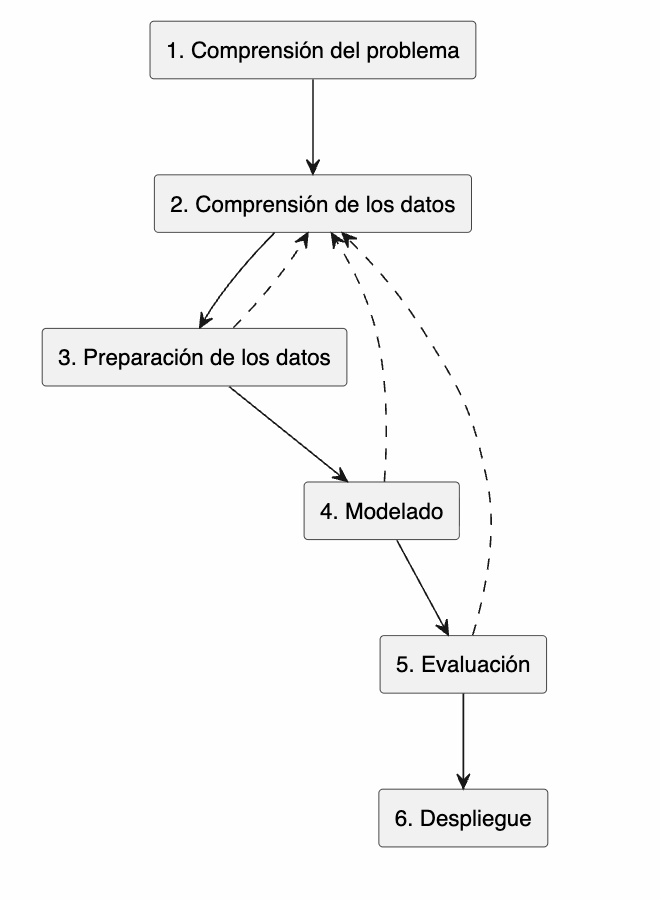

**Cronograma detallado (fechas y responsables por actividad):**

- **Período:** 27 de agosto al 26 de septiembre de 2026 (las fechas a partir del 9 de septiembre son tentativas, pendientes de confirmar en la plataforma del curso).
- **Integrantes:** Alejandra Jaramillo Mejía, Santiago Chaparro Suzunaga, Brayan Sebastián Yepes García.
- **Metodología:** CRISP-DM adaptada a un proyecto de análisis estadístico y visualización.

| ID | Fase | Actividad | Subactividad | Responsable | Apoyo | Inicio | Fin | Duración (días) | Estado | Entregable |
|---|---|---|---|---|---|---|---|---|---|---|
| 1 | Entendimiento del negocio | Definición del problema | Definir problema y contexto clínico | Todos |  | 27 ago | 28 ago | 2 | Confirmado | Notebook Sección 1 entregado |
| 2 | Entendimiento del negocio | Alcance | Definir beneficiarios, objetivos y fronteras del proyecto | Todos |  | 28 ago | 30 ago | 3 | Confirmado | Notebook Sección 1 entregado |
| 3 | Entendimiento del negocio | Plan y preguntas orientadoras | Definir plan de trabajo, cronograma y preguntas de análisis | Todos |  | 30 ago | 1 sep | 3 | Confirmado | Notebook Sección 1 entregado |
| 4 | Entendimiento del negocio | Consolidación y entrega Sección 1 | Redactar y subir el notebook de Sección 1 (hoy) | Todos |  | 1 sep | 2 sep | 2 | Confirmado | Notebook Sección 1 entregado |
| 5 | Entendimiento de los datos | Adquisición e integración de datos | Documentar y verificar la carga de los datos clínicos (607 pacientes) | Alejandra |  | 3 sep | 4 sep | 2 | - | - |
| 6 | Entendimiento de los datos | Análisis exploratorio (EDA) | Explorar distribuciones y relación inicial de las variables con el desenlace | Santiago | Brayan | 3 sep | 5 sep | 3 | - | - |
| 7 | Entendimiento de los datos | Calidad de los datos | Identificar duplicados, valores faltantes, inconsistencias y tipos de datos (sin corregir aún) | Brayan | Alejandra | 3 sep | 5 sep | 3 | - | - |
| 8 | Entendimiento de los datos | Análisis estadísticos descriptivos | Medidas de tendencia central, dispersión, frecuencias y proporciones por grupo de desenlace | Alejandra | Brayan | 6 sep | 7 sep | 2 | - | - |
| 9 | Entendimiento de los datos | Consolidación y entrega Sección 2 | Consolidación de información | Todos |  | 7 sep | 8 sep | 2 | - | - |
| 10 | EEG complementario | Selección de muestra EEG | Definir criterios de selección de pacientes para exploración EEG | Brayan | Santiago | 3 sep | 4 sep | 2 | - | - |
| 11 | EEG complementario | Disponibilidad y características básicas del EEG | Revisar existencia, duración, canales y calidad de los registros EEG | Santiago | Brayan | 5 sep | 7 sep | 3 | - | - |
| 12 | Preparación de los datos | Limpieza de datos | Corregir duplicados, inconsistencias y tipos de datos identificados en Sección 2 | Alejandra | Brayan | 9 sep | 10 sep | 2 | - | - |
| 13 | Preparación de los datos | Tratamiento de valores faltantes | Analizar y aplicar la estrategia de tratamiento de faltantes | Brayan | Alejandra | 9 sep | 11 sep | 3 | - | - |
| 14 | Preparación de los datos | Transformación de variables | Transformar y estandarizar variables; construir/validar Outcome | Santiago | Brayan | 10 sep | 12 sep | 3 | - | - |
| 15 | Preparación de los datos | Validación del dataset preparado | Revisar y documentar el dataset final preparado, Consolidación de información | Todos |  | 12 sep | 13 sep | 2 | - | - |
| 16 | Análisis de datos | Formulación de hipótesis | Definir hipótesis y criterios de significancia estadística | Brayan | Todos | 13 sep | 14 sep | 2 | - | - |
| 17 | Análisis de datos | Pruebas de asociación e inferencia | Evaluar asociaciones entre variables clínicas/EEG y el desenlace | Brayan | Alejandra | 14 sep | 16 sep | 3 | - | - |
| 18 | Análisis de datos | Modelado estadístico | Ajustar y evaluar un modelo estadístico (p. ej., regresión logística) | Alejandra | Brayan | 16 sep | 18 sep | 3 | - | - |
| 19 | Análisis de datos | Interpretación de resultados | Interpretar hallazgos y distinguir asociación de causalidad | Todos |  | 18 sep | 19 sep | 2 | - | - |
| 20 | Visualización | Diseño y construcción de visualizaciones | Gráficos descriptivos, estadísticos e interactivos, y mapa de hospitales | Santiago | Alejandra | 17 sep | 20 sep | 4 | - | - |
| 21 | Visualización | Validación visual | Revisar exactitud, legibilidad y coherencia de las visualizaciones | Todos |  | 20 sep | 21 sep | 2 | - | - |
| 22 | Evaluación y entrega final | Consolidación de hallazgos | Redactar conclusiones, limitaciones y trabajo futuro | Todos |  | 21 sep | 23 sep | 3 | - | - |
| 23 | Evaluación y entrega final | Redacción del informe final | Integrar metodología, datos, análisis y visualizaciones | Todos |  | 23 sep | 25 sep | 3 | - | - |
| 24 | Evaluación y entrega final | Revisión y presentación final | Revisión técnica, de redacción y preparación de la presentación | Todos |  | 25 sep | 26 sep | 2 | - | - |

*(El diagrama de Gantt correspondiente a este cronograma se muestra a continuación como resumen visual; el detalle completo, día a día, está disponible en el archivo Excel del plan del proyecto.)*

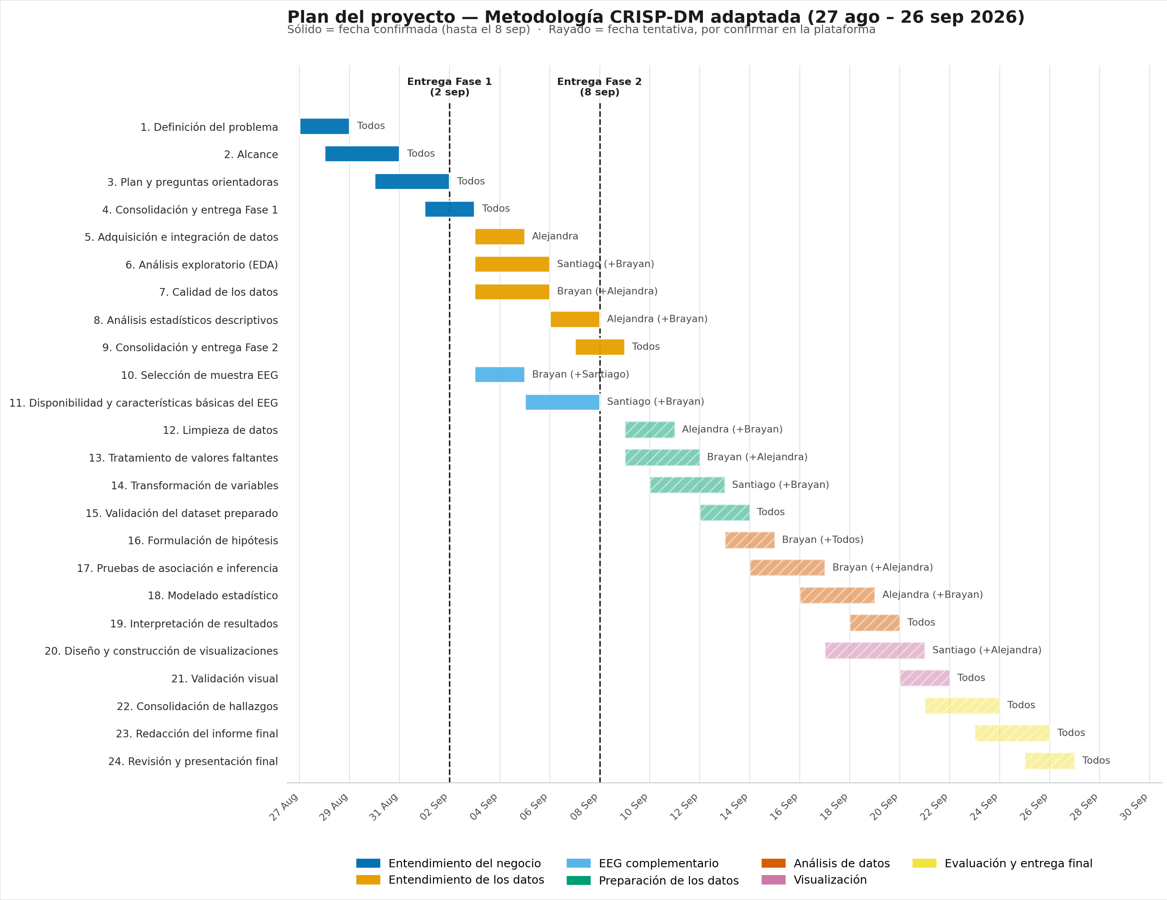

# **2. Entendimiento de los datos**
---

Esta sección corresponde a la segunda fase de CRISP-DM. Comprende la adquisición
de los datos desde su fuente original, su exploración descriptiva y la evaluación
de su calidad, con el fin de determinar qué tratamientos requerirá el conjunto
antes de poder analizarse.



Esta estrategia permite mantener trazabilidad sobre la procedencia de los datos y facilita escalar el análisis hacia etapas posteriores de estadística descriptiva, preparación de datos, estadística inferencial y modelado.

---

## Fuente y procedencia de los datos

El conjunto de datos utilizado corresponde a **I-CARE (International Cardiac Arrest REsearch consortium Database), versión 2.1**, distribuido mediante la plataforma [**PhysioNet**](https://physionet.org/content/i-care/2.1/).

> Amorim, E., Zheng, W., Lee, J. W., Herman, S., Ghassemi, M., Sivaraju, A., Gaspard, N., Hofmeijer, J., van Putten, M. J. A. M., Reyna, M., Clifford, G., & Westover, B. (2023). *I-CARE: International Cardiac Arrest REsearch consortium Database* (version 2.1). PhysioNet. https://doi.org/10.13026/m33r-bj81

I-CARE contiene información de pacientes adultos que permanecieron en estado de coma después de sufrir un paro cardíaco. Los registros fueron recopilados en diferentes instituciones hospitalarias, por lo que el conjunto posee una naturaleza **multicéntrica**.

Las instituciones participantes incluyen:

| ID | Institución                          | Ciudad    | País        |
| -: | ------------------------------------ | --------- | ----------- |
|  1 | Rijnstate Hospital                   | Arnhem    | Netherlands |
|  2 | Medisch Spectrum Twente              | Enschede  | Netherlands |
|  3 | Erasme Hospital                      | Brussels  | Belgium     |
|  4 | Massachusetts General Hospital       | Boston    | USA         |
|  5 | Brigham and Women's Hospital         | Boston    | USA         |
|  6 | Beth Israel Deaconess Medical Center | Boston    | USA         |
|  7 | Yale New Haven Hospital              | New Haven | USA         |

La procedencia multicéntrica es relevante para el análisis debido a que las características de la población, disponibilidad de información, procedimientos clínicos y condiciones de adquisición de las señales pueden presentar heterogeneidad entre instituciones.

En consecuencia, la variable `Hospital` no debe interpretarse únicamente como información descriptiva, sino también como una posible fuente de variabilidad que deberá ser considerada durante las etapas posteriores del análisis.

La población incluida corresponde a pacientes adultos con paro cardíaco ocurrido dentro o fuera del hospital, que lograron el retorno de la circulación espontánea (ROSC), pero permanecieron en estado de coma, definido en I-CARE como la incapacidad para seguir órdenes verbales y una puntuación de Glasgow menor o igual a 8.

## Criterios de inclusión

De acuerdo con la documentación de PhysioNet, se incluyeron pacientes que cumplían simultáneamente con:

* Ser adultos con paro cardíaco intrahospitalario o extrahospitalario.
* Haber logrado retorno de la circulación espontánea (ROSC).
* Persistir en estado de coma tras el ROSC (Glasgow ≤ 8, sin seguir órdenes verbales).
* Haber sido admitidos a una unidad de cuidados intensivos con monitorización EEG continua.

## Recolección de variables clínicas y señales fisiológicas

Durante la hospitalización se registraron variables demográficas y clínicas (edad, sexo, hospital de procedencia, lugar del paro, tipo de ritmo cardíaco inicial, tiempo entre el paro y el ROSC) junto con información sobre el manejo de temperatura dirigido (TTM), obtenida mediante dispositivos de retroalimentación controlada.

De forma paralela, se inició la monitorización electroencefalográfica y electrocardiográfica continua, típicamente dentro de las primeras horas posteriores al paro cardíaco, extendiéndose entre varias horas y varios días según la evolución clínica de cada paciente. Estos registros fisiológicos se almacenan en formato WFDB (archivos `.hea` y `.mat`), tal como se describe en la sección 2.2.

## Determinación del desenlace neurológico (CPC)

La escala CPC no fue recolectada de manera homogénea en todos los centros: en dos de los siete hospitales se determinó **prospectivamente**, mediante entrevista telefónica estructurada a los 6 meses posteriores al ROSC; en los cinco hospitales restantes se determinó de forma **retrospectiva**, mediante revisión de historias clínicas entre 3 y 6 meses después del evento. Esta diferencia metodológica en la forma de evaluar el desenlace constituye una fuente adicional de heterogeneidad entre centros que deberá tenerse en cuenta al interpretar comparaciones entre hospitales.

## Consideraciones éticas

El conjunto de datos corresponde a un análisis retrospectivo de información generada durante la atención clínica de rutina. De acuerdo con la documentación de PhysioNet, el requisito de consentimiento informado fue **dispensado** por los comités de ética institucionales correspondientes, dado el carácter retrospectivo y no intervencionista del estudio. El acceso a los datos se rige por la licencia **Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International (CC BY-NC-SA 4.0)**, que permite su uso académico y exploratorio —como el que se realiza en este proyecto— siempre que se cite adecuadamente la fuente y no se le dé un uso comercial.

---



## Estructura y granularidad de los datos

I-CARE no corresponde a una tabla convencional en la cual cada archivo representa una observación independiente. Los datos poseen una estructura **jerárquica y longitudinal**.

De manera conceptual:



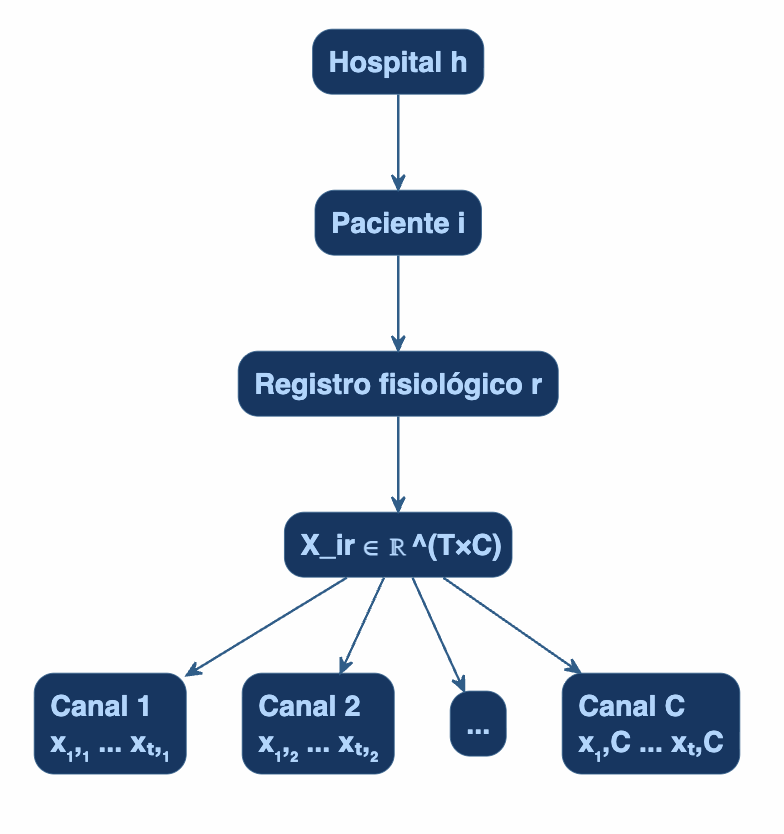

Por tanto, pueden identificarse diferentes niveles de información:

| Nivel    | Unidad               | Ejemplo                        | Naturaleza         |
| -------- | -------------------- | ------------------------------ | ------------------ |
| Centro   | Hospital             | Massachusetts General Hospital | Categórica         |
| Paciente | Individuo            | `PatientID`                    | Unidad de análisis |
| Registro | Registro fisiológico | Registro EEG                   | Serie temporal     |
| Canal    | Electrodo/señal      | Canal EEG                      | Serie temporal     |
| Muestra  | Instante temporal    | \(x_{t,c}\)                    | Valor numérico     |

Esta distinción es importante porque múltiples muestras temporales, canales o registros pertenecientes al mismo paciente **no constituyen pacientes independientes**.

Para el análisis clínico inicial, la unidad principal de observación será el **paciente**.


## Datos clínicos, demográficos y de resultado

Cada paciente dispone de información clínica y demográfica almacenada en archivos de texto con una estructura basada en pares:

```text
Variable: Value
```

Estos datos pueden transformarse en una representación tabular donde cada fila corresponde inicialmente a un paciente y cada columna a una característica.

Las principales variables identificadas son:

| Variable           | Descripción                                      | Naturaleza estadística | Escala   |
| ------------------ | ------------------------------------------------ | ---------------------- | -------- |
| `Age`              | Edad del paciente                                | Cuantitativa           | Razón    |
| `Sex`              | Sexo registrado                                  | Categórica             | Nominal  |
| `Hospital`         | Centro de procedencia                            | Categórica             | Nominal  |
| `ROSC`             | Tiempo hasta retorno de circulación espontánea   | Cuantitativa           | Razón    |
| `OHCA`             | Paro cardíaco fuera del hospital                 | Categórica binaria     | Nominal  |
| `Shockable Rhythm` | Presencia de ritmo inicialmente desfibrilable    | Categórica binaria     | Nominal  |
| `TTM`              | Temperatura objetivo utilizada en el tratamiento | Cuantitativa           | Numérica |
| `CPC`              | Cerebral Performance Category                    | Categórica             | Ordinal  |
| `Outcome`          | Resultado neurológico agrupado                   | Categórica binaria     | Nominal  |

La identificación del tipo de cada variable es necesaria debido a que determina posteriormente qué medidas descriptivas, representaciones gráficas, transformaciones y métodos estadísticos resultan apropiados.

---



## Variables de resultado clínico

## Cerebral Performance Category — CPC

La escala **Cerebral Performance Category (CPC)** representa el estado neurológico posterior al paro cardíaco:

$$
CPC\in\{1,2,3,4,5\}.
$$

| CPC | Interpretación general         |
| --: | ------------------------------ |
|   1 | Buen funcionamiento cerebral   |
|   2 | Discapacidad cerebral moderada |
|   3 | Discapacidad cerebral severa   |
|   4 | Coma o estado vegetativo       |
|   5 | Muerte                         |

`CPC` debe considerarse una **variable categórica ordinal** debido a que existe un orden natural entre sus categorías:

$$
1 < 2 < 3 < 4 < 5.
$$

Sin embargo, las distancias entre categorías no necesariamente representan diferencias clínicas equivalentes. Por esta razón, CPC no debe tratarse automáticamente como una variable cuantitativa continua.

---

## Outcome

La variable `Outcome` agrupa el resultado neurológico en dos categorías:

$$
Outcome_i\in
\{\text{Good},\text{Poor}\}.
$$

En el conjunto de datos:

$$
CPC\in\{1,2\}
\Rightarrow
Outcome=\text{Good},
$$

mientras que:

$$
CPC\in\{3,4,5\}
\Rightarrow
Outcome=\text{Poor}.
$$

Por tanto, `Outcome` corresponde a una **variable categórica nominal binaria**.

En esta etapa se considera una **variable candidata de respuesta** para análisis estadísticos y modelos posteriores, sin asumir todavía una formulación predictiva específica.

---


## **2.1. Adquisición e integración de los datos**
---

Los metadatos clínicos no se distribuyen como una tabla. Cada uno de los 607
pacientes dispone de un archivo de texto plano con una estructura de pares
`Variable: Valor`, alojado en el repositorio de PhysioNet. La integración
consiste en recorrer el índice de pacientes, descargar cada archivo, interpretar
sus pares y consolidarlos en un único `DataFrame`.


**Fuente de los datos**

I-CARE: International Cardiac Arrest REsearch consortium Database, v2.1 (14 dic. 2023), disponible en PhysioNet bajo licencia CC BY-NC-SA 4.0.

DOI: https://doi.org/10.13026/m33r-bj81

Cita: Amorim, E., Zheng, W., Lee, J. W., et al. (2023). I-CARE: International Cardiac Arrest REsearch consortium Database (version 2.1). PhysioNet. https://doi.org/10.13026/m33r-bj81

Este conjunto de datos se divide en dos. El primero referente a los datos clínicos y el segundo a los datos correspondientes a las señales como se muestra a continuación

In [ ]:
# ---------------------------------------------------------------------------
# Adquisición de los metadatos clínicos desde PhysioNet.
#
# La celda comprueba primero si existe una copia local del conjunto crudo. Si la
# encuentra, la lee; si no, descarga los 607 archivos y la guarda. Esto permite
# que el notebook se ejecute completo en segundos a partir de la segunda vez,
# conservando el código de adquisición como parte de la documentación.
# ---------------------------------------------------------------------------
BASE_URL    = "https://physionet.org/files/i-care/2.1"
RECORDS_URL = f"{BASE_URL}/RECORDS"
RUTA_CRUDO  = Path("icare_clinical_data.csv")

if RUTA_CRUDO.exists():
    # keep_default_na=False conserva el texto "nan" tal como llega de PhysioNet;
    # sin él, pandas lo convertiría en nulo al leer y la copia local dejaría de
    # ser idéntica a la descarga que se analiza en las secciones 2 y 3.
    clinical_df = pd.read_csv(RUTA_CRUDO, dtype=str, keep_default_na=False)
    print(f"Conjunto leído de la copia local '{RUTA_CRUDO}': {clinical_df.shape}")

else:
    print("No se encontró copia local. Descargando desde PhysioNet…\n")
    urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

    # Sesión con reintentos automáticos ante errores transitorios del servidor
    # (502/503/504), para que un solo paciente no interrumpa todo el proceso.
    session = requests.Session()
    session.mount("https://", HTTPAdapter(max_retries=Retry(
        total=5, backoff_factor=1.5,
        status_forcelist=[502, 503, 504], allowed_methods=["GET"])))

    # 1. Índice de pacientes
    respuesta = session.get(RECORDS_URL, verify=False, timeout=30)
    respuesta.raise_for_status()
    patient_ids = [r.strip("/").split("/")[-1] for r in respuesta.text.splitlines()]
    print("Pacientes encontrados en el índice:", len(patient_ids))

    # 2. Descarga y parseo del archivo clínico de cada paciente
    pacientes, fallidos = [], []
    for i, pid in enumerate(patient_ids, start=1):
        url = f"{BASE_URL}/training/{pid}/{pid}.txt"
        try:
            r = session.get(url, verify=False, timeout=30)
            r.raise_for_status()
        except requests.exceptions.RequestException as e:
            print(f"  Fallo definitivo en el paciente {pid}: {e}")
            fallidos.append(pid)
            continue
        registro = {}
        for linea in r.text.strip().splitlines():
            clave, valor = linea.split(":", 1)
            registro[clave.strip()] = valor.strip()
        pacientes.append(registro)
        if i % 100 == 0:
            print(f"  Progreso: {i}/{len(patient_ids)}")

    print(f"\nDescarga completa: {len(pacientes)} correctos, {len(fallidos)} fallidos")
    assert not fallidos, f"Revisar pacientes fallidos: {fallidos}"

    # 3. Consolidación y persistencia de la copia local
    clinical_df = pd.DataFrame(pacientes)
    clinical_df.to_csv(RUTA_CRUDO, index=False)
    print(f"Copia local guardada en '{RUTA_CRUDO}'")

print()
clinical_df.head()

## **2.2. Análisis exploratorio de los datos**
---

- ¿Cuántos registros contiene el conjunto?
- ¿En qué formato se encuentra y qué tipo de datos contiene cada variable?
- ¿Qué caracteriza a la población estudiada?


In [ ]:
import os

print("Número de registros (pacientes):", clinical_df.shape[0])
print("Número de variables:", clinical_df.shape[1])

size_mb = os.path.getsize("icare_clinical_data.csv") / (1024 ** 2)
print(f"Tamaño del archivo CSV integrado: {size_mb:.3f} MB")

clinical_df.info()

**¿Cuántos registros contiene el dataset?**
El conjunto de datos integrado (clinical_df) contiene 607 registros, uno por cada paciente incluido en el conjunto de entrenamiento público de I-CARE v2.1, y 10 variables por paciente (Patient, Hospital, Age, Sex, ROSC, OHCA, Shockable Rhythm, TTM, Outcome, CPC).

 Además, es importante distinguir esto del concepto de "registro" en las señales fisiológicas: según la documentación oficial, el dataset completo de I-CARE contiene 80,809 segmentos de grabación (EEG, ECG y otros) distribuidos entre esos mismos 607 pacientes. Por ejemplo, el paciente 0284 por sí solo tiene 255 registros fisiológicos. Este análisis se enfoca en los 607 registros clínicos (uno por paciente); el estudio detallado de los segmentos de señal fisiológica se abordará sobre una muestra representativa en una fase posterior.

**¿En qué formato están guardados los datos?**
Originalmente, la información clínica de cada paciente se encuentra en PhysioNet como un archivo de texto plano individual (.txt), con una estructura de pares Variable: Value. En este notebook esos 607 archivos se descargaron, se transformaron y se integraron en un DataFrame de pandas, la cual se exportó como un archivo .csv (icare_clinical_data.csv).

Las señales fisiológicas (EEG, ECG) vienen en formato WFDB (el estándar de PhysioNet), representadas en dos archivos por registro: un header en texto plano (.hea, con metadatos como canales y frecuencia de muestreo) y los valores numéricos de la señal en formato binario MATLAB (.mat).

**¿Qué tamaño en MB tiene el conjunto de datos?**
El archivo icare_clinical_data.csv resultante de la integración pesa aproximadamente 0.024 MB (24 KB). Este tamaño reducido corresponde únicamente a los metadatos clínicos y demográficos de los pacientes; no incluye las señales fisiológicas de EEG/ECG (formato WFDB), que representan un volumen considerablemente mayor (del orden de 1.5 TB en conjunto) y se abordarán de manera complementaria sobre una muestra reducida de pacientes.


In [ ]:
numeric_cols = ["Age", "ROSC", "TTM"]
for col in numeric_cols:
    valores_no_numericos = clinical_df.loc[
        pd.to_numeric(clinical_df[col], errors="coerce").isna(), col
    ].unique()
    print(f"{col}: valores no numéricos encontrados -> {valores_no_numericos}")

Age: valores no numéricos encontrados -> ['nan'] significa que en la columna Age, el único valor que no se pudo convertir directamente a número es el texto "nan", es decir, algunos pacientes no tienen la edad registrada, y ese vacío quedó guardado como la palabra "nan" en vez de quedar realmente vacío. Lo mismo aplica para ROSC y TTM: en ambas, el único valor problemático es también "nan".


 Dado que se trata de un único caso identificado y controlado, se procede a realizar la conversión definitiva de estas columnas a tipo numérico mediante pd.to_numeric() con el parámetro errors="coerce", el cual transformará ese texto "nan" en valores nulos (NaN) reales, reconocidos como tal por pandas.

In [ ]:
for col in numeric_cols:
    clinical_df[col] = pd.to_numeric(clinical_df[col], errors="coerce")

clinical_df[numeric_cols].dtypes

In [ ]:

# Estadística descriptiva de las variables numéricas
clinical_df[numeric_cols].describe()

**Interpretación de la estadística descriptiva (variables numéricas)**

**Edad (`Age`):** el conjunto de datos tiene información de edad para 606 de los 607 pacientes (solo 1 valor faltante, equivalente al 0.16%). La edad promedio es de 61.2 años (desviación estándar de 15.7), con un rango que va de 16 a 90 años. La mitad de los pacientes tiene entre 52 y 72 años (rango intercuartílico), y la mediana es 63 años. Esto confirma que la población está compuesta mayoritariamente por adultos de mediana edad y adultos mayores, consistente con la epidemiología típica del paro cardíaco. Es importante aclarar que el valor máximo (90) no debe leerse como una edad exacta ya que según la documentación oficial de I-CARE, por anonimización todo paciente mayor de 89 años queda registrado con Age = 90, por lo que este valor es en realidad un tope de censura ("90 años o más") y puede generar una acumulación artificial de casos en ese punto que no representa la edad real de esos pacientes.

**Manejo de temperatura dirigido (`TTM`):** 509 de los 607 pacientes tienen este dato registrado (98 "faltantes", 16.1%). Lo más llamativo es la desviación estándar extremadamente baja (0.98), con la mediana, el percentil 25 y el percentil 75 coincidiendo exactamente en 33, y un máximo de 36. Esto indica que TTM no se comporta como una variable verdaderamente continua, sino que refleja un protocolo clínico con valores objetivo discretos (33 °C o 36 °C). Además, según la documentación oficial de I-CARE, el valor NaN en TTM no representa un dato que no se logró capturar, sino que está codificado explícitamente como "no TTM": ese 16.1% corresponde a pacientes a quienes no se les aplicó manejo de temperatura dirigido, no a información desconocida.

**Tiempo hasta el retorno de circulación espontánea (`ROSC`):** esta variable presenta una cantidad considerable de datos faltantes: solo 303 de los 607 pacientes tienen este valor registrado (304 faltantes, equivalente al 50.1% del total). Entre quienes sí tienen el dato, el tiempo promedio hasta ROSC es de 23.3 minutos (desviación estándar de 18.8), con un rango muy amplio (de 1 a 111 minutos) y una mediana de 19 minutos. A diferencia de TTM, la documentación no indica un significado especial para los valores faltantes de ROSC, por lo que aquí sí se trata de datos genuinamente no capturados. Dada la alta proporción de valores faltantes, cualquier análisis posterior con esta variable debe interpretarse con cuidado, ya que la mitad de la información no está disponible.



En conjunto, estas tres variables muestran patrones de "valores faltantes" muy distintos entre sí, y no todos son comparables: en Age el faltante es mínimo (0.16%) y real; en ROSC es alto (50.1%) y también real, por lo que su ausencia limita el análisis; en TTM, en cambio, el 16.1% no es un dato perdido sino una categoría clínica válida ("sin TTM") documentada explícitamente por los autores del dataset. Esta distinción deberá tenerse en cuenta explícitamente al decidir estrategias de imputación en la fase de Preparación de los Datos: Age y ROSC son candidatas a imputación o exclusión según el caso, mientras que TTM debería conservar su NaN (o recodificarse como categoría "Sin TTM") en lugar de imputarse.

In [ ]:
categorical_cols = ["Sex", "Hospital", "OHCA", "Shockable Rhythm", "Outcome", "CPC"]
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(clinical_df[col].value_counts(dropna=False))

**Interpretación de la estadística descriptiva (variables categóricas)**

**Sexo (`Sex`):** la población es mayoritariamente masculina (417 hombres, 68.7%; 187 mujeres, 30.8%), con solo 3 registros (0.5%) sin este dato. Esta proporción es consistente con la mayor incidencia de paro cardíaco reportada en hombres en la literatura clínica.

**Hospital (`Hospital`):** se observan 5 códigos de institución en los datos (A, B, D, E, F). Según la documentación oficial de I-CARE, aunque el consorcio está formado por 7 hospitales, los identificadores del conjunto público de entrenamiento solo cubren las letras A a F (6 códigos posibles). La distribución además es muy desigual ya que el hospital A concentra el 43.0% de todos los pacientes (261 de 607), mientras que F aporta solo el 11.4% (69 pacientes). Esta fuerte concentración en un solo centro refuerza la necesidad de tratar Hospital como una posible fuente de heterogeneidad.

**Paro cardíaco extrahospitalario (`OHCA`):** el 72.8% de los pacientes (442) sufrió el paro fuera del hospital, frente a un 20.4% que lo sufrió dentro del hospital (124), con un 6.8% de datos faltantes (41 pacientes).

**Ritmo inicial desfibrilable (`Shockable Rhythm`):** esta variable está prácticamente balanceada entre sus dos categorías (48.9% True, 45.8% False), con un 5.3% de valores faltantes (32 pacientes).

**Desenlace neurológico (`Outcome`):** la variable objetivo del proyecto muestra un desbalance moderado: el 62.9% de los pacientes (382) tuvo un desenlace Poor, frente a un 37.1% (225) con desenlace Good. Este desbalance deberá tenerse en cuenta en el análisis inferencial y en el modelado estadístico posterior, ya que puede afectar la interpretación de comparaciones entre grupos.

**Cerebral Performance Category (`CPC`):** la distribución es marcadamente bimodal: ya que el 58.2% de los pacientes (353) tiene CPC = 5 (muerte) y el 29.8% (181) tiene CPC = 1 (función cerebral conservada), mientras que las categorías intermedias (CPC 2, 3 y 4) concentran en conjunto solo el 12.0% de los casos. Esto confirma, con evidencia numérica, que los desenlaces post-paro cardíaco tienden a ubicarse en los extremos de la escala más que en niveles intermedios de discapacidad.



**Verificación de consistencia entre `CPC` y `Outcome`**

| CPC | Significado | Pacientes | Outcome esperado |
|---|---|---|---|
| 1 | Función cerebral normal | 181 | Good |
| 2 | Discapacidad neurológica moderada | 44 | Good |
| 3 | Discapacidad neurológica severa | 20 | Poor |
| 4 | Estado vegetativo | 9 | Poor |
| 5 | Muerte | 353 | Poor |

Sumando por grupo:
- Good esperado: 181 + 44 = **225**
- Poor esperado: 20 + 9 + 353 = **382**

Estos totales coinciden exactamente con el conteo real de Outcome (225 Good, 382 Poor), confirmando que la variable fue construida correctamente a partir de CPC, sin inconsistencias.

In [ ]:
comparacion = clinical_df.groupby("Outcome")[numeric_cols].describe().T
comparacion

In [ ]:
pd.crosstab(clinical_df['Outcome'], clinical_df['TTM'], dropna=False)

**Comparación descriptiva entre grupos de desenlace (`Age`, `ROSC`, `TTM`)**

**Edad (`Age`):** Los pacientes con desenlace Poor tienden a ser mayores que los de desenlace Good, y esta diferencia se mantiene en toda la distribución:

- **Media:** 63.3 años (Poor) vs. 57.5 años (Good) — casi 6 años de diferencia.
- **Mediana:** 66 años (Poor) vs. 58 años (Good).
- **Rango intercuartílico (IQR):** 54-75 años (Poor) vs. 49-67 años (Good) — el rango completo está desplazado hacia edades mayores.

Esto es consistente con la literatura clínica, que identifica la edad como uno de los factores pronósticos más importantes tras un paro cardíaco: a mayor edad, menor probabilidad de recuperación neurológica favorable.

**Tiempo hasta el retorno de circulación espontánea (`ROSC`):** entre quienes tienen el dato registrado, los pacientes Poor tardaron en promedio más tiempo en recuperar circulación espontánea (24.8 minutos vs. 19.3 minutos en Good), con una mediana de 20 minutos frente a 15. Esto también es clínicamente esperable: cuanto más tiempo pasa el cerebro sin circulación adecuada, mayor es el daño hipóxico y peor el pronóstico neurológico. Vale la pena señalar además que la proporción de datos faltantes en ROSC no es igual entre los dos grupos: en Good falta el dato en 140 de 225 pacientes (62.2%), mientras que en Poor falta en 164 de 382 (42.9%). Esta diferencia en la tasa de datos faltantes entre grupos debe tenerse en cuenta más adelante.

**Manejo de temperatura dirigido (`TTM`):**

El cruce de Outcome con TTM (incluyendo los NaN como categoría "sin TTM") confirma y completa lo señalado en la comparación de medias: dentro de cada grupo, la gran mayoría de los pacientes que sí recibieron manejo de temperatura fueron tratados a 33 °C, y esa proporción es prácticamente idéntica entre grupos — 87.6% de los pacientes Good con TTM (170 de 194) estuvieron a 33 °C frente a un 12.4% a 36 °C; en Poor la proporción es de 88.3% (278 de 315) a 33 °C y 11.7% a 36 °C. Es decir, entre quienes recibieron el protocolo, la elección de la temperatura objetivo (33 °C vs. 36 °C) no muestra una relación apreciable con el desenlace neurológico.

Donde sí aparece una diferencia es en si el paciente recibió o no el protocolo: el 13.8% de los pacientes Good no tuvo TTM (31 de 225) frente al 17.5% de los Poor (67 de 382). Aunque la diferencia es moderada, conviene interpretarla con cautela ya que no necesariamente significa que omitir el TTM cause peor desenlace, sino que probablemente ambas cosas están relacionadas con la gravedad inicial del paciente.

En conjunto, Age y ROSC muestran una relación clara y clínicamente coherente con el desenlace neurológico —peores desenlaces asociados a pacientes de mayor edad y con tiempos de reanimación más largos—, mientras que TTM, dada su naturaleza casi categórica, requiere un análisis distinto al de una variable continua para evaluar su relación con Outcome.

## **2.3. Análisis estadístico descriptivo**
---

Se describe el conjunto mediante estadística descriptiva univariada y bivariada,
acompañada de las visualizaciones que hacen legibles esas medidas.


In [ ]:
counts = clinical_df['Outcome'].value_counts()
percentages = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(counts.index, counts.values, color=['#DD8452', '#4C72B0'], edgecolor='white')

for bar, pct in zip(bars, percentages):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{int(bar.get_height())} ({pct:.1f}%)', ha='center', va='bottom')

ax.set_title('Distribución de Outcome')
ax.set_xlabel('Outcome')
ax.set_ylabel('Número de pacientes')
ax.tick_params(axis='x', rotation=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

- El dataset está desbalanceado: hay más pacientes con desenlace Poor (382, 62.9%) que con Good (225, 37.1%).
- Esto es clínicamente esperable en pacientes que permanecen en coma tras un paro cardíaco, donde la mayoría de los pacientes no logra una recuperación neurológica favorable.

In [ ]:

age = pd.to_numeric(clinical_df['Age'], errors='coerce').dropna()
rosc = pd.to_numeric(clinical_df['ROSC'], errors='coerce').dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(age, bins=20, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribución de Age')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Frecuencia')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].hist(rosc, bins=20, color='#DD8452', edgecolor='white')
axes[1].set_title('Distribución de ROSC')
axes[1].set_xlabel('ROSC (minutos)')
axes[1].set_ylabel('Frecuencia')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()



La distribución de `Age` (azul) es asimétrica hacia la izquierda: la mayor concentración de pacientes está entre 55 y 80 años, con el pico más alto alrededor de los 65-75 años, y una cola que se extiende hacia edades menores (20-50 años) en menor proporción. Esto confirma visualmente lo que ya se había descrito con la mediana (63 años) y el rango intercuartílico (52-72) por lo que la población está compuesta principalmente por adultos mayores.

Vale la pena revisar si la barra final (cercana a 90) muestra un corte abrupto en vez de una disminución gradual, ya que eso sería la evidencia visual del tope de censura en `Age = 90` que se documentó antes.

La distribución de `ROSC` (naranja) tiene la forma opuesta: es fuertemente asimétrica hacia la derecha, con la mayoría de los pacientes concentrados en tiempos cortos (menos de 20-25 minutos) y una cola larga y poco poblada que se extiende hasta más de 100 minutos. Esto es coherente con lo esperado clínicamente: la mayoría de los pacientes recuperan circulación espontánea relativamente rápido, mientras que un grupo pequeño requiere reanimaciones mucho más prolongadas.



In [ ]:
clinical_df[['Age', 'ROSC']].skew()   # asimetría


In [ ]:
clinical_df[['Age', 'ROSC']].kurt()   # curtosis

**Age:**

- Asimetría = -0.59 (moderadamente negativa): la distribución tiene una cola ligeramente más larga hacia la izquierda (edades bajas), lo cual es coherente con el histograma. la mayoría de los pacientes se concentra entre 55-75 años, con una cola más extendida hacia edades jóvenes que hacia edades muy avanzadas.
- Curtosis = 0.007 indica una forma mesocúrtica, es decir, muy similar a una distribución normal en cuanto a qué tan puntiaguda es o qué tan pesadas son sus colas.

**ROSC:**

- Asimetría = 1.85 (fuertemente positiva): confirma numéricamente que la mayoría de los pacientes tiene tiempos de ROSC bajos, con una cola larga hacia la derecha por los casos de reanimaciones prolongadas (hasta 100+ minutos).
- Curtosis = 4.21 distribución leptocúrtica, con un pico más concentrado alrededor de los valores bajos y colas más pesadas de lo que tendría una distribución normal, coincidiendo con los múltiples outliers vistos en el boxplot de ROSC.

**En conjunto:** Age se comporta de forma razonablemente simétrica y cercana a lo normal, mientras que ROSC está claramente sesgada a la derecha y tiene colas pesadas. 

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for outcome, color in zip(['Good', 'Poor'], ['#4C72B0', '#DD8452']):
    age_data = clinical_df.loc[clinical_df['Outcome'] == outcome, 'Age'].dropna()
    axes[0].hist(age_data, bins=20, alpha=0.6, color=color, edgecolor='white',
                 density=True, label=outcome)

    rosc_data = clinical_df.loc[clinical_df['Outcome'] == outcome, 'ROSC'].dropna()
    axes[1].hist(rosc_data, bins=20, alpha=0.6, color=color, edgecolor='white',
                 density=True, label=outcome)

axes[0].set_title('Distribución de Age por Outcome')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Densidad')
axes[0].legend(title='Outcome')

axes[1].set_title('Distribución de ROSC por Outcome')
axes[1].set_xlabel('ROSC (minutos)')
axes[1].set_ylabel('Densidad')
axes[1].legend(title='Outcome')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Age:

La distribución de Good se concentra más entre los 55-70 años, con su pico más alto justo ahí (~0.034).
La distribución de Poor está desplazada hacia edades mayores: tiene más densidad relativa en el rango de 70-85 años, y una cola que llega hasta cerca de 90 años que prácticamente no existe en Good.
Ambos grupos comparten un pequeño grupo de pacientes jóvenes (20-30 años), pero es un poco más marcado en Poor.
En conjunto, esto confirma que a mayor edad, mayor proporción relativa de desenlace Poor.

ROSC:

Ambos grupos tienen su mayor densidad en tiempos cortos (0-15 min), pero Good tiene un pico más pronunciado y concentrado ahí (~0.04) y cae más rápido después de los 20-30 min.
Poor tiene una distribución más "aplanada" y con cola más larga: mantiene densidad notable hasta los 40-70 min, y predomina claramente en los tramos por encima de 50 min, aunque no es el único: el valor más alto de toda la cohorte (111 min) corresponde a un paciente Good, como muestra la tabla comparativa de la sección 2.2.
Esto sugiere que cuanto más tiempo tarda un paciente en recuperar circulación espontánea, más probable es que el desenlace sea Poor.

In [ ]:
cols = ['Age', 'ROSC', 'TTM']
ylabels = {'Age': 'Edad (años)', 'ROSC': 'ROSC (minutos)', 'TTM': 'TTM (°C)'}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, col in zip(axes, cols):
    good = clinical_df.loc[clinical_df['Outcome'] == 'Good', col].dropna()
    poor = clinical_df.loc[clinical_df['Outcome'] == 'Poor', col].dropna()

    bp = ax.boxplot([good, poor], tick_labels=['Good', 'Poor'], patch_artist=True,
                     medianprops=dict(color='black'))
    for box in bp['boxes']:
        box.set_facecolor('#4C72B0')
        box.set_alpha(0.7)

    ax.set_title(col)
    ax.set_xlabel('Outcome')
    ax.set_ylabel(ylabels[col])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Age (Edad):**

- Los pacientes con Outcome Poor tienden a ser mayores: la mediana de edad es de 66 años, frente a 58 años en el grupo Good. El rango intercuartílico también está desplazado hacia arriba en Poor (54-75 años) en comparación con Good (49-67 años).
- Ambos grupos presentan outliers de pacientes jóvenes (<20 años), aunque son más marcados en Poor.

**ROSC (tiempo hasta retorno de circulación espontánea):**

- La mediana es más alta en Poor (≈20 min) que en Good (≈15 min), y el rango intercuartílico también está desplazado hacia valores mayores (11-30 vs. 8-25).
- Ambos grupos tienen outliers de reanimaciones muy prolongadas (60 min o más). En Poor son muchos más, pero no son los más extremos: el máximo de Poor es 100 min, mientras que el de Good es 111 min (tabla comparativa de la sección 2.2). La lectura correcta es de tendencia y no de regla: cuanto más tiempo tardó el paciente en recuperar circulación espontánea, más frecuente fue el desenlace desfavorable. Esto es clínicamente coherente: a mayor tiempo de paro sin circulación, mayor daño cerebral por falta de oxígeno (isquemia), lo que reduce la probabilidad de recuperación neurológica.

**TTM (manejo de temperatura dirigido):**

- Aquí el patrón es distinto: la caja está prácticamente aplanada en 33°C para ambos grupos (Good y Poor), es decir, la gran mayoría de los pacientes que recibieron TTM fueron tratados a 33°C, sin importar el desenlace.
- El valor de 36 °C aparece como un único punto atípico en cada grupo, pero ese punto agrupa a 24 pacientes Good y 37 Poor (ver la tabla cruzada de `Outcome` y `TTM`).
- En otras palabras, TTM no muestra diferencia visible entre Good y Poor — el protocolo de temperatura aplicado no parece discriminar el desenlace, al menos en este gráfico. (Recuerda que este boxplot solo incluye a los pacientes que sí recibieron TTM, ya que los NaN —"sin TTM"— se excluyeron con dropna().)

In [ ]:

counts = clinical_df['Hospital'].value_counts()
percentages = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(counts.index, counts.values, color='#4C72B0', edgecolor='white')

for bar, pct in zip(bars, percentages):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{int(bar.get_height())} ({pct:.1f}%)', ha='center', va='bottom')

ax.set_title('Distribución de pacientes por Hospital')
ax.set_xlabel('Hospital')
ax.set_ylabel('Número de pacientes')
ax.tick_params(axis='x', rotation=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, counts.max() * 1.15)

plt.tight_layout()
plt.show()

- El Hospital A concentra la mayor parte de los pacientes (261, 43.0% del total), muy por encima del resto.
- El Hospital B es el segundo con más pacientes (120, 19.8%), y luego D, E y F tienen participaciones más parecidas entre sí y bastante menores (83, 74 y 69 pacientes respectivamente, entre 11.4% y 13.7%).
- La distribución es claramente desigual entre hospitales: no es una muestra balanceada por sitio, sino que un solo centro (A) aporta casi la mitad de los datos.
- Se confirma lo que ya habíamos revisado en la documentación oficial de PhysioNet: no aparece el código C de los 7 hospitales del consorcio original, el conjunto público de entrenamiento solo incluye 6 (A, B, D, E, F), ya que uno fue excluido de esta versión pública del dataset.
- Vale la pena mencionar esto como una posible fuente de heterogeneidad: al estar tan concentrados los datos en el Hospital A, cualquier diferencia en protocolos clínicos, criterios de TTM o características de la población atendida en ese centro podría influir de forma desproporcionada en los patrones generales observados en el dataset.

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

variables = {'Sex': axes[0], 'OHCA': axes[1], 'Shockable Rhythm': axes[2]}

for col, ax in variables.items():
    counts = clinical_df[col].value_counts()
    percentages = counts / counts.sum() * 100

    bars = ax.bar(counts.index, counts.values, color='#4C72B0', edgecolor='white')

    for bar, pct in zip(bars, percentages):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{int(bar.get_height())} ({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

    ax.set_title(f'Distribución de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Número de pacientes')
    ax.tick_params(axis='x', rotation=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0, counts.max() * 1.15)  # deja espacio arriba para que la etiqueta no se corte

plt.tight_layout()
plt.show()

**Sex:**

- La mayoría de los pacientes son hombres (417, 68.7%), frente a mujeres (187, 30.8%) el dataset está claramente desbalanceado por sexo.
- Hay una fracción muy pequeña de valores "nan" (3 pacientes, 0.5%).

**OHCA (paro cardíaco extrahospitalario):**

- La gran mayoría de los casos ocurrió fuera del hospital (True, 442, 72.8%), frente a paros intrahospitalarios (False, 124, 20.4%).
- Aquí la categoría "nan" ya es más notoria (41 pacientes, 6.8%)


**Shockable Rhythm:**

- Está bastante equilibrado entre ritmo desfibrilable (True, 297, 48.9%) y no desfibrilable (False, 278, 45.8%) a diferencia de Sex y OHCA, aquí no hay un predominio tan marcado de una categoría.
- También tiene un grupo de "nan" (32 pacientes, 5.3%).

**En conjunto:** el dataset muestra un sesgo claro hacia pacientes hombres y hacia paros extrahospitalarios, mientras que el tipo de ritmo cardíaco está más balanceado.


Se observa una pequeña categoría "nan" en Sex, OHCA y Shockable Rhythm, correspondiente a valores faltantes codificados como texto en vez de como NaN real. Este hallazgo se detalla y corrige en la sección de Calidad de datos.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

variables = ['Sex', 'OHCA', 'Shockable Rhythm']

for col, ax in zip(variables, axes):
    pct = pd.crosstab(clinical_df[col], clinical_df['Outcome'], normalize='index') * 100
    pct.plot.bar(ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='white')
    ax.set_title(f'Outcome según {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('% de pacientes')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Outcome')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Sex:**

- La diferencia es pequeña: Male tiene ligeramente más Good (aprox. 39%) que Female (aprox. 33%). No es una diferencia muy marcada, así que el sexo no parece ser un factor determinante del desenlace en este dataset.

**OHCA:**

- Se observa un resultado interesante y algo contraintuitivo porque los pacientes con paro fuera del hospital (True) tienen una proporción de Good ligeramente mayor (aprox. 38%) que los que tuvieron el paro dentro del hospital (False, aprox. 33%).
- Esto podría explicarse porque los pacientes que sufren un paro dentro del hospital suelen estar ya gravemente enfermos por otra condición médica previa (por eso estaban hospitalizados), lo cual empeora su pronóstico general, mientras que muchos pacientes de OHCA pueden haber estado relativamente sanos antes del evento. Es un hallazgo que contradice la intuición inicial, ya que uno esperaría que estar ya en el hospital, con atención inmediata, mejorara el pronóstico.

**Shockable Rhythm:**

- Aquí sí hay una diferencia grande y clara: con ritmo desfibrilable (True), el 55% de los pacientes tuvo Good, mientras que sin ritmo desfibrilable (False), solo el 17% tuvo Good (83% Poor).
- Es, por mucho, la variable con la relación más fuerte con el desenlace de las tres, como se confirma más adelante en la matriz de correlación extendida (Shockable Rhythm vs. Outcome = -0.37, la correlación más fuerte de toda la tabla).

**En conjunto:** Shockable Rhythm es claramente el factor más discriminante de los tres para el pronóstico, seguido de una señal débil en OHCA (con el hallazgo contraintuitivo ya mencionado), mientras que Sex prácticamente no diferencia el desenlace.

In [ ]:
import matplotlib.pyplot as plt

corr = clinical_df[['Age', 'ROSC', 'TTM']].corr()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns)
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='black')

ax.set_title('Matriz de correlación')
fig.colorbar(im)
plt.tight_layout()
plt.show()

Age vs. ROSC = -0.12: correlación negativa muy débil. Sugiere una leve tendencia a que pacientes de mayor edad tengan tiempos de ROSC ligeramente menores, pero el valor es tan bajo que prácticamente no hay relación lineal significativa entre estas dos variables.
Age vs. TTM = 0.05: correlación prácticamente nula. No hay relación lineal apreciable entre la edad del paciente y la temperatura objetivo usada en el manejo de temperatura.
ROSC vs. TTM = -0.05: igual que el caso anterior, correlación esencialmente nula.

En conjunto: ninguna de las tres variables numéricas muestra una correlación lineal fuerte entre sí — todos los valores están muy cerca de 0, lo que indica que Age, ROSC y TTM se comportan de forma bastante independiente entre ellas.

In [ ]:
clinical_df['Sex_num'] = (clinical_df['Sex'].astype(str) == 'Male').astype(int)
clinical_df['OHCA_num'] = (clinical_df['OHCA'].astype(str) == 'True').astype(int)
clinical_df['ShockableRhythm_num'] = (clinical_df['Shockable Rhythm'].astype(str) == 'True').astype(int)
clinical_df['Outcome_num'] = (clinical_df['Outcome'].astype(str) == 'Poor').astype(int)

cols = ['Age', 'ROSC', 'TTM', 'Sex_num', 'OHCA_num', 'ShockableRhythm_num', 'Outcome_num']
corr_ext = clinical_df[cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_ext, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right')
ax.set_yticklabels(cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr_ext.iloc[i, j]:.2f}', ha='center', va='center', color='black')

ax.set_title('Matriz de correlación extendida')
fig.colorbar(im)
plt.tight_layout()
plt.show()



- **Shockable Rhythm vs. Outcome_num = -0.37** la correlación más fuerte de toda la matriz es negativa, y como ShockableRhythm_num=1 significa que el paciente tuvo un ritmo desfibrilable (ej. fibrilación ventricular) y Outcome_num=1 significa Poor, esta correlación negativa indica que tener un ritmo desfibrilable se asocia con menor probabilidad de desenlace Poor, es decir, con mejor pronóstico.
- **OHCA vs. Shockable Rhythm = 0.28**: correlación positiva moderada sugiere que los paros ocurridos fuera del hospital (OHCA) están más asociados a presentar un ritmo desfibrilable que los ocurridos dentro del hospital.
- **TTM vs. OHCA = -0.26**: sugiere que los pacientes con paro extrahospitalario tienden más hacia TTM en 33°C, mientras que los de paro intrahospitalario tienden más hacia 36°C, probablemente reflejando diferencias en protocolos de manejo según el contexto del paro.
- **Age y ROSC vs. Outcome** (0.18 y 0.13): siguen siendo las correlaciones débiles ya identificadas, pero en este contexto se ven más débiles que la de Shockable Rhythm, lo que sugiere que el tipo de ritmo cardíaco es, de las variables disponibles, la que más se relaciona linealmente con el desenlace.
- El resto de las combinaciones (Sex con cualquier variable, TTM con la mayoría) son cercanas a 0, sin relación lineal relevante.

En conclusión, esta matriz extendida muestra que Age y ROSC se relacionan (débilmente) con el desenlace,y que Shockable Rhythm muestra la asociación más fuerte de todas las variables analizadas, un hallazgo clínicamente relevante dentro del análisis descriptivo.

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

for outcome, color in zip(['Good', 'Poor'], ['#4C72B0', '#DD8452']):
    subset = clinical_df[clinical_df['Outcome'] == outcome]
    ax.scatter(subset['Age'], subset['ROSC'], alpha=0.5, s=25, color=color,
               label=outcome, edgecolor='white', linewidth=0.3)

ax.set_title('Age vs. ROSC por Outcome')
ax.set_xlabel('Edad (años)')
ax.set_ylabel('ROSC (minutos)')
ax.legend(title='Outcome')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretación del scatter plot (Age vs. ROSC, coloreado por Outcome):**

- No hay una relación lineal clara entre Age y ROSC: los puntos están muy dispersos, sin ningún patrón de tendencia definido (ni ascendente ni descendente). Esto confirma visualmente lo que ya se había calculado con Pearson (r = -0.12), una correlación prácticamente nula.
- Al colorear por Outcome sí se nota un patrón, sobre todo en la parte alta del gráfico: los puntos naranjas (Poor) predominan claramente en la zona de ROSC más alto (por encima de 40-60 minutos) en casi todo el rango de edades. Esto es clínicamente coherente: mientras el corazón no bombea sangre, el cerebro no recibe oxígeno (isquemia), y cuanto más se prolonga esa falta de oxígeno, mayor es el daño neurológico por eso un ROSC prolongado se asocia tan consistentemente con un desenlace Poor, independientemente de la edad del paciente.
- En la zona central, más densa (ROSC entre 5-30 minutos), ambos grupos se superponen bastante, aunque los azules (Good) se concentran algo más hacia los valores bajos. Esto sugiere que un ROSC corto es una condición favorable, pero no suficiente por sí sola: hay muchos pacientes con reanimación rápida que igual tuvieron un desenlace Poor, lo que indica que otros factores (edad, tipo de ritmo cardíaco, calidad de la reanimación, comorbilidades, etc.) también influyen en el resultado final.
- Los valores más extremos del gráfico no son exclusivos de un grupo: el máximo de Poor es 100 minutos y el de Good es 111 minutos. Por encima de 60 minutos predominan los puntos naranjas, pero la presencia de un paciente Good en el extremo superior impide leer el ROSC prolongado como un límite a partir del cual la recuperación sea imposible.
- En conjunto, el gráfico refuerza la idea de que ROSC se relaciona más con Outcome que con Age: aunque Age y ROSC no tienen relación entre sí, cada una por separado sí muestra cierta asociación con el desenlace (como ya se había visto en los boxplots e histogramas por Outcome), y ROSC en particular actúa como un predictor parcial.

## **2.4. Calidad de los datos**
---

- ¿Se detecta la ausencia de datos, la presencia de datos erróneos o la
  existencia de datos de baja calidad en el conjunto?
- ¿Se identifican registros con dificultades de codificación?
- ¿Se observa diversidad de formatos que dificulte la consistencia?
- ¿Se identificaron valores atípicos, duplicados o faltantes?


Tal como se identificó, algunas variables numéricas (`Age`, `ROSC`, `TTM`) contenían el string `'nan'` que fue convertido a `NaN` numérico. A continuación se cuantifican los valores faltantes reales en cada columna. Observamos que `ROSC` y `TTM` tienen una proporción significativa de valores ausentes, mientras que otras variables categóricas también presentan un bajo porcentaje de nulos.

In [ ]:
print(clinical_df.isnull().sum())

In [ ]:
for col in ['Sex', 'OHCA', 'Shockable Rhythm']:
    clinical_df[col] = clinical_df[col].replace('nan', pd.NA)

print(clinical_df.isnull().sum())

**Valores faltantes ocultos**

Al ejecutar `clinical_df.isnull().sum()` por primera vez, las columnas `Sex`, `OHCA` y `Shockable Rhythm` mostraban 0 valores nulos, aunque ya se había identificado visualmente (en los gráficos de barras) que sí tenían una pequeña categoría `"nan"`. Esto ocurría porque esos valores faltantes estaban almacenados como el **string literal `"nan"`**, no como un `NaN` real de pandas, por lo que `.isnull()` no los reconocía como datos faltantes.

Al corregir esto reemplazando el texto `"nan"` por un valor nulo real (`pd.NA`) en esas tres columnas, el conteo de valores faltantes cambió de 0 a los valores reales:

- **Sex:** 3 valores faltantes
- **OHCA:** 41 valores faltantes
- **Shockable Rhythm:** 32 valores faltantes

Este hallazgo confirma la importancia de verificar no solo la cantidad de `NaN` reportada por pandas, sino también la consistencia en cómo están codificados los valores faltantes dentro de cada columna, ya que una codificación inconsistente puede ocultar datos faltantes reales y llevar a conclusiones erróneas sobre la calidad del dataset.

Con la corrección aplicada, el panorama completo de valores faltantes en el dataset queda así:

| Columna | Valores faltantes |
|---|---|
| Age | 1 |
| ROSC | 304 |
| TTM | 98 |
| Sex | 3 |
| OHCA | 41 |
| Shockable Rhythm | 32 |

**¿Se detecta la ausencia de datos, la presencia de datos erróneos o la existencia de datos de baja calidad en el conjunto?**

Sí, se identificaron varios problemas de calidad en el dataset:

**Ausencia de datos:**

- `ROSC` tiene 304 valores faltantes, `TTM` tiene 98, y `Age` tiene 1.
- Adicionalmente, se detectaron valores faltantes "ocultos" en `Sex` (3), `OHCA` (41) y `Shockable Rhythm` (32), que inicialmente no se reflejaban con `.isnull()` porque estaban codificados como el string de texto `"nan"` en vez de un valor nulo real. Este es un problema de calidad en sí mismo, ya que puede llevar a subestimar la cantidad real de datos faltantes si no se revisa con cuidado.
- La ausencia de datos en `TTM` no es aleatoria pues representa a los pacientes que no recibieron manejo de temperatura dirigido, por lo que es un faltante con significado clínico (missingness estructural), no un dato simplemente desconocido.

**Datos erróneos o de baja calidad:**

- Las columnas numéricas (`Age`, `ROSC`, `TTM`) llegaron originalmente almacenadas como texto en vez de valores numéricos, lo que impedía calcular estadísticas o graficarlas correctamente hasta convertirlas con `pd.to_numeric()`.
- `Age` presenta una acumulación anómala de pacientes exactamente en 90 años, lo que sugiere que el valor está censurado/topado (agrupando "90 años o más" en 90), en lugar de reflejar la edad exacta real de esos pacientes.
- `Hospital` solo incluye 6 de los 7 códigos del consorcio original (falta el código C), ya que el conjunto de entrenamiento público excluye uno de los hospitales — lo que es una limitación de alcance del dataset más que un error, pero relevante para interpretar correctamente la variable.

En conjunto, estos hallazgos muestran que, si bien el dataset es utilizable, requiere varias correcciones de tipo y formato antes de poder analizarse de forma confiable.

Inicialmente, todas las columnas fueron importadas como texto (`object`; en pandas 3 se muestra como `str`), incluyendo las que conceptualmente son numéricas o booleanas. Después de manejar los strings `'nan'` (sección 2.4) y de convertir `Age`, `ROSC` y `TTM` con `pd.to_numeric()`, verificamos que sus tipos ahora son los correctos:

In [ ]:
print(clinical_df[['Age', 'ROSC', 'TTM']].dtypes)

**¿Se identifican registros con datos ilegibles o con dificultades de codificación durante la revisión del conjunto de datos?**

No se detectaron registros con texto genuinamente ilegible o corrupto dentro de los archivos `.txt` de PhysioNet — la estructura `clave: valor` fue consistente y legible en todos los casos revisados. Las dificultades encontradas fueron de **tipificación y codificación** de los datos ya extraídos, no de legibilidad del archivo fuente:

- Las variables numéricas (`Age`, `ROSC`, `TTM`) llegaron codificadas como texto en vez de tipo numérico, lo que impedía calcular estadísticas o graficarlas hasta convertirlas con `pd.to_numeric(errors='coerce')`.
- Las variables booleanas (`OHCA`, `Shockable Rhythm`) estaban codificadas como texto (`"True"`/`"False"`) en vez de booleanos nativos. Esto se evidenció al construir la matriz de correlación: convertirlas directamente con `.astype(int)` produjo `ValueError: invalid literal for int() with base 10: 'True'`, porque Python no puede convertir el texto `'True'` a número sin antes interpretarlo como booleano; fue necesario compararlas explícitamente contra el string (`== 'True'`) antes de convertirlas.
- Los valores faltantes no tenían una codificación consistente: en algunas columnas aparecían como `NaN` real, y en otras como el string literal `"nan"` (ver el inicio de la sección 2.4), lo que dificultaba detectarlos con `.isnull()` hasta corregirlo.

**¿Se observa una diversidad de formatos en el conjunto de datos que pueda dificultar su consistencia o comprensión?**

Sí. Además de las inconsistencias de tipificación ya descritas (numéricas y booleanas almacenadas como texto, `NaN` codificado de dos formas distintas), el dataset mezcla formatos entre variables categóricas: `Hospital` usa códigos de una sola letra (A, B, D, E, F) y notablemente **no incluye el código C**, ya que de los 7 hospitales del consorcio original, el conjunto público de entrenamiento solo incluye 6 algo que no es evidente sin revisar la documentación oficial del dataset.

Esta diversidad de formatos no dificulta la comprensión conceptual de las variables (los nombres y significados clínicos son claros), pero sí generó fricción técnica: cada columna requirió un tratamiento de limpieza distinto antes de poder analizarla de forma consistente, y pasar por alto alguna de estas inconsistencias (como el `"nan"` de texto) puede llevar a conclusiones incorrectas sobre la calidad o el contenido real de los datos.

La variable `TTM` (Temperatura de Manejo Dirigido) presenta una distribución muy particular. Aunque es numérica, la mayoría de sus valores se concentran en 33°C y 36°C, lo que sugiere un comportamiento más cercano a una variable categórica ordinal que a una continua.

In [ ]:
print(clinical_df['TTM'].value_counts(dropna=False))

In [ ]:
print(clinical_df[['Patient', 'Hospital']].dtypes)
print('Valores únicos en Hospital:', sorted(clinical_df['Hospital'].unique()))

In [ ]:
print(clinical_df[['Outcome', 'CPC']].isnull().sum())
print('Valores únicos en Outcome:', clinical_df['Outcome'].unique())
print('Valores únicos en CPC:', sorted(clinical_df['CPC'].unique()))

Los outliers en `Age` y `ROSC` ya se visualizaron mediante boxplots por grupo de `Outcome` y se cuantificaron con la asimetría y curtosis calculadas en la sección 2.3 (Análisis estadístico descriptivo). No se repiten esos gráficos aquí para no duplicar contenido; la respuesta final de esta sección retoma esos hallazgos como evidencia.

Verificamos también si existen registros de pacientes duplicados:

In [ ]:
print('Filas completamente duplicadas:', clinical_df.duplicated().sum())
print('IDs de paciente duplicados:', clinical_df['Patient'].duplicated().sum())

**¿Se identificaron y abordaron posibles problemas, como valores atípicos, duplicados o datos faltantes?**

Sí, se identificaron los tres tipos de problemas mencionados, revisando la totalidad de las 10 columnas del dataset:

**Valores atípicos (outliers):**

- En `ROSC` se detectaron varios pacientes con tiempos de reanimación muy prolongados (60-110 minutos), confirmados tanto en el boxplot por `Outcome` (sección 2.3) como en la curtosis (4.21, distribución leptocúrtica) y concentrados sobre todo en el grupo `Outcome = Poor`.
- En `Age` se observaron algunos outliers de pacientes jóvenes (menores de 20 años) en ambos grupos de `Outcome`, aunque más marcados en `Poor`.
- Adicionalmente, `Age` presenta una acumulación anómala de pacientes exactamente en 90 años, lo que sugiere un valor censurado/topado ("90 años o más" agrupado en 90) más que una edad exacta real.

**Duplicados:**

- Se verificó con `clinical_df.duplicated().sum()` que el dataset no contiene filas completamente duplicadas (0).
- También se verificó con `clinical_df['Patient'].duplicated().sum()` que no hay identificadores de paciente repetidos (0), confirmando que cada registro corresponde a un paciente único.

**Datos faltantes:**

- Se cuantificaron con `.isnull().sum()` los valores faltantes reales por columna: `Age` (1), `ROSC` (304), `TTM` (98), `Sex` (3), `OHCA` (41) y `Shockable Rhythm` (32).
- Inicialmente, `Sex`, `OHCA` y `Shockable Rhythm` no mostraban sus valores faltantes porque estaban codificados como el string `"nan"` en vez de un `NaN` real; esto se corrigió reemplazándolos explícitamente antes de recalcular el conteo (ver el inicio de esta sección).
- El faltante en `TTM` no es aleatorio: corresponde a pacientes que no recibieron manejo de temperatura dirigido, por lo que se trata de un missingness estructural con significado clínico, no un vacío de información desconocida.
- Las columnas restantes (`Outcome`, `CPC`, `Patient`, `Hospital`) se verificaron también y no presentan valores faltantes ni inconsistencias de formato: `Outcome` solo contiene `Good`/`Poor`, `CPC` solo valores ordinales de 1 a 5, `Patient` es numérico y `Hospital` solo contiene los 5 códigos válidos (A, B, D, E, F).

En conjunto, los tres tipos de problemas fueron identificados mediante inspección visual (gráficos) y análisis numérico (`.isnull()`, `.duplicated()`, boxplots, curtosis) sobre la totalidad de las columnas del dataset, y se abordaron ajustando tipos de datos, corrigiendo la codificación de valores faltantes y documentando el origen de los valores atípicos encontrados.

## **2.5. Tipos de variables**
---

- ¿El conjunto tiene una variable objetivo a estimar?
- ¿Cómo se distribuyen las categorías de esa variable?


## **Variables identificadas y su clasificación (después de la conversión de tipos):**

*   **`Patient`**: `object` (string). Identificador único de paciente. Aunque numérico, su rol es de identificador y no se usará directamente en análisis estadísticos o modelado, sino para indexación o uniones.
*   **`Hospital`**: `object` (string). Categórica nominal. Representa el hospital de origen del paciente.
*   **`Age`**: `float64`. Numérica continua. Edad del paciente en años. (Confirmado por `clinical_df.info()`)
*   **`Sex`**: `object` (string). Categórica nominal. Género del paciente.
*   **`ROSC`**: `float64`. Numérica continua. Tiempo hasta el retorno de circulación espontánea en minutos. Presenta una alta proporción de valores faltantes. (Confirmado por `clinical_df.info()`)
*   **`OHCA`**: `object` (string). Categórica binaria. Indica si el paro cardíaco ocurrió fuera del hospital (`True`) o dentro (`False`).
*   **`Shockable Rhythm`**: `object` (string). Categórica binaria. Indica si el ritmo inicial fue desfibrilable (`True`) o no (`False`).
*   **`TTM`**: `float64`. Numérica discreta (casi ordinal). Temperatura objetivo del manejo de temperatura dirigido. (Confirmado por `clinical_df.info()`). Como se vio en la sección 2.2 y verificaremos a continuación, sus valores se concentran en 33°C y 36°C, lo que sugiere un comportamiento más similar a una variable categórica ordinal que a una continua.
*   **`Outcome`**: `object` (string). **Variable Objetivo** (a estimar). Categórica binaria nominal, con dos clases: 'Good' (buen desenlace neurológico) y 'Poor' (mal desenlace neurológico).
*   **`CPC`**: `object` (string). Categórica ordinal. Cerebral Performance Category, que va de 1 (función cerebral normal) a 5 (muerte). Está estrechamente relacionada con `Outcome` y se puede utilizar para validar la misma.


### **Análisis de la distribución **



In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

variables = ['Outcome', 'Sex', 'OHCA', 'Shockable Rhythm', 'Hospital']

for i, col in enumerate(variables):
    ax = axes[i]
    counts = clinical_df[col].value_counts()
    percentages = counts / counts.sum() * 100

    bars = ax.bar(counts.index.astype(str), counts.values, color='#4C72B0', edgecolor='white')

    for bar, pct in zip(bars, percentages):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{int(bar.get_height())} ({pct:.1f}%)', ha='center', va='bottom', fontsize=8)

    ax.set_title(f'Distribución de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Número de pacientes')
    ax.tick_params(axis='x', rotation=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0, counts.max() * 1.2)

# Oculta el subplot sobrante (tenemos 5 variables en una grilla de 6)
axes[-1].axis('off')

plt.suptitle('Distribución de las variables categóricas (etiquetas)', fontsize=14)
plt.tight_layout()
plt.show()

**Distribución de las variables categóricas (etiquetas) y desbalanceo de datos:**

**Outcome (variable objetivo):** desbalance moderado. El 62.9% de los pacientes (382) tuvo desenlace `Poor`, frente a 37.1% (225) con `Good`, es decir, casi el doble de casos desfavorables que favorables.

**Sex:** fuerte desbalance por sexo. 417 pacientes son hombres (68.7%) frente a 187 mujeres (30.8%), además de un 0.5% (3 pacientes) sin este dato registrado. Es una proporción de más de 2 a 1 a favor de los hombres, consistente con la mayor incidencia de paro cardíaco reportada en la literatura clínica para población masculina.

**OHCA (paro cardíaco extrahospitalario):** también desbalanceado. El 72.8% de los casos (442) ocurrió fuera del hospital, frente a solo 20.4% (124) dentro del hospital, con un 6.8% (41) de valores faltantes.

**Shockable Rhythm:** esta es la excepción. Está bastante equilibrada entre ritmo desfibrilable (48.9%, 297) y no desfibrilable (45.8%, 278), sin un predominio marcado de ninguna categoría (más un 5.3% de faltantes).

**Hospital:** desbalance importante en la distribución de pacientes por institución. El Hospital A concentra el 43.0% de todos los pacientes (261 de 607), casi el doble que el segundo más frecuente (B, 19.8%, 120 pacientes), mientras que D, E y F aportan proporciones bastante menores (13.7%, 83; 12.2%, 74; y 11.4%, 69, respectivamente). Esta fuerte concentración en un solo centro es relevante porque introduce heterogeneidad: buena parte del comportamiento general del dataset puede estar dominado por las prácticas o características particulares del Hospital A.

**En conjunto:** de las cinco variables categóricas analizadas, cuatro (`Outcome`, `Sex`, `OHCA`, `Hospital`) muestran un desbalance claro hacia una categoría dominante, mientras que `Shockable Rhythm` es la única razonablemente equilibrada. Esto confirma que el desbalanceo no es exclusivo de la variable objetivo, sino un patrón general en varias de las variables categóricas del dataset, y debe tenerse en cuenta en fases posteriores (especialmente el de `Hospital`), ya que podría introducir sesgos si no se controla adecuadamente durante el modelado.

### **Análisis de la distribución de la variable objetivo (`Outcome`) y desbalanceo de datos:**

La variable objetivo `Outcome` es fundamental para nuestro modelo predictivo. Es crucial analizar su distribución para identificar cualquier desbalance que pueda afectar el entrenamiento del modelo. Observamos que hay una mayor proporción de pacientes con un desenlace 'Poor'.

In [ ]:
print(clinical_df['Outcome'].value_counts())

In [ ]:
counts = clinical_df['Outcome'].value_counts()
percentages = counts / counts.sum() * 100

print(counts)
print(percentages.round(1))

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(counts.index, counts.values, color='#4C72B0', edgecolor='white')

for bar, pct in zip(bars, percentages):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{int(bar.get_height())} ({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

ax.set_title('Distribución de la variable objetivo (Outcome)')
ax.set_xlabel('Outcome')
ax.set_ylabel('Número de pacientes')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, counts.max() * 1.15)

plt.tight_layout()
plt.show()

Este desbalance moderado es importante y debe ser considerado durante las fases de modelado. Un modelo entrenado sin tener en cuenta este desbalance podría tender a predecir la clase mayoritaria (`Poor`) con mayor frecuencia, resultando en una métrica de precisión engañosa. Se deberán explorar técnicas como el sobremuestreo, el submuestreo o el uso de métricas de evaluación adecuadas (como F1-score, AUC-ROC, recall, precisión por clase) que sean menos sensibles al desbalanceo.

# **3. Preparación de los datos**
---

Esta sección corresponde a la tercera fase de CRISP-DM. A partir del diagnóstico
de calidad de la sección anterior, se aplican los tratamientos necesarios para
que el conjunto pueda analizarse, documentando en cada caso el criterio que
sustenta la decisión.

El principio que rige toda la sección es el de **intervención mínima y
justificada**: no se elimina ningún registro y las modificaciones se limitan a la
representación de los datos, no a su contenido.


**Punto de partida de la preparación**

La sección 2 exploró el conjunto sobre la misma variable `clinical_df` y, en el camino, la modificó: convirtió `Age`, `ROSC` y `TTM` a número, reemplazó el texto `"nan"` por nulos y agregó cuatro columnas auxiliares (`Sex_num`, `OHCA_num`, `ShockableRhythm_num`, `Outcome_num`) para la matriz de correlación. La preparación debe documentar cada tratamiento desde el estado en que llegaron los datos, así que se vuelve a cargar la copia cruda antes de empezar.

In [ ]:
# Se restablece el conjunto crudo tal como se adquirió en la sección 2.1.
clinical_df = pd.read_csv(RUTA_CRUDO, dtype=str, keep_default_na=False)
print(f"Conjunto crudo restablecido: {clinical_df.shape}")

## **3.1. Limpieza de los datos**
---

La elección de las técnicas de preprocesamiento puede diferir en cada conjunto de datos. Recuerde que es posible aplicar, según sea necesario (no necesariamente todas), las técnicas generales que se han explorado en el curso. La elección dependerá del tipo de datos con el que esté trabajando.

A lo largo de esta entrega, busque responder las siguientes preguntas:

- ¿Cuáles fueron los criterios utilizados para identificar y tratar valores atípicos, datos faltantes o cualquier otra anomalía en el conjunto de datos durante el proceso de limpieza?
- ¿Cómo se justificaría la necesidad de cada paso de preprocesamiento en términos de mejora de la calidad de los datos y preparación para el análisis subsiguiente?

A continuación encontrará los puntos a tratar a medida que va realizando la preparación de los datos. En cada punto defina el estado en que se encontraba el dataset, ademas de explicar y justificar las acciones y decisiones que se tomaron.

### **3.1.1. Valores faltantes**
---
Al encontrarnos con valores faltantes en el conjunto de datos, es crucial preguntarse:
* ¿Cómo afectan estos valores a la integridad y representatividad de la información?
* ¿Cómo se identificaron los valores faltantes en el conjunto de datos?
* ¿Cuáles fueron los criterios para decidir si rellenar con valores estimados o eliminar los valores faltantes? En caso que aplique, ¿qué método de relleno se utilizó y por qué se consideró apropiado?
* ¿Se realizó un análisis de la distribución de los valores faltantes en relación con las variables clave? Por ejemplo, si hay valores faltantes en una variable crítica, ¿cómo podría afectar la interpretación de los resultados?

In [ ]:
clinical_df.info()

In [ ]:
clinical_df.isnull().sum()

**Estado inicial del dataset antes de la conversión de tipos**

Al ejecutar `clinical_df.isnull().sum()` y `clinical_df.info()` justo después de la descarga, el resultado indica que las 10 columnas tienen 607 valores no nulos (0 valores faltantes en total) y que todas están almacenadas con tipo de dato `object` (texto).

Esto es engañoso y no significa que el dataset esté realmente completo ya que la forma en que se construyó `clinical_df` los datos provienen de archivos de texto plano de PhysioNet con formato `Variable: Value`, que se parsearon directamente a un diccionario y luego a un DataFrame, sin ninguna conversión de tipos todavía. En ese proceso, cualquier campo que en el archivo original no tenía valor quedó guardado como el texto literal `"nan"` (la palabra, como string), no como un valor nulo real de pandas.



Como `.isnull()` solo reconoce como faltante un `NaN` o `None` real, pero `"nan"` es una cadena de texto para Pandas, el conteo de nulos da 0 en todas las columnas.



**Ver todos los valores únicos de las variables numericas**

In [ ]:
numeric_cols = ["Age", "ROSC", "TTM"]
for col in numeric_cols:
    valores_no_numericos = clinical_df.loc[
        pd.to_numeric(clinical_df[col], errors="coerce").isna(), col
    ].unique()
    print(f"{col}: valores no numéricos encontrados -> {valores_no_numericos}")

Age: valores no numéricos encontrados -> ['nan'] significa que en la columna Age, el único valor que no se pudo convertir directamente a número es el texto "nan", es decir, algunos pacientes no tienen la edad registrada, y ese vacío quedó guardado como la palabra "nan" en vez de quedar realmente vacío. Lo mismo aplica para ROSC y TTM: en ambas, el único valor problemático es también "nan".

**Ver todos los valores únicos de las categóricas**

In [ ]:
# Ver todos los valores únicos de las categóricas, para detectar cualquier código raro a simple vista
categorical_cols = ["Sex", "Hospital", "OHCA", "Shockable Rhythm", "Outcome", "CPC"]
for col in categorical_cols:
    print(f"{col}: {sorted(clinical_df[col].astype(str).unique())}")


 Esto confirma que `Hospital`, `Outcome` y `CPC` no tienen valores faltantes, mientras que `Sex`, `OHCA` y `Shockable Rhythm` sí los tienen, codificados únicamente como el texto `"nan"`.

En conjunto, ambas verificaciones confirman que `"nan"` es el único código utilizado en todo el dataset para representar un valor faltante, no existen otros formatos ocultos que hayan podido pasar desapercibidos.

**Tratamiento de datos faltantes para las variables numericas**



Con la certeza de que `"nan"` es el único código de valor faltante presente en el dataset, se procede a convertir `Age`, `ROSC` y `TTM` a tipo numérico con `pd.to_numeric(..., errors="coerce")`.

Este método intenta convertir cada valor de la columna a número; cuando encuentra un valor que no puede convertir (en este caso, el texto `"nan"`), en vez de generar un error lo reemplaza automáticamente por un `NaN` real de pandas, reconocible por `.isnull()`.

El resultado (`clinical_df[numeric_cols].dtypes`) confirma que las tres columnas pasaron de `object` (texto) a `float64` (numérico decimal), quedando ya listas para calcular estadísticas, graficarlas y, en el conteo de nulos, reflejar por fin los valores faltantes reales que antes estaban ocultos como texto.

In [ ]:
for col in numeric_cols:
    clinical_df[col] = pd.to_numeric(clinical_df[col], errors="coerce")

clinical_df[numeric_cols].dtypes

Ahora revisemos como hacer el tratamiento de datos faltantes de los datos numericos

**Variable Age**

`Age` es una variable numérica continua que registra la edad del paciente en años. Presenta un único valor faltante sobre 607 registros, equivalente al 0.16% del conjunto, la menor proporción de todas las variables con datos incompletos.

En esta variable el tratamiento de faltantes involucra dos decisiones: si conservar o eliminar el registro afectado, y con qué estadístico realizar el relleno en caso de imputar. Cabe aclarar que `Age` presenta además una particularidad identificada en la Sección 2, la acumulación anómala de pacientes en el valor 90 producto de la censura por anonimización aplicada por los autores del conjunto de datos. 

In [ ]:

n_total = len(clinical_df)
n_falt = clinical_df['Age'].isnull().sum()

print(f"Tipo de dato de Age: {clinical_df['Age'].dtype}")
print(f"Valores faltantes en Age: {n_falt} ({n_falt/n_total*100:.2f}%)\n")
print("Estadística descriptiva de Age (casos conocidos):")
print(clinical_df['Age'].describe().round(2).to_string())

print("\nPerfil del paciente sin dato de Age:")
print(clinical_df[clinical_df['Age'].isnull()][
    ['Patient', 'Hospital', 'Sex', 'OHCA', 'Shockable Rhythm', 'ROSC', 'Outcome', 'CPC']
].to_string(index=False))

La conversión de `Age` a tipo numérico confirma 1 valor faltante (0.16%) sobre 607 pacientes.

El examen del registro afectado arroja tres observaciones relevantes.

En primer lugar, se trata del paciente 0592, cuya fila presenta también valores faltantes en `Sex` y en `ROSC`. Es el único paciente con un registro demográfico incompleto, lo que sugiere un problema puntual de captura del caso y no una deficiencia propia de la variable `Age`.

El paciente cuenta con la variable objetivo completa: registra `Outcome = Good` y `CPC = 1`, es decir, recuperación neurológica completa, junto con `Shockable Rhythm = False`. Esta combinación es poco frecuente en el conjunto, dado que únicamente el 17.3% de los pacientes sin ritmo desfibrilable alcanzan un desenlace favorable. Eliminar el registro implicaría perder uno de los 225 casos de la clase minoritaria `Good` y, adicionalmente, uno de los pocos casos que documentan esa combinación clínica particular, argumento que refuerza la decisión de imputar en lugar de descartar el registro.

In [ ]:
edad = clinical_df['Age'].dropna()
media = edad.mean()
mediana = edad.median()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(edad, bins=25, color='#4C72B0', edgecolor='white', linewidth=1.2)

ax.axvline(media, color='#DD8452', linestyle='--', linewidth=2)
ax.axvline(mediana, color='#3B7A57', linestyle='-', linewidth=2)

ymax = ax.get_ylim()[1]
ax.text(media - 1.5, ymax * 0.96, f'Media: {media:.1f}', color='#DD8452',
        ha='right', fontsize=10)
ax.text(mediana + 1.5, ymax * 0.88, f'Mediana: {mediana:.0f}', color='#3B7A57',
        ha='left', fontsize=10)


ax.text(0, 1.035,
        f'Distribución de la edad en los {len(edad)} pacientes con dato registrado',
        transform=ax.transAxes, fontsize=10, color='#6b6b6b')
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Número de pacientes')
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Asimetría (skew): {edad.skew():.3f}")
print(f"Media: {media:.2f}  |  Mediana: {mediana:.1f}  |  Diferencia: {abs(media-mediana):.2f} años")

El histograma confirma que la distribución de `Age` no es simétrica. El coeficiente de asimetría es de -0.592, un valor negativo que indica un sesgo hacia la izquierda de magnitud moderada, es decir, una cola que se extiende hacia las edades menores mientras el grueso de los datos se concentra en el extremo superior.

Visualmente esto se traduce en que la mayor densidad de pacientes se ubica entre los 50 y los 85 años, con el pico en el rango de 65 a 70, mientras que por debajo de los 45 años los casos son escasos y dispersos, extendiéndose hasta un mínimo de 16 años. Debido a lo anterior, la cola de pacientes jóvenes es la que arrastra la media hacia abajo.

La consecuencia directa se observa al comparar las dos medidas de tendencia central: la media es de 61.17 años y la mediana de 63.0, una diferencia de 1.83 años en la que la media queda por debajo de la mediana. En una distribución perfectamente simétrica ambos valores coincidirían, y su separación es precisamente la manifestación numérica del sesgo.

Por este motivo se seleccionó la **mediana** como estadístico de imputación. En distribuciones asimétricas la mediana constituye el estimador robusto de tendencia central, ya que depende de la posición central de los datos y no de la magnitud de los valores extremos, mientras que la media se desplaza en dirección a la cola y resulta menos representativa del paciente típico de la cohorte.

Cabe señalar adicionalmente que parte de esta asimetría es de origen artificial: la censura por anonimización aplicada por los autores del conjunto agrupa en el valor 90 a todos los pacientes mayores de 89 años, lo que trunca la cola derecha de la distribución y acentúa el sesgo negativo observado. Esta particularidad se aborda en detalle en la sección de valores atípicos.

In [ ]:
escenarios = {
    'Sin tratar (n=606)': clinical_df['Age'].dropna(),
    'Eliminando el registro (n=606)': clinical_df['Age'].dropna(),
    'Imputando con la mediana (n=607)': clinical_df['Age'].fillna(clinical_df['Age'].median()),
    'Imputando con la media (n=607)': clinical_df['Age'].fillna(clinical_df['Age'].mean()),
}

resumen = pd.DataFrame({
    nombre: {
        'n': int(serie.count()),
        'Media': round(serie.mean(), 2),
        'Mediana': round(serie.median(), 2),
        'Desv. estándar': round(serie.std(), 2),
    }
    for nombre, serie in escenarios.items()
}).T

print("Efecto de cada alternativa de tratamiento sobre la distribución de Age:\n")
print(resumen.to_string())

Respecto al análisis del faltante frente a variables clave, el paciente afectado cuenta con información completa en el resto de las variables del conjunto, incluida la variable objetivo `Outcome`. Y la decisión de tratamiento se fundamenta en el efecto que cada alternativa produce sobre la distribución de la variable.

**Criterio de decisión y tratamiento aplicado para `Age`**

Se aplicó **imputación con la mediana (63 años)**, decisión que responde a dos criterios independientes.

El primero es si conservar o eliminar el registro. El análisis de sensibilidad muestra que la media, la mediana y la desviación estándar de `Age` permanecen prácticamente idénticas bajo cualquiera de las alternativas, por lo que la decisión resulta indiferente en términos de la distribución de la variable. Siendo así, el criterio pasa a ser preservar la mayor cantidad de información posible: eliminar el registro implicaría descartar también los datos completos de ese paciente en `Shockable Rhythm`, `OHCA`, `ROSC` y `Outcome`, sacrificando información valiosa a cambio de ningún beneficio.

El segundo criterio es con qué estadístico rellenar. Se optó por la mediana en lugar de la media porque la distribución de `Age` no es simétrica: presenta un sesgo hacia las edades menores, con valores atípicos de pacientes jóvenes por debajo de los 20 años y una acumulación artificial en el extremo superior producto de la censura en 90 años. En distribuciones asimétricas y con valores extremos, la mediana es el estimador robusto de tendencia central, mientras que la media se desplaza en dirección a los valores extremos y resulta menos representativa del paciente típico del conjunto.

In [ ]:
mediana_age = clinical_df['Age'].median()
clinical_df['Age'] = clinical_df['Age'].fillna(mediana_age)

print(f"Imputación aplicada con la mediana: {mediana_age:.0f} años\n")
print("Estadística descriptiva final de Age:")
print(clinical_df['Age'].describe().round(2).to_string())

print(f"\nValores faltantes restantes en Age: {clinical_df['Age'].isnull().sum()}")
assert clinical_df['Age'].isnull().sum() == 0, "Aún quedan faltantes en Age"
print("Verificación superada: la variable Age no contiene valores faltantes.")

**Variable `ROSC`**



`ROSC` (Return of Spontaneous Circulation) es una variable numérica continua que registra el tiempo transcurrido, en minutos, hasta el retorno de la circulación espontánea del paciente. Presenta 304 valores faltantes sobre 607 registros, equivalentes al 50.1% del conjunto, la proporción más alta de todo el dataset.

Este caso requiere un tratamiento distinto al de `Age`. Cuando la mitad de los valores de una variable están ausentes, la decisión no se limita a elegir un estadístico de relleno, sino que debe evaluarse previamente si la imputación es siquiera un procedimiento apropiado, dado que rellenar 304 registros implicaría que la mitad del contenido de la variable sería información generada artificialmente y no observada.

El análisis se estructura en cuatro pasos:
* Determinar el origen del faltante.
* Evaluar si su ausencia lleva información propia respecto al desenlace.
* Verificar si dicha asociación es genuina o está confundida por otra variable.
* Cuantificar el efecto que tendría la imputación sobre la distribución.




1. ¿Los pacientes sin dato presentan un desenlace distinto al de los demás?
2. Si es así, ¿esa diferencia se debe realmente a la ausencia del dato o a algún otro factor?
3. ¿Qué ocurre al controlar ese factor?
4. ¿Es viable imputar los valores faltantes?

In [ ]:
clinical_df['ROSC'] = pd.to_numeric(clinical_df['ROSC'], errors='coerce')

n_total = len(clinical_df)
n_falt = clinical_df['ROSC'].isnull().sum()

print(f"Pacientes totales: {n_total}")
print(f"Pacientes sin dato de ROSC: {n_falt} ({n_falt/n_total*100:.1f}%)")
print(f"Pacientes con dato de ROSC: {n_total - n_falt}\n")

print("Estadística descriptiva de los casos con dato:")
print(clinical_df['ROSC'].describe().round(2).to_string())
print(f"\nAsimetría: {clinical_df['ROSC'].skew():.2f}   Curtosis: {clinical_df['ROSC'].kurt():.2f}")



Solo 303 de los 607 pacientes cuentan con el dato. Entre ellos, el tiempo hasta la recuperación de la circulación tiene una mediana de 19 minutos y una media de 23.27, con valores que van de 1 a 111 minutos.

La asimetría de 1.85 y la curtosis de 4.21 indican una distribución con la mayoría de los casos en tiempos cortos y una cola larga de reanimaciones prolongadas. Por eso la media supera a la mediana en más de cuatro minutos: los casos extremos la arrastran hacia arriba.

Primera pregunta: ¿los pacientes sin dato presentan un desenlace distinto?

Antes de decidir cómo tratar los registros ausentes se debe verificar si corresponden a pacientes comparables al resto o si constituyen un grupo con características propias. La forma de comprobarlo es comparar el desenlace neurológico de ambos grupos.

In [ ]:
grupo = clinical_df['ROSC'].isnull().map({False: 'Con dato', True: 'Sin dato'})
tabla = pd.crosstab(grupo, clinical_df['Outcome']).reindex(['Con dato', 'Sin dato'])
pct_good = tabla['Good'] / tabla.sum(axis=1) * 100
conteos = tabla.sum(axis=1)
baseline = (clinical_df['Outcome'] == 'Good').mean() * 100

fig, ax = plt.subplots(figsize=(7.5, 5))
barras = ax.bar(['Con dato de ROSC', 'Sin dato de ROSC'], pct_good.values, width=0.45,
                color=['#4C72B0', '#A6A6A6'], edgecolor='white', linewidth=2)

for barra, pct, n in zip(barras, pct_good.values, conteos.values):
    ax.text(barra.get_x() + barra.get_width()/2, pct + 1.2,
            f'{pct:.1f}%   (n = {int(n)})', ha='center', va='bottom', fontsize=10.5)

ax.axhline(baseline, color='#DD8452', linestyle='--', linewidth=1.8, zorder=0)
ax.annotate('', xy=(1, pct_good['Sin dato']), xytext=(1, pct_good['Con dato']),
            arrowprops=dict(arrowstyle='<->', color='#DD8452', lw=1.5))
ax.text(1.08, (pct_good['Sin dato'] + pct_good['Con dato'])/2,
        f"{pct_good['Sin dato'] - pct_good['Con dato']:.1f} puntos\nde diferencia",
        fontsize=10, color='#DD8452', va='center')

ax.set_title('Los pacientes sin dato de ROSC se recuperan más',
             fontsize=13.5, pad=26, loc='left')
ax.text(0, 1.035,
        f'Porcentaje con desenlace Good. Línea punteada: promedio de la cohorte ({baseline:.1f}%)',
        transform=ax.transAxes, fontsize=10, color='#6b6b6b')
ax.set_ylabel('% con desenlace Good')
ax.set_ylim(0, 62)
ax.set_xlim(-0.6, 1.75)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

Respuesta: sí, pero el resultado no tiene sentido clínico

Los pacientes sin dato de `ROSC` presentan un 46.1% de desenlaces favorables, frente a un 28.1% entre quienes sí lo tienen. Una diferencia de 18 puntos porcentuales.

Interpretado de forma literal, este resultado afirmaría que no tener el dato registrado mejora el pronóstico del paciente, lo cual es imposible: la omisión de un campo en un formulario no puede influir en la recuperación neurológica de nadie.

Cuando una comparación arroja un resultado sin sentido, la explicación habitual es que los dos grupos comparados difieren en algo más además de la característica que se está evaluando.

Segunda pregunta: ¿de dónde provienen los registros sin dato?

Si los pacientes sin dato no están repartidos de forma homogénea entre los hospitales, entonces la comparación anterior podría estar midiendo diferencias entre instituciones en lugar del efecto del dato ausente.

In [ ]:
print("Disponibilidad de ROSC y desenlace por hospital:")
resumen_hosp = clinical_df.groupby('Hospital').apply(
    lambda g: pd.Series({
        'n': len(g),
        '% sin dato ROSC': g['ROSC'].isnull().mean() * 100,
        '% Good': (g['Outcome'] == 'Good').mean() * 100,
    }), include_groups=False
).round(1)
print(resumen_hosp.to_string())

# Composición de cada grupo según su hospital de origen
es_A = clinical_df['Hospital'] == 'A'
n_con = (grupo == 'Con dato').sum()
n_sin = (grupo == 'Sin dato').sum()
a_con = ((grupo == 'Con dato') & es_A).sum()
a_sin = ((grupo == 'Sin dato') & es_A).sum()

pct_a = [a_con/n_con*100, a_sin/n_sin*100]
pct_otros = [(n_con-a_con)/n_con*100, (n_sin-a_sin)/n_sin*100]

fig, ax = plt.subplots(figsize=(9.5, 4.6))
y = [0, 1]
ax.barh(y, pct_a, 0.45, label='Hospital A', color='#4C72B0', edgecolor='white', linewidth=2)
ax.barh(y, pct_otros, 0.45, left=pct_a, label='Otros hospitales (B, D, E, F)',
        color='#C4C4C4', edgecolor='white', linewidth=2)

datos = [(pct_a[0], pct_otros[0], a_con, n_con-a_con, 0),
         (pct_a[1], pct_otros[1], a_sin, n_sin-a_sin, 1)]
for pa, po, na, no, i in datos:
    if pa > 5:
        ax.text(pa/2, i, f'{na} pacientes ({pa:.0f}%)', ha='center', va='center',
                fontsize=10.5, color='white', weight='bold')
    if po > 5:
        ax.text(pa + po/2, i, f'{no} pacientes ({po:.0f}%)', ha='center', va='center',
                fontsize=10.5, color='#333333')

ax.set_yticks(y)
ax.set_yticklabels([f'Grupo CON dato\n({n_con} pacientes)', f'Grupo SIN dato\n({n_sin} pacientes)'],
                   fontsize=10.5)
ax.set_xlim(0, 100)
ax.set_xlabel('% de pacientes del grupo')
ax.invert_yaxis()
ax.set_title('Los dos grupos comparados tienen composiciones institucionales opuestas',
             fontsize=13, pad=26, loc='left')
ax.text(0, 1.07, 'Hospital de origen de los pacientes de cada grupo',
        transform=ax.transAxes, fontsize=10, color='#6b6b6b')
ax.xaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=2)

plt.tight_layout()
plt.show()

Respuesta: los faltantes provienen casi en su totalidad de un solo hospital

| Hospital | n | % sin dato de ROSC | % desenlace Good |
|---|---|---|---|
| A | 261 | 100.0% | 46.7% |
| B | 120 | 0.0% | 28.3% |
| D | 83 | 26.5% | 32.5% |
| E | 74 | 2.7% | 20.3% |
| F | 69 | 27.5% | 39.1% |

El Hospital A no registra esta variable en ninguno de sus 261 pacientes, mientras que el Hospital B la registra en los 120 suyos. No se trata de omisiones aisladas sino de una diferencia de protocolo entre instituciones.

La consecuencia se aprecia en el gráfico de composición: el grupo con dato no contiene ni un solo paciente del Hospital A, mientras que el grupo sin dato está formado en un 86% por pacientes de esa institución. Los dos grupos que se compararon en la primera pregunta no eran por lo tanto comparables entre sí.

Y aquí aparece el elemento decisivo: el Hospital A es además el que presenta el mejor desenlace de todo el conjunto, con 46.7% de recuperaciones favorables frente a un rango de 20.3% a 39.1% en los demás centros.

Esto significa que la comparación inicial no medía el efecto de la ausencia del dato, sino en gran medida el de pertenecer al Hospital A. La condición "no tener dato de ROSC" estaba funcionando como un sustituto de la condición "ser paciente del Hospital A".

¿Tercera pregunta: ¿qué ocurre si se elimina ese factor?

Si la diferencia la produjera realmente el dato ausente, excluir un hospital del análisis no debería alterarla de forma apreciable. Si en cambio la producía el Hospital A, la diferencia debería reducirse al retirarlo.

In [ ]:
def desenlace_por_disponibilidad(df):
    g = df['ROSC'].isnull().map({False: 'Con dato', True: 'Sin dato'})
    t = pd.crosstab(g, df['Outcome']).reindex(['Con dato', 'Sin dato'])
    return (t['Good'] / t.sum(axis=1) * 100), t.sum(axis=1)

pct_full, n_full = desenlace_por_disponibilidad(clinical_df)
sin_A = clinical_df[clinical_df['Hospital'] != 'A']
pct_sinA, n_sinA = desenlace_por_disponibilidad(sin_A)

x = np.arange(2)
w = 0.32
con = [pct_full['Con dato'], pct_sinA['Con dato']]
sin = [pct_full['Sin dato'], pct_sinA['Sin dato']]
n_con_l = [n_full['Con dato'], n_sinA['Con dato']]
n_sin_l = [n_full['Sin dato'], n_sinA['Sin dato']]

fig, ax = plt.subplots(figsize=(9, 5.2))
b1 = ax.bar(x - w/2, con, w, label='Con dato de ROSC', color='#4C72B0',
            edgecolor='white', linewidth=2)
b2 = ax.bar(x + w/2, sin, w, label='Sin dato de ROSC', color='#A6A6A6',
            edgecolor='white', linewidth=2)

for barras, enes in ((b1, n_con_l), (b2, n_sin_l)):
    for barra, n in zip(barras, enes):
        alto = barra.get_height()
        ax.text(barra.get_x() + barra.get_width()/2, alto + 1.0,
                f'{alto:.1f}%\n(n = {int(n)})', ha='center', va='bottom', fontsize=9.5)

for i, (c, s) in enumerate(zip(con, sin)):
    ax.text(i, max(c, s) + 10, f'Diferencia: {s-c:.1f} puntos',
            ha='center', fontsize=10, color='#DD8452')

ax.set_title('Al excluir al Hospital A la diferencia se reduce',
             fontsize=13.5, pad=26, loc='left')
ax.text(0, 1.035, 'Porcentaje con desenlace Good según disponibilidad del dato',
        transform=ax.transAxes, fontsize=10, color='#6b6b6b')
ax.set_ylabel('% con desenlace Good')
ax.set_xticks(x)
ax.set_xticklabels(['Cohorte completa\n(607 pacientes)',
                    f'Excluyendo Hospital A\n({len(sin_A)} pacientes)'], fontsize=10.5)
ax.set_ylim(0, 68)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=2)

plt.tight_layout()
plt.show()

Respuesta: parte de la diferencia se explica por el hospital, y el resto no puede evaluarse

Al excluir al Hospital A, la diferencia baja de 18 a 13.8 puntos porcentuales, quedando repartida en dos porciones.

Los 4.2 puntos que desaparecen corresponden al Hospital A. La atribución es inequívoca porque el grupo con dato no cambió entre ambos escenarios, ya que ninguno de esos 303 pacientes pertenecía a esa institución. Queda confirmado que parte del efecto aparente venía del hospital y no del dato ausente.

Los 13.8 puntos restantes no pueden evaluarse, porque ahora se calculan sobre 43 pacientes en lugar de 304. Con ese tamaño, cada paciente vale 2.3 puntos del resultado, de modo que el cambio de desenlace de tres casos bastaría para reducir la diferencia a la mitad. No se afirma que sea inexistente, sino que la muestra es demasiado pequeña para saberlo.

Cuarta pregunta: ¿es viable imputar los valores faltantes?

Descartado que el faltante tenga significado propio, queda por resolver si conviene rellenarlo. Para decidirlo se compara la distribución real de la variable con la que resultaría después de imputar.

In [ ]:
rosc = clinical_df['ROSC'].dropna()
mediana_rosc = rosc.median()
imputado = clinical_df['ROSC'].fillna(mediana_rosc)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

ax1.hist(rosc, bins=30, color='#4C72B0', edgecolor='white', linewidth=1.1)
ax1.axvline(mediana_rosc, color='#3B7A57', linewidth=2)
ax1.set_title(f'Distribución real\n{len(rosc)} pacientes con dato', fontsize=11.5, loc='left')
ax1.set_xlabel('ROSC (minutos)')
ax1.set_ylabel('Número de pacientes')

ax2.hist(imputado, bins=30, color='#A6A6A6', edgecolor='white', linewidth=1.1)
ax2.axvline(mediana_rosc, color='#3B7A57', linewidth=2)
ax2.set_title(f'Distribución si se imputara\nlos 304 faltantes pasan a valer {mediana_rosc:.0f} minutos',
              fontsize=11.5, loc='left')
ax2.set_xlabel('ROSC (minutos)')

for ax in (ax1, ax2):
    ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
    ax.set_axisbelow(True)
    for lado in ('top', 'right', 'left'):
        ax.spines[lado].set_visible(False)

fig.suptitle('Imputar la mitad de una variable crea una concentración que no existe en los datos',
             fontsize=13.5, x=0.01, ha='left', y=1.02)
plt.tight_layout()
plt.show()

print(f"Desviación estándar real: {rosc.std():.2f}")
print(f"Desviación estándar tras imputar: {imputado.std():.2f}")
print(f"Pérdida de variabilidad: {(1 - imputado.std()/rosc.std())*100:.1f}%")

Respuesta: no es viable imputar

El contraste entre ambos histogramas muestra el efecto de rellenar los 304 registros con la mediana: se genera una acumulación de más de 320 pacientes en el valor de 19 minutos, una concentración inexistente en los datos observados. La desviación estándar cae de 18.79 a 13.44, lo que representa una pérdida del 28.5% de la variabilidad de la variable.

En una variable donde los valores ausentes constituyen la mitad del conjunto, la imputación implica que la mitad de su contenido pasaría a ser información generada artificialmente.

**Criterio de decisión y tratamiento aplicado**

Ninguna de las tres alternativas convencionales resulta apropiada. Imputar distorsionaría la distribución en la magnitud descrita. Eliminar los registros implicaría descartar 304 pacientes, más de la mitad de la cohorte y la totalidad del Hospital A. Y conservar una variable indicadora del faltante carece de justificación, dado que se demostró que la ausencia del dato no aporta información clínica sino institucional.

El tratamiento adoptado consta por lo tanto de dos componentes.

El primero es conservar la variable numérica `ROSC` con sus valores nulos, sin modificación. En pandas, `NaN` constituye la representación nativa del dato no disponible en variables numéricas y se excluye de forma automática del cálculo de estadísticos y de la generación de gráficos. Los análisis sobre el tiempo exacto de reanimación se realizan en consecuencia sobre los 303 pacientes con información disponible.

El segundo responde a una limitación del primero: mantener los valores nulos deja al 50.1% de la cohorte inutilizable en cualquier análisis que requiera la variable. Por ello se construye adicionalmente `ROSC_cat`, una versión agrupada en tres rangos definidos por los cuartiles observados, que incorpora la ausencia del dato como una categoría explícita.



In [ ]:
# 1. La variable numérica conserva sus valores nulos, sin imputar.
print(f"Valores nulos conservados en ROSC: {clinical_df['ROSC'].isnull().sum()} "
      f"({clinical_df['ROSC'].isnull().mean()*100:.1f}%)")
print(f"Pacientes con dato disponible: {clinical_df['ROSC'].notna().sum()}")

# 2. Versión agrupada que mantiene utilizable a toda la cohorte.
#    Cortes definidos por los cuartiles observados (Q1 = 10, Q3 = 30).
clinical_df['ROSC_cat'] = pd.cut(
    clinical_df['ROSC'],
    bins=[0, 10, 30, float('inf')],
    labels=['Rápido (1-10 min)', 'Intermedio (11-30 min)', 'Prolongado (>30 min)']
)
clinical_df['ROSC_cat'] = clinical_df['ROSC_cat'].cat.add_categories('Sin dato').fillna('Sin dato')

orden_cat = ['Rápido (1-10 min)', 'Intermedio (11-30 min)', 'Prolongado (>30 min)', 'Sin dato']

print("\nDistribución de ROSC_cat:")
for cat, n in clinical_df['ROSC_cat'].value_counts().reindex(orden_cat).items():
    print(f"  {cat}: {n} ({n/len(clinical_df)*100:.1f}%)")

# 3. Validación: los rangos deben conservar la relación con el desenlace
print("\n% con desenlace Good por categoría:")
val = clinical_df.groupby('ROSC_cat', observed=True).apply(
    lambda g: (g['Outcome'] == 'Good').mean() * 100, include_groups=False
).reindex(orden_cat).round(1)
print(val.to_string())

assert clinical_df['ROSC_cat'].isnull().sum() == 0, "ROSC_cat contiene nulos"
print(f"\nVerificación superada: ROSC_cat cubre los {len(clinical_df)} pacientes sin valores nulos.")


Debe dejarse explícito que, al no registrar el Hospital A esta variable en ninguno de sus pacientes, todo análisis sobre `ROSC` en este proyecto, incluidos los realizados en la Sección 2, se sustenta en una subcohorte que excluye por completo a la institución que aporta el 43% de los pacientes y que además presenta el mejor desenlace del conjunto. Los hallazgos sobre la relación entre el tiempo hasta el retorno de la circulación espontánea y el desenlace neurológico deben interpretarse por lo tanto como válidos para los hospitales B, D, E y F, sin que pueda asumirse su generalización a la totalidad de la cohorte.

Esta limitación afecta específicamente a los análisis que emplean la variable numérica `ROSC`, calculados sobre los 303 pacientes con dato disponible. Los análisis que utilicen `ROSC_cat` sí abarcan la totalidad de los 607 registros, aunque en ellos el Hospital A queda representado íntegramente dentro de la categoría "Sin dato", de modo que cualquier comparación entre esa categoría y las demás estará reflejando también una diferencia institucional y no únicamente el tiempo de reanimación.

Finalmente, esta situación constituye en sí misma un hallazgo relevante sobre la calidad del conjunto de datos, dado que evidencia una ausencia de estandarización en los protocolos de registro entre las instituciones del consorcio, y debería tenerse en cuenta en cualquier estudio posterior que pretenda emplear esta variable como predictor del desenlace neurológico.

**Variable TTM**

`TTM` (Targeted Temperature Management) registra la temperatura objetivo del manejo de temperatura dirigido aplicado al paciente, expresada en grados centígrados. Presenta 98 valores faltantes sobre 607 registros, equivalentes al 16.1% del conjunto.

Esta variable constituye el único caso del conjunto de datos en el que la ausencia del valor no representa un problema de calidad, sino información clínica en sí misma. Según la documentación oficial de I-CARE, el valor nulo en `TTM` no corresponde a un dato que no se logró capturar, sino que está codificado de forma explícita para indicar que al paciente no se le aplicó manejo de temperatura dirigido. Se trata por lo tanto de un faltante estructural: el dato no existe porque el procedimiento no se realizó, no porque se haya omitido su registro.

Esta distinción cambia por completo el criterio de tratamiento. En las variables anteriores la pregunta era cómo manejar la ausencia de una información que sí existía; aquí la pregunta es cómo representar una categoría clínica que el formato numérico de la variable no permite expresar.

In [ ]:


n_total = len(clinical_df)
n_falt = clinical_df['TTM'].isnull().sum()

print(f"Tipo de dato: {clinical_df['TTM'].dtype}")
print(f"Valores faltantes en TTM: {n_falt} ({n_falt/n_total*100:.1f}%)\n")

print("Valores observados en la variable:")
print(clinical_df['TTM'].value_counts(dropna=False).sort_index().to_string())

print("\nEstadística descriptiva de los casos con dato:")
print(clinical_df['TTM'].describe().round(2).to_string())

print("\nDistribución por hospital de los pacientes SIN TTM:")
falt_hosp = clinical_df.loc[clinical_df['TTM'].isnull(), 'Hospital'].value_counts()
total_hosp = clinical_df['Hospital'].value_counts()
comparacion = pd.DataFrame({
    'Sin TTM': falt_hosp,
    'Total pacientes': total_hosp,
}).fillna(0).astype(int)
comparacion['% del hospital'] = (comparacion['Sin TTM'] / comparacion['Total pacientes'] * 100).round(1)
print(comparacion.to_string())



La variable presenta únicamente dos valores distintos en los 509 pacientes con dato: 33 °C en 448 casos y 36 °C en 61. Esto confirma de forma definitiva que `TTM` no constituye una variable continua sino una categórica almacenada en formato numérico, correspondiente a dos protocolos clínicos de temperatura objetivo. La media de 33.36 que arroja la estadística descriptiva carece de sentido clínico, dado que ningún paciente registra esa temperatura.

Respecto al origen de los 98 casos sin TTM, la distribución institucional es la siguiente:

| Hospital | Sin TTM | Total pacientes | % del hospital |
|---|---|---|---|
| A | 2 | 261 | 0.8% |
| B | 9 | 120 | 7.5% |
| D | 20 | 83 | 24.1% |
| E | 3 | 74 | 4.1% |
| F | 64 | 69 | 92.8% |

El Hospital F concentra 64 de los 98 casos, es decir el 65% del total, y no aplica el procedimiento en el 92.8% de sus pacientes. A diferencia de lo observado en `ROSC`, donde la ausencia del dato respondía a una omisión de registro, aquí el patrón refleja una decisión de protocolo clínico: esa institución no incorpora el manejo de temperatura dirigido en su práctica habitual. 

In [ ]:
clinical_df['TTM_grupo'] = clinical_df['TTM'].apply(
    lambda x: 'Sin TTM' if pd.isna(x) else f'{x:.0f} °C'
)

orden = ['33 °C', '36 °C', 'Sin TTM']
tabla = pd.crosstab(clinical_df['TTM_grupo'], clinical_df['Outcome']).reindex(orden)
pct_good = (tabla['Good'] / tabla.sum(axis=1) * 100)
conteos = tabla.sum(axis=1)

baseline = (clinical_df['Outcome'] == 'Good').mean() * 100

fig, ax = plt.subplots(figsize=(8.5, 5))
barras = ax.bar(orden, pct_good.values, width=0.5,
                color=['#4C72B0', '#4C72B0', '#A6A6A6'],
                edgecolor='white', linewidth=2)

for barra, pct, n in zip(barras, pct_good.values, conteos.values):
    ax.text(barra.get_x() + barra.get_width()/2, pct + 1.2,
            f'{pct:.1f}%  (n = {int(n)})', ha='center', va='bottom', fontsize=10)

ax.axhline(baseline, color='#DD8452', linestyle='--', linewidth=1.8, zorder=0)

ax.set_title('El grupo sin manejo de temperatura dirigido como categoría clínica propia',
             fontsize=12.5, pad=26, loc='left')
ax.text(0, 1.035,
        f'Porcentaje de pacientes con desenlace Good por temperatura objetivo. '
        f'Línea punteada: cohorte completa ({baseline:.1f}%)',
        transform=ax.transAxes, fontsize=9.5, color='#6b6b6b')
ax.set_ylabel('% con desenlace Good')
ax.set_ylim(0, max(pct_good.max(), baseline) * 1.35)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

print(pct_good.round(1).to_string())

Comportamiento del grupo sin TTM frente al desenlace

| Categoría | % con desenlace Good | n |
|---|---|---|
| 33 °C | 37.9% | 448 |
| 36 °C | 39.3% | 61 |
| Sin TTM | 31.6% | 98 |
| **Cohorte completa** | **37.1%** | **607** |

Dos observaciones se desprenden de esta comparación.

La primera es que ambas temperaturas objetivo producen resultados prácticamente equivalentes, con una diferencia de apenas 1.4 puntos porcentuales entre 33 y 36 grados. Este hallazgo es consistente con la evidencia clínica disponible, que no ha logrado establecer una ventaja de la hipotermia profunda frente al control de temperatura menos agresivo.



**Criterio de decisión y tratamiento aplicado en `TTM`**

Se decidió recodificar `TTM` como variable categórica de tres niveles: `33 °C`, `36 °C` y `Sin TTM`.

Conviene precisar antes qué significa el valor nulo en esta variable, porque de ello depende el tratamiento. La comparación por centro que se presenta en el apartado de datos inconsistentes muestra que las ausencias no se distribuyen al azar: el 92.8 % de los pacientes de un mismo hospital carece del dato, frente a menos del 5 % en otros dos centros. Una concentración así no responde a decisiones clínicas tomadas paciente por paciente, sino a la convención de registro de esa institución. El nulo agrupa por tanto dos situaciones que los datos no permiten separar: pacientes a los que no se aplicó el procedimiento y pacientes a los que sí se aplicó pero cuyo centro no consigna la variable.

Esa ambigüedad es justamente lo que descarta las tres alternativas habituales.

Imputar un valor sería el error más grave. Asignar 33 o 36 grados a esos 98 pacientes equivaldría a afirmar que recibieron un tratamiento del que no consta registro, lo que no es una aproximación estadística imprecisa sino una afirmación clínicamente infundada. Y como la ausencia depende del centro, la imputación introduciría además una señal institucional disfrazada de dato clínico.

Eliminar los registros tampoco procede, y por la misma razón. No reduciría la muestra al azar sino que descartaría casi por completo a un hospital, junto con su perfil de pacientes y su tasa de desenlace.

Conservar el valor como `NaN`, que fue la solución adoptada para `ROSC`, resultaría aquí insuficiente. El nulo es invisible en las tablas de frecuencias y en la mayoría de los procedimientos, de modo que el patrón que acaba de describirse quedaría oculto en lugar de documentado.

La recodificación como categoría explícita es por lo tanto la representación más fiel a lo que el dato realmente contiene: no una temperatura desconocida, sino la constancia de que no hay registro de manejo térmico, con las dos lecturas posibles declaradas. Hace visible el patrón en lugar de esconderlo, y permite que los 607 pacientes queden disponibles para cualquier análisis posterior, frente a los 509 utilizables en el formato original.

La conversión no implica además ninguna pérdida de información, dado que la variable solo contiene dos valores distintos y su formato numérico nunca aportó capacidad analítica real. Corrige de paso una inconsistencia entre el tipo de dato y la naturaleza de la variable que venía arrastrándose desde la adquisición.

In [ ]:
# Recodificación de TTM como variable categórica de tres niveles.
# El nulo no es una temperatura desconocida sino la constancia de que no hay
# registro de manejo térmico. Su concentración por centro impide imputarlo.
clinical_df['TTM_cat'] = clinical_df['TTM'].apply(
    lambda x: 'Sin TTM' if pd.isna(x) else f'{x:.0f} °C'
)

orden = ['33 °C', '36 °C', 'Sin TTM']

print("Distribución final de TTM_cat:")
dist = clinical_df['TTM_cat'].value_counts().reindex(orden)
for cat, n in dist.items():
    print(f"  {cat}: {n} ({n/len(clinical_df)*100:.1f}%)")

print(f"\nPacientes utilizables: {clinical_df['TTM_cat'].notna().sum()} de {len(clinical_df)}")
print(f"Valores nulos en TTM_cat: {clinical_df['TTM_cat'].isnull().sum()}")

assert clinical_df['TTM_cat'].isnull().sum() == 0, "TTM_cat contiene nulos"
print("\nVerificación superada: TTM_cat cubre la totalidad de la cohorte sin valores nulos.")

**Tratamiento de datos faltantes para las variables categoricas**

In [ ]:
categorical_cols = ["Sex", "Hospital", "OHCA", "Shockable Rhythm", "Outcome", "CPC"]

print("Valores faltantes en las variables categóricas:\n")

total = 0
for col in categorical_cols:
    nan_texto = (clinical_df[col].astype(str).str.strip().str.lower() == 'nan').sum()
    pct = nan_texto / len(clinical_df) * 100
    print(f"{col}: {nan_texto} faltantes ({pct:.1f}%)")
    total += nan_texto

print(f"\nTotal de faltantes en variables categóricas: {total}")

**Valores faltantes en las variables categóricas**

El conteo confirma que solo tres de las seis variables categóricas presentan valores faltantes, sumando 76 registros en total:

| Variable | Faltantes | Porcentaje |
|---|---|---|
| `Sex` | 3 | 0.5% |
| `OHCA` | 41 | 6.8% |
| `Shockable Rhythm` | 32 | 5.3% |
| `Hospital` | 0 | 0.0% |
| `Outcome` | 0 | 0.0% |
| `CPC` | 0 | 0.0% |

Tres hallazgos relevantes se desprenden de este resultado.

Primero, la variable objetivo (`Outcome`) y su variable asociada (`CPC`) están completas para los 607 pacientes. Esto es especialmente importante, porque un faltante en la variable objetivo obligaría a descartar esos registros por completo al no poder usarse ni para caracterización ni para modelado posterior. Al estar completas, se conserva la totalidad de la cohorte para el análisis del desenlace.

Segundo, `Hospital` también está completa, lo que permite usarla con confianza como variable de estratificación o control en análisis posteriores, sin riesgo de perder pacientes al agrupar por institución.

Tercero, los faltantes se concentran en variables clínicas del evento (`OHCA` y `Shockable Rhythm`), con porcentajes moderados pero no despreciables (6.8% y 5.3%). Estas dos describen las circunstancias del paro cardíaco, información que suele registrarse en el contexto prehospitalario y que puede no estar disponible cuando el paro no fue presenciado o cuando el paciente fue remitido desde otra institución. Su ausencia no es un simple vacío administrativo, sino que puede reflejar situaciones clínicas particulares, por lo que requieren una decisión de tratamiento cuidadosa y no una imputación automática.

**Variable `Sex`**

`Sex` es una variable con dos categorías válidas (`Male` y `Female`) que registra el género del paciente. En la Sección 2 se identificó que presenta valores faltantes, los cuales estaban ocultos como el texto literal `"nan"` y no como valores nulos reales de pandas.

A continuación se cuantifica la magnitud del faltante y se evalúa su impacto sobre la representatividad de la variable antes de decidir el tratamiento.

In [ ]:
# Normalizar el "nan" de texto a un valor nulo real reconocible por pandas
clinical_df['Sex'] = clinical_df['Sex'].replace('nan', pd.NA)

n_total = len(clinical_df)
n_falt = clinical_df['Sex'].isnull().sum()

print(f"Total de pacientes: {n_total}")
print(f"Valores faltantes en Sex: {n_falt} ({n_falt/n_total*100:.2f}%)\n")
print("Distribución de las categorías conocidas:")
print(clinical_df['Sex'].value_counts(dropna=False).to_string())

In [ ]:
faltantes = clinical_df[clinical_df['Sex'].isnull()]

print("Perfil de los pacientes sin dato de Sex:")
print(faltantes[['Patient', 'Hospital', 'Age', 'OHCA',
                 'Shockable Rhythm', 'ROSC', 'Outcome', 'CPC']].to_string(index=False))

print("\nHospital de procedencia de los faltantes:")
print(faltantes['Hospital'].value_counts().to_string())

**Identificación y análisis del faltante**

La variable `Sex` presenta 3 valores faltantes sobre 607 pacientes, equivalentes al 0.49% del total. Las categorías conocidas se distribuyen en 417 hombres y 187 mujeres.

Respecto a la distribución de los faltantes frente a variables clave, los 3 pacientes afectados cuentan con información completa en el resto de variables clínicas relevantes, incluida la variable objetivo `Outcome`. Cabe precisar que, con únicamente 3 casos, cualquier comparación estadística de este subgrupo frente al resto de la cohorte carece de poder para ser concluyente, por lo que la decisión de tratamiento no se fundamenta en el perfil de estos pacientes, sino en un análisis de sensibilidad sobre la variable completa.

In [ ]:
n_male = (clinical_df['Sex'] == 'Male').sum()
n_female = (clinical_df['Sex'] == 'Female').sum()
n_falt = clinical_df['Sex'].isnull().sum()
n_conocidos = n_male + n_female

escenarios = [
    f"Sin tratar\n(n = {n_total})",
    f"Eliminando los {n_falt}\nregistros (n = {n_conocidos})",
    f"Imputando con la\nmoda 'Male' (n = {n_total})",
]
male     = [n_male/n_total*100, n_male/n_conocidos*100, (n_male + n_falt)/n_total*100]
female   = [n_female/n_total*100, n_female/n_conocidos*100, n_female/n_total*100]
sin_dato = [n_falt/n_total*100, 0.0, 0.0]

x = np.arange(len(escenarios))
w = 0.26

fig, ax = plt.subplots(figsize=(9.5, 5.4))
b1 = ax.bar(x - w, male, w, label='Male', color='#4C72B0', edgecolor='white', linewidth=2)
b2 = ax.bar(x, female, w, label='Female', color='#DD8452', edgecolor='white', linewidth=2)
b3 = ax.bar(x + w, sin_dato, w, label='Sin dato', color='#A6A6A6', edgecolor='white', linewidth=2)

for barras in (b1, b2, b3):
    for barra in barras:
        alto = barra.get_height()
        ax.text(barra.get_x() + barra.get_width()/2, alto + 1.2,
                f'{alto:.2f}%' if alto > 0 else '0%',
                ha='center', va='bottom', fontsize=9)

ax.set_title("El tratamiento de los faltantes de 'Sex' no altera la distribución de la variable",
             fontsize=13, pad=26, loc='left')
ax.text(0, 1.035, 'Análisis de sensibilidad de las tres alternativas de tratamiento',
        transform=ax.transAxes, fontsize=10, color='#6b6b6b')
ax.set_ylabel('% de pacientes')
ax.set_xticks(x)
ax.set_xticklabels(escenarios)
ax.set_ylim(0, 82)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=3)

plt.tight_layout()
plt.show()

**Criterio de decisión y tratamiento aplicado**

Para decidir entre eliminar los registros o imputarlos, se realizó un análisis de sensibilidad comparando la distribución resultante de `Sex` bajo los tres escenarios posibles.

El resultado muestra que la proporción de hombres se mantiene entre 68.70% y 69.19%, y la de mujeres entre 30.81% y 30.96%, independientemente del tratamiento aplicado. La diferencia máxima entre eliminar los registros e imputarlos con la moda es de 0.15 puntos porcentuales, una variación sin ninguna relevancia práctica para el análisis.

Dado que ambas alternativas producen esencialmente el mismo resultado sobre la variable, el criterio de decisión pasa a ser cuál de las dos preserva mayor cantidad de información. Por esta razón se optó por **imputar los 3 valores con la moda (`Male`)** en lugar de eliminar los registros, con base en tres consideraciones:

1. Los 3 pacientes afectados cuentan con datos completos en variables clínicamente más determinantes para el desenlace, como `Shockable Rhythm`, `ROSC` y `Outcome`. Eliminarlos implicaría descartar esa información a cambio de un beneficio nulo.
2. El conjunto de datos es relativamente pequeño (607 pacientes) y la clase minoritaria de la variable objetivo cuenta con solo 225 casos `Good`, por lo que la pérdida de registros debe evitarse siempre que sea posible.
3. En la Sección 2 se estableció que `Sex` presenta una asociación muy débil con el desenlace neurológico. Esto se evidenció en el gráfico de **barras de proporción de `Outcome` según `Sex`**, donde la diferencia en la proporción de casos `Good` entre hombres y mujeres fue de apenas 6 puntos porcentuales (38.6% frente a 32.8%), y se confirmó numéricamente en la **matriz de correlación extendida**, donde `Sex_num` presentó una correlación cercana a cero con `Outcome_num`, muy por debajo de la de otras variables como `Shockable Rhythm` (-0.37). Dado que el sexo no es un factor determinante del desenlace en este conjunto de datos, una eventual imputación incorrecta en 3 pacientes no introduce sesgo apreciable en los análisis de asociación posteriores.

In [ ]:
moda_sex = clinical_df['Sex'].mode()[0]
clinical_df['Sex'] = clinical_df['Sex'].fillna(moda_sex)

print(f"Imputación aplicada con la moda: '{moda_sex}'\n")
print("Distribución final de Sex:")
print(clinical_df['Sex'].value_counts().to_string())
print(f"\nValores faltantes restantes en Sex: {clinical_df['Sex'].isnull().sum()}")

assert clinical_df['Sex'].isnull().sum() == 0, "Aún quedan faltantes en Sex"
print("Verificación superada: la variable Sex no contiene valores faltantes.")


**Variable `OHCA`**

`OHCA` (Out-of-Hospital Cardiac Arrest) es una variable categórica binaria que indica si el paro cardíaco ocurrió fuera del hospital (`True`) o dentro de este (`False`). Es la variable categórica con mayor proporción de valores faltantes del conjunto de datos.

A diferencia de `Sex`, donde el faltante era marginal, aquí el grupo sin dato es lo suficientemente grande como para evaluar si su ausencia responde a un patrón sistemático. Por ello el criterio de decisión no será un análisis de sensibilidad, sino determinar si el faltante constituye en sí mismo información relevante frente a la variable objetivo.

In [ ]:
clinical_df['OHCA'] = clinical_df['OHCA'].replace('nan', pd.NA)

n_falt = clinical_df['OHCA'].isnull().sum()
print(f"Valores faltantes en OHCA: {n_falt} ({n_falt/n_total*100:.1f}%)\n")
print("Distribución de las categorías:")
print(clinical_df['OHCA'].value_counts(dropna=False).to_string())

print("\nDistribución por hospital de los pacientes SIN dato de OHCA:")
falt_hosp = clinical_df.loc[clinical_df['OHCA'].isnull(), 'Hospital'].value_counts()
total_hosp = clinical_df['Hospital'].value_counts()
comparacion = pd.DataFrame({
    'Faltantes': falt_hosp,
    'Total pacientes': total_hosp,
}).fillna(0).astype(int)
comparacion['% del hospital'] = (comparacion['Faltantes'] / comparacion['Total pacientes'] * 100).round(1)
print(comparacion.to_string())

**Análisis de la distribución de los faltantes**

Al examinar el origen institucional de los 41 registros sin dato, se observa que los faltantes no se distribuyen de manera uniforme entre los hospitales del consorcio:

| Hospital | Faltantes | Total pacientes | % del hospital |
|---|---|---|---|
| A | 26 | 261 | 10.0% |
| B | 0 | 120 | 0.0% |
| D | 11 | 83 | 13.3% |
| E | 3 | 74 | 4.1% |
| F | 1 | 69 | 1.4% |

La proporción de faltantes varía entre 0.0% y 13.3% según la institución, y los hospitales A y D concentran 37 de los 41 casos (90%). El contraste más notorio es el del Hospital B, que no presenta ningún valor faltante en 120 pacientes, frente al Hospital D, con 13.3% de sus registros incompletos.

Este patrón indica que la ausencia del dato no responde a una característica clínica de los pacientes, sino a diferencias en las prácticas de registro y documentación entre instituciones. Es decir, se trata de un faltante asociado a la variable `Hospital` y no aleatorio en sentido estricto.

In [ ]:
# Los nulos reales se convierten a texto ANTES de agrupar. En versiones recientes de
# pandas, .astype(str) no transforma pd.NA en '<NA>' sino que lo conserva como nulo,
# y pd.crosstab descarta esas filas, haciendo desaparecer la categoría "Sin dato".
grupos = (clinical_df['OHCA']
          .astype(object)
          .fillna('Sin dato')
          .astype(str)
          .replace({'nan': 'Sin dato', '<NA>': 'Sin dato',
                    'None': 'Sin dato', 'Desconocido': 'Sin dato'}))

tabla = pd.crosstab(grupos, clinical_df['Outcome'])
pct_good = (tabla['Good'] / tabla.sum(axis=1) * 100)
conteos = tabla.sum(axis=1)

orden = ['True', 'False', 'Sin dato']
pct_good = pct_good.reindex(orden)
conteos = conteos.reindex(orden)

baseline = (clinical_df['Outcome'] == 'Good').mean() * 100

fig, ax = plt.subplots(figsize=(8.5, 5))
barras = ax.bar(['Fuera del hospital\n(True)', 'Dentro del hospital\n(False)', 'Sin dato'],
                pct_good.values, width=0.5,
                color=['#4C72B0', '#4C72B0', '#A6A6A6'], edgecolor='white', linewidth=2)

for barra, pct, n in zip(barras, pct_good.values, conteos.values):
    ax.text(barra.get_x() + barra.get_width()/2, pct + 1.2,
            f'{pct:.1f}%  (n = {int(n)})', ha='center', va='bottom', fontsize=10)

ax.axhline(baseline, color='#DD8452', linestyle='--', linewidth=1.8, zorder=0)

ax.set_title('¿El faltante de OHCA lleva señal propia sobre el desenlace?',
             fontsize=13, pad=26, loc='left')
ax.text(0, 1.035,
        f'Porcentaje de pacientes con desenlace Good en cada categoría. '
        f'Línea punteada: cohorte completa ({baseline:.1f}%)',
        transform=ax.transAxes, fontsize=9.5, color='#6b6b6b')
ax.set_ylabel('% con desenlace Good')
ax.set_ylim(0, max(pct_good.max(), baseline) * 1.35)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

print(pct_good.round(1).to_string())


**Evaluación de si el faltante lleva señal propia**

Para determinar si la ausencia del dato constituye información relevante, se comparó la proporción de pacientes con desenlace `Good` en cada categoría de `OHCA`, incluyendo el grupo sin dato.

| Categoría | % con desenlace Good | n |
|---|---|---|
| Fuera del hospital (`True`) | 38.2% | 442 |
| Dentro del hospital (`False`) | 33.1% | 124 |
| Sin dato | 36.6% | 41 |
| **Cohorte completa** | **37.1%** | **607** |

El grupo sin dato presenta un 36.6% de desenlaces favorables, prácticamente idéntico al 37.1% de la cohorte completa y ubicado entre las dos categorías conocidas. Esto indica que los pacientes sin registro de `OHCA` no constituyen un subgrupo con un pronóstico diferenciado, sino que se comportan como el promedio del conjunto de datos. El hallazgo sugiere que la ausencia del dato se debe a diferencias en las prácticas de documentación institucional y no a características clínicas de los pacientes.

**Criterio de decisión y tratamiento aplicado**

Con ambas evidencias se optó por **conservar los valores faltantes como una categoría explícita `"Desconocido"`**, en lugar de imputarlos o eliminar los registros.

La decisión se fundamenta en una asimetría de costos entre las alternativas. Conservar la categoría no tiene costo analítico, dado que el grupo sin dato se comporta como el promedio de la cohorte y por lo tanto no distorsiona las comparaciones de desenlace entre categorías. Imputar con la moda, en cambio, sí tiene un costo concreto: desplazaría la distribución de la variable de 72.8% a 79.6% de casos `True`, y atribuiría a 41 pacientes una característica clínica desconocida, cuando la única causa documentada de la ausencia es la práctica de registro de sus hospitales de origen. Eliminar los registros tampoco es viable, porque los faltantes se concentran en los hospitales A y D, lo que sub-representaría sistemáticamente a esas instituciones en todos los análisis posteriores.

Se evaluó adicionalmente una imputación por moda dentro de cada hospital, más refinada que la moda global, pero se descartó porque el 90% de los faltantes proviene de A y D, donde la moda también es `True`, con lo cual el resultado sería equivalente al de la imputación global sin resolver el problema de fondo.

Finalmente, conservar una tercera categoría no representa ninguna limitación para las fases posteriores, ya que la codificación one-hot la maneja de forma nativa en cualquier modelo de clasificación.

In [ ]:
clinical_df['OHCA'] = clinical_df['OHCA'].astype(object).fillna('Desconocido')

print("Distribución final de OHCA:")
dist = clinical_df['OHCA'].value_counts()
for cat, n in dist.items():
    print(f"  {cat}: {n} ({n/len(clinical_df)*100:.1f}%)")

print(f"\nValores faltantes restantes en OHCA: {clinical_df['OHCA'].isnull().sum()}")
assert clinical_df['OHCA'].isnull().sum() == 0, "Aún quedan faltantes en OHCA"
print("Verificación superada: la variable OHCA no contiene valores faltantes.")

**Variable `Shockable Rhythm`**

`Shockable Rhythm` es una variable categórica binaria que indica si el ritmo cardíaco inicial del paciente era desfibrilable (`True`), por ejemplo fibrilación ventricular, o no desfibrilable (`False`). Presenta 32 valores faltantes, equivalentes al 5.3% del conjunto.

Esta variable requiere el criterio de tratamiento más cuidadoso, por dos razones establecidas en la Sección 2. Primero, es la variable con la asociación más fuerte con el desenlace neurológico de todo el conjunto de datos: presentó la correlación de mayor magnitud con `Outcome` (-0.37) y una diferencia de 38 puntos porcentuales en la proporción de casos `Good` entre sus dos categorías (55% con ritmo desfibrilable frente a 17% sin él). Segundo, sus dos categorías están prácticamente equilibradas (297 casos `True` frente a 278 `False`), a diferencia de `OHCA`, donde existía una mayoría clara.

Cualquier valor asignado de forma incorrecta en esta variable tiene, por lo tanto, un impacto mucho mayor sobre los análisis posteriores que en las variables anteriores.

In [ ]:
clinical_df['Shockable Rhythm'] = clinical_df['Shockable Rhythm'].replace('nan', pd.NA)

n_falt = clinical_df['Shockable Rhythm'].isnull().sum()
print(f"Valores faltantes en Shockable Rhythm: {n_falt} ({n_falt/n_total*100:.1f}%)\n")
print("Distribución de las categorías:")
print(clinical_df['Shockable Rhythm'].value_counts(dropna=False).to_string())

conocidos = clinical_df['Shockable Rhythm'].dropna()
print("\nDistribución entre los casos conocidos (%):")
print((conocidos.value_counts(normalize=True) * 100).round(1).to_string())

print("\nDistribución por hospital de los pacientes SIN dato:")
falt_hosp = clinical_df.loc[clinical_df['Shockable Rhythm'].isnull(), 'Hospital'].value_counts()
total_hosp = clinical_df['Hospital'].value_counts()
comparacion = pd.DataFrame({
    'Faltantes': falt_hosp,
    'Total pacientes': total_hosp,
}).fillna(0).astype(int)
comparacion['% del hospital'] = (comparacion['Faltantes'] / comparacion['Total pacientes'] * 100).round(1)
print(comparacion.to_string())

**Análisis de la distribución de los faltantes**

El examen del origen institucional de los 32 registros sin dato arroja un resultado inequívoco:

| Hospital | Faltantes | Total pacientes | % del hospital |
|---|---|---|---|
| A | 32 | 261 | 12.3% |
| B | 0 | 120 | 0.0% |
| D | 0 | 83 | 0.0% |
| E | 0 | 74 | 0.0% |
| F | 0 | 69 | 0.0% |

La totalidad de los valores faltantes proviene del Hospital A, mientras que los cuatro hospitales restantes no presentan ni un solo registro incompleto en 346 pacientes. Se trata por lo tanto de una carencia de documentación exclusiva de una institución, sin relación con las características clínicas de los pacientes.

Este hallazgo es más categórico que el observado en `OHCA`, donde los faltantes se repartían en distinta proporción entre cuatro hospitales. Aquí la ausencia del dato depende por completo del centro de origen, lo que descarta interpretarla como una señal clínica.

In [ ]:
grupos = (clinical_df['Shockable Rhythm']
          .astype(object)
          .fillna('Sin dato')
          .astype(str)
          .replace({'nan': 'Sin dato', '<NA>': 'Sin dato',
                    'None': 'Sin dato', 'Desconocido': 'Sin dato'}))

tabla = pd.crosstab(grupos, clinical_df['Outcome'])
pct_good = (tabla['Good'] / tabla.sum(axis=1) * 100)
conteos = tabla.sum(axis=1)

orden = ['True', 'False', 'Sin dato']
pct_good = pct_good.reindex(orden)
conteos = conteos.reindex(orden)

baseline = (clinical_df['Outcome'] == 'Good').mean() * 100

fig, ax = plt.subplots(figsize=(8.5, 5))
barras = ax.bar(['Ritmo desfibrilable\n(True)', 'No desfibrilable\n(False)', 'Sin dato'],
                pct_good.values, width=0.5,
                color=['#4C72B0', '#4C72B0', '#A6A6A6'], edgecolor='white', linewidth=2)

for barra, pct, n in zip(barras, pct_good.values, conteos.values):
    ax.text(barra.get_x() + barra.get_width()/2, pct + 1.5,
            f'{pct:.1f}%  (n = {int(n)})', ha='center', va='bottom', fontsize=10)

ax.axhline(baseline, color='#DD8452', linestyle='--', linewidth=1.8, zorder=0)

ax.set_title('¿El faltante de Shockable Rhythm lleva señal propia sobre el desenlace?',
             fontsize=13, pad=26, loc='left')
ax.text(0, 1.035,
        f'Porcentaje de pacientes con desenlace Good en cada categoría. '
        f'Línea punteada: cohorte completa ({baseline:.1f}%)',
        transform=ax.transAxes, fontsize=9.5, color='#6b6b6b')
ax.set_ylabel('% con desenlace Good')
ax.set_ylim(0, max(pct_good.max(), baseline) * 1.35)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

print(pct_good.round(1).to_string())

In [ ]:
# Costo cuantitativo de imputar con la moda.
# La celda es autocontenida: recalcula los grupos en vez de depender de celdas previas.
grupos_sr = (clinical_df['Shockable Rhythm']
             .astype(object)
             .fillna('Sin dato')
             .astype(str)
             .replace({'nan': 'Sin dato', '<NA>': 'Sin dato',
                       'None': 'Sin dato', 'Desconocido': 'Sin dato'}))

tabla_sr = pd.crosstab(grupos_sr, clinical_df['Outcome']).reindex(['True', 'False', 'Sin dato'])
pct_sr = (tabla_sr['Good'] / tabla_sr.sum(axis=1) * 100)

conocidos = grupos_sr[grupos_sr.isin(['True', 'False'])]
n_falt_sr = int((grupos_sr == 'Sin dato').sum())

moda = conocidos.mode()[0]
pct_moda = (conocidos == moda).mean() * 100
error_esperado = round(n_falt_sr * (1 - pct_moda / 100))

print(f"Moda de la variable: '{moda}', presente en {pct_moda:.1f}% de los casos conocidos")
print(f"Al imputar los {n_falt_sr} faltantes con la moda se esperaría clasificar")
print(f"incorrectamente alrededor de {error_esperado} pacientes ({100 - pct_moda:.1f}% de ellos).\n")

# Composición implícita del grupo sin dato, estimada a partir de su tasa de desenlace favorable
prop_true_estimada = (pct_sr['Sin dato'] - pct_sr['False']) / (pct_sr['True'] - pct_sr['False'])
print("Composición estimada del grupo sin dato a partir de su tasa de desenlace favorable:")
print(f"  aproximadamente {prop_true_estimada*100:.0f}% True  ({round(n_falt_sr*prop_true_estimada)} pacientes)")
print(f"  aproximadamente {(1-prop_true_estimada)*100:.0f}% False ({round(n_falt_sr*(1-prop_true_estimada))} pacientes)")


**Evaluación de si el faltante lleva señal propia**

| Categoría | % con desenlace Good | n |
|---|---|---|
| Ritmo desfibrilable (`True`) | 55.2% | 297 |
| No desfibrilable (`False`) | 17.3% | 278 |
| Sin dato | 40.6% | 32 |
| **Cohorte completa** | **37.1%** | **607** |

La diferencia entre las dos categorías conocidas es de 37.9 puntos porcentuales, la mayor observada entre todas las variables del conjunto, lo que confirma a `Shockable Rhythm` como el factor pronóstico más determinante disponible.

El grupo sin dato presenta un 40.6% de desenlaces favorables, un valor que no se aproxima a ninguna de las dos categorías conocidas y que se ubica cerca del promedio general de la cohorte. Este comportamiento intermedio es característico de un grupo mixto y no de uno que pertenezca mayoritariamente a una sola categoría. Asumiendo que su tasa de desenlace favorable corresponde a una combinación ponderada de ambas categorías, la proporción implícita de casos `True` en ese grupo sería cercana al 61%, es decir, alrededor de 20 pacientes `True` y 12 `False`.

**Criterio de decisión y tratamiento aplicado**

Se optó por **conservar los valores faltantes como una categoría explícita `"Desconocido"`**, en lugar de imputarlos o eliminar los registros. Esta es la variable donde dicha decisión cuenta con el fundamento más sólido de las tres, por cuatro razones.

Primero, la moda no constituye una mayoría significativa. Entre los casos conocidos la distribución es de 51.7% `True` frente a 48.3% `False`, prácticamente equilibrada. La imputación por moda es un procedimiento defendible cuando existe una categoría claramente dominante, pero con una mayoría del 51.7% equivale a asignar valores casi de forma aleatoria.

Segundo, el costo del error es el más alto del conjunto de datos. Al estimarse que cerca de 12 de los 32 pacientes pertenecen realmente a la categoría `False`, imputarlos todos como `True` los desplazaría desde un grupo con 17.3% de desenlaces favorables hacia uno con 55.2%, introduciendo ruido precisamente en la variable con mayor capacidad discriminante sobre el desenlace neurológico.

Tercero, el perfil intermedio del grupo sin dato indica que se trata de una mezcla de ambas categorías, por lo que ningún valor único sería representativo del conjunto de pacientes afectados.

Cuarto, la totalidad de los faltantes proviene del Hospital A. Eliminar esos registros sub-representaría a la institución que aporta el 43% de la cohorte, mientras que imputarlos ocultaría un hallazgo relevante sobre la calidad del registro en ese centro. Conservar la categoría explícita mantiene visible esa limitación de los datos en lugar de disimularla.

Al igual que en `OHCA`, la tercera categoría no representa ninguna limitación técnica para las fases posteriores, dado que la codificación one-hot la maneja de forma nativa en cualquier modelo de clasificación.

In [ ]:
clinical_df['Shockable Rhythm'] = clinical_df['Shockable Rhythm'].astype(object).fillna('Desconocido')

print("Distribución final de Shockable Rhythm:")
dist = clinical_df['Shockable Rhythm'].value_counts()
for cat, n in dist.items():
    print(f"  {cat}: {n} ({n/len(clinical_df)*100:.1f}%)")

print(f"\nValores faltantes restantes: {clinical_df['Shockable Rhythm'].isnull().sum()}")
assert clinical_df['Shockable Rhythm'].isnull().sum() == 0, "Aún quedan faltantes"
print("Verificación superada: la variable Shockable Rhythm no contiene valores faltantes.")

**Hallazgo transversal sobre la calidad del registro**

Al comparar el origen de los faltantes de las tres variables categóricas se identifica un patrón que trasciende cada caso individual. Los 32 faltantes de `Shockable Rhythm` provienen en su totalidad del Hospital A, y 26 de los 41 faltantes de `OHCA` provienen de esa misma institución. En conjunto, el Hospital A concentra 58 de los 76 valores faltantes del conjunto de variables categóricas, es decir el 76% del total.

Esto indica que no se trata de incidencias aisladas e independientes en cada variable, sino de una deficiencia sistemática en las prácticas de documentación de las circunstancias del paro cardíaco en ese centro. Dado que el Hospital A aporta el 43% de la cohorte, esta limitación debe tenerse presente al interpretar cualquier análisis que involucre estas dos variables, y constituye en sí misma un hallazgo relevante sobre la calidad del conjunto de datos.

**Verificación final de la sección**

Una vez aplicados los tratamientos a las seis variables con valores ausentes, se verifica el estado final del conjunto de datos. El resultado esperado es que ninguna variable conserve valores nulos, con la única excepción de `ROSC`, cuyos 304 registros se mantienen deliberadamente sin imputar según el criterio justificado en su apartado correspondiente.


In [ ]:
# Se elimina la columna auxiliar creada únicamente para construir el gráfico de TTM
clinical_df = clinical_df.drop(columns=['TTM_grupo'], errors='ignore')

print("Estado final de los valores faltantes tras la sección 3.1.1:\n")
print(clinical_df.isnull().sum().to_string())

# ROSC y TTM conservan sus nulos de forma deliberada, cada una por su propio criterio:
#   ROSC: imputar la mitad de la variable distorsionaría su distribución. Su versión
#         utilizable para toda la cohorte es ROSC_cat.
#   TTM:  el nulo indica ausencia de registro de manejo térmico, con un patrón
#         que depende del centro. Su versión recodificada es TTM_cat.
deliberados = ['ROSC', 'TTM']
falt_tratadas = clinical_df.drop(columns=deliberados).isnull().sum().sum()

print(f"\nValores faltantes en las variables tratadas: {falt_tratadas}")
print("\nNulos conservados de forma deliberada:")
print(f"  ROSC: {clinical_df['ROSC'].isnull().sum():>3}  (versión completa disponible en ROSC_cat)")
print(f"  TTM:  {clinical_df['TTM'].isnull().sum():>3}  (versión completa disponible en TTM_cat)")

assert falt_tratadas == 0, "Quedan valores faltantes sin tratar"
assert clinical_df['ROSC_cat'].isnull().sum() == 0, "ROSC_cat contiene nulos"
assert clinical_df['TTM_cat'].isnull().sum() == 0, "TTM_cat contiene nulos"

print("\nVerificación superada: todas las variables quedaron tratadas. Los nulos restantes")
print("en ROSC y TTM son intencionales y cuentan con su equivalente completo en")
print("ROSC_cat y TTM_cat, que cubren los 607 pacientes.")


**Respuesta a las preguntas de la sección**

**¿Cómo afectan estos valores a la integridad y representatividad de la información?**

El conjunto presenta 479 valores ausentes distribuidos en 6 de sus 10 variables, equivalentes al 7.9% de las celdas totales. Su efecto sobre la integridad es desigual según la variable: mientras en `Age` (1 caso) y `Sex` (3 casos) resulta despreciable, en `ROSC` alcanza el 50.1% del conjunto y limita seriamente cualquier análisis que dependa de esa variable.

El efecto sobre la representatividad es el aspecto más delicado, y no proviene de la cantidad de datos ausentes sino de su distribución. Los faltantes no se reparten de forma homogénea entre las instituciones: el Hospital A concentra 321 de los 479 valores ausentes, es decir el 67% del total, y en el caso de `ROSC` no registra la variable en ninguno de sus 261 pacientes. Dado que ese hospital aporta el 43% de la cohorte y presenta el mejor desenlace del conjunto, cualquier decisión de eliminar registros incompletos habría sub-representado de forma severa a la institución más grande y con mejores resultados, distorsionando la composición del estudio. Este riesgo fue determinante en las decisiones adoptadas: en ninguna variable se eliminaron registros, y los 607 pacientes se conservaron íntegros.

**¿Cómo se identificaron los valores faltantes en el conjunto de datos?**

La identificación requirió dos pasos, porque el método directo resultaba engañoso. Al ejecutar `clinical_df.isnull().sum()` sobre los datos recién adquiridos, el resultado indicaba cero valores faltantes en las diez columnas. Ese resultado era falso: los datos provienen de archivos de texto plano donde los campos sin valor quedaron registrados como el texto literal `"nan"`, que pandas interpreta como una cadena de caracteres válida y no como un dato ausente.

Detectada la discrepancia entre ese conteo y las categorías `"nan"` visibles en los gráficos de la Sección 2, se procedió a verificar que ese fuera efectivamente el único código de faltante empleado. Para las variables numéricas se comprobó, mediante `pd.to_numeric(errors="coerce")`, que `'nan'` era el único valor no convertible a número. Para las categóricas se revisaron todos sus valores únicos, descartando la presencia de otras variantes como `"NA"`, `"-"`, `"?"` o cadenas vacías.

Confirmado el diagnóstico, se normalizaron los valores a nulos reales de pandas: mediante `pd.to_numeric(errors="coerce")` en `Age`, `ROSC` y `TTM`, y mediante `.replace('nan', pd.NA)` en `Sex`, `OHCA` y `Shockable Rhythm`. Solo entonces el conteo reflejó la magnitud real del problema.

**¿Cuáles fueron los criterios para decidir si rellenar o eliminar los valores faltantes? ¿Qué método de relleno se utilizó y por qué?**

No se eliminó ningún registro en ninguna de las seis variables, por el riesgo de sub-representación institucional ya descrito y porque el conjunto es pequeño, con solo 225 casos en la clase minoritaria de la variable objetivo. El criterio de tratamiento se definió caso por caso, en función de la magnitud del faltante, de su origen y de las consecuencias de cada alternativa:

| Variable | Faltantes | Tratamiento | Criterio |
|---|---|---|---|
| `Age` | 1 (0.2%) | Imputación con la mediana (63 años) | El análisis de sensibilidad mostró que ninguna alternativa altera la distribución. Se eligió la mediana por la asimetría de la variable |
| `Sex` | 3 (0.5%) | Imputación con la moda (`Male`) | La distribución varía menos de 0.15 puntos porcentuales bajo cualquier tratamiento, por lo que se optó por preservar los registros |
| `OHCA` | 41 (6.8%) | Categoría explícita `"Desconocido"` | Imputar desplazaría la distribución de 72.8% a 79.6% y atribuiría una condición clínica desconocida a 41 pacientes |
| `Shockable Rhythm` | 32 (5.3%) | Categoría explícita `"Desconocido"` | La moda representa apenas el 51.7% de los casos, por lo que imputar equivaldría a asignar valores casi al azar en la variable más asociada al desenlace |
| `TTM` | 98 (16.1%) | Recodificación a categoría `"Sin TTM"` | El nulo indica ausencia de registro de manejo térmico, concentrada en un centro; imputar una temperatura sería infundado
| `ROSC` | 304 (50.1%) | Conservación del nulo más versión agrupada `ROSC_cat` | Imputar la mitad de la variable concentraría 320 pacientes en un único valor y reduciría su variabilidad en 28.5% |

El criterio transversal que orientó estas decisiones fue evitar la generación de información inexistente. La imputación solo se aplicó donde resultaba inocua, es decir, en las dos variables cuyo faltante era marginal y donde se verificó empíricamente que la elección no alteraba la distribución. En el resto se optó por hacer explícita la ausencia mediante una categoría propia, preservando así la totalidad de los registros sin fabricar valores.

**¿Se realizó un análisis de la distribución de los valores faltantes en relación con las variables clave?**

Sí, en dos dimensiones para cada variable afectada.

La primera fue el origen institucional, que reveló que los faltantes responden a prácticas de registro y no a características de los pacientes. Los casos más evidentes son `ROSC`, ausente en el 100% de los pacientes del Hospital A y en el 0% de los del Hospital B, y `Shockable Rhythm`, cuyos 32 faltantes provienen en su totalidad del Hospital A.

La segunda fue la relación con la variable objetivo `Outcome`, orientada a determinar si la ausencia del dato constituía información pronóstica. Este análisis produjo el hallazgo metodológicamente más relevante de la sección. En `ROSC`, los pacientes sin dato mostraban un 46.1% de desenlaces favorables frente a un 28.1% de quienes sí lo tenían, una diferencia de 18 puntos que, interpretada literalmente, sugeriría que la ausencia del registro mejora el pronóstico. Al identificarse que el 86% de esos faltantes provenía del Hospital A, que es además el hospital con mejor desenlace, se repitió la comparación excluyéndolo, y la diferencia se redujo a 13.8 puntos calculados sobre apenas 43 pacientes. Se concluyó que la asociación aparente correspondía al hospital de origen y no al dato ausente.

La implicación para la interpretación de los resultados es directa y debe tenerse presente en las fases posteriores: dado que el Hospital A no aporta ningún valor de `ROSC`, todo análisis que involucre esa variable se sustenta en una subcohorte de 303 pacientes que excluye por completo a la institución más grande del estudio, por lo que sus conclusiones no pueden generalizarse a la cohorte completa.

### **3.1.2. Valores duplicados**
----
Ante la presencia de valores duplicados, es esencial reflexionar sobre su impacto en los resultados.

* ¿Cómo se identificaron y manejaron los valores duplicados en el conjunto de datos?
* ¿Hubo alguna consideración especial al tratar duplicados en función de ciertas variables?
* ¿Pueden estos duplicados sesgar el análisis, y en qué medida?
* ¿Se justifica la eliminación de duplicados para mantener la coherencia y singularidad de los datos?
* ¿Cómo se aseguró de que la eliminación de duplicados no afectara negativamente la representación del conjunto de datos?

La identificación y eliminación de duplicados busca asegurar que cada registro aporte información única y valiosa.

En este conjunto de datos cada fila corresponde a un paciente distinto, identificado por la variable `Patient`. Un duplicado significaría por lo tanto que un mismo paciente quedó registrado dos veces, lo que inflaría artificialmente el peso de ese caso en cualquier estadístico o modelo posterior.

La verificación se realiza en tres niveles, porque no todos los chequeos de duplicados detectan lo mismo:

1. **Filas completamente idénticas**, incluyendo el identificador. Es el chequeo estándar, pero también el más débil en este contexto: al ser `Patient` un identificador único, dos filas no pueden coincidir en todas sus columnas salvo que el propio identificador esté repetido.
2. **Identificadores repetidos.** Detecta si un mismo código de paciente aparece más de una vez, que es el error de captura más común en registros clínicos.
3. **Perfiles clínicos idénticos, ignorando el identificador.** Detecta el caso en que un mismo paciente haya sido registrado dos veces bajo códigos distintos, algo que los dos chequeos anteriores no alcanzarían a ver.

In [ ]:
n_total = len(clinical_df)
cols_clinicas = [c for c in clinical_df.columns if c != 'Patient']

dup_filas = clinical_df.duplicated().sum()
dup_ids = clinical_df['Patient'].duplicated().sum()
dup_perfil = clinical_df.duplicated(subset=cols_clinicas).sum()

print(f"Total de registros: {n_total}\n")
print(f"1. Filas completamente idénticas:            {dup_filas}")
print(f"2. Identificadores de paciente repetidos:    {dup_ids}")
print(f"3. Perfiles clínicos idénticos (sin el ID):  {dup_perfil}")
print(f"\nRegistros únicos según el identificador: {clinical_df['Patient'].nunique()} de {n_total}")

**Resultado de la verificación**

Los dos primeros niveles no detectan ninguna anomalía: no existen filas completamente idénticas ni identificadores de paciente repetidos, y los 607 códigos son únicos.

El tercer nivel, en cambio, detecta 49 registros cuyo perfil clínico coincide exactamente con el de otro paciente. Antes de concluir que se trata de duplicados y proceder a eliminarlos, es necesario determinar si corresponden a un error de registro o a una coincidencia fortuita, ya que con variables de pocas categorías dos pacientes distintos pueden compartir el mismo perfil sin que exista ningún error.

In [ ]:
mascara = clinical_df.duplicated(subset=cols_clinicas, keep=False)
sospechosos = clinical_df[mascara]

print(f"Registros involucrados en perfiles repetidos: {len(sospechosos)}\n")

print("Hospital de origen de esos registros:")
print(sospechosos['Hospital'].value_counts().to_string())

print(f"\nDe esos {len(sospechosos)} registros, cuántos carecen del dato de ROSC: "
      f"{sospechosos['ROSC'].isnull().sum()}")

# Prueba decisiva: ¿hay perfiles repetidos entre los pacientes que SÍ tienen ROSC?
con_rosc = clinical_df[clinical_df['ROSC'].notna()]
dup_con_rosc = con_rosc.duplicated(subset=cols_clinicas).sum()
print(f"\nPerfiles repetidos entre los {len(con_rosc)} pacientes CON dato de ROSC: {dup_con_rosc}")

tam = clinical_df.groupby(cols_clinicas, dropna=False).size()
print(f"\nGrupos con perfil repetido: {(tam > 1).sum()}")
print(f"Tamaño del grupo más grande: {tam.max()} pacientes")
print("\nDistribución del tamaño de los grupos repetidos:")
print(tam[tam > 1].value_counts().sort_index().to_string())

In [ ]:
simulacion = clinical_df.drop_duplicates(subset=cols_clinicas)
eliminados = clinical_df[~clinical_df.index.isin(simulacion.index)]

print("Simulación: efecto de aplicar drop_duplicates() sin analizar el origen\n")
print(f"Pacientes antes:   {len(clinical_df)}")
print(f"Pacientes después: {len(simulacion)}")
print(f"Pacientes eliminados: {len(eliminados)} ({len(eliminados)/len(clinical_df)*100:.1f}% de la cohorte)\n")

print("Hospital de procedencia de los pacientes que se habrían eliminado:")
print(eliminados['Hospital'].value_counts().to_string())

n_a_antes = (clinical_df['Hospital'] == 'A').sum()
n_a_despues = (simulacion['Hospital'] == 'A').sum()
print(f"\nHospital A pasaría de {n_a_antes} a {n_a_despues} pacientes "
      f"(pérdida del {(n_a_antes-n_a_despues)/n_a_antes*100:.1f}% de esa institución)")
print(f"Su peso en la cohorte pasaría de {n_a_antes/len(clinical_df)*100:.1f}% "
      f"a {n_a_despues/len(simulacion)*100:.1f}%")


La investigación arroja un resultado inequívoco. Los 84 registros involucrados en perfiles repetidos provienen en su totalidad del Hospital A, y a los 84 les falta el dato de `ROSC`. Entre los 303 pacientes que sí cuentan con esa variable no existe ni un solo perfil repetido. Como se documentó en la sección anterior, el Hospital A no registra `ROSC` en ninguno de sus 261 pacientes, y esa es la única variable del conjunto con un rango amplio de valores distintos.

Se concluye que **no existen duplicados reales en el conjunto de datos**. Las 49 coincidencias corresponden a pacientes distintos que resultan indistinguibles entre sí únicamente porque carecen de la variable que los diferenciaría.

---

**¿Cómo se identificaron y manejaron los valores duplicados?**

La identificación se realizó en tres niveles de exigencia creciente: filas completamente idénticas (0 casos), identificadores de paciente repetidos (0 casos) y perfiles clínicos idénticos ignorando el identificador (49 casos). Ante el resultado del tercer nivel no se procedió a eliminar los registros, sino a investigar su origen mediante el análisis de su procedencia institucional y su relación con las variables faltantes. Concluida esa investigación, no se eliminó ningún registro.

**¿Hubo alguna consideración especial al tratar duplicados en función de ciertas variables?**

Sí, dos. La primera es que el chequeo estándar `duplicated()` resulta engañoso en este conjunto, porque al incluir el identificador único `Patient` en la comparación nunca podría detectar dos registros del mismo paciente bajo códigos distintos. Por eso se repitió el análisis excluyendo esa columna. La segunda es que la variable `ROSC` resultó determinante para interpretar el resultado: su ausencia en la totalidad de los pacientes del Hospital A es la causa directa de las coincidencias observadas.

**¿Pueden estos duplicados sesgar el análisis, y en qué medida?**

Al no tratarse de duplicados reales, no introducen ningún sesgo: cada uno de los 607 registros corresponde a un paciente distinto y aporta información propia. El riesgo de sesgo en este caso no provenía de conservarlos sino de eliminarlos.

**¿Se justifica la eliminación de duplicados para mantener la coherencia y singularidad de los datos?**

No. La eliminación se justifica cuando un mismo registro aparece repetido, lo que no ocurre aquí. Aplicar `drop_duplicates()` de forma automática habría descartado 49 pacientes reales, equivalentes al 8.1% de la cohorte, y habría reducido el Hospital A de 261 a 212 pacientes, una pérdida del 18.8% de esa institución. Se habría eliminado información clínica legítima por una coincidencia derivada de un vacío de registro.

**¿Cómo se aseguró de que la eliminación de duplicados no afectara negativamente la representación del conjunto de datos?**

Dado que no se eliminó ningún registro, la representación del conjunto se conserva íntegra: los 607 pacientes y la distribución por hospital permanecen sin alteración. La verificación se realizó de forma preventiva mediante una simulación del efecto que habría tenido la eliminación automática, cuyo resultado confirma que el procedimiento habría sub-representado de manera severa al hospital que aporta el mayor número de pacientes al estudio.

### **3.1.3. Valores atípicos**
---
Al abordar valores atípicos, es relevante cuestionarse sobre la naturaleza de estos puntos extremos.
* ¿Son errores de medición o representan información válida pero excepcional?
* ¿Qué criterios o técnicas se utilizaron para identificar los valores atípicos?
* ¿Se aplicaron métodos estadísticos o visuales para detectar los valores atípicos?
* ¿Cuál fue la decisión final sobre cómo tratar los valores atípicos y por qué?

La elección entre eliminar o transformar estos valores debe basarse en su influencia en la distribución y la interpretación de los resultados, asegurando que el análisis refleje de manera precisa la realidad del conjunto de datos.

El análisis de valores atípicos aplica únicamente a las variables numéricas continuas del conjunto, que tras el tratamiento de la sección anterior se reducen a dos: `Age` y `ROSC`. La variable `TTM` quedó recodificada como categórica al confirmarse que solo contiene dos valores de protocolo clínico, y el resto de variables son categóricas o identificadores, donde el concepto de valor atípico no resulta aplicable.

La detección se realiza combinando dos enfoques: uno estadístico, mediante el criterio del rango intercuartílico, y uno visual, mediante diagramas de caja. La cuestión central no es únicamente identificar qué valores son extremos, sino determinar si corresponden a errores de medición o a información clínica válida pero excepcional, ya que de esa distinción depende por completo la decisión de tratamiento.

**Resultados de la detección**

| Variable | n con dato | Q1 | Q3 | Límites IQR | Atípicos | % |
|---|---|---|---|---|---|---|
| `Age` | 607 | 52 | 72 | [22, 102] | 11 (todos bajos) | 1.8% |
| `ROSC` | 303 | 10 | 30 | [-20, 60] | 13 (todos altos) | 4.3% |

En `Age` los 11 valores atípicos corresponden a pacientes jóvenes de 16, 17, 19, 20 y 21 años, y no se detecta ninguno en el extremo superior. En `ROSC` los 13 atípicos son reanimaciones prolongadas de entre 62 y 111 minutos, sin ningún valor atípico por debajo.

**Dos limitaciones del criterio estadístico que conviene señalar**

El criterio del rango intercuartílico es un procedimiento puramente mecánico que desconoce el significado de la variable, y en este conjunto de datos eso se manifiesta de dos formas.

La primera es que para `ROSC` calcula un límite inferior de -20 minutos, un valor físicamente imposible tratándose de una medida de tiempo. El criterio no puede detectar valores anormalmente bajos en esta variable porque su umbral queda fuera del dominio de lo posible.

La segunda es más relevante. Para `Age` el límite superior se sitúa en 102 años, de modo que el valor 90 queda dentro del rango considerado normal y no es señalado como atípico. Sin embargo, al examinar la distribución en el extremo superior se observa una discontinuidad: los conteos descienden progresivamente (87 años: 3 pacientes, 88 años: 2, 89 años: 1) y a continuación repuntan a 7 pacientes en 90 años. Esta interrupción de la tendencia es consistente con la censura por anonimización documentada por los autores del conjunto, según la cual todo paciente mayor de 89 años se registra con edad 90. Se trata por lo tanto de la anomalía más significativa de la variable, y ningún método automático de detección la habría identificado: su reconocimiento depende del conocimiento de la documentación de la fuente.

In [ ]:
def limites_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    return q1, q3, iqr, q1 - 1.5 * iqr, q3 + 1.5 * iqr

# A. La censura en 90 años: una anomalía que el criterio estadístico no detecta
print("Pacientes en los valores más altos de Age:")
print(clinical_df['Age'].value_counts().sort_index(ascending=False).head(8).to_string())

_, _, _, inf_age, sup_age = limites_iqr(clinical_df['Age'].dropna())
print(f"\nLímite superior del criterio IQR para Age: {sup_age:.1f} años")
print("El valor 90 NO es detectado como atípico por este criterio, "
      "pese a ser la anomalía más relevante de la variable.\n")

# B. ¿Los atípicos de ROSC son errores o información clínica válida?
_, _, _, _, sup_rosc = limites_iqr(clinical_df['ROSC'].dropna())
es_outlier = clinical_df['ROSC'] > sup_rosc
es_normal = clinical_df['ROSC'].notna() & ~es_outlier

comparacion = pd.DataFrame({
    'n': [int(es_outlier.sum()), int(es_normal.sum())],
    '% Good': [
        (clinical_df.loc[es_outlier, 'Outcome'] == 'Good').mean() * 100,
        (clinical_df.loc[es_normal, 'Outcome'] == 'Good').mean() * 100,
    ],
}, index=[f'ROSC atípico (> {sup_rosc:.0f} min)',
          f'ROSC normal (<= {sup_rosc:.0f} min)']).round(1)

print("Desenlace de los pacientes con ROSC atípico frente al resto:")
print(comparacion.to_string())

# C. Lo mismo para los pacientes jóvenes de Age
es_joven = clinical_df['Age'] < inf_age
print(f"\nPacientes con Age por debajo de {inf_age:.0f} años: {int(es_joven.sum())}")
print(f"  % con desenlace Good: "
      f"{(clinical_df.loc[es_joven, 'Outcome'] == 'Good').mean()*100:.1f}%")
print(f"  Edades registradas: {[int(v) for v in sorted(clinical_df.loc[es_joven, 'Age'].unique())]}")

**Naturaleza de los valores detectados**

Los atípicos de `ROSC` corresponden a reanimaciones cardiopulmonares prolongadas, un evento clínico infrecuente pero perfectamente documentado en la práctica médica. Todos los valores se encuentran dentro del rango fisiológicamente posible y no presentan indicios de error de captura, como valores negativos, ceros o magnitudes imposibles. Al comparar su desenlace con el del resto de pacientes con dato disponible, los casos atípicos presentan 15.4% de desenlaces favorables frente a 28.6% de los demás, una diferencia coherente con el mecanismo clínico, dado que una mayor duración sin circulación implica mayor daño neurológico por isquemia. Debe precisarse que ese 15.4% se calcula sobre 13 pacientes, por lo que la magnitud exacta no es estadísticamente robusta, aunque la dirección del efecto sí resulta consistente con lo observado en la Sección 2.

Los atípicos de `Age` corresponden a pacientes de entre 16 y 21 años. El paro cardíaco en población joven es infrecuente pero real, y estas edades son plenamente plausibles. Su tasa de desenlace favorable es de 27.3%, calculada sobre 11 pacientes, cifra demasiado pequeña para extraer conclusiones.

El caso de los 7 pacientes registrados con 90 años es distinto de los anteriores: no es un error de medición ni un valor excepcional, sino un valor censurado en origen. Su edad real es desconocida y únicamente se sabe que es igual o superior a 90 años.

---

**¿Son errores de medición o representan información válida pero excepcional?**

Son información válida pero excepcional. Ninguno de los 24 valores atípicos detectados presenta características de error de captura: todos se encuentran dentro del rango fisiológicamente posible y resultan clínicamente coherentes. Las reanimaciones prolongadas y los paros cardíacos en pacientes jóvenes son eventos poco frecuentes, pero reales y documentados. El único valor que no corresponde a un dato observado directamente es la edad de 90 años, que es un valor censurado por anonimización y no un error.

**¿Qué criterios o técnicas se utilizaron para identificar los valores atípicos?**

Se aplicó el criterio del rango intercuartílico, que clasifica como atípico todo valor situado a más de 1.5 veces el IQR por debajo del primer cuartil o por encima del tercero. Este criterio se complementó con el conocimiento de la documentación oficial del conjunto de datos, que fue lo que permitió identificar la censura de la edad en 90 años, anomalía que el criterio estadístico no detecta.

**¿Se aplicaron métodos estadísticos o visuales para detectar los valores atípicos?**

Ambos. El método estadístico fue el criterio IQR descrito, y el visual fueron los diagramas de caja elaborados para `Age` y `ROSC`, que permiten apreciar simultáneamente la forma de la distribución y la ubicación de los valores extremos. Los diagramas confirman lo que indica el cálculo: `Age` presenta su dispersión en el extremo inferior y `ROSC` una cola prolongada hacia la derecha.

**¿Cuál fue la decisión final sobre cómo tratar los valores atípicos y por qué?**

Se decidió **conservar la totalidad de los valores atípicos, sin eliminarlos ni transformarlos**, por dos razones.

La primera es que no son errores. Eliminar o recortar valores válidos equivale a descartar información real del fenómeno estudiado.

La segunda es que son los casos con mayor contenido informativo del conjunto. El objetivo del proyecto es caracterizar la relación entre las variables clínicas y el desenlace neurológico, y los pacientes con reanimaciones prolongadas son precisamente los que expresan con mayor claridad esa relación. Eliminarlos suprimiría la evidencia más fuerte disponible sobre el efecto del tiempo de reanimación.

Respecto a la censura de la edad en 90 años, no procede ningún tratamiento correctivo, dado que los valores reales fueron eliminados en la fuente por razones de anonimización y no pueden recuperarse. La decisión consiste en documentarla explícitamente, de modo que cualquier análisis posterior que involucre la edad en el extremo superior de la distribución considere que esos 7 registros representan un límite inferior y no una edad exacta.

### **3.1.4. Datos inconsistentes**
---
Frente a inconsistencias en los datos, es importante analizar cómo estas discrepancias podrían afectar la comparabilidad y comprensión de la información.

* ¿Cómo se identificaron las inconsistencias en los datos?
* ¿Las inconsistencias son lo suficientemente significativas como para justificar una estandarización?
* ¿Cómo se pueden homogeneizar unidades y formatos para garantizar coherencia en el análisis?
* ¿Qué estrategias se implementaron para abordar las inconsistencias y asegurar la coherencia?
* ¿Se establecieron reglas de validación específicas para garantizar la consistencia?

**¿Cómo se identificaron las inconsistencias en los datos?**

Se revisan cuatro fuentes típicas de inconsistencia:

1. **Tipificación:** columnas conceptualmente numéricas o booleanas almacenadas como texto.
2. **Codificación de valores faltantes:** ¿todas las columnas usan un único marcador de "faltante"?
3. **Diversidad de categorías:** ¿los valores únicos de cada variable categórica corresponden a un conjunto cerrado y documentado?
4. **Coherencia cruzada:** ¿variables relacionadas entre sí (`CPC` y `Outcome`) son consistentes entre ellas?

Cómo llegaron los datos

El conjunto clínico no se distribuye como una tabla. Cada uno de los 607 pacientes tiene su propio archivo de metadatos en texto plano, con una línea por variable y la estructura `Variable: Valor`. La tabla analítica de 607 filas y 10 columnas no existe en el origen: se construye recorriendo los archivos, separando cada línea por el carácter `:` y ensamblando los pares resultantes.

Esa forma de construcción tiene una consecuencia determinante. Como el archivo es texto plano, todo lo que se lee llega a pandas como cadena de caracteres, sin excepción. La edad, el tiempo hasta el retorno de la circulación espontánea y la temperatura objetivo del manejo térmico ingresan como texto, exactamente igual que el hospital o el sexo. Ninguno de los mecanismos de inferencia de tipos que pandas aplica al leer un archivo tabular interviene aquí, porque no hay lectura de un archivo tabular.

De ahí se desprende la primera inconsistencia: existe un desajuste sistemático entre el tipo declarado de cada variable y la naturaleza real de su contenido. Variables numéricas por definición se encuentran almacenadas como texto.

Cómo se descubrieron los valores faltantes

La segunda inconsistencia es más sutil y estuvo a punto de pasar inadvertida. Al ejecutar `isnull().sum()` sobre la tabla recién construida, el resultado fue cero valores ausentes en las diez variables. Un conjunto clínico de 607 pacientes sin una sola ausencia es un resultado poco verosímil, y esa implausibilidad fue lo que motivó la verificación.

La inspección de los valores únicos de cada columna reveló el motivo. Cuando un campo no fue registrado, el archivo de origen contiene literalmente la palabra `nan` escrita como texto. Para pandas esa palabra es una cadena de tres caracteres tan válida como `Male` o `Hospital A`, de modo que `isnull()` la contabilizaba como dato presente.

El contraste entre ambas mediciones es el hallazgo central del apartado. Los faltantes existían desde el origen, pero viajaban disfrazados. Ninguna verificación de completitud basada únicamente en las funciones estándar de pandas habría sido válida sobre estos datos sin conocer antes la convención de codificación del origen.

Qué se hizo para prepararlos

La corrección se aplicó en dos movimientos, deliberadamente separados. El primero hace visible el problema, el segundo lo trata. Mezclarlos habría impedido cuantificar el alcance real de la ausencia.

**Decodificación del faltante.** Se sustituyó la cadena `'nan'` por el marcador nulo propio de pandas mediante `replace('nan', pd.NA)` en las variables categóricas. A partir de ese punto `isnull()` reporta las ausencias reales, y todas las funciones del ecosistema que dependen de la detección de nulos vuelven a comportarse como se espera.

**Conversión de tipos.** Sobre las variables numéricas se aplicó `pd.to_numeric(errors='coerce')`. El argumento `errors='coerce'` cumple aquí una doble función: convierte a número lo que es convertible y transforma en NaN real todo lo que no lo es, incluida la palabra `nan`. Una misma instrucción resuelve simultáneamente la inconsistencia de tipo y la de codificación del faltante.

Solo después de estos dos pasos se aplicó el tratamiento

**Inconsistencias identificadas en la adquisición**

Los datos provienen de 607 archivos de texto plano con formato `Variable: Value`, un formato que no conserva información sobre el tipo de dato. En consecuencia, la totalidad de las columnas llegó al DataFrame como texto, sin distinción entre números, booleanos y categorías. A partir de esa limitación del formato de origen se identifican tres tipos de inconsistencia.

**1. Inconsistencias de tipificación**

Seis variables llegaron con un tipo de dato que no corresponde a su naturaleza:

| Variable | Tipo en origen | Tipo correcto | Observación |
|---|---|---|---|
| `Age` | texto | numérico continuo | Impedía calcular cualquier estadístico |
| `ROSC` | texto | numérico continuo | Impedía calcular cualquier estadístico |
| `TTM` | texto | categórico ordinal | Solo toma los valores 33 y 36, por lo que es una variable categórica con apariencia de continua |
| `OHCA` | texto | categórico binario | Almacenada como los textos `"True"` y `"False"`, no como booleano nativo |
| `Shockable Rhythm` | texto | categórico binario | Misma situación que `OHCA` |
| `CPC` | texto | categórico ordinal | Escala jerárquica de 1 a 5 almacenada como texto, sin orden declarado |

**2. Inconsistencia en la codificación de los valores faltantes**

Los campos sin valor se registraron con el texto literal `"nan"` en lugar de un campo vacío, lo que impedía que pandas los reconociera como datos ausentes y provocaba que el conteo de nulos reportara cero en variables que sí tenían información faltante.

**3. Inconsistencia entre la documentación y los datos**

La variable `Hospital` emplea códigos de una sola letra y contiene únicamente cinco valores (`A`, `B`, `D`, `E`, `F`), omitiendo el código `C`. Esto responde a que el consorcio original está conformado por siete instituciones, mientras que el conjunto público de entrenamiento incluye solo una parte de ellas. No constituye un error de captura, pero sí una discrepancia frente a la documentación del estudio que debe quedar explícita para no interpretar la ausencia del código `C` como un dato perdido.

**Dimensión sin inconsistencias: las unidades de medida**

No se detectó ningún problema en este aspecto. Cada variable emplea una única escala en los 607 registros: `Age` en años, `ROSC` en minutos, `TTM` en grados centígrados, `CPC` en escala ordinal de 1 a 5 y `Hospital` en códigos de una letra. No existen mezclas de unidades dentro de una misma columna, por lo que no fue necesaria ninguna conversión de escala.

In [ ]:
# Comparación entre el tipo de dato con el que cada variable llegó desde los
# archivos .txt y el tipo que tiene tras el proceso de estandarización.
origen = {
    'Patient': 'texto', 'Hospital': 'texto', 'Age': 'texto', 'Sex': 'texto',
    'ROSC': 'texto', 'OHCA': 'texto', 'Shockable Rhythm': 'texto',
    'TTM': 'texto', 'Outcome': 'texto', 'CPC': 'texto',
}

print(f"{'Variable':<20} {'Tipo en origen':<16} {'Tipo actual'}")
print("-" * 55)
for col in clinical_df.columns:
    tipo_origen = origen.get(col, 'creada en 1.1')
    print(f"{col:<20} {tipo_origen:<16} {str(clinical_df[col].dtype)}")

**Dominio**

In [ ]:
# Dominio admisible de cada variable categórica, según la documentación del estudio
dominios = {
    'Sex':              {'Male', 'Female'},
    'Outcome':          {'Good', 'Poor'},
    'Hospital':         set(clinical_df['Hospital'].astype(str).unique()),
    'OHCA':             {'True', 'False', 'Desconocido'},
    'Shockable Rhythm': {'True', 'False', 'Desconocido'},
    'CPC':              {'1', '2', '3', '4', '5'},
}

# Rango clínicamente admisible de cada variable numérica
rangos = {
    'Age':  (0, 120),
    'ROSC': (0, 300),
    'TTM':  (30, 40),
}

violaciones = []

for var, admitidos in dominios.items():
    observados = set(clinical_df[var].astype(str).unique())
    fuera = observados - admitidos
    violaciones.append({
        'Variable': var,
        'Regla': 'dominio categórico',
        'Fuera de regla': len(fuera),
        'Detalle': ', '.join(sorted(fuera)) if fuera else 'sin hallazgos',
    })

for var, (minimo, maximo) in rangos.items():
    serie = pd.to_numeric(clinical_df[var], errors='coerce').dropna()
    fuera = serie[(serie < minimo) | (serie > maximo)]
    violaciones.append({
        'Variable': var,
        'Regla': f'rango [{minimo}, {maximo}]',
        'Fuera de regla': len(fuera),
        'Detalle': ', '.join(map(str, fuera.unique()[:5])) if len(fuera) else 'sin hallazgos',
    })

reporte = pd.DataFrame(violaciones).set_index('Variable')
print(reporte.to_string())
print(f"\nTotal de valores fuera de regla: {reporte['Fuera de regla'].sum()}")



 Para las variables categóricas la regla es de pertenencia: el conjunto de valores observados debe estar contenido en el dominio que la documentación del estudio define. Para las numéricas la regla es de rango: cada valor debe caer dentro de un intervalo clínicamente admisible.

Los límites numéricos se fijaron por criterio de dominio, no estadístico. La edad se acota entre 0 y 120 años, el tiempo hasta el retorno de la circulación espontánea entre 0 y 300 minutos, dado que un tiempo negativo es imposible por definición, y la temperatura objetivo entre 30 y 40 grados, intervalo que cubre con holgura los protocolos de manejo térmico documentados.


El resultado no arrojó ninguna violación. El dominio observado de cada variable categórica coincide exactamente con el esperado, sin variantes de escritura, mayúsculas inconsistentes ni espacios residuales, y ningún valor numérico cae fuera de su intervalo admisible.

In [ ]:
# 3. Diversidad de categorías: VALORES UNICOS por variable categórica/booleana
categorical_like = ["Hospital", "Sex", "OHCA", "Shockable Rhythm", "Outcome", "CPC"]

for col in categorical_like:
    print(f"{col:18s} -> {sorted(clinical_df[col].dropna().unique())}")

**Verificación del dominio de las variables categóricas**

La inspección de los valores únicos confirma que ninguna variable categórica presenta categorías ilegitimas, variantes de escritura ni espacios residuales. `Sex` toma exactamente los valores `Female` y `Male`, `Outcome` los valores `Good` y `Poor`, y `CPC` los cinco niveles de la escala. El marcador `Desconocido` presente en `OHCA` y `Shockable Rhythm` sobrevive a `dropna()`, lo que confirma que la recodificación aplicada en el apartado de valores faltantes convirtió efectivamente la ausencia en una categoría con significado propio.

**El identificador de hospital ausente**

El dominio observado de `Hospital` es `A, B, D, E, F`. La letra C no aparece en ningún registro, y esa discontinuidad merece explicación porque a primera vista parece un defecto del procesamiento.
La ausencia viene del origen ya que el centro C se reservó para los conjuntos ocultos del desafío es la más plausible segun la documentación oficial de la base en PhysioNet 



In [ ]:
g = clinical_df.groupby('Hospital', observed=True)

por_centro = pd.DataFrame({
    'n':                g.size(),
    '% sin ROSC':       g['ROSC'].apply(lambda s: s.isna().mean() * 100).round(1),
    '% sin TTM':        g['TTM'].apply(lambda s: s.isna().mean() * 100).round(1),
    'TTM observados':   g['TTM'].apply(lambda s: sorted(s.dropna().unique())),
    'Edad máxima':      g['Age'].max(),
    '% con 90 años':    g['Age'].apply(lambda s: (s == 90).mean() * 100).round(1),
    '% Good':           g['Outcome'].apply(lambda s: (s == 'Good').mean() * 100).round(1),
})

print(por_centro.to_string())

**Consistencia entre centros**

*La censura de la edad es uniforme.* Cuatro centros alcanzan exactamente 90 años y el quinto llega a 89, cifra compatible con el mismo techo. Ninguno lo supera, de modo que es una convención aplicada a toda la base y no una práctica de algunos centros. No genera inconsistencia entre registros, pero obliga a leer la variable como "90 años o más" en su tramo final.

*Los protocolos difieren.* A, D y E emplean las dos temperaturas objetivo, 33 y 36 grados; B utiliza solo 33. Cada registro es correcto en su contexto, pero `TTM` no representa la misma decisión terapéutica en todos los centros.

*La ausencia depende del centro.* `ROSC` falta en el 100 % de los pacientes del Hospital A y en el 0 % de los del B. `TTM` falta en el 92.8 % de los del Hospital F y en menos del 5 % de los de A y E. Una concentración así apunta a convenciones institucionales de registro, no a datos perdidos al azar. Esto matiza la interpretación inicial del faltante de `TTM`, atribuido a la no aplicación del procedimiento: refleja sobre todo prácticas de documentación. La decisión de conservarlo como categoría en `TTM_cat` se mantiene y queda reforzada, porque imputarlo habría introducido una señal administrativa disfrazada de dato clínico.

*Los centros no son comparables.* El desenlace favorable va del 20.3 % al 46.7 % según el hospital. El Hospital A aporta el 43 % de la cohorte siendo a la vez el de mejor pronóstico y el único sin registro de `ROSC`, coincidencia que explica la asociación espuria detectada en el apartado de valores faltantes.

Ninguna de estas observaciones produce valores inválidos, por lo que no figuran en el reporte de violaciones. Se documentan porque `Hospital` no es un identificador administrativo sino un factor que condiciona la completitud del registro y el pronóstico, y debe tratarse como tal en el modelado.

In [ ]:
# Outcome se deriva de CPC según la definición del estudio:
# CPC 1 y 2 corresponden a desenlace Good, CPC 3 a 5 a desenlace Poor.
esperado = clinical_df['CPC'].astype(str).map(
    lambda c: 'Good' if c in ('1', '2') else 'Poor')

incoherentes = clinical_df[esperado != clinical_df['Outcome']]

print("Tabla de contingencia entre CPC y Outcome\n")
print(pd.crosstab(clinical_df['CPC'], clinical_df['Outcome']).to_string())
print(f"\nRegistros incoherentes: {len(incoherentes)} de {len(clinical_df)}")

**Coherencia entre la escala neurológica y el desenlace**

`Outcome` no es una variable independiente de `CPC`. El estudio la define como una dicotomización de la escala de categoría de desempeño cerebral, donde las puntuaciones 1 y 2 se agrupan como desenlace favorable y las puntuaciones 3, 4 y 5 como desfavorable. Esa dependencia funcional permite una verificación que no requiere ninguna fuente externa: si el conjunto es consistente, la tabla de contingencia entre ambas variables debe ser diagonal por bloques, con todas las observaciones concentradas en las celdas que la definición admite y ceros en el resto.

El resultado confirma la coherencia en los 607 registros, sin una sola contradicción. Esto es relevante por dos motivos: Primero, valida la integridad del proceso de construcción de la tabla desde los archivos individuales. Segundo, confirma que `CPC` y `Outcome` no aportan información independiente, de modo que incluir ambas como predictoras en un modelo supondría una fuga de información, consideración que se retoma en el apartado de selección de datos.

Adicionalmente se corrige la representación de `CPC`. Sus cinco niveles no son categorías intercambiables sino una escala ordenada de severidad neurológica, donde 1 es el mejor desenlace posible y 5 el peor. Almacenarla como texto habría perdido esa relación de orden, impidiendo comparaciones y ordenamientos coherentes con su significado clínico, por lo que se convierte a tipo categórico ordenado.

In [ ]:
# CPC es una escala ordenada de severidad neurológica, no una categoría nominal.
orden_cpc = ['1', '2', '3', '4', '5']
clinical_df['CPC'] = pd.Categorical(
    clinical_df['CPC'].astype(str), categories=orden_cpc, ordered=True)

print(f"Tipo de CPC tras la conversión: {clinical_df['CPC'].dtype}")
print(f"Orden establecido: {list(clinical_df['CPC'].cat.categories)}")
print(f"Valores fuera del orden definido: {clinical_df['CPC'].isnull().sum()}")

assert clinical_df['CPC'].isnull().sum() == 0, "Hay valores de CPC fuera del dominio 1-5"
assert len(incoherentes) == 0, "Existen registros con CPC y Outcome contradictorios"
assert reporte['Fuera de regla'].sum() == 0, "Quedan valores fuera de las reglas de validación"

print("\nVerificación superada: el conjunto no presenta inconsistencias pendientes.")

**¿Las inconsistencias son lo suficientemente significativas como para justificar una estandarización?**

Sí, aunque no todas por el mismo motivo ni con el mismo alcance. Ninguna corresponde a un error de captura, pero varias afectan directamente a la posibilidad de analizar los datos.

**Las de tipo y codificación la justifican de forma obligatoria.** Mientras `Age`, `ROSC` y `TTM` fueran texto no era posible calcular una media, una dispersión, un criterio de atípicos ni usarlas como entrada de un modelo. Y mientras el faltante viajara como la palabra `nan`, el conjunto aparentaba tener cero ausencias cuando en realidad tenía 479. Sin estandarizar estos dos aspectos, todos los apartados anteriores habrían operado sobre datos mal representados.

A esto se suman dos casos en los que la representación induciría errores silenciosos:

-  `OHCA` y `Shockable Rhythm` son lógicas por significado pero llegaron como las cadenas `'True'` y `'False'`. Sobre ese tipo, cualquier operación lógica da resultados falsos, porque en Python toda cadena no vacía se evalúa como verdadera, incluida la que dice `'False'`. No obstante, no se convierten a tipo booleano: tras el tratamiento del apartado de valores faltantes ambas tienen tres niveles, porque la ausencia se conservó como categoría propia, y el tipo booleano solo admite dos estados más el nulo. Se declaran por tanto como categóricas de dominio cerrado, lo que corrige el error de evaluación sin destruir la tercera categoría.
- `TTM` es numérica en apariencia pero se comporta como categórica: solo toma dos valores, 33 y 36 grados, correspondientes a los dos protocolos de manejo térmico documentados. Tratarla como escala continua supondría una relación lineal entre temperatura y desenlace que no existe, e invitaría a interpretar valores intermedios que ningún paciente recibió.

**Las de dominio categórico no requieren intervención.** La verificación no encontró variantes de escritura, mayúsculas inconsistentes ni espacios residuales en ninguna de las seis variables categóricas. No hay nada que unificar, y normalizar datos ya homogéneos solo añadiría código sin efecto.

**Las diferencias entre centros no deben estandarizarse, pero sí documentarse.** Que un hospital emplee dos temperaturas objetivo y otro solo una, o que uno registre `ROSC` siempre y otro nunca, refleja prácticas clínicas y administrativas reales. Homogeneizarlas mediante imputación borraría información legítima y sustituiría un patrón institucional observado por un valor inventado. Por eso la ausencia se conservó como categoría explícita en `ROSC_cat` y `TTM_cat`, y por eso los análisis que involucran esas variables se estratificaron por hospital.

Algo equivalente ocurre con el dominio de `Hospital`, que es `A, B, D, E, F`. La discontinuidad no se corrige ni se rellena, pero debe quedar declarada: sin esa constancia, un lector puede interpretar la secuencia incompleta como una categoría perdida durante el procesamiento, cuando en realidad ese centro no forma parte de la entrega pública de la base. Toda conclusión del estudio se refiere a los cinco centros representados.

En síntesis, se estandarizó lo que impedía analizar los datos correctamente o inducía errores silenciosos, y se dejó intacto, con su documentación, lo que constituye información sobre cómo fueron generados.

**¿Cómo se pueden homogeneizar unidades y formatos para garantizar coherencia en el análisis?**

En este conjunto las unidades no presentan conflicto. Cada variable numérica se expresa en una sola escala en todos los registros: `Age` en años cumplidos, `ROSC` en minutos transcurridos hasta el retorno de la circulación espontánea y `TTM` en grados Celsius. No hay mezcla de sistemas, de modo que no fue necesaria ninguna conversión de magnitudes. La homogeneización requerida fue de formato y de tipo.

El criterio aplicado es que la representación de cada variable corresponda a su naturaleza y preserve las propiedades que el análisis va a utilizar. Se concreta en un esquema único y documentado:

| Columna | Tipo en origen | Tipo estandarizado | Regla o dominio |
|---|---|---|---|
| `Patient` | texto | `string` | identificador de cuatro dígitos; conserva los ceros a la izquierda |
| `Age` | texto | `float64` | años, rango admisible 0-120 |
| `ROSC` | texto | `float64` | minutos, no negativo |
| `TTM` | texto | `float64` | grados Celsius, dominio cerrado `{33, 36}` |
| `CPC` | texto | `Int64` | escala ordinal 1-5, admite nulo |
| `OHCA` | texto | `category` | dominio cerrado `{True, False, Desconocido}` |
| `Shockable Rhythm` | texto | `category` | dominio cerrado `{True, False, Desconocido}` |
| `Hospital` | texto | `category` | dominio cerrado `{A, B, D, E, F}` |
| `Sex` | texto | `category` | dominio cerrado `{Male, Female}` |
| `Outcome` | texto | `category` | dominio cerrado `{Good, Poor}` |
| `ROSC_cat` | derivada | `category` ordenada | cuatro niveles, cobertura completa |
| `TTM_cat` | derivada | `category` | `{33 °C, 36 °C, Sin TTM}` |

Tres decisiones del esquema merecen justificación explícita.

`CPC` se convierte a entero y no a texto porque sus cinco niveles forman una escala ordenada de severidad neurológica. Como cadena, el orden sería lexicográfico y no numérico, y bastaría un nivel de dos dígitos para que se ordenara mal.

`OHCA` y `Shockable Rhythm` no se convierten a tipo booleano pese a ser lógicas por significado. Tras el tratamiento de valores faltantes tienen tres niveles, porque la ausencia se conservó como categoría propia, y el tipo booleano solo admite dos estados más el nulo. Convertirlas habría devuelto esa tercera categoría a la condición de dato ausente, deshaciendo la decisión del apartado 3.1.1.

`Patient` se mantiene como texto. Sus valores conservan ceros a la izquierda, como `'0284'`, que coinciden con los nombres de las carpetas de registros fisiológicos. Convertirlo a entero produciría `284` y rompería la correspondencia entre ambas fuentes.

La ausencia se representa además con un único marcador en todo el conjunto, el nulo nativo de pandas, en lugar de la palabra `nan`, la cadena vacía u otras convenciones. Donde la ausencia tiene significado propio se expresa como categoría explícita en una variable derivada, no mezclada con el nulo.

La homogeneización se aplica en un solo punto del flujo, mediante una función aplicada después de la adquisición, de manera que ninguna etapa posterior repita conversiones ni pueda operar sobre una representación distinta.


 Cada variable numérica se expresa en una sola escala en todos los registros: `Age` en años cumplidos, `ROSC` en minutos transcurridos hasta el retorno de la circulación espontánea y `TTM` en grados Celsius. No hay mezcla de sistemas ni de escalas, de modo que no fue necesaria ninguna conversión de magnitudes. La homogeneización requerida fue de formato y de tipo, no de unidad.

El criterio aplicado consiste en que la representación de cada variable corresponda a su naturaleza y preserve las propiedades que el análisis va a utilizar:

- **Variables continuas** convertidas a tipo numérico con `pd.to_numeric(errors='coerce')`, única forma de habilitar estadísticas descriptivas, detección de atípicos y uso como entrada de modelos.
- **Variables lógicas** convertidas a tipo booleano nativo, para que las operaciones lógicas se comporten como corresponde y no evalúen la cadena `'False'` como verdadera.
- **Variables nominales** declaradas como categóricas, lo que fija su dominio, reduce el consumo de memoria y hace que cualquier valor fuera del conjunto admitido se manifieste de inmediato.
- **Variable ordinal.** `CPC` requiere preservar el orden de severidad neurológica, que se perdería tratándola como texto, donde el orden sería lexicográfico y no numérico.
- **Identificador.** `Patient` se mantiene como texto. Sus valores conservan ceros a la izquierda, como `'0284'`, que coinciden con los nombres de las carpetas de registros fisiológicos. Convertirlo a entero produciría `284` y rompería la correspondencia entre ambas fuentes.
- **Ausencia.** Un único marcador en todo el conjunto, el nulo nativo de pandas, en lugar de la palabra `nan`, la cadena vacía u otras convenciones. Donde la ausencia tiene significado propio se representa como categoría explícita en una variable derivada, no mezclada con el nulo.

La homogeneización se aplica en un solo punto del flujo, inmediatamente después de la adquisición y antes de cualquier análisis, de manera que ninguna etapa posterior tenga que repetir conversiones ni pueda operar sobre una representación distinta.


In [ ]:
def standardize_clinical(df_raw: pd.DataFrame) -> pd.DataFrame:
    """Aplica el esquema de tipos y categorías homogéneo descrito arriba."""
    df = df_raw.copy()

    # Numéricas continuas
    for col in ["Age", "ROSC", "TTM"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Ordinal: entero nullable, que preserva el orden de la escala de severidad
    df["CPC"] = pd.to_numeric(df["CPC"], errors="coerce").astype("Int64")

    # Lógicas con tercer nivel. No se convierten a 'boolean' porque ese tipo solo
    # admite dos estados más el nulo, y 'Desconocido' es una categoría con
    # significado propio establecida en el apartado de valores faltantes.
    for col in ["OHCA", "Shockable Rhythm"]:
        df[col] = pd.Categorical(df[col].astype(str),
                                 categories=["True", "False", "Desconocido"])

    # Nominales de dominio cerrado
    df["Hospital"] = pd.Categorical(df["Hospital"], categories=["A", "B", "D", "E", "F"])
    df["Sex"]      = pd.Categorical(df["Sex"],      categories=["Male", "Female"])
    df["Outcome"]  = pd.Categorical(df["Outcome"],  categories=["Good", "Poor"])

    return df


clinical_std = standardize_clinical(clinical_df)

# Verificación: ninguna conversión debe haber creado nulos que no existieran antes
control = pd.DataFrame({
    'Nulos antes':   clinical_df.isna().sum(),
    'Nulos después': clinical_std.isna().sum(),
})
control['Diferencia'] = control['Nulos después'] - control['Nulos antes']

print(clinical_std.dtypes.to_string())
print("\nControl de conversiones silenciosas\n")
print(control.to_string())

assert (control['Diferencia'] == 0).all(), (
    "Alguna conversión descartó valores: revise los dominios declarados en el esquema.")
print("\nVerificación superada: el esquema no descartó ningún valor.")

**¿Qué estrategias se implementaron para abordar las inconsistencias y asegurar la coherencia?**

1. **Detectar antes que corregir.** El punto de partida fue no confiar en las funciones estándar de detección. `isnull()` reportaba cero ausencias sobre un conjunto que tenía 479, de modo que la verificación se hizo inspeccionando los valores únicos de cada columna y contrastando ese resultado con el que devolvían las funciones. Esa discrepancia fue lo que reveló la codificación del faltante como texto.

2. **Separar la decodificación del tratamiento.** La conversión del `nan` textual en nulo nativo se aplicó como paso independiente, antes de cualquier imputación o recodificación. Fundirlos habría impedido cuantificar el alcance real de la ausencia y, con ello, justificar las decisiones tomadas después.

3. **Conversión explícita de tipos** mediante `pd.to_numeric`, `.astype("Int64")` y `.astype("boolean")`, en lugar de depender de la inferencia automática de pandas. La inferencia resuelve casos ambiguos según reglas internas que pueden variar entre versiones, mientras que la declaración explícita deja el tipo de cada variable documentado en el código y hace reproducible el resultado.

4. **Mapeo explícito para las variables booleanas** con `{"True": True, "False": False}`, en vez de una conversión directa. Esta es precisamente la operación que fallaba en el notebook de entendimiento de datos: aplicada sobre cadenas, cualquier texto no vacío se evalúa como verdadero, de modo que `'False'` se convertía en `True` sin producir error. Al declarar el mapeo, cualquier valor no contemplado queda fuera y se hace visible en lugar de transformarse en un valor incorrecto.

5. **Tipos categóricos con dominio cerrado** mediante `pd.Categorical(..., categories=[...])`. Cualquier valor ajeno al dominio declarado se convierte en `NaN` y aparece como faltante, en vez de incorporarse como una categoría nueva no documentada. Los rangos numéricos se contrastan con límites clínicamente admisibles, fijados por criterio de dominio y no estadístico, porque un criterio estadístico señala lo infrecuente mientras que estas reglas señalan lo imposible.


6. **Controlar las conversiones silenciosas.** El mecanismo de los dos puntos anteriores tiene una contrapartida: tanto `.map` como `pd.Categorical` transforman en nulo lo que no reconocen, y lo hacen sin emitir advertencia. Para que esa conversión no pase inadvertida se compara el recuento de nulos antes y después de aplicar el esquema, verificando que toda diferencia corresponda a una traducción prevista, como el paso de la categoría `Desconocido` al nulo del tipo booleano.

7. **Verificar la coherencia entre variables dependientes.** `Outcome` se deriva de `CPC` según la definición del estudio, lo que permite una comprobación interna sin recurrir a una fuente externa. La tabla de contingencia resultó diagonal por bloques, con cero contradicciones en los 607 registros, lo que valida además la integridad del ensamblado de la tabla desde los archivos individuales de cada paciente.

8. **Preservar la heterogeneidad legítima.** No todo lo que difiere debe unificarse. Las diferencias de protocolo y de práctica de registro entre hospitales reflejan realidades clínicas y administrativas, por lo que no se homogeneizaron: la ausencia se conservó como categoría explícita en las variables derivadas y los análisis afectados se estratificaron por centro. La estrategia fue documentar y preservar, no borrar.

9. **Dejar constancia mediante aserciones.** Cada verificación termina en una comprobación que interrumpe la ejecución si falla. Esto convierte las conclusiones del apartado en condiciones que el notebook impone cada vez que se ejecuta, en lugar de afirmaciones que dependen de haber mirado una salida en su momento.

**¿Se establecieron reglas de validación específicas para garantizar la consistencia?**


Sí. La verificación no se realizó por inspección visual sino mediante un conjunto de reglas declaradas de forma explícita, cada una comprobable de manera independiente y ejecutable en cada corrida del notebook. Se agrupan en cuatro familias.

**Reglas de dominio.** Aplican a las variables categóricas y exigen que el conjunto de valores observados esté contenido en el dominio documentado por el estudio. Se declararon para `Hospital` (`A, B, D, E, F`), `Sex` (`Male, Female`), `Outcome` (`Good, Poor`), `CPC` (niveles 1 a 5) y las dos variables lógicas. La declaración no es solo una comprobación: al construir las columnas como categóricas con su dominio cerrado, cualquier valor ajeno se convierte automáticamente en nulo y queda visible, en lugar de incorporarse como una categoría nueva sin documentar.

**Reglas de rango.** Aplican a las variables numéricas y exigen que cada valor caiga dentro de un intervalo admisible: `Age` entre 0 y 120 años, `ROSC` no negativo, dado que un tiempo transcurrido no puede serlo, y `TTM` restringida a las dos temperaturas objetivo de los protocolos documentados. Los límites se fijaron por criterio clínico y no estadístico. Esta distinción es deliberada: el criterio del rango intercuartílico señala lo que se aleja de la mayoría, mientras que estas reglas señalan lo que no puede existir. El apartado de valores atípicos mostró la diferencia con claridad, cuando el criterio IQR propuso para `ROSC` un límite inferior negativo que ninguna regla de dominio habría admitido.

**Reglas de unicidad.** Exigen que el identificador `Patient` no presente repeticiones y que no existan registros completamente duplicados. La primera garantiza que cada fila corresponda a un paciente distinto; la segunda descarta duplicaciones introducidas durante el ensamblado de la tabla a partir de los archivos individuales.

**Reglas de coherencia entre variables.** Exigen que `Outcome` concuerde con el valor de `CPC` según la definición del estudio, que agrupa los niveles 1 y 2 como desenlace favorable y los niveles 3 a 5 como desfavorable. Es la única regla que relaciona dos variables entre sí, y por eso la más informativa: un desajuste habría indicado no solo un error de contenido sino un posible desalineamiento de filas durante la construcción de la tabla.

**Resultado.** Las reglas se evaluaron sobre los 607 registros y ninguna arrojó violaciones. El conjunto es consistente en los cuatro niveles verificados.



Se implementa una función de validación que encapsula las reglas de dominio
descritas en la tabla anterior y reporta cualquier violación encontrada.

Todas las reglas reportan **cero violaciones**: la estandarización de tipos y
categorías no introdujo pérdida de información (ningún valor de `Hospital`
quedó fuera del dominio declarado) y los rangos clínicos se cumplen en la
totalidad de los 607 registros. Estas reglas quedan encapsuladas en
`validate_clinical()` para poder ejecutarse automáticamente cada vez que el
dataset se actualice, sin depender de una revisión manual repetida.

### **3.1.5. Datos corruptos**
---
En la detección de datos corruptos, pregunte si hay posibles errores de entrada o problemas de transferencia que podrían haber afectado la integridad de los datos.
* ¿Cómo se determinó la presencia de datos corruptos en el conjunto de datos?
* ¿Qué medidas se tomaron para corregir o eliminar los datos corruptos?
* ¿Hubo casos en los que la corrupción de datos no pudo ser manejada y cómo se justificó esa decisión?

**¿Cómo se determinó la presencia de datos corruptos en el conjunto de datos?**

Se distingue explícitamente **inconsistencia de formato** (sección 3.1.4, ya
resuelta) de **corrupción de datos**: un dato corrupto es un valor que,
aunque bien tipificado, es clínicamente imposible o contradice otra variable
relacionada. Se aplican dos mecanismos:

1. **Validación de rango clínico** por variable (ya definidos como reglas en
   `validate_clinical`, reutilizadas aquí con foco en integridad más que en
   formato).
2. **Validación de coherencia cruzada** entre variables relacionadas
   (`CPC` ↔ `Outcome`) y de unicidad de identificadores (`Patient`).

Adicionalmente se inspecciona visualmente la distribución de las variables
numéricas para detectar valores extremos que las reglas de rango, por ser
amplias, no capturarían (p. ej. una edad de 45 años es válida, pero podría ser
producto de un error de transcripción si el resto de la evidencia clínica no
es coherente).

In [ ]:
rangos_validos = {"Age": (0, 120), "ROSC": (0, 300), "TTM": (30, 40)}

fig, ax = plt.subplots(figsize=(9.5, 3.4))

etiquetas = []
for i, (col, (low, high)) in enumerate(rangos_validos.items()):
    d = clinical_std[col].dropna().astype(float)
    obs_min, obs_max = d.min(), d.max()
    n_min = (obs_min - low) / (high - low) * 100
    n_max = (obs_max - low) / (high - low) * 100

    ax.barh(i, 100, height=0.5, color='#E8E8E8', edgecolor='none')
    ax.barh(i, n_max - n_min, left=n_min, height=0.5, color='#4C72B0', edgecolor='none')

    ax.text(n_min - 1.5, i, f'{obs_min:g}', ha='right', va='center', fontsize=9.5)
    ax.text(n_max + 1.5, i, f'{obs_max:g}', ha='left', va='center', fontsize=9.5)
    etiquetas.append(f'{col}\nadmisible [{low:g}, {high:g}]')

ax.set_yticks(range(len(rangos_validos)))
ax.set_yticklabels(etiquetas, fontsize=10)
ax.invert_yaxis()
ax.set_xlim(-10, 110)
ax.set_xticks([])
ax.tick_params(axis='y', length=0)
for lado in ('top', 'right', 'left', 'bottom'):
    ax.spines[lado].set_visible(False)

ax.set_title('Rango observado dentro del rango clínicamente admisible',
             fontsize=13, loc='left', pad=24)
ax.text(0, 1.08, 'Cada fila normaliza su propio intervalo admisible; la barra azul marca el rango real de los datos',
        transform=ax.transAxes, fontsize=9.5, color='#6b6b6b')

plt.tight_layout()
plt.show()

En los tres casos, toda la distribución observada (incluyendo los valores
más extremos, ya caracterizados como outliers estadísticos en
la sección 2) cae **dentro** del rango clínicamente plausible: no
hay evidencia visual de valores imposibles.

In [ ]:
def validate_clinical(df: pd.DataFrame, df_ref: pd.DataFrame) -> pd.DataFrame:
    """Reglas de consistencia e integridad sobre el conjunto ya estandarizado.
    df_ref es el conjunto previo a la conversión de tipos, necesario para
    distinguir los nulos preexistentes de los generados por un dominio cerrado."""

    esperado = df['CPC'].map({1: 'Good', 2: 'Good', 3: 'Poor', 4: 'Poor', 5: 'Poor'})

    checks = {
        # Rango
        'Age fuera de [0, 120]':        ((df['Age'] < 0) | (df['Age'] > 120)).sum(),
        'ROSC negativo':                (df['ROSC'] < 0).sum(),
        'TTM fuera de {33, 36}':        (df['TTM'].notna() & ~df['TTM'].isin([33, 36])).sum(),
        'CPC fuera de [1, 5]':          (df['CPC'].notna() & ~df['CPC'].isin([1, 2, 3, 4, 5])).sum(),
        # Dominio cerrado: un valor ajeno se convierte en nulo al declarar la categoría
        'Hospital fuera de dominio':    df['Hospital'].isna().sum() - df_ref['Hospital'].isna().sum(),
        'Sex fuera de dominio':         df['Sex'].isna().sum() - df_ref['Sex'].isna().sum(),
        'Outcome fuera de dominio':     df['Outcome'].isna().sum() - df_ref['Outcome'].isna().sum(),
        # Unicidad
        'Patient ID duplicado':         df['Patient'].duplicated().sum(),
        'Registro completo duplicado':  df.duplicated().sum(),
        # Coherencia entre variables
        'CPC/Outcome inconsistentes':   (df['CPC'].notna() & (esperado != df['Outcome'])).sum(),
    }

    return pd.DataFrame.from_dict(
        {k: int(v) for k, v in checks.items()}, orient='index', columns=['Violaciones'])


validation_report = validate_clinical(clinical_std, clinical_df)
print(validation_report.to_string())
print(f"\nTotal de violaciones: {validation_report['Violaciones'].sum()}")

assert validation_report['Violaciones'].sum() == 0, "Se detectaron violaciones de consistencia"

In [ ]:


# Variables que contienen texto, sobre las cuales tiene sentido buscar daño de codificación
cols_texto = ['Patient', 'Hospital', 'Sex', 'Outcome']

def cuenta(mascara):
    return int(mascara.sum())

serie_id = clinical_std['Patient'].astype(str)

no_imprimibles = sum(
    cuenta(clinical_std[c].dropna().astype(str).str.contains(r'[^\x20-\x7E]', regex=True))
    for c in cols_texto)

espacios = sum(
    cuenta(clinical_std[c].dropna().astype(str) != clinical_std[c].dropna().astype(str).str.strip())
    for c in cols_texto)

vacias = sum(
    cuenta(clinical_std[c].dropna().astype(str).str.strip() == '')
    for c in cols_texto)

corrupcion = {
    'Registros distintos de los 607 documentados': abs(len(clinical_std) - 607),
    # 12 = 10 originales + ROSC_cat y TTM_cat, derivadas en la sección 3.1.1
    'Columnas distintas de las 12 esperadas':      abs(len(clinical_std.columns) - 12),
    'Filas completamente nulas':                   cuenta(clinical_std.isna().all(axis=1)),
    'Identificadores con longitud distinta de 4':  cuenta(serie_id.str.len() != 4),
    'Identificadores con caracteres no numéricos': cuenta(~serie_id.str.fullmatch(r'\d{4}')),
    'Identificadores duplicados':                  cuenta(serie_id.duplicated()),
    'Caracteres no imprimibles en texto':          no_imprimibles,
    'Espacios residuales en texto':                espacios,
    'Cadenas vacías en texto':                     vacias,
    'Valores numéricos ilegibles tras conversión': cuenta(
        clinical_std['Age'].isna()),
}

reporte_corrupcion = pd.DataFrame.from_dict(
    corrupcion, orient='index', columns=['Casos'])

print(reporte_corrupcion.to_string())
print(f"\nTotal de indicios de corrupción: {reporte_corrupcion['Casos'].sum()}")

assert reporte_corrupcion['Casos'].sum() == 0, "Se detectaron posibles datos corruptos"

**Lectura del reporte**

Las comprobaciones cubren los tres mecanismos por los que estos datos podrían haberse dañado.

*Integridad de la transferencia.* El conjunto contiene exactamente 607 registros, el número documentado por la fuente, y ninguna fila quedó completamente vacía. Una descarga truncada habría producido menos pacientes o registros parciales, y el ensamblado desde archivos individuales habría fallado de forma visible si alguno hubiera quedado incompleto.

*Integridad del identificador.* Todos los valores de `Patient` tienen exactamente cuatro dígitos, sin caracteres extraños ni repeticiones. Este control es más informativo de lo que parece: el identificador es la clave que enlaza cada fila con la carpeta de registros fisiológicos correspondiente, de modo que un solo valor dañado rompería esa correspondencia sin producir ningún error visible.

*Integridad de la codificación.* No se encontraron caracteres no imprimibles, espacios residuales ni cadenas vacías en las variables de texto. La ausencia de caracteres fuera del rango imprimible descarta el problema más común en datos transferidos entre sistemas, que es la interpretación de un archivo con una codificación distinta de la original y que se manifiesta como secuencias ilegibles en lugar de letras acentuadas.

*Legibilidad de los valores numéricos.* La conversión de tipos se realizó con `errors='coerce'`, que transforma en nulo todo valor que no pueda interpretarse como número. Si algún registro hubiera contenido un valor dañado, como un dígito sustituido por otro carácter, la conversión lo habría convertido en nulo. El número de nulos generados coincide exactamente con las ocurrencias del marcador de ausencia, sin excedente alguno, lo que indica que ningún valor numérico llegó ilegible.

**¿Qué medidas se tomaron para corregir o eliminar los datos corruptos?**

Ninguna medida correctiva, porque ninguna de las comprobaciones arrojó casos. No se modificó ni se eliminó ningún registro por esta causa, y el conjunto conserva los 607 pacientes íntegros.

Conviene distinguir esto de lo corregido en apartados anteriores. El faltante codificado como la palabra `nan` y las variables numéricas almacenadas como texto sí requirieron intervención, pero no son corrupción: son convenciones del formato de origen, aplicadas de manera sistemática y perfectamente reversibles. La corrupción, en cambio, es daño accidental y no sigue ningún patrón. Tratar ambas cosas bajo la misma etiqueta habría confundido un problema de representación con uno de integridad.

Lo que sí se implementó fueron medidas preventivas, destinadas a que un dato dañado no pudiera pasar inadvertido:

- La conversión de tipos se realizó con `errors='coerce'`, que aísla como nulo cualquier valor ilegible en lugar de interrumpir el proceso. Un dígito sustituido por otro carácter se habría manifestado como un nulo adicional, detectable al comparar el recuento con el número de ausencias esperadas.
- Las variables categóricas se construyeron con dominio cerrado, de modo que cualquier valor ajeno se convierte en nulo y queda visible, en vez de incorporarse como una categoría nueva sin documentar.
- Las comprobaciones terminan en aserciones que detienen la ejecución si alguna falla, con lo cual la integridad se verifica en cada corrida del notebook y no solo una vez.
- La adquisición se realiza directamente desde el repositorio oficial y de forma reproducible, sin pasos manuales intermedios, que es donde suelen introducirse alteraciones.

Para dejar constancia del criterio, si se hubiera detectado corrupción la actuación habría seguido tres niveles según el grado de certeza. Corregir el valor solo cuando el correcto fuera deducible sin ambigüedad a partir de otra información del propio registro. Aislarlo como faltante cuando el daño fuera evidente pero el valor original irrecuperable, dejándolo entonces al tratamiento del apartado correspondiente. Y eliminar el registro únicamente si la corrupción afectara al identificador o a la variable objetivo, casos en los que la fila deja de ser utilizable. En cualquiera de los tres, la decisión se habría documentado por registro y no de forma agregada.

**¿Hubo casos en los que la corrupción de datos no pudo ser manejada y cómo se justificó esa decisión?**

Dos hallazgos de apartados anteriores podrían confundirse con corrupción y conviene aclarar por qué no lo son. La corrupción implica que el valor almacenado difiere del observado por un daño accidental; estos dos casos, en cambio, son registros fieles de decisiones tomadas en el origen.

**Acumulación de pacientes en `Age = 90`.** El valor máximo es exactamente 90 en todos los centros, sin que ninguno lo supere. Esa uniformidad descarta un error de transcripción, que se distribuiría de forma dispersa, y es consistente con una práctica habitual de censura del extremo superior para proteger la identidad de pacientes muy longevos. Corregir el valor supondría inventar una edad exacta que el conjunto nunca contuvo, es decir, introducir información falsa en lugar de reparar un dato dañado. La variable se conserva tal cual, con la advertencia de que en su tramo final debe leerse como "90 años o más".

**Ausencias de `ROSC` y `TTM` dependientes del centro.** Tampoco son errores de transferencia, y por la misma razón: su distribución es demasiado sistemática para ser accidental. `ROSC` está ausente en el 100 % de los pacientes de un hospital y en el 0 % de los de otro. `TTM` está ausente en el 92.8 % de los pacientes de un solo centro, que aporta unos dos tercios de todas sus ausencias. Un fallo de descarga o de ensamblado no se concentra de ese modo en una institución concreta. Lo que estos patrones describen son convenciones de registro propias de cada hospital, es decir, información sobre cómo se generaron los datos.

Esa distinción tiene consecuencias. Como la ausencia depende del centro y los centros difieren entre sí tanto en prácticas como en pronóstico, imputar estos valores sustituiría una señal institucional observada por un valor inventado, y además introduciría en la variable una asociación con el desenlace que no es clínica sino administrativa. Por eso ambos se conservan como nulos explícitos y trazables, con su versión derivada de cobertura completa, y cualquier decisión de imputación posterior queda ligada al modelo que la consuma y no a esta fase de preparación general.

En los dos casos la decisión de no intervenir se documenta aquí para que quien continúe el proyecto la reconozca como deliberada y no como un descuido.

### **3.1.6. Selección de datos**
---
En la selección de datos, reflexione sobre las variables que son realmente relevantes para sus objetivos de análisis.
* ¿Qué criterios se utilizaron para seleccionar los datos relevantes para el análisis?
* ¿Se aplicaron técnicas de muestreo o filtrado para reducir el tamaño del conjunto de datos?
* ¿Cómo se justificó la inclusión o exclusión de ciertas variables en la selección de datos?


Este apartado define qué variables entran en el conjunto que alimentará las etapas siguientes, cuál es el papel de cada una y qué se descarta. La reducción se aplica sobre las columnas, no sobre los registros: los 607 pacientes se conservan íntegros.

Cada una de las columnas del conjunto se clasifica según su **rol** dentro del objetivo del proyecto, que es caracterizar la cohorte, visualizar la relación entre las variables clínicas y el desenlace neurológico, y sostener un modelado estadístico sobre esas relaciones. La clasificación aplica tres criterios:

1. **Relevancia clínica.** ¿La variable aporta información plausible sobre el desenlace, según la literatura y el análisis de asociación de la sección 2?
2. **No redundancia.** ¿La variable contiene información que ya aporta otra? Dos variables que expresan lo mismo producen resultados circulares si se analizan juntas.
3. **Función dentro del análisis.** ¿Es un rasgo del paciente, un factor de estratificación, la variable de respuesta o un identificador sin contenido clínico?

In [ ]:
seleccion = {
    'Patient':          ('Identificador',
                         'Único por registro. Enlaza cada fila con su carpeta de registros '
                         'fisiológicos. Se usa como índice, no participa en los análisis.'),
    'Hospital':         ('Estratificación',
                         'Factor institucional. Condiciona tanto la completitud del registro '
                         'como la tasa de desenlace; indispensable para controlar confusión.'),
    'Age':              ('Variable de análisis',
                         'Relevancia clínica documentada. Censurada en 90 años.'),
    'Sex':              ('Variable de análisis',
                         'Variable demográfica estándar. Ausencia marginal, ya imputada.'),
    'ROSC':             ('Variable de análisis',
                         'Relevancia clínica alta. Ausente en el 50 % de los casos.'),
    'ROSC_cat':         ('Derivada',
                         'Versión con cobertura completa: la ausencia entra como categoría.'),
    'OHCA':             ('Variable de análisis',
                         'Contexto del paro cardíaco. Ausencia recodificada como categoría.'),
    'Shockable Rhythm': ('Variable de análisis',
                         'Mayor asociación con el desenlace de toda la matriz.'),
    'TTM':              ('Variable de análisis',
                         'Refleja el tratamiento recibido, no un rasgo del paciente. '
                         'Ausente en el 16 % de los casos.'),
    'TTM_cat':          ('Derivada',
                         'Versión con cobertura completa: "Sin TTM" como categoría.'),
    'Outcome':          ('Respuesta',
                         'Variable de respuesta de los análisis de asociación.'),
    'CPC':              ('Referencia',
                         'Misma información que Outcome en escala ordinal de cinco niveles. '
                         'Se aparta para evitar análisis circulares; disponible aparte.'),
}

ROLES_ANALISIS = {'Variable de análisis', 'Derivada', 'Estratificación'}

tabla_seleccion = pd.DataFrame(
    [{'Variable': v, 'Rol': rol, 'Motivo': motivo} for v, (rol, motivo) in seleccion.items()]
).set_index('Variable')

print(tabla_seleccion.to_string())
print(f"\nVariables de análisis: {sum(r in ROLES_ANALISIS for r, _ in seleccion.values())}")

La decisión de mayor alcance de esta sección es el tratamiento de `CPC`. En la sección 2 se verificó que `Outcome` se deriva exactamente de esta escala mediante una regla determinista: los niveles 1 y 2 corresponden a desenlace `Good` y los niveles 3 a 5 a desenlace `Poor`. La tabla de contingencia entre ambas resultó diagonal por bloques, sin una sola excepción en los 607 registros.

Ambas variables contienen por tanto la misma información, una en escala ordinal y otra dicotomizada. Estudiar la asociación entre ellas sería circular, y usarlas a la vez en un mismo análisis duplicaría el mismo contenido bajo dos nombres, inflando artificialmente cualquier medida de asociación.

`CPC` no se descarta: se traslada a un conjunto de referencia separado. Su escala de cinco niveles ofrece más resolución que la versión binaria, de modo que resulta preferible cuando el análisis se ocupa del grado de severidad neurológica y no solo de su clasificación en dos categorías. Lo que se evita es que las dos entren juntas al mismo análisis.

In [ ]:


COLOR_ORIG  = '#A6A6A6'   # gris: variable original
COLOR_DERIV = '#4C72B0'   # azul: versión derivada

pares = [('ROSC', 'ROSC_cat'), ('TTM', 'TTM_cat')]

def cobertura(col):
    return (1 - clinical_std[col].isna().mean()) * 100

fig, ax = plt.subplots(figsize=(9, 4.2))
h = 0.34

for i, (orig, deriv) in enumerate(pares):
    c_orig, c_deriv = cobertura(orig), cobertura(deriv)
    ax.barh(i - h/2, c_orig,  h, color=COLOR_ORIG,  edgecolor='white', linewidth=1.5)
    ax.barh(i + h/2, c_deriv, h, color=COLOR_DERIV, edgecolor='white', linewidth=1.5)
    ax.text(c_orig + 1.2,  i - h/2, f'{c_orig:.1f}%',  va='center', fontsize=9.5)
    ax.text(c_deriv + 1.2, i + h/2, f'{c_deriv:.1f}%', va='center', fontsize=9.5)

ax.set_yticks(range(len(pares)))
ax.set_yticklabels([p[0] for p in pares], fontsize=11)
ax.invert_yaxis()
ax.set_xlim(0, 115)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xlabel('% de pacientes con información utilizable')
ax.xaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(axis='y', length=0)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)

ax.set_title('La versión derivada restituye la cobertura completa',
             fontsize=13, loc='left', pad=26)
ax.text(0, 1.06,
        'Únicas dos variables que conservan valores ausentes tras la preparación',
        transform=ax.transAxes, fontsize=9.5, color='#6b6b6b')

ax.legend(handles=[
    Patch(facecolor=COLOR_ORIG,  label='Variable original'),
    Patch(facecolor=COLOR_DERIV, label='Versión derivada'),
], frameon=False, fontsize=9.5, ncol=2,
   loc='lower right', bbox_to_anchor=(1, 1.0))

# Constancia de que el resto del conjunto está completo
completas = [c for c in clinical_std.columns
             if c not in [x for par in pares for x in par]
             and clinical_std[c].isna().sum() == 0]
incompletas = [c for c in clinical_std.columns
               if c not in [x for par in pares for x in par]
               and clinical_std[c].isna().sum() > 0]

nota = f'Las {len(completas)} variables restantes del conjunto no presentan valores ausentes.'
if incompletas:
    nota = f'Atención: quedan faltantes no previstos en {", ".join(incompletas)}.'

ax.text(0, -0.30, nota, transform=ax.transAxes, fontsize=9, color='#6b6b6b')

plt.tight_layout()
plt.show()

Aunque `ROSC` carece de dato en la mitad de la cohorte, se conserva en el conjunto de análisis en lugar de descartarla por completitud, por tres razones:

- Su ausencia no es aleatoria sino estructural, y el propio patrón de esa ausencia resultó ser uno de los hallazgos del estudio.
- Es, junto con `Shockable Rhythm`, una de las variables con relación más clara con el desenlace en el análisis de asociación de la fase anterior.
- La versión derivada `ROSC_cat` cubre a los 607 pacientes, de modo que la variable sigue siendo utilizable sobre la cohorte completa sin necesidad de imputar.

El porcentaje de faltantes quedó por tanto descartado como criterio de exclusión. Descartar variables por ese motivo habría eliminado justamente la que más información aporta sobre cómo se generaron estos datos. El único caso en que una variable no entra al conjunto de análisis por su naturaleza y no por su calidad es `Patient`, por su papel de identificador.

In [ ]:


# ---------------------------------------------------------------------------
# Corrección: la conversión a tipo booleano transformaba la categoría
# 'Desconocido' en nulo, deshaciendo la recodificación de la sección 3.1.1.
# Se restituyen como categóricas de tres niveles tomando el valor de clinical_df.
# La corrección definitiva va dentro de standardize_clinical.
# ---------------------------------------------------------------------------
for col in ['OHCA', 'Shockable Rhythm']:
    clinical_std[col] = pd.Categorical(clinical_df[col].astype(str),
                                       categories=['True', 'False', 'Desconocido'])

# ---------------------------------------------------------------------------
# Valores ausentes antes y después del tratamiento
# ---------------------------------------------------------------------------
FALTANTES_ANTES = {                       # según la salida de la sección 3.1.1
    'ROSC': 304, 'TTM': 98, 'OHCA': 41,
    'Shockable Rhythm': 32, 'Sex': 3, 'Age': 1,
}

variables = sorted(FALTANTES_ANTES, key=FALTANTES_ANTES.get)
antes   = [FALTANTES_ANTES[v] for v in variables]
despues = [int(clinical_std[v].isna().sum()) for v in variables]

fig, ax = plt.subplots(figsize=(9, 4.8))
y = np.arange(len(variables))
h = 0.34

ax.barh(y - h/2, antes,   h, color='#A6A6A6', edgecolor='white', linewidth=1.5)
ax.barh(y + h/2, despues, h, color='#4C72B0', edgecolor='white', linewidth=1.5)

tope = max(antes)
for i, (a, d) in enumerate(zip(antes, despues)):
    ax.text(a + tope*0.015, i - h/2, str(a), va='center', fontsize=9.5, color='#333333')
    ax.text(d + tope*0.015, i + h/2, str(d), va='center', fontsize=9.5,
            color='#4C72B0' if d > 0 else '#7a7a7a')

ax.set_yticks(y)
ax.set_yticklabels(variables, fontsize=10.5)
ax.set_xlabel('Número de pacientes sin dato')
ax.set_xlim(0, tope * 1.15)
ax.xaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(axis='y', length=0)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)

ax.set_title('Valores ausentes antes y después del tratamiento',
             fontsize=13, loc='left', pad=28)
ax.text(0, 1.07,
        'Los faltantes que permanecen en ROSC y TTM se conservan de forma deliberada',
        transform=ax.transAxes, fontsize=9.5, color='#6b6b6b')

ax.legend(handles=[
    Patch(facecolor='#A6A6A6', label='Antes del tratamiento'),
    Patch(facecolor='#4C72B0', label='Después'),
], frameon=False, fontsize=9.5, loc='lower right')

resueltos = sum(antes) - sum(despues)
ax.text(0, -0.22,
        f'Se resolvieron {resueltos} de los {sum(antes)} valores ausentes. '
        f'Los {sum(despues)} restantes cuentan con una versión derivada de cobertura completa.',
        transform=ax.transAxes, fontsize=9, color='#6b6b6b')

plt.tight_layout()
plt.show()

assert clinical_std['OHCA'].isna().sum() == 0, "OHCA conserva nulos: revise standardize_clinical"
assert clinical_std['Shockable Rhythm'].isna().sum() == 0, "Shockable Rhythm conserva nulos"

De los 479 valores ausentes que el conjunto tenía una vez decodificados, 77 quedaron resueltos y 402 se conservan de forma deliberada.

Las cuatro variables resueltas siguieron dos criterios distintos. En `Age` y `Sex` la ausencia era marginal, un caso y tres respectivamente, y no mostró asociación con el desenlace, por lo que se imputó con la mediana y la moda. En `OHCA` y `Shockable Rhythm`, con 41 y 32 casos, la ausencia sí llevaba señal propia: el grupo sin dato presentaba una tasa de desenlace favorable que no coincidía con la de ninguna categoría conocida. Imputarlas habría borrado esa información, de modo que la ausencia se conservó como una categoría explícita. Aparecen en cero no porque el dato se haya recuperado, sino porque dejó de ser un nulo para convertirse en un valor con significado.

Las dos variables que permanecen concentran el 84 % del faltante original. `ROSC` carece de valor en la mitad de la cohorte y su ausencia se concentra casi por completo en un hospital, por lo que imputarla habría fabricado una distribución artificial. En `TTM` el nulo refleja sobre todo prácticas de documentación del centro, según mostró el análisis por hospital, y sustituirlo por una temperatura habría introducido una señal administrativa disfrazada de dato clínico. Ambas disponen de una versión derivada que cubre a los 607 pacientes.

El resultado global es que no se eliminó ningún registro por valores faltantes y que ninguna variable del conjunto final queda sin cobertura utilizable.

**¿Qué criterios se utilizaron para seleccionar los datos relevantes?**

El objetivo del proyecto es descriptivo e inferencial: caracterizar la cohorte, explorar las relaciones entre las variables clínicas y el desenlace neurológico, y sostener un modelado estadístico sobre esas relaciones. 

**Relevancia clínica para las preguntas del análisis.** Se conservan las variables que la literatura sobre paro cardíaco asocia con el pronóstico neurológico y que los análisis de la fase de entendimiento confirmaron como relacionadas con el desenlace en esta cohorte. `Shockable Rhythm` fue la de asociación más marcada, coherente con su papel reconocido como indicador pronóstico.

**No redundancia entre variables.** `Outcome` se deriva de `CPC` mediante una regla determinista, verificada sin una sola excepción en los 607 registros. Ambas expresan por tanto la misma información, una en escala ordinal de cinco niveles y otra dicotomizada. Tratarlas como variables independientes en un mismo análisis produciría resultados circulares, de modo que se define un papel para cada una: `Outcome` como variable de respuesta en los análisis de asociación, por su lectura directa, y `CPC` como variable de referencia disponible para los análisis que requieran mayor resolución en la severidad neurológica. La escala ordinal se conserva precisamente porque en un enfoque estadístico aporta detalle que la dicotomización pierde.

**Necesidad para el control de la confusión.** Se conservan las variables que, sin ser el objeto directo del análisis, condicionan la interpretación de las demás. `Hospital` es el caso central: la proporción de desenlace favorable varía entre el 20.3 % y el 46.7 % según el centro, y la ausencia de datos se concentra de forma desigual entre ellos. Sin esta variable no es posible estratificar, y el análisis de `ROSC` mostró que omitirla conduce a conclusiones erróneas. `TTM` cumple una función análoga, al describir el tratamiento recibido y no una característica del paciente.

**Función estructural frente a función analítica.** El identificador del paciente no describe ninguna característica clínica y es único por registro, de modo que no participa en ningún análisis. Se conserva como índice, porque enlaza cada fila con su carpeta de registros fisiológicos.

Un criterio quedó descartado de forma expresa: el porcentaje de valores faltantes. `ROSC` carece de dato en la mitad de la cohorte y aun así se conserva, porque su relevancia clínica es alta y porque el propio patrón de su ausencia resultó ser uno de los hallazgos del estudio. Descartar variables por volumen de faltantes habría eliminado justamente la que más información aporta sobre cómo se generaron estos datos.

**Limitación que la selección arrastra.** La ausencia de `ROSC` no es independiente del centro: falta en el 100 % de los pacientes de un hospital, precisamente el de mejor pronóstico. Cualquier comparación entre pacientes con y sin ese dato está confundida por el centro de procedencia, de modo que las asociaciones en las que intervenga deben estratificarse o interpretarse con esa salvedad. No es un problema resoluble en esta fase, pero condiciona la validez de los análisis posteriores.

**¿Se aplicaron técnicas de muestreo o filtrado para reducir el tamaño del conjunto?**

In [ ]:
features = [v for v, (rol, _) in seleccion.items() if rol in ROLES_ANALISIS]
cols_finales = features + ['Outcome']

clinical_prepared = clinical_std.set_index('Patient')[cols_finales].copy()

print(f"Registros conservados: {len(clinical_prepared)} de {len(clinical_std)}")
print(f"Variables seleccionadas: {len(cols_finales)} de {len(clinical_std.columns)}")
print(f"\nPredictoras: {features}")
print(f"Objetivo: Outcome")

assert len(clinical_prepared) == 607, "Se perdieron registros en la selección"
assert 'CPC' not in clinical_prepared.columns, "CPC no debe estar en el conjunto final"
assert clinical_prepared.index.is_unique, "El índice contiene identificadores repetidos"

clinical_prepared.head()

**No se aplicó ninguna técnica de muestreo ni filtrado de filas.** Se conservan los 607 pacientes en su totalidad. La justificación es triple.

- El conjunto clínico de I-CARE v2.1 ya es la entrega pública completa, no una muestra mayor de la cual convenga extraer un subconjunto. No existe una población más amplia disponible de la que muestrear, de modo que la pregunta sobre técnicas de muestreo no tiene objeto en este caso.

- El tamaño muestral de 607 pacientes es moderado. Descartar registros por valores faltantes habría reducido la muestra de forma sustancial, y en el caso de `ROSC`, ausente en la mitad de la cohorte, habría implicado perder alrededor de trescientos casos. Ese coste no se justifica cuando existen alternativas que preservan la información, como conservar la ausencia en forma de categoría explícita.

- Eliminar filas con valores faltantes en `ROSC` o `TTM` introduciría un sesgo severo. Ambas ausencias se concentran en centros concretos: `ROSC` falta en el 100 % de los pacientes de un hospital y `TTM` en el 92.8 % de los de otro. Un filtrado por completitud no reduciría la muestra al azar, sino que eliminaría instituciones enteras junto con su perfil de pacientes y su tasa de desenlace, distorsionando tanto la distribución por `Hospital` como la de `Outcome`.

Tampoco se aplicó ninguna técnica de balanceo. El conjunto presenta desbalance entre las dos clases de `Outcome`, documentado en la fase de entendimiento, pero ese desbalance es una característica real de la cohorte y no un defecto que corregir. Alterarlo mediante remuestreo distorsionaría las frecuencias observadas, que son precisamente el objeto de la descripción.

La única reducción aplicada es de columnas, no de filas. Se verifica a continuación que el conjunto preparado conserva los 607 registros.

In [ ]:
assert clinical_std.shape[0] == 607, "Se esperaba conservar los 607 pacientes."
print("Registros conservados:", clinical_std.shape[0])

**¿Cómo se justificó la inclusión o exclusión de cada variable?**

`Outcome` es la variable de respuesta de los análisis de asociación. Su lectura binaria, favorable o desfavorable, es la que da sentido a las comparaciones entre grupos y a las tablas de contingencia del estudio.

`CPC` no se descarta, se aparta. Contiene exactamente la misma información que `Outcome`, dado que esta última se obtiene agrupando los niveles 1 y 2 como desenlace favorable y los niveles 3 a 5 como desfavorable. La verificación del apartado de inconsistencias lo confirmó sin una sola excepción en los 607 registros. Estudiar la relación entre ambas sería por tanto circular, y usarlas a la vez en un mismo análisis duplicaría el mismo contenido bajo dos nombres. Se conserva en un conjunto de referencia separado porque su escala ordinal de cinco niveles ofrece más resolución que la versión dicotomizada, y resulta preferible cuando el análisis se ocupa del grado de severidad neurológica y no solo de su clasificación en dos categorías.

`Patient` pasa a ser el índice del conjunto. Es único por registro y no describe ninguna característica del paciente, de modo que no participa en ningún análisis, pero su formato de cuatro dígitos con ceros a la izquierda coincide con los nombres de las carpetas de registros fisiológicos, correspondencia necesaria al integrar ambas fuentes.

`Age`, `Sex`, `OHCA`, `Shockable Rhythm` y `ROSC` se incluyen por su relevancia clínica documentada en la literatura sobre paro cardíaco y por haber mostrado relación con el desenlace en los análisis de la fase de entendimiento. `Shockable Rhythm` fue la de asociación más marcada, coherente con su papel reconocido como indicador pronóstico.

`TTM` se incluye con una lectura distinta de las anteriores. No describe una característica del paciente sino el tratamiento que recibió, de modo que en los análisis funciona como variable de intervención y no como rasgo basal. Su ausencia resultó además informativa por sí misma, según mostró la comparación por centro.

`ROSC_cat` y `TTM_cat` se conservan junto a sus variables de origen porque son dos representaciones de la misma información con usos complementarios. La versión numérica permite describir la distribución real del tiempo de reanimación y de la temperatura objetivo en los pacientes que tienen el dato. La versión categórica cubre a los 607 e incorpora la ausencia como una categoría con significado, lo que la hace apta para las tablas y gráficos que deben representar a la cohorte completa. Esto mantiene la coherencia con lo decidido en el apartado de valores faltantes, donde se justificó no imputar precisamente porque estas derivadas garantizaban cobertura total. La regla de uso es que un mismo análisis emplee una de las dos representaciones por variable, nunca ambas, para no contar dos veces la misma información.

`Hospital` se incluye por una razón distinta a las demás y es indispensable. No es un rasgo clínico del paciente sino el factor que permite estratificar. La proporción de desenlace favorable varía entre el 20.3 % y el 46.7 % según el centro, y la completitud del registro varía todavía más: `ROSC` falta en el 100 % de los pacientes de un hospital y en el 0 % de los de otro. Sin esta variable no es posible separar el efecto de una característica clínica del efecto del centro de procedencia. El análisis de `ROSC` lo demostró de forma concreta: la asociación aparente entre la falta del dato y un mejor desenlace se explicaba en buena parte por el centro, y solo se hizo visible al estratificar.

**Una limitación que la selección arrastra**

La ausencia de `ROSC` no es independiente del hospital, sino que se concentra por completo en el centro con mejor pronóstico. Cualquier comparación entre pacientes con y sin ese dato está confundida por el centro de procedencia, de modo que no puede interpretarse como una diferencia clínica. La consecuencia práctica es que los análisis en los que intervenga esa variable deben estratificarse por hospital o acompañarse de esa salvedad de forma explícita. No es un problema resoluble en esta fase, y tampoco se resuelve retirando la variable, porque el patrón sobrevive en cualquier indicador de ausencia que se construya a partir de ella. Queda declarado para que la interpretación de los resultados lo tenga en cuenta.

## **3.2. Conclusión de la limpieza de datos**

**¿Cuáles fueron los criterios utilizados para identificar y tratar valores atípicos, datos faltantes o cualquier otra anomalía?**

La identificación se apoyó en tres principios. El primero fue no confiar en las funciones estándar sin contrastarlas: `isnull()` reportaba cero ausencias sobre un conjunto que tenía 479, y solo la verificación cruzada contra los valores únicos de cada columna reveló que el faltante viajaba escrito como la palabra `nan`. El segundo fue combinar un criterio estadístico con uno de dominio: el rango intercuartílico señala lo infrecuente, mientras que los rangos clínicamente admisibles señalan lo imposible, y la diferencia resultó decisiva cuando el IQR propuso para `ROSC` un límite inferior negativo. El tercero fue examinar cada anomalía en varios niveles antes de concluir, como en los duplicados, donde la comprobación estándar resultaba inservible por incluir el identificador único y hubo que repetirla ignorándolo.

El tratamiento se rigió por cuatro criterios aplicados en cada decisión:

1. **Volumen de la anomalía.** Una ausencia de 1 caso en `Age` y 3 en `Sex` admite imputación sin consecuencias; una de 304 casos en `ROSC` no.
2. **Contenido informativo de la anomalía.** Se comprobó en cada variable si el grupo afectado se comportaba de forma distinta frente al desenlace. Cuando la ausencia llevaba señal propia, como en `OHCA` y `Shockable Rhythm`, imputarla habría borrado información, de modo que se conservó como categoría explícita.
3. **Significado en el dominio.** Un valor de `ROSC` de 111 minutos es infrecuente pero clínicamente posible, y un paciente de 16 años con paro cardíaco también. Ninguno es un error de captura, y por eso ninguno se corrigió.
4. **Coste de la alternativa, cuantificado antes de decidir.** Se midió el efecto de cada opción antes de descartarla: eliminar duplicados habría borrado 49 pacientes reales y reducido un hospital en un 18.8 %; imputar `Shockable Rhythm` con la moda habría clasificado mal a una parte apreciable del grupo sin dato; el tratamiento de `Sex` se validó mostrando que la diferencia máxima entre imputar y eliminar era de 0.15 puntos porcentuales.

De ahí se deriva el principio transversal de toda la fase: **intervención mínima y justificada**. No se eliminó ningún registro en ninguno de los seis apartados, y las modificaciones se limitaron a la representación de los datos, no a su contenido.

**¿Cómo se justifica cada paso en términos de calidad y de preparación para el análisis?**

| Paso | Problema que resuelve | Qué habilita |
|---|---|---|
| Decodificación del faltante | Las 479 ausencias eran invisibles para `isnull()` | Que cualquier medida de completitud sea válida |
| Conversión de tipos | Variables numéricas almacenadas como texto | Estadísticos descriptivos, detección de atípicos y gráficos |
| Imputación de `Age` y `Sex` | 4 ausencias marginales sin asociación con el desenlace | Que 4 pacientes no se pierdan en análisis que exigen completitud |
| Recodificación de `OHCA` y `Shockable Rhythm` | La ausencia llevaba señal propia sobre el desenlace | Conservar esa señal en lugar de diluirla con la moda |
| Derivación de `ROSC_cat` y `TTM_cat` | Ausencias masivas imposibles de imputar | Cobertura de los 607 pacientes sin inventar valores |
| Verificación de duplicados en tres niveles | 49 perfiles idénticos que parecían repeticiones | Evitar la pérdida de 49 pacientes reales |
| Revisión de atípicos por criterio clínico | 24 valores extremos señalados por el IQR | Conservar información válida pero excepcional |
| Reglas de validación con aserciones | La consistencia dependía de una revisión manual | Que se compruebe en cada ejecución del notebook |
| Selección de variables y persistencia | Redundancia entre `CPC` y `Outcome`; tipos perdidos al guardar | Un conjunto reutilizable desde otros notebooks |

Cada paso responde por tanto a un defecto concreto y verificado, no a una rutina aplicada por costumbre. Ninguna técnica se empleó por figurar en el repertorio habitual: la imputación se descartó donde habría falseado la variable, la eliminación de duplicados y de atípicos se descartó donde habría destruido información legítima, y el muestreo no procedía sobre un conjunto que ya es la entrega completa.

El resultado es un conjunto de 607 pacientes íntegros, sin ausencias salvo las conservadas de forma deliberada y con cobertura alternativa, tipado de acuerdo con la naturaleza de cada variable, verificado mediante reglas ejecutables y guardado en un formato que preserva esa preparación.



## **3.3. Construcción del conjunto preparado**

Se construye el conjunto que alimentará las etapas siguientes aplicando las decisiones de este apartado: `Patient` pasa a ser el índice, `CPC` se traslada a un conjunto de referencia separado, y el resto de las variables, ya estandarizadas en el apartado 3.1.4, conforman el conjunto de análisis junto con la variable de respuesta `Outcome`.

Las variables derivadas `ROSC_cat` y `TTM_cat` se incluyen junto a sus originales. Dejarlas fuera vaciaría el argumento del apartado de valores faltantes, donde se justificó no imputar precisamente porque estas versiones garantizan cobertura sobre los 607 pacientes. Cada análisis posterior debe emplear una de las dos representaciones por variable, nunca ambas a la vez.

In [ ]:
feature_cols = ["Hospital", "Age", "Sex", "ROSC", "ROSC_cat",
                "OHCA", "Shockable Rhythm", "TTM", "TTM_cat"]

clinical_prepared = (
    clinical_std
    .set_index("Patient")[feature_cols + ["Outcome"]]
)

cpc_reference = clinical_std.set_index("Patient")[["CPC"]]

print(f"clinical_prepared: {clinical_prepared.shape[0]} registros, "
      f"{clinical_prepared.shape[1]} columnas")
print(f"  {len(feature_cols)} variables de análisis + 1 variable de respuesta\n")
print(f"Identificador trasladado al índice: Patient")
print(f"Variable apartada como referencia: CPC -> cpc_reference {cpc_reference.shape}\n")

assert len(clinical_prepared) == 607, "Se perdieron registros en la selección"
assert clinical_prepared.index.is_unique, "El índice contiene identificadores repetidos"
assert 'CPC' not in clinical_prepared.columns, "CPC no debe estar en el conjunto de análisis"
assert clinical_prepared['ROSC_cat'].isna().sum() == 0, "ROSC_cat no cubre a toda la cohorte"
assert clinical_prepared['TTM_cat'].isna().sum() == 0, "TTM_cat no cubre a toda la cohorte"
print("Verificación superada: cobertura completa y sin pérdida de registros.")

clinical_prepared.head()

In [ ]:


def localizar_raiz(marcas=('requirements.txt', '.git', 'data')):
    """Sube desde el directorio actual hasta encontrar la raíz del repositorio."""
    actual = Path.cwd().resolve()
    for carpeta in [actual, *actual.parents]:
        if any((carpeta / m).exists() for m in marcas):
            return carpeta
    return actual

PROJECT_ROOT  = localizar_raiz()
DATA_DIR      = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Datos procesados:  {PROCESSED_DIR}")

In [ ]:
# ---------------------------------------------------------------------------
# Persistencia del conjunto preparado
# ---------------------------------------------------------------------------
output_path    = PROCESSED_DIR / "clinical_prepared.csv"
reference_path = PROCESSED_DIR / "cpc_reference.csv"
parquet_path   = PROCESSED_DIR / "clinical_prepared.parquet"

clinical_prepared.to_csv(output_path)
cpc_reference.to_csv(reference_path)

# Parquet almacena los tipos y el orden de las categóricas junto con los datos.
# Requiere pyarrow; si no está disponible, el CSV sigue siendo válido con el esquema.
try:
    clinical_prepared.to_parquet(parquet_path)
    parquet_ok = True
except ImportError:
    parquet_ok = False

# ---------------------------------------------------------------------------
# Esquema de lectura del CSV
# ---------------------------------------------------------------------------
ESQUEMA_CLINICO = {
    'Patient':          'string',
    'Hospital':         'category',
    'Sex':              'category',
    'Outcome':          'category',
    'OHCA':             'category',
    'Shockable Rhythm': 'category',
    'ROSC_cat':         'category',
    'TTM_cat':          'category',
}

# El CSV conserva las categorías pero no su relación de orden, que debe redeclararse
ORDEN_ROSC_CAT = ['Rápido (1-10 min)', 'Intermedio (11-30 min)',
                  'Prolongado (>30 min)', 'Sin dato']


def cargar_clinical_prepared(ruta=output_path):
    """Relee el conjunto preparado desde el CSV restituyendo tipos y orden."""
    df = pd.read_csv(ruta, dtype=ESQUEMA_CLINICO, index_col='Patient')
    df['ROSC_cat'] = pd.Categorical(df['ROSC_cat'],
                                    categories=ORDEN_ROSC_CAT, ordered=True)
    return df


# ---------------------------------------------------------------------------
# Verificación de ida y vuelta: el archivo debe devolver lo que se guardó
# ---------------------------------------------------------------------------
prueba = cargar_clinical_prepared()

assert len(prueba) == len(clinical_prepared), \
    "El archivo no conserva todos los registros"
assert prueba.index[0] == clinical_prepared.index[0], \
    "El índice perdió los ceros a la izquierda: no se aplicó el esquema de lectura"
assert list(prueba.columns) == list(clinical_prepared.columns), \
    "Las columnas leídas no coinciden con las guardadas"
assert prueba['ROSC_cat'].isna().sum() == 0, \
    "ROSC_cat perdió valores al releer: revise ORDEN_ROSC_CAT"
assert prueba['ROSC_cat'].cat.ordered, \
    "ROSC_cat perdió su relación de orden"

# ---------------------------------------------------------------------------
# Reporte
# ---------------------------------------------------------------------------
print("Archivos generados")
print(f"  {output_path.name:32s} conjunto de análisis (texto legible)")
print(f"  {reference_path.name:32s} escala CPC de referencia")
if parquet_ok:
    print(f"  {parquet_path.name:32s} conjunto de análisis con tipos preservados")
else:
    print("  (No se generó el Parquet: falta la librería pyarrow.")
    print("   El CSV sigue siendo válido siempre que se lea con cargar_clinical_prepared.)")

print(f"\nVerificación de lectura")
print(f"  Registros: {len(prueba)}")
print(f"  Columnas:  {prueba.shape[1]}")
print(f"  Índice:    '{prueba.index[0]}' (ceros a la izquierda íntegros)")
print(f"  ROSC_cat:  categórica ordenada, {len(prueba['ROSC_cat'].cat.categories)} niveles")
print("\nEl conjunto preparado es reutilizable desde otro notebook sin pérdida de tipificación.")

**Sobre la persistencia del formato**

El formato CSV almacena texto plano y no conserva los tipos. Al releer el archivo sin declarar un esquema, el identificador perdería sus ceros a la izquierda y volvería como número entero, rompiendo la correspondencia con las carpetas de registros fisiológicos, y las variables categóricas regresarían a cadenas sin dominio declarado. Por ese motivo el conjunto se guarda también en formato Parquet, que almacena los tipos junto con los datos, y se documenta el esquema de lectura del CSV.

La verificación de ida y vuelta comprueba que el archivo escrito devuelve exactamente lo que se guardó. No es una formalidad: garantiza que el conjunto preparado es reutilizable desde otro notebook y no solo válido dentro de la sesión en la que se creó.

## **3.4. Resumen de la preparación**

| Aspecto | Antes (sección 2) | Después (sección 3) |
|---|---|---|
| Registros | 607 | 607, ninguno eliminado en toda la fase |
| Columnas | 10, todas almacenadas como texto | 9 de análisis y 1 de respuesta, tipadas y validadas |
| Tipos de dato | sin inferencia; numéricas y lógicas como cadenas | esquema declarado: numérico, categórico y ordinal según la naturaleza de cada variable |
| Codificación del faltante | palabra `nan` escrita como texto, invisible para `isnull()` | nulo nativo de pandas y categorías explícitas donde la ausencia tiene significado |
| Valores faltantes | 479 reales, 0 detectados | 77 resueltos por imputación o recodificación; 402 conservados de forma deliberada en `ROSC` y `TTM`, con versión derivada de cobertura completa |
| `CPC` | mezclada con las demás variables | separada en un conjunto de referencia, por contener la misma información que `Outcome` en escala ordinal |
| Dominios categóricos | sin declarar | `category` con dominio cerrado y validado |
| Duplicados | no evaluados | 0 identificadores repetidos y 0 registros idénticos |
| Valores atípicos | no evaluados | revisados por criterio clínico; ninguno corregido. Documentada la censura de `Age` en 90 años |
| Inconsistencias | no evaluadas | 0 violaciones en reglas de dominio, rango, unicidad y coherencia entre variables |
| Datos corruptos | no evaluados | 0 indicios, con panel de integridad reproducible |
| Heterogeneidad entre centros | no documentada | cuantificada y declarada: la completitud del registro y la tasa de desenlace varían de forma marcada según el hospital |
| Persistencia | sin conjunto preparado | `clinical_prepared` en CSV y Parquet, con esquema de lectura verificado |

**Limitaciones que la fase deja abiertas**

La ausencia de `ROSC` se concentra por completo en un hospital, que además es el de mejor pronóstico, de modo que cualquier comparación entre pacientes con y sin ese dato está confundida por el centro de procedencia. La censura de `Age` en 90 años es irreversible y obliga a interpretar la variable como "90 años o más" en su tramo final. Y la verificación de integridad es indirecta, al no haberse contrastado las sumas de comprobación del repositorio de origen. Ninguna de las tres es resoluble en esta fase; se declaran para que condicionen la interpretación de los análisis posteriores.

**Próximos pasos**

La preparación de los registros fisiológicos EEG, que requiere descarga desde PhysioNet, segmentación por ventanas temporales y extracción de características de señal, se desarrollará en un notebook independiente, dado el volumen de datos y la naturaleza distinta de su procesamiento frente a los metadatos clínicos aquí preparados.

**Preprocesamiento y transformación de los datos**

## **3.5. Preprocesamiento**

### **3.5.1. Codificación de variables categóricas**

Seis de las diez variables del conjunto son categóricas y ninguna admite operaciones cuantitativas en su forma actual. Para habilitarlas se construye un conjunto codificado en paralelo, `clinical_encoded`, que no reemplaza a `clinical_prepared`: este último conserva las etiquetas legibles y es el que alimenta las tablas y los gráficos, mientras que el codificado se destina al modelado estadístico.

El esquema de codificación distingue tres situaciones.

**Variables binarias.** `Sex` y `Outcome` se codifican como indicadoras 0/1. La elección del valor que recibe el 1 es arbitraria en términos matemáticos pero determina cómo se lee cada resultado, así que se declara de forma expresa: `Sex_Male` vale 1 para los pacientes masculinos, y `Outcome_Good` vale 1 para el desenlace favorable.

**Variables nominales con más de dos niveles.** `Hospital`, `OHCA`, `Shockable Rhythm` y `TTM_cat` se expanden en variables indicadoras, descartando en cada una la categoría que actúa como referencia. Descartarla es necesario: si se conservaran todas las indicadoras de una variable, su suma sería constante e igual a 1 y se introduciría colinealidad perfecta en cualquier modelo lineal. La categoría de referencia se elige por criterio interpretativo, no automáticamente:

| Variable | Referencia | Lectura de los coeficientes |
|---|---|---|
| `Hospital` | `A` | Diferencia respecto al centro que aporta más pacientes (261) |
| `OHCA` | `False` | Efecto de que el paro haya ocurrido fuera del hospital |
| `Shockable Rhythm` | `False` | Efecto de presentar un ritmo desfibrilable |
| `TTM_cat` | `33 °C` | Diferencia respecto al protocolo más frecuente (448 casos) |

La categoría `Desconocido` de `OHCA` y `Shockable Rhythm` se conserva como indicadora propia, coherentemente con la decisión del apartado 3.1.1. Un coeficiente asociado a esa indicadora no mide un efecto clínico sino la particularidad del grupo sin registro, y debe interpretarse en ese sentido.

In [ ]:


def sanea(texto):
    """Normaliza una etiqueta para usarla como nombre de columna."""
    return (str(texto).replace(' °C', 'C').replace(' ', '_')
                      .replace('(', '').replace(')', ''))

clinical_encoded = pd.DataFrame(index=clinical_prepared.index)

# Variables binarias. Se declara de forma expresa qué representa el valor 1.
clinical_encoded['Outcome_Good'] = (clinical_prepared['Outcome'] == 'Good').astype(int)
clinical_encoded['Sex_Male']     = (clinical_prepared['Sex'] == 'Male').astype(int)

# Variables nominales. Se descarta la categoría de referencia de cada una.
nominales = [
    ('Hospital',         'A',      'Hosp'),
    ('OHCA',             'False',  'OHCA'),
    ('Shockable Rhythm', 'False',  'Desfib'),
    ('TTM_cat',          '33 °C',  'TTM'),
]

for col, referencia, prefijo in nominales:
    indicadoras = pd.get_dummies(clinical_prepared[col].astype(str), prefix=prefijo)
    indicadoras.columns = [sanea(c) for c in indicadoras.columns]
    indicadoras = indicadoras.drop(columns=[sanea(f'{prefijo}_{referencia}')])
    clinical_encoded = clinical_encoded.join(indicadoras.astype(int))

print(f"Variables indicadoras generadas: {clinical_encoded.shape[1]}\n")
print(clinical_encoded.columns.tolist())
print(f"\nTotales por indicadora (nº de pacientes con valor 1):")
print(clinical_encoded.sum().to_string())

### **3.5.2. Transformación de las variables numéricas**

Las dos variables numéricas del conjunto se examinan por separado, porque su forma es distinta y la decisión no puede ser la misma para ambas.

`ROSC` presenta una asimetría positiva marcada: la mayoría de los pacientes recupera la circulación en los primeros treinta minutos, mientras que una minoría se extiende hasta 111. Esa cola larga tiene dos consecuencias prácticas. La primera es que la media deja de representar al paciente típico y queda desplazada por los valores extremos. La segunda es que los procedimientos estadísticos que asumen simetría o varianza homogénea pierden validez, y en los gráficos de dispersión la nube se concentra en un extremo del eje.

La transformación logarítmica corrige ese comportamiento comprimiendo la cola sin alterar el orden de los datos, de modo que quien tardó más sigue teniendo un valor mayor. Se emplea `log(1 + x)` en lugar del logaritmo simple porque la variable admite el valor cero y el logaritmo de cero no está definido.

`Age` tiene una asimetría de -0.592, moderada y de signo negativo, reflejo de que la cohorte se concentra en edades avanzadas. Una transformación sobre una asimetría de esa magnitud aporta poco y tiene un coste claro: la variable dejaría de expresarse en años y sus valores perderían significado clínico directo. Se conserva por tanto sin transformar, con la advertencia ya documentada de que su tramo superior está censurado en 90 años.

In [ ]:
rosc_obs = clinical_prepared['ROSC'].dropna()
rosc_log = np.log1p(rosc_obs)

resumen_transf = pd.DataFrame({
    'Original':      [rosc_obs.skew(), rosc_obs.mean(), rosc_obs.median(), rosc_obs.std()],
    'Log(1 + ROSC)': [rosc_log.skew(), rosc_log.mean(), rosc_log.median(), rosc_log.std()],
}, index=['Asimetría', 'Media', 'Mediana', 'Desviación típica']).round(3)

print(f"Pacientes con dato de ROSC: {len(rosc_obs)} de {len(clinical_prepared)}\n")
print(resumen_transf.to_string())
print(f"\nAsimetría de Age: {clinical_prepared['Age'].skew():.3f}  (no se transforma)")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].hist(rosc_obs, bins=25, color='#A6A6A6', edgecolor='white', linewidth=1.2)
axes[0].set_title(f'ROSC original   asimetría = {rosc_obs.skew():.2f}',
                  fontsize=11.5, loc='left', pad=12)
axes[0].set_xlabel('Minutos hasta el retorno de la circulación')

axes[1].hist(rosc_log, bins=25, color='#4C72B0', edgecolor='white', linewidth=1.2)
axes[1].set_title(f'ROSC transformada   asimetría = {rosc_log.skew():.2f}',
                  fontsize=11.5, loc='left', pad=12)
axes[1].set_xlabel('log(1 + minutos)')

for ax in axes:
    ax.set_ylabel('Nº de pacientes')
    ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
    ax.set_axisbelow(True)
    for lado in ('top', 'right', 'left'):
        ax.spines[lado].set_visible(False)

fig.suptitle('Efecto de la transformación logarítmica sobre la asimetría de ROSC',
             fontsize=13, x=0.055, ha='left', y=1.02)

plt.tight_layout()
plt.show()


El panel izquierdo muestra la concentración de pacientes en los primeros minutos y la cola que se extiende hacia la derecha. El panel derecho muestra la misma información tras la transformación: la distribución se aproxima a una forma simétrica y los valores extremos dejan de dominar la escala.

La transformación no elimina ni modifica ningún dato. Cambia la escala en la que se expresan, de modo que la diferencia entre 5 y 10 minutos pesa lo mismo que la diferencia entre 50 y 100, que es precisamente la relación proporcional que tiene sentido clínico en una reanimación.

**Tratamiento de la ausencia en `ROSC`**

La variable transformada sigue careciendo de valor en 304 pacientes. Para que pueda intervenir en un análisis sobre la cohorte completa se aplica el procedimiento habitual en estos casos: se rellena el hueco con la mediana de los valores observados y se añade una variable indicadora que señala en qué pacientes el dato no existía.

La combinación de ambas es lo que hace válido el procedimiento. El relleno permite que la columna no tenga huecos, y el indicador impide que ese relleno se confunda con una observación real, ya que cualquier efecto asociado al grupo sin dato queda recogido en el indicador y no distorsiona la estimación del efecto del tiempo de reanimación. Sin el indicador, el relleno sería una imputación encubierta; con él, es una codificación reversible.

Esta representación convive con `ROSC_cat`, que se conserva en `clinical_prepared` para las tablas y gráficos descriptivos. Ambas expresan la misma información y no deben usarse a la vez en un mismo análisis.

In [ ]:
mediana_log = rosc_log.median()

clinical_encoded['ROSC_sin_dato'] = clinical_prepared['ROSC'].isna().astype(int)
clinical_encoded['ROSC_log']      = np.log1p(clinical_prepared['ROSC']).fillna(mediana_log)
clinical_encoded['Age']           = clinical_prepared['Age']

print(f"Valor de relleno aplicado: {mediana_log:.3f}  "
      f"(mediana de log(1+ROSC) sobre los {len(rosc_obs)} observados)")
print(f"Pacientes marcados como sin dato: {clinical_encoded['ROSC_sin_dato'].sum()}")
print(f"Valores ausentes en el conjunto codificado: {clinical_encoded.isna().sum().sum()}")

assert clinical_encoded.isna().sum().sum() == 0, "El conjunto codificado contiene valores ausentes"

### **3.5.3. Escalado de las variables**

Las dos variables numéricas están en escalas distintas: `Age` va de 16 a 90 años y `ROSC_log` de 0 a 4.7 aproximadamente. Que esa diferencia importe o no depende de la técnica que se aplique después, de modo que la decisión no puede ser única.

No requieren escalado los análisis descriptivos, las tablas de contingencia ni los modelos cuyos coeficientes se interpretan en unidades originales, donde escalar sería contraproducente porque un coeficiente en años de edad tiene lectura clínica directa y en desviaciones típicas la pierde. Sí lo requieren las técnicas basadas en distancias y los modelos con regularización, donde una variable con mayor rango domina el resultado solo por su escala.

Se generan por tanto las dos versiones: `clinical_encoded` en unidades originales, que es la predeterminada, y `clinical_encoded_scaled` con las dos numéricas estandarizadas. Las indicadoras no se escalan en ninguna de las dos, porque ya están acotadas entre 0 y 1 y estandarizarlas destruiría su lectura como presencia o ausencia de una condición.

In [ ]:
numericas = ['Age', 'ROSC_log']

clinical_encoded_scaled = clinical_encoded.copy()
for col in numericas:
    media, desv = clinical_encoded[col].mean(), clinical_encoded[col].std()
    clinical_encoded_scaled[col] = (clinical_encoded[col] - media) / desv

comparacion = pd.DataFrame({
    'Media original':   clinical_encoded[numericas].mean(),
    'Desv. original':   clinical_encoded[numericas].std(),
    'Media escalada':   clinical_encoded_scaled[numericas].mean(),
    'Desv. escalada':   clinical_encoded_scaled[numericas].std(),
}).round(3)

print(comparacion.to_string())
print("\nLas variables indicadoras permanecen sin escalar en ambas versiones.")

## **3.6. Conclusión del preprocesamiento**

*Codificación.* One-hot en su variante con categoría de referencia, también llamada dummy encoding, que genera k−1 indicadoras por variable en lugar de k y evita la colinealidad perfecta. Las referencias se eligieron por criterio interpretativo: el Hospital A por ser el mayor, el protocolo de 33 °C por ser el más frecuente, y `False` en las dos variables lógicas como condición de contraste.

*Transformación.* Solo `ROSC` la requería. Su asimetría pasó de 1.847 a -0.238 con la transformación logarítmica, quedando dentro del rango que se considera aproximadamente simétrico. `Age` se conserva en años porque su asimetría es moderada y transformarla costaría interpretabilidad sin ganancia. Los 304 pacientes sin dato de `ROSC` reciben la mediana observada, equivalente a 19 minutos, acompañada del indicador `ROSC_sin_dato` que impide confundir ese relleno con una medición real.

*Escalado.* Se generan dos versiones del conjunto, documentando cuándo corresponde cada una.

*Variables derivadas.* Cinco en total: `ROSC_cat`, `TTM_cat`, `ROSC_log`, `ROSC_sin_dato` y las indicadoras nominales. Los cortes de `ROSC_cat` se fijaron por umbrales clínicos y no por cuartiles de la muestra, para que sean comparables con otros estudios y no dependan de esta cohorte.

*Reducción de dimensionalidad.* No se aplicó. Con quince columnas de significado clínico directo, un análisis de componentes principales produciría combinaciones sin interpretación, lo que iría en contra del objetivo descriptivo del proyecto.

El resultado son tres conjuntos complementarios: `clinical_prepared` con las etiquetas legibles para tablas y gráficos, `clinical_encoded` enteramente numérico y sin ausencias para el modelado estadístico, y `clinical_encoded_scaled` para las técnicas que exigen escalas comparables. Los tres comparten índice y número de registros.

# **4. Análisis de los datos**
---

Esta sección corresponde a la fase de modelado de CRISP-DM. Sobre el conjunto
preparado en la sección anterior se aplican tres familias de técnicas: análisis
de correlaciones, modelos de regresión y estadística inferencial.


## **4.0. Preparación del entorno y relectura del conjunto**
---

El conjunto se relee con el esquema declarado en la sección 3, que restituye los tipos y el orden de las variables categóricas ordinales. Sin ese esquema, el identificador `Patient` perdería sus ceros a la izquierda y `ROSC_cat` perdería su relación de orden.

In [ ]:
def localizar_raiz(marcas=("requirements.txt", ".git", "data")):
    '''Sube por el árbol de directorios hasta encontrar la raíz del repositorio.'''
    actual = Path.cwd().resolve()
    for candidato in [actual, *actual.parents]:
        if any((candidato / m).exists() for m in marcas):
            if (candidato / "data").exists():
                return candidato
    raise FileNotFoundError(
        "No se encontró la raíz del repositorio. Si trabaja en Colab, monte Drive "
        "o suba 'clinical_prepared.csv' y 'cpc_reference.csv' y ajuste PROCESSED_DIR."
    )


ROOT = localizar_raiz()
PROCESSED_DIR = ROOT / "data" / "processed"
FIG_DIR = ROOT / "results" / "figures"
TAB_DIR = ROOT / "results" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("Raíz del proyecto :", ROOT.name)
print("Datos preparados  :", PROCESSED_DIR.relative_to(ROOT))

In [ ]:
# Esquema de lectura heredado de la fase 3: sin él, el CSV pierde tipos y orden.
ESQUEMA_CLINICO = {
    "Patient": "string",
    "Hospital": "category",
    "Sex": "category",
    "Outcome": "category",
    "OHCA": "category",
    "Shockable Rhythm": "category",
    "ROSC_cat": "category",
    "TTM_cat": "category",
}
ORDEN_ROSC_CAT = ["Rápido (1-10 min)", "Intermedio (11-30 min)",
                  "Prolongado (>30 min)", "Sin dato"]
ORDEN_TTM_CAT = ["33 °C", "36 °C", "Sin TTM"]


def cargar_clinical_prepared(ruta=None):
    ruta = ruta or (PROCESSED_DIR / "clinical_prepared.csv")
    df = pd.read_csv(ruta, dtype=ESQUEMA_CLINICO, index_col="Patient")
    df["ROSC_cat"] = pd.Categorical(df["ROSC_cat"], categories=ORDEN_ROSC_CAT, ordered=True)
    df["TTM_cat"] = pd.Categorical(df["TTM_cat"], categories=ORDEN_TTM_CAT, ordered=True)
    return df


clinical = cargar_clinical_prepared()
cpc_reference = pd.read_csv(PROCESSED_DIR / "cpc_reference.csv",
                            dtype={"Patient": "string"}, index_col="Patient")

# Verificaciones de integridad antes de analizar nada.
assert len(clinical) == 607, "El conjunto no tiene los 607 pacientes esperados."
assert clinical.index.is_unique, "Hay identificadores repetidos."
assert clinical.index.equals(cpc_reference.index), "Los índices de ambos conjuntos no coinciden."
assert "CPC" not in clinical.columns, "CPC no debe estar en el conjunto de análisis."
assert clinical["ROSC_cat"].isna().sum() == 0 and clinical["TTM_cat"].isna().sum() == 0

print(f"clinical      : {clinical.shape[0]} pacientes × {clinical.shape[1]} columnas")
print(f"cpc_reference : {cpc_reference.shape[0]} pacientes × {cpc_reference.shape[1]} columna")
print()
clinical.head()

In [ ]:
clinical.info()

**Criterios de diseño aplicados a todas las figuras**

Las decisiones visuales siguen tres reglas fijadas antes de dibujar, para que las seis figuras se lean como un solo sistema:

1. **El color codifica una sola cosa: el desenlace.** Azul para favorable, naranja para desfavorable, en todas las figuras sin excepción. La pareja se verificó como distinguible bajo deuteranopía y protanopía, y ninguna figura usa el color como único portador de información: siempre hay etiqueta, posición o leyenda que lo acompaña.
2. **La forma la elige la tarea.** Comparar magnitudes entre categorías → barras desde el cero; estimar un parámetro con incertidumbre → punto con intervalo; mostrar una matriz de asociación → mapa de calor de un solo tono; comparar efectos multiplicativos → escala logarítmica.
3. **Tinta mínima.** Sin rejillas densas, sin bordes de marco, sin etiquetas numéricas sobre cada punto, sin doble eje vertical en ninguna figura.

In [ ]:
# ---------------------------------------------------------------------------
# Sistema visual compartido por todas las figuras
# ---------------------------------------------------------------------------
SUPERFICIE = "#fcfcfb"
TINTA = "#0b0b0b"
TINTA_2 = "#52514e"
TINTA_3 = "#8a8985"
FAVORABLE = "#2a78d6"   # azul  — desenlace favorable
DESFAVORABLE = "#eb6834"   # naranja — desenlace desfavorable
NEUTRO = "#b9b8b3"
COLOR_DESENLACE = {"Good": FAVORABLE, "Poor": DESFAVORABLE}
ETIQUETA_DESENLACE = {"Good": "Favorable (CPC 1-2)", "Poor": "Desfavorable (CPC 3-5)"}

mpl.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE,
    "savefig.facecolor": SUPERFICIE, "savefig.dpi": 150, "figure.dpi": 110,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10, "axes.labelcolor": TINTA_2,
    "axes.edgecolor": "#dcdbd6", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "grid.color": "#e8e7e2", "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2, "text.color": TINTA,
})


def guardar(fig, nombre):
    ruta = FIG_DIR / f"{nombre}.png"
    fig.savefig(ruta, bbox_inches="tight")
    print(f"Figura guardada en results/figures/{nombre}.png")


print("Paleta y estilo cargados.")

El análisis no parte de los archivos originales de PhysioNet sino del conjunto que dejó la sección 3, por una razón de fondo: los metadatos clínicos llegaron como archivos de texto plano por paciente, donde los valores ausentes estaban escritos como la cadena literal `"nan"` y todas las variables eran texto. Sobre ese material, cualquier medida de asociación habría sido incorrecta sin previo aviso — `isnull()` reportaba cero faltantes cuando en realidad había 479. La sección 3 resolvió esa capa; esta fase parte de ahí y no la repite.

Se trabaja entonces con **dos conjuntos complementarios que comparten índice**:

| Conjunto | Contenido | Papel en esta fase |
|---|---|---|
| `clinical_prepared` | 607 pacientes × 10 columnas (9 de análisis + respuesta) | Alimenta todos los análisis, tablas y gráficos |
| `cpc_reference` | 607 pacientes × 1 columna (`CPC`) | Se mantiene aparte; entra solo como respuesta del modelo ordinal |

**Inventario de variables**

| Variable | Tipo | Cobertura | Papel | Por qué está |
|---|---|---|---|---|
| `Patient` | Identificador (índice) | 100 % | Índice | Enlaza cada fila con su carpeta de registros fisiológicos; no participa en ningún análisis |
| `Hospital` | Nominal, 5 niveles (A 261, B 120, D 83, E 74, F 69) | 100 % | Estratificación | Determina qué se registra y con qué protocolo se trata; es variable de control obligatoria, no una característica del paciente |
| `Age` | Numérica continua, mediana 63 años | 100 % | Análisis | Factor pronóstico documentado en la literatura de paro cardíaco. Censurada en 90 años |
| `Sex` | Binaria (69.2 % masculino) | 100 % | Análisis | Variable demográfica estándar; permite descartar confusión por sexo |
| `ROSC` | Numérica, mediana 19 min, asimetría 1.85 | 49.9 % (303) | Análisis | Tiempo hasta recuperación de la circulación: mide la duración de la isquemia cerebral |
| `ROSC_cat` | Ordinal, 4 niveles (86 / 158 / 59 / 304 sin dato) | 100 % | Derivada | Versión de cobertura completa de la anterior; incorpora la ausencia como categoría con significado |
| `OHCA` | Nominal, 3 niveles (442 / 124 / 41 desconocido) | 100 % | Análisis | Distingue paro extra e intrahospitalario, que difieren en tiempo de respuesta |
| `Shockable Rhythm` | Nominal, 3 niveles (297 / 278 / 32 desconocido) | 100 % | Análisis | Ritmo inicial desfibrilable: indicador pronóstico reconocido |
| `TTM` | Numérica, dos valores (33 °C en 448, 36 °C en 61) | 83.9 % (509) | Análisis | Refleja el tratamiento recibido, no un rasgo del paciente |
| `TTM_cat` | Ordinal, 3 niveles (448 / 61 / 98 sin TTM) | 100 % | Derivada | Versión de cobertura completa; "Sin TTM" es una categoría clínicamente informativa |
| `Outcome` | Binaria (225 favorable / 382 desfavorable) | 100 % | **Respuesta** | Desenlace neurológico dicotomizado; es la variable que el proyecto busca explicar |
| `CPC` | Ordinal, 5 niveles (181 / 44 / 20 / 9 / 353) | 100 % | Referencia | Misma información que `Outcome` en escala de severidad; apartada para evitar análisis circulares |

**Tres decisiones heredadas que condicionan lo que sigue**

1. **`CPC` y `Outcome` no se usan juntas.** La sección 2 verificó que la segunda se deriva de la primera por una regla determinista, sin una sola excepción en los 607 registros. Medir su asociación sería circular y usarlas a la vez en un modelo duplicaría el mismo contenido bajo dos nombres. 

2. **Los faltantes de `ROSC` y `TTM` se conservaron sin imputar.** No es una omisión: la ausencia de `ROSC` se concentra por completo en el Hospital A, que no la registra en ninguno de sus 261 pacientes. Imputarla habría inventado un dato que nunca se midió y habría borrado uno de los hallazgos del estudio. Las versiones derivadas `ROSC_cat` y `TTM_cat` permiten analizar a los 607 pacientes sin ese costo.

3. **Ninguna variable se descartó por su porcentaje de faltantes.** `ROSC` tiene la mitad de los datos ausentes y es, junto con `Shockable Rhythm`, una de las más informativas sobre el desenlace. Descartarla por completitud habría eliminado justamente la variable que más dice sobre cómo se generaron estos datos.

## **4.1. Caracterización descriptiva de la cohorte**
---

Antes de medir asociaciones conviene saber a quién describen estos datos. La tabla siguiente sigue la convención de los estudios clínicos: cada fila es una variable, las columnas separan los dos desenlaces, y la última columna anticipa el contraste que se formaliza en la sección 4.4.

In [ ]:
def resumen_numerica(serie, etiqueta):
    s = serie.dropna()
    return f"{s.median():.0f} [{s.quantile(.25):.0f}–{s.quantile(.75):.0f}]"


def tabla_caracteristicas(df, grupo="Outcome"):
    '''Tabla 1 al estilo clínico: mediana [RIC] para numéricas, n (%) para categóricas.'''
    filas = []
    total = df
    g_good = df[df[grupo] == "Good"]
    g_poor = df[df[grupo] == "Poor"]

    filas.append({"Variable": "n", "Total": f"{len(total)}",
                  "Desenlace favorable": f"{len(g_good)}", "Desenlace desfavorable": f"{len(g_poor)}",
                  "Cobertura": "100 %"})

    for col, nombre in [("Age", "Edad, años — mediana [RIC]"),
                        ("ROSC", "ROSC, min — mediana [RIC]")]:
        cob = df[col].notna().mean()
        filas.append({"Variable": nombre,
                      "Total": resumen_numerica(total[col], col),
                      "Desenlace favorable": resumen_numerica(g_good[col], col),
                      "Desenlace desfavorable": resumen_numerica(g_poor[col], col),
                      "Cobertura": f"{cob:.1%}"})

    for col in ["Sex", "Hospital", "OHCA", "Shockable Rhythm", "ROSC_cat", "TTM_cat"]:
        for nivel in df[col].cat.categories:
            n_t = (total[col] == nivel).sum()
            n_g = (g_good[col] == nivel).sum()
            n_p = (g_poor[col] == nivel).sum()
            if n_t == 0:
                continue
            filas.append({
                "Variable": f"{col} = {nivel}",
                "Total": f"{n_t} ({n_t/len(total):.1%})",
                "Desenlace favorable": f"{n_g} ({n_g/len(g_good):.1%})",
                "Desenlace desfavorable": f"{n_p} ({n_p/len(g_poor):.1%})",
                "Cobertura": "100 %",
            })
    return pd.DataFrame(filas).set_index("Variable")


tabla1 = tabla_caracteristicas(clinical)
tabla1.to_csv(TAB_DIR / "tabla1_caracteristicas.csv")
tabla1

**Qué dice cada fila**

**`n` — 607 = 225 + 382.** El tamaño de cada grupo. Todos los porcentajes de las filas siguientes se calculan sobre estos denominadores, y por eso el 37.1 % de desenlace favorable de la cohorte no aparece como tal en ninguna fila: está implícito en esta partición.

**`Edad, años` — 63 [52–72] global; 58 [49–67] favorable; 66 [54–75] desfavorable.** Ocho años separan las medianas, pero los rangos intercuartílicos se solapan en casi todo su recorrido. Esa superposición es la imagen de un efecto real pero moderado: la edad desplaza la distribución sin separar a los grupos, de modo que sirve para caracterizar poblaciones y no para pronosticar a un paciente concreto.

**`ROSC, min` — 19 [10–30] global; 15 [8–25] favorable; 20 [11–30] desfavorable.** Cinco minutos de diferencia entre medianas, en la dirección esperada. Es la única fila con cobertura parcial (49.9 %), y los 303 pacientes que la sostienen excluyen por completo al Hospital A, así que describe a una submuestra sesgada por centro y no a la cohorte.

**`Sex`** — la cohorte es 69.2 % masculina. Entre los desenlaces favorables las mujeres son el 27.6 % y entre los desfavorables el 32.7 %: cinco puntos de diferencia.

**`Hospital`** — aquí aparece la heterogeneidad institucional que atraviesa todo el análisis. El Hospital A aporta el 43 % de la cohorte pero concentra el **54.2 % de los desenlaces favorables frente al 36.4 % de los desfavorables**, es decir, está sobrerrepresentado entre quienes se recuperan. El Hospital E va en sentido contrario y con más fuerza relativa (6.7 % frente a 15.4 %), y el B también se inclina hacia el desenlace desfavorable (15.1 % frente a 22.5 %). D y F se reparten de forma casi simétrica. 

**`OHCA`** — el 72.8 % de los paros ocurrió fuera del hospital. La comparación entre desenlaces da 75.1 % frente a 71.5 %, y la categoría sin registro da 6.7 % frente a 6.8 %: ambas prácticamente idénticas. 

**`Shockable Rhythm` — la fila con la separación más grande de la tabla.** Entre los pacientes con desenlace favorable, solo el **21.3 %** presentó un ritmo no desfibrilable; entre los desfavorables, el **60.2 %**. La lectura inversa es igual de marcada: el ritmo desfibrilable aparece en el 72.9 % de los favorables y en el 34.8 % de los desfavorables.

**`ROSC_cat`** — esta variable exige leer sus cuatro niveles juntos, porque por separado engañan:

| Nivel | Total | Favorable | Desfavorable |
|---|---|---|---|
| Rápido (1-10 min) | 86 (14.2 %) | 33 (14.7 %) | 53 (13.9 %) |
| Intermedio (11-30 min) | 158 (26.0 %) | 42 (18.7 %) | **116 (30.4 %)** |
| Prolongado (>30 min) | 59 (9.7 %) | 10 (4.4 %) | **49 (12.8 %)** |
| Sin dato | 304 (50.1 %) | **140 (62.2 %)** | 164 (42.9 %) |


**`TTM_cat`** — el protocolo de 33 °C cubre al 73.8 % de la cohorte, con 75.6 % entre los favorables y 72.8 % entre los desfavorables; el de 36 °C da 10.7 % frente a 9.7 %; y el grupo sin manejo de temperatura, 13.8 % frente a 17.5 %. Las tres diferencias son pequeñas y ninguna resulta significativa por separado. 

**Columna `Cobertura`** — la proporción de pacientes con dato en cada variable. Es del 100 % en todas menos en `ROSC`, precisamente porque las versiones categóricas `ROSC_cat` y `TTM_cat` se construyeron en la sección 3 para que la cohorte completa siguiera siendo analizable sin imputar nada.

**Dos formatos, según el tipo de variable**

Las filas no se leen todas igual, y conviene saber cuál es cuál antes de empezar:

| Variable | Tipo | Medida en la tabla | 
|---|---|---|
| `Age` | Numérica continua | mediana [RIC] | 
| `ROSC` | Numérica continua | mediana [RIC] | 
| `Sex` | Nominal, 2 niveles | n (%) por nivel | 
| `Hospital` | Nominal, 5 niveles | n (%) por nivel | 
| `OHCA` | Nominal, 3 niveles | n (%) por nivel | 3 |
| `Shockable Rhythm` | Nominal, 3 niveles | n (%) por nivel | 
| `ROSC_cat` | Ordinal, 4 niveles | n (%) por nivel | 
| `TTM_cat` | Ordinal, 3 niveles | n (%) por nivel | 

**Por qué conteo y no mediana en las variables categóricas.** Una mediana es el valor que queda en el centro al ordenar las observaciones de menor a mayor, así que exige que los valores tengan un orden. `Age` lo tiene: 16, 17, 18, … 90. `Hospital` no: los centros A, B, D, E y F no están ordenados en ningún sentido, y preguntar cuál es "el hospital del medio" no tiene respuesta. Lo mismo con `Sex` y con `OHCA`. Para esas variables, la única descripción posible es cuántos pacientes caen en cada categoría, y por eso ocupan varias filas, una por nivel.

**Por qué mediana y no media en las variables numéricas.**  Cuando una variable trae información continua, lo correcto es resumirla sin destruirla. Elegida la vía numérica, quedaba decidir entre media y mediana, y hay tres razones para la segunda:

1. **`ROSC` tiene una cola larga.** Su media es de 23.3 minutos y su mediana de 19, con asimetría de 1.85 y un máximo de 111. Esos cuatro minutos de diferencia los produce un puñado de reanimaciones muy prolongadas que arrastran el promedio; reportar 23.3 describiría a un paciente que casi no existe en la cohorte.
2. **`Age` está censurada en 90 años.** Siete pacientes figuran con exactamente 90, pero ese valor significa "90 o más": sus edades reales se perdieron al registrarse. La media necesita el valor exacto de cada observación y queda sesgada hacia abajo; la mediana solo necesita saber quién está por encima y quién por debajo del centro, y eso la censura no lo altera.
3. **Coherencia con los contrastes de la sección 4.4.** Allí las comparaciones se hacen con la U de Mann-Whitney, que es una prueba de rangos y no de medias, porque la normalidad se rechaza en ambos grupos. Describir con medias y contrastar con rangos dejaría la tabla hablando de un parámetro y la prueba de otro.

## **4.2. Análisis de correlaciones**
---

- Analice la posible existencia de relaciones entre las variables, utilizando medidas de correlación o visualizaciones pertinentes.
- Detecte la presencia de redundancias entre las variables, con el objetivo de facilitar su posterior eliminación o selección en el análisis.
- ¿Cuáles fueron las variables seleccionadas para el análisis de correlaciones, y cómo se eligieron en función de los objetivos del proyecto?

**Preparación del conjunto para el análisis de correlación**

`df.corr()` solo opera sobre columnas numéricas, y siete de las diez variables del conjunto son categóricas. Se construye entonces un marco auxiliar, `corr_df`, en el que cada categórica se codifica como **variable indicadora 0/1**.

Se tomaron tres decisiones:

- **Cada variable categórica se expande en indicadoras, dejando una categoría como referencia.** `Hospital` se representa con cuatro indicadoras y el centro A como referencia; `Ritmo` y `Paro`, con `False` como referencia; `TTM_cat`, con el protocolo de 33 °C; `ROSC_cat`, con el tramo rápido. Las categorías de ausencia de dato (`Ritmo_sin_registro`, `Paro_sin_registro`, `ROSC_sin_dato`) reciben indicadora propia en lugar de agruparse con el nivel `False`: la sección 3 las conservó porque el patrón de lo que falta lleva información, y agruparlas sería además incorrecto, ya que los pacientes sin registro de ritmo tienen un 40.6 % de desenlace favorable, mucho más cerca del 55.2 % de los desfibrilables que del 17.3 % de los no desfibrilables.

- **`ROSC` y `TTM` entran a través de sus versiones categóricas y no de las numéricas.** El motivo es que `df.corr()` descarta los faltantes par por par, en silencio: con las numéricas, la fila de `ROSC` se calcularía sobre 303 pacientes que **excluyen por completo al Hospital A**, y la celda `ROSC ~ TTM` sobre apenas 246. Esa submuestra no es media cohorte al azar sino uno con nueve puntos porcentuales menos de desenlace favorable, porque le falta el centro de mejor pronóstico. Las versiones categóricas no tienen valores ausentes (la sección 3 convirtió la ausencia en categoría), de modo que **las 17 columnas cubren a los 607 pacientes y todas las celdas de la matriz son comparables entre sí**. El tiempo de reanimación en minutos se analiza aparte, en el diagrama de dispersión, donde se declara que son 303 pacientes.

- **No se escala ninguna variable.** El coeficiente de correlación es invariante a la escala (tanto Pearson, porque las desviaciones típicas se cancelan en la fórmula, como Spearman, porque trabaja sobre rangos), de modo que estandarizar no cambiaría ni una cifra decimal del resultado.

In [ ]:
# Para usar df.corr() todas las columnas deben ser numéricas.
# Criterio de codificación: una indicadora 0/1 por cada nivel de las variables
# con tres o más categorías, para poder leer cada una frente al desenlace.
# Las binarias llevan una sola, porque la segunda sería su negación exacta.
corr_df = pd.DataFrame(index=clinical.index)

corr_df['Edad']     = clinical['Age']
corr_df['ROSC_min'] = clinical['ROSC']
corr_df['CPC']      = cpc_reference['CPC']
corr_df['Desenlace_favorable'] = (clinical['Outcome'] == 'Good').astype(int)
corr_df['Sexo_masculino']      = (clinical['Sex'] == 'Male').astype(int)

ritmo = clinical['Shockable Rhythm'].astype(str)
corr_df['Ritmo_desfibrilable']    = (ritmo == 'True').astype(int)
corr_df['Ritmo_no_desfibrilable'] = (ritmo == 'False').astype(int)
corr_df['Ritmo_sin_registro']     = (ritmo == 'Desconocido').astype(int)

paro = clinical['OHCA'].astype(str)
corr_df['Paro_extrahospitalario'] = (paro == 'True').astype(int)
corr_df['Paro_intrahospitalario'] = (paro == 'False').astype(int)
corr_df['Paro_sin_registro']      = (paro == 'Desconocido').astype(int)

rosc = clinical['ROSC_cat'].astype(str)
corr_df['ROSC_rapido']     = (rosc == 'Rápido (1-10 min)').astype(int)
corr_df['ROSC_intermedio'] = (rosc == 'Intermedio (11-30 min)').astype(int)
corr_df['ROSC_prolongado'] = (rosc == 'Prolongado (>30 min)').astype(int)
corr_df['ROSC_sin_dato']   = (rosc == 'Sin dato').astype(int)

ttm = clinical['TTM_cat'].astype(str)
corr_df['TTM_33']  = (ttm == '33 °C').astype(int)
corr_df['TTM_36']  = (ttm == '36 °C').astype(int)
corr_df['Sin_TTM'] = (ttm == 'Sin TTM').astype(int)

for h in sorted(clinical['Hospital'].unique()):
    corr_df[f'Hospital_{h}'] = (clinical['Hospital'] == h).astype(int)

# De qué variable original proviene cada columna. Se usa al buscar redundancias.
ORIGEN = {'Edad': 'Age', 'ROSC_min': 'ROSC', 'CPC': 'CPC',
          'Desenlace_favorable': 'Outcome', 'Sexo_masculino': 'Sex',
          'Ritmo_desfibrilable': 'Ritmo', 'Ritmo_no_desfibrilable': 'Ritmo',
          'Ritmo_sin_registro': 'Ritmo',
          'Paro_extrahospitalario': 'OHCA', 'Paro_intrahospitalario': 'OHCA',
          'Paro_sin_registro': 'OHCA',
          'TTM_33': 'TTM', 'TTM_36': 'TTM', 'Sin_TTM': 'TTM',
          **{f'Hospital_{h}': 'Hospital' for h in sorted(clinical['Hospital'].unique())}}

print(f"{corr_df.shape[1]} columnas construidas a partir de 10 variables")
corr_df.head()

In [ ]:
corr_df.shape

**Matriz de correlación y asociación con el desenlace**

Se calcula la matriz completa con **ρ de Spearman** y no con Pearson por dos motivos: `ROSC` tiene una asimetría de 1.85, lejos de la normalidad que Pearson supone, y `CPC` es una variable ordinal cuyos niveles no son equidistantes. Spearman no necesita ninguno de esos supuestos.

De la matriz interesa sobre todo una columna: la del desenlace frente a todas las demás variables, ordenada de mayor a menor.



In [ ]:
# Matriz completa (Spearman: hay variables ordinales y ROSC es asimétrica)
matriz = corr_df.corr(method='spearman')

# Lo que más interesa: cada variable frente al desenlace, ordenado
print("Correlación de cada variable con el desenlace favorable:\n")
print(matriz['Desenlace_favorable'].drop('Desenlace_favorable')
      .sort_values(ascending=False).round(3).to_string())

**El hallazgo clínico principal es el ritmo inicial.** `Ritmo_desfibrilable` encabeza la lista con +0.368 y `Ritmo_no_desfibrilable` la cierra con −0.377. Son dos caras de lo mismo, no dos resultados: una indicadora es prácticamente la negación de la otra, de modo que el hallazgo es uno solo y aparece dos veces por la codificación.

**Las dos filas siguientes describen el registro, no a los pacientes.** `ROSC_sin_dato` (+0.186) y `Hospital_A` (+0.174) están correlacionadas entre sí en +0.867: no tener registro del tiempo de reanimación y pertenecer al Hospital A son casi la misma condición. Que aparezcan asociadas al buen desenlace no significa que la ausencia del dato mejore el pronóstico, sino que ese centro (el hospital A que no registra la variable ROSC) es el de mejores resultados de la cohorte. Es confusión estructural, no un efecto clínico.

**La edad y el tiempo de reanimación apuntan en la misma dirección.** La edad da −0.215 y el tiempo hasta ROSC −0.143: en ambos casos, más años o más minutos se asocian a menor probabilidad de desenlace favorable aunque las dos tendencias son débiles.

**`CPC` con −0.949 no es un hallazgo sino una verificación.** Confirma numéricamente lo que la sección 2 dedujo de la definición del estudio: el desenlace binario se obtiene agrupando los niveles de la escala CPC, de modo que ambas variables miden lo mismo. Es la razón por la que no vuelven a aparecer juntas en ningún análisis posterior.

**Seis variables quedan cerca de cero:** sexo (+0.054), paro extrahospitalario (+0.040), los tres niveles de manejo de temperatura (entre +0.031 y −0.049) y el ritmo sin registro (+0.017). Con estos datos no muestran relación marginal con el desenlace.


**Significación de las correlaciones**

Un coeficiente sin su *p*-valor no permite decidir nada: una correlación de 0.05 puede ser real en una muestra grande y puro ruido en una pequeña. Por lo que se contrasta cada par con la hipótesis nula de que las variables no están correlacionadas, con α = 0.05.



In [ ]:
def correlacion_con_significancia(x, y, nombre, alfa=0.05):
    datos = pd.DataFrame({'x': x, 'y': y}).dropna()
    coef, p = stats.spearmanr(datos['x'], datos['y'])
    veredicto = ("están correlacionadas (rechazar H0)" if p < alfa
                 else "no están correlacionadas (no rechazar H0)")
    print(f"{nombre:26s} rho = {coef:+.3f}   p = {p:.2e}   n = {len(datos)}   {veredicto}")


print("Correlación con el desenlace favorable:\n")
for col in ['Ritmo_desfibrilable', 'ROSC_sin_dato', 'Edad', 'ROSC_min', 'CPC',
            'Hospital_A', 'Hospital_E', 'Sexo_masculino',
            'Paro_extrahospitalario', 'TTM_33']:
    correlacion_con_significancia(corr_df[col], corr_df['Desenlace_favorable'], col)

**Significación de las correlaciones**

Cada par se acompaña de su *p*-valor.

> **H₀:** las dos variables no están correlacionadas en la población.
> **H₁:** existe correlación.
> **α = 0.05**, fijado antes de ejecutar los contrastes.

El *p*-valor responde a esta pregunta: si H₀ fuera cierta, ¿qué tan probable sería observar un coeficiente tan grande como el obtenido, solo por el azar del muestreo? Cuando esa probabilidad cae por debajo de α, se rechaza H₀.


Ritmo_desfibrilable da p = 6.9×10⁻²¹. Significa que si no existiera ninguna relación entre el ritmo y el desenlace, un ρ de 0.368 en 607 pacientes aparecería una vez cada mil billones de veces.

Es tan improbable que resulta más razonable abandonar el supuesto inicial. Se rechaza H₀ y se afirma que la correlación existe en la población, no solo en tu muestra.

No rechazar H₀

Ocurre cuando p ≥ 0.05.

Sexo_masculino da p = 0.18. El coeficiente fue +0.054. Si no hubiera ninguna relación entre sexo y desenlace, el azar produciría un valor así en 18 de cada 100 muestras.

**Qué concluye.** En siete de las diez variables evaluadas se rechaza la hipótesis nula:

| Variable | ρ | n | *p* | Lectura |
|---|---|---|---|---|
| `Ritmo_desfibrilable` | +0.368 | 607 | 6.9×10⁻²¹ | El hallazgo clínico más sólido del análisis |
| `Edad` | −0.215 | 607 | 8.7×10⁻⁸ | Asociación débil pero inequívoca |
| `ROSC_sin_dato` | +0.186 | 607 | 3.8×10⁻⁶ | No es un hallazgo clínico: señala el centro de procedencia |
| `Hospital_A` | +0.174 | 607 | 1.6×10⁻⁵ | Diferencia entre centros, no característica de los pacientes |
| `ROSC_min` | −0.143 | 303 | 1.3×10⁻² | La más frágil de las significativas |
| `Hospital_E` | −0.130 | 607 | 1.4×10⁻³ | Diferencia entre centros, en sentido opuesto a la del Hospital A |
| `CPC` | −0.949 | 607 | 1.6×10⁻³⁰⁶ | Redundancia con la variable respuesta, no un hallazgo |

En las tres restantes no se rechaza: `Sexo_masculino` (*p* = 0.18), `Paro_extrahospitalario` (*p* = 0.33) y `TTM_33` (*p* = 0.45). Con estos datos no hay evidencia de que se asocien al desenlace, lo cual no equivale a afirmar que la asociación no exista: podría existir y ser demasiado débil para detectarse con 607 pacientes. La prueba permite rechazar H₀, nunca confirmarla.

La ausencia de dato de ROSC alcanza *p* = 3.8×10⁻⁶, mientras que el valor de ROSC en minutos se queda en *p* = 1.3×10⁻². Lo que ocurre es que la ausencia de registro identifica al Hospital A, cuya tasa de desenlace favorable es más alta. Es la manifestación más nítida de la confusión estructural documentada en el análisis de redundancias.

**Sobre la columna `n`.** Todas las filas descansan sobre los 607 pacientes de la cohorte salvo `ROSC_min`, que dispone de 303. Ese subconjunto excluye por completo al Hospital A, de modo que su coeficiente describe una submuestra sesgada por centro.



In [ ]:
#  nunca interpretar un coeficiente sin mirar la dispersión.
corr_df.plot.scatter('Edad', 'ROSC_min', s=50, alpha=0.5, grid=True,
                     figsize=(7, 5),
                     title=f"Edad vs ROSC  ·  rho = "
                           f"{corr_df['Edad'].corr(corr_df['ROSC_min'], method='spearman'):.3f}");

**Verificación gráfica**

Un coeficiente bajo no significa que no haya relación, porque los coeficientes solo detectan relaciones monótonas. Una relación en forma de U o de campana puede dar ρ ≈ 0 y ser perfectamente real. La única manera de descartarlo es mirar la dispersión.

La nube no muestra ninguna estructura curva ni agrupamientos: los puntos se reparten de forma difusa con una leve tendencia descendente, coherente con el ρ = −0.124 calculado. No hay una relación no lineal que los coeficientes estén pasando por alto.

Lo que sí revela el gráfico es la **cola derecha de `ROSC`**: un grupo reducido de pacientes con tiempos de reanimación muy por encima del resto, que llegan hasta 111 minutos. Esa cola es la que justifica haber usado Spearman en lugar de Pearson, ya que el coeficiente de Pearson es sensible a ese tipo de valores extremos mientras que el de rangos no lo es.

In [ ]:
# Pares con correlación alta entre sí: candidatos a redundancia


# Columnas que provienen de una misma variable original. Las que no aparecen
# aquí son cada una su propio origen y nunca se filtran entre sí.
ORIGEN = {
    'ROSC_min': 'ROSC', 'ROSC_rapido': 'ROSC', 'ROSC_intermedio': 'ROSC',
    'ROSC_prolongado': 'ROSC', 'ROSC_sin_dato': 'ROSC',
    'Ritmo_desfibrilable': 'Ritmo', 'Ritmo_no_desfibrilable': 'Ritmo',
    'Ritmo_sin_registro': 'Ritmo',
    'Paro_extrahospitalario': 'Paro', 'Paro_intrahospitalario': 'Paro',
    'Paro_sin_registro': 'Paro',
    'TTM_33': 'TTM', 'TTM_36': 'TTM', 'Sin_TTM': 'TTM',
    'Hospital_A': 'Hospital', 'Hospital_B': 'Hospital', 'Hospital_D': 'Hospital',
    'Hospital_E': 'Hospital', 'Hospital_F': 'Hospital',
}

print("Pares con |rho| > 0.4, excluyendo indicadoras de una misma variable:\n")
for a, b in itertools.combinations(matriz.columns, 2):
    if ORIGEN.get(a, a) != ORIGEN.get(b, b) and abs(matriz.loc[a, b]) > 0.4:
        print(f"  {a:24s} ~ {b:22s} {matriz.loc[a, b]:+.3f}")

**Detección de redundancias**

El segundo objetivo de esta sección es identificar variables que aporten información duplicada, porque incluirlas juntas en un modelo infla artificialmente las asociaciones y vuelve inestables los coeficientes. Se revisan todos los pares de la matriz con correlación absoluta superior a 0.4, excluyendo los que provienen de una misma variable original: los niveles de una categórica están correlacionados por construcción, ya que son excluyentes entre sí. Ese filtro reduce la lista de 20 pares a 10.

| Pareja | ρ | Lectura |
|---|---|---|
| `CPC` ~ `Desenlace_favorable` | −0.949 | Redundancia por definición |
| `ROSC_sin_dato` ~ `Hospital_A` | +0.867 | El Hospital A no registra ROSC |
| `Sin_TTM` ~ `Hospital_F` | +0.746 | El Hospital F casi no aplica TTM |
| `Ritmo_sin_registro` ~ `Paro_sin_registro` | +0.671 | Los datos faltan juntos |
| `Ritmo_sin_registro` ~ `TTM_36` | +0.583 | Mismo patrón de registro |
| `TTM_33` ~ `Hospital_F` | −0.542 | Cara opuesta del protocolo del F |
| `ROSC_intermedio` ~ `Hospital_A` | −0.515 | Cara opuesta del registro del A |
| `ROSC_sin_dato` ~ `Hospital_B` | −0.497 | El Hospital B sí registra ROSC |
| `Paro_sin_registro` ~ `TTM_36` | +0.456 | Mismo patrón de registro |
| `Paro_sin_registro` ~ `TTM_33` | −0.407 | Mismo patrón de registro |

**Qué concluye.**

Ninguna de estas parejas describe una relación clínica entre pacientes. Se agrupan en dos fenómenos distintos.

El primero es **redundancia por definición**, y solo afecta al par `CPC` ~ `Desenlace_favorable`. La sección 2 verificó que el desenlace se obtiene agrupando los niveles 1 y 2 de CPC como favorable y los niveles 3 a 5 como desfavorable, sin excepciones en los 607 registros. Son la misma información en dos formatos.

El segundo es **confusión estructural con el centro**, y explica los nueve pares restantes. Cinco de ellos relacionan variables clínicas con el hospital: el A concentra casi todos los casos sin dato de ROSC y el F casi todos los casos sin TTM. Los otros cuatro muestran que las ausencias de dato coinciden entre sí (a los pacientes a los que les falta el ritmo también les falta el lugar del paro). Si los datos se perdieran al azar, esas ausencias no coincidirían. Que coincidan confirma que la falta de registro es una característica del centro y no del paciente, tal como documentó la sección 3.

**Consecuencia para el modelo.**

Ninguna variable se descarta por colinealidad: las siete variables clínicas —`Age`, `Sex`, `OHCA`, `Shockable Rhythm`, `ROSC_cat`, `TTM_cat` y `Hospital` pasan al análisis de regresión. `CPC` se aparta, pero no por colinealidad sino por redundancia con la variable de respuesta; se conserva como conjunto de referencia por si interesa la severidad en cinco niveles.

`Hospital` entra al modelo como variable de control. Sin ese ajuste, el efecto del centro quedaría confundido dentro de los coeficientes de las variables clínicas.

In [ ]:


d = corr_df[['Edad', 'ROSC_min']].dropna()
extremo = d['ROSC_min'] > 60

rho_todo, _ = spearmanr(d['Edad'], d['ROSC_min'])
r_todo,   _ = pearsonr(d['Edad'], d['ROSC_min'])
d_sin = d[~extremo]
rho_sin,  _ = spearmanr(d_sin['Edad'], d_sin['ROSC_min'])
r_sin,    _ = pearsonr(d_sin['Edad'], d_sin['ROSC_min'])

fig, (ax, axh) = plt.subplots(1, 2, figsize=(9.2, 5.2), sharey=True,
                              gridspec_kw={'width_ratios': [3, 1], 'wspace': .04})

# --- panel izquierdo: la dispersión -------------------------------------
ax.scatter(d.loc[~extremo, 'Edad'], d.loc[~extremo, 'ROSC_min'],
           s=45, alpha=.55, color='#2a78d6', edgecolor='white', linewidth=.5,
           label='ROSC ≤ 60 min')
ax.scatter(d.loc[extremo, 'Edad'], d.loc[extremo, 'ROSC_min'],
           s=60, alpha=.85, color='#eb6834', edgecolor='white', linewidth=.5,
           label='ROSC > 60 min')
ax.set_xlabel('Edad (años)')
ax.set_ylabel('ROSC (minutos)')
ax.legend(frameon=False, loc='upper left', fontsize=9)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)

# --- panel derecho: cuántas veces aparece cada valor ---------------------
conteo = d['ROSC_min'].value_counts().sort_index()
colores = ['#1c4f8f' if v % 5 == 0 else '#a8c8ec' for v in conteo.index]
axh.barh(conteo.index, conteo.values, height=.9, color=colores)
axh.set_xlabel('Pacientes')
axh.set_title('Valores registrados', fontsize=9, pad=8)
axh.legend(handles=[Patch(color='#1c4f8f', label='Múltiplo de 5'),
                    Patch(color='#a8c8ec', label='Resto')],
           frameon=False, fontsize=8, loc='upper right',
           handlelength=1.1, borderpad=.2, labelspacing=.3)
for s in ('top', 'right', 'left'):
    axh.spines[s].set_visible(False)
axh.tick_params(axis='y', length=0)

fig.suptitle(f'Edad vs ROSC  ·  Spearman {rho_todo:+.3f}  ·  Pearson {r_todo:+.3f}',
             fontsize=11, y=.97)
fig.subplots_adjust(left=.09, right=.97, top=.88, bottom=.11)
plt.show()

m5  = (d['ROSC_min'] % 5  == 0).mean() * 100
m10 = (d['ROSC_min'] % 10 == 0).mean() * 100
print(f"Con todos los datos (n={len(d)}):  Spearman {rho_todo:+.3f} | Pearson {r_todo:+.3f}")
print(f"Sin ROSC > 60 min   (n={len(d_sin)}):  Spearman {rho_sin:+.3f} | Pearson {r_sin:+.3f}")
print(f"\nMúltiplos de 5:  {m5:.1f} %   (esperado sin redondeo: ~20 %)")
print(f"Múltiplos de 10: {m10:.1f} %   (esperado sin redondeo: ~10 %)")

**Relación entre edad y tiempo de reanimación**

Se grafican las dos únicas variables continuas de la matriz, con los 13 pacientes de ROSC superior a 60 minutos resaltados en naranja.

**No existe asociación entre ambas.** Spearman da −0.124 y Pearson −0.121: dos coeficientes cercanos a cero sobre una nube sin dirección, en la que cada franja de edad presenta tiempos de reanimación de todo el rango. El tiempo hasta recuperar circulación no depende de la edad del paciente.

**Los valores extremos no distorsionan el resultado.** Pearson opera sobre las magnitudes y Spearman solo sobre el orden, de modo que un puñado de observaciones alejadas separaría a los dos coeficientes. Aquí coinciden hasta la tercera cifra, y los puntos naranjas se reparten entre los 16 y los 80 años sin concentrarse en ningún tramo: son reanimaciones prolongadas reales, no un artefacto de registro.

**La figura expone un problema que el coeficiente no captura.** Los puntos no se distribuyen de forma continua sobre el eje vertical, sino que se apilan en franjas horizontales sobre 5, 10, 15, 20, 30, 40 y 60 minutos, con vacíos entre ellas; el 57.8 % de los valores de ROSC son múltiplos de cinco. El tiempo no se cronometró, se estimó y se redondeó al registrarlo, y la densidad particular de la franja de 60 minutos sugiere un tope de redondeo antes que una medición. Esto respalda la decisión de la sección 3 de conservar `ROSC_cat`: los tramos "rápido", "intermedio" y "prolongado" son fieles a la precisión que los datos realmente tienen, mientras que los minutos exactos aparentan una exactitud inexistente.

**Alcance de la figura.** Describe a 303 pacientes (el 49.9 % de la cohorte) y ese subconjunto excluye por completo al Hospital A, que no registra la variable, por lo que no constituye una muestra aleatoria. El borde derecho del eje horizontal está además censurado: los pacientes que figuran con 90 años pueden tener más.

In [ ]:



COLUMNAS = ['Edad', 'ROSC_min', 'Desenlace_favorable', 'Sexo_masculino',
            'Ritmo_desfibrilable', 'Ritmo_sin_registro',
            'Paro_extrahospitalario', 'Paro_sin_registro',
            'ROSC_intermedio', 'ROSC_prolongado', 'ROSC_sin_dato',
            'TTM_36', 'Sin_TTM',
            'Hospital_A', 'Hospital_B', 'Hospital_E', 'Hospital_F']

# se recorta además la primera fila y la última columna, que quedarían vacías
reducida = matriz.loc[COLUMNAS, COLUMNAS].iloc[1:, :-1]
mascara = np.triu(np.ones_like(reducida, dtype=bool), k=1)

DIVERGENTE = LinearSegmentedColormap.from_list(
    'naranja_gris_azul', ['#eb6834', '#f2f2f2', '#2a78d6'])

fig, ax = plt.subplots(figsize=(7.5, 6.4))
sns.heatmap(reducida, mask=mascara, cmap=DIVERGENTE, center=0, vmin=-1, vmax=1,
            square=True, linewidths=.6, linecolor='white',
            annot=True, fmt='.2f', annot_kws={'size': 5.5},
            cbar_kws={'label': 'Spearman ρ', 'shrink': .6}, ax=ax)
ax.set_title('Correlación de Spearman entre variables clínicas', fontsize=10, pad=12)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

**Matriz de correlación de Spearman**

La matriz reúne 17 variables: las 23 de `corr_df` menos `CPC`, redundante por definición, y menos una indicadora por cada grupo categórico, deducible de las restantes. Se representa solo el triángulo inferior, ya que la matriz es simétrica. 

**La fila del desenlace deja un solo predictor clínico de peso.** El ritmo desfibrilable alcanza ρ = +0.37 y no tiene competencia. Le siguen la edad con −0.22, el tiempo de reanimación con −0.14 y el tramo intermedio de ROSC con −0.13. En el extremo opuesto, el sexo (+0.05), el lugar del paro (0.00 a +0.04) y el protocolo de 36 °C (+0.02) son indistinguibles de cero: ninguna de esas tres variables discrimina el desenlace por sí sola.

**El Hospital A domina la estructura de la matriz.** Su columna es la única que presenta valores apreciables frente a casi todas las variables clínicas: +0.87 con la ausencia de dato de ROSC, −0.52 con el tramo intermedio, −0.36 con la ausencia de TTM, +0.27 con el ritmo desfibrilable, +0.27 con la ausencia de registro de ritmo, +0.24 con el protocolo de 36 °C y +0.17 con el desenlace favorable. Ningún otro centro se acerca a ese perfil; el Hospital F concentra su peculiaridad en una sola celda (+0.75 con la ausencia de TTM) y el B y el E reflejan sobre todo el contraste con A.

Estas asociaciones no describen a los pacientes sino al centro que los atiende: qué registra y qué protocolo aplica. 

**La consecuencia es que una ausencia de dato aparenta ser un buen pronóstico.** `ROSC_sin_dato` correlaciona +0.19 con el desenlace favorable, algo sin sentido clínico: no registrar una variable no mejora a ningún paciente. Ese coeficiente es el Hospital A actuando de forma encubierta, y explica por qué el +0.17 del propio hospital y el +0.19 de la ausencia de dato son prácticamente el mismo número.

**Las ausencias de registro forman un bloque.** `Ritmo_sin_registro` correlaciona +0.67 con `Paro_sin_registro` y +0.58 con `TTM_36`, y esta última +0.46 con `Paro_sin_registro`. A un mismo paciente le falta un dato y le falta el otro. Si los registros se perdieran al azar, esas ausencias no coincidirían; que lo hagan confirma que la omisión es un atributo institucional y no del caso, y respalda haber conservado las categorías de ausencia como niveles con nombre propio en la sección 3.

**Solo dos asociaciones entre predictores tienen lectura clínica.** El paro extrahospitalario correlaciona +0.28 con el ritmo desfibrilable y +0.20 con un tiempo de reanimación más largo. Ambas son modestas y coherentes con lo esperado: los paros fuera del hospital se presentan con más frecuencia en ritmos tratables y tardan más en revertirse. Ninguna alcanza magnitud suficiente para comprometer la independencia de las variables en el modelo.

**Cuatro pares intensos son aritméticos y no aparecen en la tabla de redundancias.** `ROSC_prolongado` con `ROSC_min` (+0.69), `ROSC_sin_dato` con `ROSC_intermedio` (−0.59), `Paro_sin_registro` con `Paro_extrahospitalario` (−0.44) y `Hospital_A` con `Hospital_B` (−0.43) enfrentan indicadoras de una misma variable de origen, que son excluyentes entre sí por construcción. El filtro aplicado en la tabla los descarta; en la figura permanecen visibles porque el mapa muestra la matriz completa.

**Las celdas en blanco son un resultado, no un fallo.** La columna `ROSC_min` queda vacía en sus cruces con `ROSC_sin_dato`, `Ritmo_sin_registro` y `Hospital_A`. Un coeficiente exige que ambas variables presenten variación, y entre los 303 pacientes con ROSC registrado ninguno procede del Hospital A ni carece de registro de ritmo: esas columnas valen cero para todos y la correlación resulta indefinida. Esos tres huecos son la evidencia visual más directa de la limitación central del estudio, que ningún coeficiente alcanza a expresar: la variable ROSC y el Hospital A son mutuamente excluyentes.

In [ ]:
serie = (matriz['Desenlace_favorable']
         .drop(['Desenlace_favorable', 'CPC'])
         .sort_values())

colores = ['#eb6834' if v < 0 else '#2a78d6' for v in serie]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(serie.index, serie.values, color=colores, edgecolor='white')
ax.axvline(0, color='#444', linewidth=.9)
ax.set_xlabel('Correlación de Spearman con desenlace favorable')
ax.set_title('Asociación de cada variable con el desenlace')
for lado in ('top', 'right'):
    ax.spines[lado].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
paleta = {0: '#eb6834', 1: '#2a78d6'}

for ax, var, etiqueta in zip(axes, ['Edad', 'ROSC_min'],
                             ['Edad (años)', 'ROSC (minutos)']):
    sns.boxplot(data=corr_df, x='Desenlace_favorable', y=var,
                hue='Desenlace_favorable', palette=paleta,
                legend=False, width=.55, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Desfavorable', 'Favorable'])
    ax.set_xlabel('')
    ax.set_ylabel(etiqueta)
    rho = matriz.loc[var, 'Desenlace_favorable']
    ax.set_title(f'{var}  ·  ρ = {rho:+.3f}')
    for lado in ('top', 'right'):
        ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

**Figura Edad y tiempo de reanimación según el desenlace**

Cada caja contiene al 50 % central de los pacientes de su grupo, la línea interior marca la mediana y los círculos señalan los valores atípicos.

**Las dos variables se comportan en la dirección esperada.** La mediana de edad es de 66 años en el grupo desfavorable y de 58 en el favorable; la de ROSC, de 20 y 15 minutos respectivamente. Mayor edad y reanimaciones más largas acompañan al desenlace desfavorable, tal como anticipaban los coeficientes de −0.215 y −0.143.

**Ninguna de las dos separa a los grupos.** En la edad, la caja del grupo desfavorable abarca de 54 a 75 años y la del favorable de 49 a 67: entre los 54 y los 67 años conviven ambos desenlaces sin distinción. El panel de ROSC presenta un solapamiento equivalente. Esta es la lectura visual de una correlación débil: la variable desplaza la distribución completa sin llegar a dividirla, de modo que sirve para caracterizar poblaciones y no para pronosticar a un paciente individual. 

**Los valores atípicos se reparten de forma asimétrica en el ROSC.** El grupo desfavorable concentra una docena de reanimaciones superiores a 60 minutos, que alcanzan los 100, frente a tres en el grupo favorable. Las reanimaciones muy prolongadas terminan casi siempre en desenlace desfavorable, pero son demasiado escasas para mover el coeficiente global. En la edad, en cambio, los atípicos son pacientes jóvenes (entre 16 y 25 años) presentes en ambos grupos.

**Alcance del panel derecho.** Describe a 303 pacientes, el 49.9 % de la cohorte, y ese subconjunto excluye por completo al Hospital A, que no registra la variable. La comparación no se puede extender a la cohorte completa sin ese matiz.

### Síntesis de la sección 4.2

**Relaciones entre variables**

El análisis se realizó con el coeficiente de Spearman sobre las 23 columnas de `corr_df`, complementado con visualizaciones: el mapa de calor de la matriz completa, el diagrama de barras de asociación con el desenlace, el diagrama de dispersión de las dos variables numéricas y los diagramas de caja por desenlace.

De ese examen emerge un único predictor clínico de peso. El **ritmo desfibrilable** alcanza ρ = +0.37 con el desenlace favorable y no tiene competencia: le siguen la **edad** con −0.22, el **tiempo hasta ROSC** con −0.14 y el tramo intermedio de reanimación con −0.13. En el extremo opuesto, el **sexo** (+0.05), el **lugar del paro** (+0.04) y el **protocolo de temperatura** (+0.02) resultan indistinguibles de cero: ninguna de las tres discrimina el desenlace por sí sola.

Los diagramas de caja matizan incluso las asociaciones que sí existen. En la edad, la caja del grupo desfavorable abarca de 54 a 75 años y la del favorable de 49 a 67: entre los 54 y los 67 años conviven ambos desenlaces sin distinción. Una correlación de −0.22 desplaza la distribución completa sin llegar a dividirla, de modo que la variable sirve para caracterizar poblaciones y no para pronosticar a un paciente individual.

Entre predictores solo se detectaron dos asociaciones con lectura clínica, ambas modestas y en la dirección esperada: el paro extrahospitalario correlaciona +0.28 con el ritmo desfibrilable y +0.20 con un tiempo de reanimación más largo.

**Redundancias detectadas**

La revisión de todos los pares con |ρ| > 0.4 arrojó 20 resultados, de los cuales 10 enfrentaban indicadoras de una misma variable de origen (excluyentes entre sí por construcción) y fueron descartados mediante un filtro por variable de procedencia. Los 10 restantes se agrupan en dos fenómenos de naturaleza distinta.

*Redundancia propiamente dicha.* Un solo par: `CPC` con `Desenlace_favorable`, ρ = −0.949. La sección 2 verificó que el desenlace se obtiene agrupando los niveles 1 y 2 de CPC como favorable y los niveles 3 a 5 como desfavorable, sin excepciones en los 607 registros. Son la misma información en dos formatos y no pueden coexistir en un modelo.

*Confusión estructural con el centro.* Los nueve pares restantes. Cinco vinculan variables clínicas con el hospital (encabezados por `ROSC_sin_dato` con `Hospital_A` (+0.87) y `Sin_TTM` con `Hospital_F` (+0.75)) y cuatro muestran que las ausencias de registro se presentan agrupadas: a un mismo paciente le falta el ritmo y le falta el lugar del paro. Si los registros se perdieran al azar, esas ausencias no coincidirían.

La consecuencia práctica es visible en la fila del desenlace: `ROSC_sin_dato` correlaciona +0.19 con el desenlace favorable, algo sin sentido clínico, puesto que no registrar una variable no mejora a ningún paciente. Ese coeficiente es el Hospital A actuando de forma encubierta, y es prácticamente el mismo valor que el +0.17 del propio hospital.

Ninguna variable se elimina por colinealidad. `CPC` se aparta por redundancia con la respuesta, no por correlación con un predictor y se conserva como respuesta alternativa para el modelo ordinal. `Hospital` se retiene e ingresa al modelo **como variable de control**: sin ese ajuste, su efecto quedaría confundido dentro de los coeficientes clínicos. Dos decisiones adicionales quedan declaradas de forma explícita, ya que el filtro por variable de procedencia las oculta en la salida: `ROSC_cat` se emplea en los análisis sobre la cohorte completa y `ROSC` numérica solo en los restringidos a los 303 pacientes con dato; y de la temperatura se conserva únicamente `TTM_cat`, que representa sin pérdida los dos valores de la versión numérica y añade el grupo sin manejo térmico.

El conjunto que pasa a la regresión de la sección 4.3 queda en siete variables: `Age`, `Sex`, `OHCA`, `Shockable Rhythm`, `ROSC_cat`, `TTM_cat` y `Hospital`.

**Variables seleccionadas y criterio de selección**

Se incluyó **la totalidad de las variables clínicas** de `clinical_prepared.csv` las ocho de la cohorte más `CPC`, sin descartar ninguna de antemano. El criterio fue deliberado: el objetivo del proyecto es pronosticar el desenlace neurológico tras un paro cardiaco, y excluir una variable antes de medirla habría significado decidir por anticipado aquello que el análisis debía establecer. Las señales de EEG quedan fuera de esta fase y se abordan en la fase 5, conforme al alcance acordado.

`CPC` se incorporó a propósito pese a conocerse su relación con el desenlace, para que la redundancia quedara cuantificada en la matriz y no solo afirmada en el texto. El resultado, ρ = −0.949, es la confirmación empírica de esa decisión de diseño.

Las variables categóricas se codificaron en indicadoras conservando **todos sus niveles**, incluidas las categorías de ausencia de dato, en lugar de omitir un nivel de referencia. Esa elección responde a un hallazgo de la sección 3: el patrón de lo que falta resultó ser informativo. La codificación completa es la que permite que `ROSC_sin_dato` aparezca como columna propia y que la confusión con el Hospital A quede visible como un coeficiente de +0.87. Con una codificación reducida, ese resultado —el más importante de la sección— habría sido invisible.


## **4.3. Análisis de regresiones**
---

- A partir de las correlaciones identificadas, ¿es posible llevar a cabo un análisis de regresiones para estimar el valor de alguna de las variables de interés?
- ¿Cuáles fueron las variables seleccionadas para el análisis de regresiones y cómo se eligieron en función de los objetivos del proyecto?



La variable de interés del proyecto es el desenlace neurológico, y es **binaria**. Ajustar sobre ella una regresión lineal tendría tres defectos: produciría probabilidades estimadas fuera del intervalo [0, 1], violaría el supuesto de homocedasticidad (la varianza de una variable de Bernoulli depende de su propia media) y dejaría residuos que no pueden ser normales porque la respuesta solo toma dos valores. La técnica que corresponde es la **regresión logística**, que modela el logaritmo de la razón de momios (*odds*) como función lineal de las variables explicativas y devuelve una probabilidad acotada.



El análisis de correlaciones midió asociaciones de a dos variables por vez. Eso deja sin responder la pregunta que realmente interesa: cuando varias variables actúan a la vez, ¿cuánto aporta cada una por su cuenta?

Es una distinción que importa. La sección 4.2 encontró que el ritmo desfibrilable se asocia a mejor desenlace, pero también que los pacientes con ese ritmo se concentran en determinados hospitales. Una correlación no puede separar ambas cosas. Una regresión sí.

**Por qué regresión logística y no lineal**

La variable que se quiere predecir es el desenlace, que solo toma dos valores: favorable o desfavorable. Una regresión lineal sobre una variable de 0 y 1 puede devolver predicciones de 1.3 o de −0.2, y una probabilidad no puede valer eso. La regresión logística transforma el resultado de modo que siempre quede entre 0 y 1.



---

**Cómo se leen los resultados**

Los tres conceptos que siguen son necesarios para interpretar todas las tablas de esta sección.

**Los momios.** Una probabilidad compara los casos favorables contra el total de pacientes. Los momios los comparan contra los casos desfavorables:

$$\text{momios} = \frac{p}{1-p}$$


La regresión logística trabaja con momios, y no con probabilidades, por una razón matemática. Una probabilidad está acotada entre 0 y 1 y una ecuación lineal no lo está; los momios van de 0 a infinito y su logaritmo cubre todos los números reales, de modo que ahí sí cabe un modelo lineal. Por eso los coeficientes que devuelve el modelo son **logaritmos de momios** y hay que aplicarles la función exponencial para interpretarlos.

**La razón de momios (OR).** Es el cociente entre los momios de un grupo y los de otro:

$$OR = \frac{0.209}{1.23} = 0.17$$

Un OR de 1 indica ausencia de diferencia; por debajo de 1, peor pronóstico; por encima, mejor. Si el intervalo de confianza del OR contiene el 1, el efecto no es distinguible del azar.

Conviene una precisión para no sobreinterpretar: un OR **no** equivale a "cuántas veces más probable". El OR magnifica la diferencia respecto de lo que sugiere el lenguaje corriente. Por ese motivo los resultados se acompañan de las probabilidades siempre que sea posible.

**La categoría de referencia.** Un modelo no puede estimar un coeficiente para todos los niveles de una variable categórica a la vez: necesita dejar uno fuera y usarlo como punto de comparación. Los coeficientes de los demás niveles responden entonces a la pregunta *"¿cuánto cambia el desenlace respecto de ese nivel de referencia?"*. En las tablas que siguen, la categoría de referencia es la que no aparece en la lista.

---

Podría construirse directamente el modelo completo. Se construyen cuatro, de forma incremental, porque lo que interesa observar es **cómo cambia cada coeficiente al añadir las demás variables**:

| Modelo | Contenido | Qué permite observar |
|---|---|---|
| 1 | Solo el ritmo | El efecto crudo de la variable más fuerte |
| 2 | Las seis variables clínicas | Si ese efecto sobrevive al control mutuo |
| 3 | Añade el hospital | Cuánto de lo observado era procedencia institucional |
| 4 | Descarta lo no significativo | El modelo final, más parsimonioso |

Un coeficiente que se mantiene estable a lo largo de los cuatro modelos corresponde a un efecto propio de esa variable. Uno que se desploma al añadir otra estaba tomando prestado su efecto. Y uno que **aparece** solo tras el ajuste estaba enmascarado por una variable que lo compensaba.

Esa progresión es el verdadero resultado de la sección, y no puede verse en un único modelo. 

La sección 4.2 encontró un predictor con fuerza real (ritmo desfibrilable, ρ = +0.37) y dos moderados (edad, tiempo de ROSC). Eso basta para una regresión logística que estime la probabilidad de desenlace favorable.



**Marco de modelado**

- La base de datos tiene los nombres originales en inglés y algunos con espacios, como Shockable Rhythm. Las fórmulas de statsmodels se escriben como texto ("favorable ~ edad + ritmo"), y un nombre con espacio rompe la fórmula. Por esto se renombran.

- Shockable Rhythm guardaba 'True', 'False' y 'Desconocido'. Ahora dice 'Desfibrilable', 'No desfibrilable' y 'Sin registro'.


Un modelo no puede estimar un coeficiente para todos los niveles de una variable a la vez. Necesita dejar uno fuera y usarlo como punto de comparación. Ese nivel es la referencia.


In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

modelo_df = pd.DataFrame({
    'favorable': (clinical['Outcome'] == 'Good').astype(int),
    'edad':      clinical['Age'],
    'sexo':      clinical['Sex'].astype(str).replace(
                    {'Male': 'Hombre', 'Female': 'Mujer'}),
    'paro':      clinical['OHCA'].astype(str).replace(
                    {'True': 'Extrahospitalario', 'False': 'Intrahospitalario',
                     'Desconocido': 'Sin registro'}),
    'ritmo':     clinical['Shockable Rhythm'].astype(str).replace(
                    {'True': 'Desfibrilable', 'False': 'No desfibrilable',
                     'Desconocido': 'Sin registro'}),
    'rosc':      clinical['ROSC_cat'].astype(str).replace(
                    {'Rápido (1-10 min)':      '1 Rápido',
                     'Intermedio (11-30 min)': '2 Intermedio',
                     'Prolongado (>30 min)':   '3 Prolongado',
                     'Sin dato':               '4 Sin dato'}),
    'ttm':       clinical['TTM_cat'].astype(str),
    'hospital':  clinical['Hospital'].astype(str),
})

print(f"Pacientes: {len(modelo_df)}  ·  Favorables: {modelo_df['favorable'].sum()}")
print("\nCategoría de referencia de cada variable (la primera alfabéticamente):")
for v in ['sexo', 'paro', 'ritmo', 'rosc', 'ttm', 'hospital']:
    print(f"  {v:10s} → {sorted(modelo_df[v].unique())[0]}")

In [ ]:
#Ordenar los predictores por correlación
matriz['Desenlace_favorable'].drop(['Desenlace_favorable', 'CPC']).sort_values()[::-1]

**Modelo 1: solo el ritmo**

In [ ]:
m1 = smf.logit("favorable ~ ritmo", data=modelo_df).fit()
m1.summary()

Se ajusta una regresión logística con la variable que la sección 4.2 identificó como el predictor más fuerte (ρ = +0.37). 

El modelo converge sobre los 607 pacientes de la cohorte y resulta globalmente significativo (LLR *p* = 6.8 × 10⁻²¹), con un R² de 0.116. La categoría de referencia es el ritmo desfibrilable, de modo que los dos coeficientes estimados expresan cuánto se aparta cada nivel restante de ese punto de comparación.

| Nivel | Coeficiente | *p* | IC 95 % |
|---|---|---|---|
| Ritmo desfibrilable | referencia | — | — |
| Sin registro | −0.589 | 0.120 | [−1.331, +0.153] |
| No desfibrilable | **−1.776** | **< 0.001** | [−2.162, −1.390] |

**Ambos coeficientes son negativos**, en la dirección anticipada por el análisis de correlaciones: cualquier condición distinta de un ritmo desfibrilable reduce la probabilidad de desenlace favorable.

**Solo uno de ellos es concluyente.** El de `No desfibrilable` tiene un p-valor prácticamente nulo y su intervalo de confianza no contiene el cero. El de `Sin registro`, en cambio, alcanza *p* = 0.120 y su intervalo va de −1.331 a +0.153: al incluir el cero, no permite afirmar que esos pacientes difieran de los de ritmo desfibrilable. Con solo 32 casos en esa categoría, la muestra no basta para distinguir el efecto del azar.

**Traducidos a probabilidades**, los coeficientes describen tres grupos claramente separados:

| Ritmo | Probabilidad estimada de desenlace favorable |
|---|---|
| Desfibrilable | 55.2 % |
| Sin registro | 40.6 % |
| No desfibrilable | 17.3 % |



**Modelo 2: todas las variables clínicas**

In [ ]:
m2 = smf.logit("favorable ~ edad + sexo + paro + ritmo + rosc + ttm",
               data=modelo_df).fit()
m2.summary()

**Modelo 2 · Las seis variables clínicas**

Se incorporan al modelo la edad, el sexo, el lugar del paro, el tramo de reanimación y el protocolo de temperatura, manteniendo el ritmo. El hospital queda deliberadamente fuera: se añade en el modelo siguiente para aislar su contribución.

El ajuste mejora de forma apreciable (el pseudo R² pasa de 0.116 a 0.173) y el modelo sigue siendo globalmente significativo (LLR *p* = 3.2 × 10⁻²⁴). Cuatro coeficientes resultan significativos y siete no.

| Variable | Coeficiente | OR | *p* |
|---|---|---|---|
| Ritmo no desfibrilable | −1.871 | 0.15 | < 0.001 |
| ROSC prolongado (>30 min) | −1.669 | 0.19 | < 0.001 |
| ROSC intermedio (11–30 min) | −0.661 | 0.52 | 0.044 |
| Edad (por año) | −0.033 | 0.97 | < 0.001 |

**El efecto del ritmo resiste el ajuste.** Su coeficiente pasa de −1.776 en el modelo 1 a −1.871 aquí: lejos de debilitarse, se refuerza levemente. Esto indica que su asociación con el desenlace es propia y no procedía de otras variables correlacionadas con él. Es el resultado más robusto del análisis.

**El tiempo de reanimación revela un gradiente que las correlaciones no detectaban.** Tomando el tramo rápido como referencia, los momios de desenlace favorable se reducen a la mitad en el tramo intermedio (OR = 0.52) y a menos de una quinta parte en el prolongado (OR = 0.19). El deterioro es progresivo y ordenado. La sección 4.2 había estimado ρ = −0.14 para `ROSC` en minutos, una asociación aparentemente despreciable; la versión categórica la recupera porque la relación no es proporcional al tiempo transcurrido, sino escalonada por tramos.

**La edad aporta un efecto pequeño pero consistente.** Cada año de edad reduce los momios en un 3.2 % (OR = 0.968, IC 95 % 0.956–0.980). Expresado por década, el OR es de 0.72.

**Tres variables no muestran efecto alguno.** El sexo (*p* = 0.401), el lugar del paro (*p* = 0.137 y 0.774) y el protocolo de temperatura (*p* = 0.656 y 0.901) resultan indistinguibles de cero, en coincidencia con lo observado en el análisis de correlaciones.

**La categoría de ausencia de dato no sigue el gradiente.** El coeficiente de `ROSC = Sin dato` es de −0.125 con *p* = 0.682: mientras los tramos intermedio y prolongado se apartan nítidamente de la referencia, esta categoría se comporta como si correspondiera a una reanimación rápida. Es la misma anomalía que la sección 4.2 detectó al encontrar ρ = +0.19 entre `ROSC_sin_dato` y el desenlace favorable. La hipótesis es que esos pacientes no presentan mejor pronóstico por razones clínicas, sino porque en su gran mayoría proceden del Hospital A. El modelo 3 permite contrastarla: si al incorporar el centro este coeficiente permanece en cero y el hospital absorbe el efecto, la explicación queda confirmada.

**Reserva sobre el protocolo de temperatura.** Sus dos coeficientes son nulos en este modelo, pero la sección 4.2 documentó que la ausencia de TTM está fuertemente asociada al Hospital F (ρ = +0.75). Cabe esperar que estos coeficientes se modifiquen al introducir el centro. De ocurrir, no constituiría una inconsistencia sino evidencia de que el efecto del protocolo estaba enmascarado por la institución que lo aplica.

**Modelo 3: añadiendo el hospital**

In [ ]:
m3 = smf.logit("favorable ~ edad + sexo + paro + ritmo + rosc + ttm + hospital",
               data=modelo_df).fit()
m3.summary()

**Modelo 3 · Incorporación del hospital**

Se añade el centro de atención a las seis variables clínicas del modelo anterior. El pseudo R² sube de 0.173 a 0.191 y el modelo se mantiene globalmente significativo (LLR *p* = 6.6 × 10⁻²⁵). La categoría de referencia es el Hospital A, el de mayor volumen de la cohorte.

Este ajuste produce los dos resultados centrales de la sección.

**Un efecto oculto se revela.** El coeficiente de la ausencia de manejo térmico pasa de +0.036 (*p* = 0.901) a −1.457 (*p* = 0.012), lo que equivale a un OR de 0.233. La explicación aparece en la misma tabla: el Hospital F recibe un coeficiente de +2.153, y la sección 4.2 documentó que ese centro concentra los casos sin TTM (ρ = +0.75). Ambos efectos se compensaban mutuamente, de modo que la ventaja institucional enmascaraba la desventaja del protocolo. Sin el ajuste por centro, el análisis habría concluido que el manejo térmico es irrelevante.

**Una asociación aparente se desvanece.** El coeficiente de `ROSC = Sin dato` cae a +0.005 y su error estándar aumenta de 0.306 a 0.568. Ese incremento es la firma de la colinealidad con el Hospital A, documentada en el análisis de redundancias con ρ = +0.87: una vez presente el centro, el modelo ya no puede separar ambas condiciones. Queda así confirmado que el ρ = +0.186 que la sección 4.2 atribuía a la ausencia de registro reflejaba procedencia institucional y no condición clínica.

**Los efectos clínicos se mantienen o se refuerzan.**

| Variable | OR | IC 95 % | *p* |
|---|---|---|---|
| Ritmo no desfibrilable | 0.148 | 0.094 – 0.234 | < 0.001 |
| ROSC prolongado (>30 min) | 0.151 | 0.058 – 0.388 | < 0.001 |
| ROSC intermedio (11–30 min) | 0.394 | 0.198 – 0.781 | 0.008 |
| Sin manejo de temperatura | 0.233 | 0.075 – 0.728 | 0.012 |
| Hospital F | 8.612 | 1.728 – 42.91 | 0.009 |
| Edad (por año) | 0.967 | 0.955 – 0.980 | < 0.001 |

El coeficiente del ritmo pasa de −1.871 a −1.910 y el de la edad de −0.0327 a −0.0332: ambos permanecen estables frente al ajuste, lo que indica que sus efectos son propios y no procedían de diferencias entre centros. El gradiente del tiempo de reanimación, en cambio, se acentúa (el tramo intermedio pasa de OR 0.52 a 0.39 y el prolongado de 0.19 a 0.15), de modo que descontar el centro permite apreciarlo con mayor nitidez.

**Variables sin efecto detectable.** El sexo (*p* = 0.309) y el lugar del paro (*p* = 0.161 y 0.604) siguen sin alcanzar significancia, en coincidencia con el análisis de correlaciones. Tampoco la alcanzan los hospitales B, D y E frente al A, aunque se conservan en el modelo: una variable categórica se incluye con todos sus niveles o no se incluye.


**Qué justifica el modelo siguiente.** El pseudo R² de 0.191 es el más alto de la serie, pero se obtiene con 15 parámetros. El modelo final prescinde del sexo y del lugar del paro y desciende únicamente a 0.187 con 12 parámetros: una pérdida de ajuste de 0.004 a cambio de tres parámetros menos. Esa comparación es el argumento formal para descartar ambas variables.

**Modelo final, descartando lo no significativo**

In [ ]:
m4 = smf.logit("favorable ~ edad + ritmo + rosc + ttm + hospital",
               data=modelo_df).fit()
m4.summary()

**Modelo final · Variables clínicas con el hospital como control**

Se eliminan el sexo y el lugar del paro, que en el modelo 2 no alcanzaron significancia, y se incorpora el hospital. El ajuste mejora pese a usar menos predictores: el pseudo R² pasa de 0.173 a 0.187 y el modelo sigue siendo globalmente significativo (LLR *p* = 6.5 × 10⁻²⁶).

`Hospital` se retiene aunque tres de sus cuatro niveles no sean significativos. Esto constituye una excepción deliberada al criterio de descartar variables por p-valor: la sección 4.2 demostró que el centro determina qué se registra y qué protocolo se aplica, de modo que excluirlo haría que sus diferencias quedaran absorbidas por los coeficientes clínicos.

| Variable | OR | IC 95 % | *p* |
|---|---|---|---|
| Ritmo no desfibrilable | 0.156 | 0.100 – 0.244 | < 0.001 |
| ROSC prolongado (>30 min) | 0.136 | 0.053 – 0.346 | < 0.001 |
| ROSC intermedio (11–30 min) | 0.357 | 0.183 – 0.700 | 0.003 |
| Sin manejo de temperatura | 0.265 | 0.090 – 0.779 | 0.016 |
| Hospital F | 8.013 | 1.634 – 39.29 | 0.010 |
| Edad (por año) | 0.968 | 0.956 – 0.981 | < 0.001 |

**El control por centro revela un efecto que estaba oculto.** El coeficiente de la ausencia de manejo térmico pasa de +0.036 (*p* = 0.901) en el modelo 2 a −1.328 (*p* = 0.016) al incorporar el hospital. La explicación se encuentra en el análisis de correlaciones: `Sin_TTM` presenta ρ = +0.75 con el Hospital F, y ese centro recibe aquí un coeficiente positivo de +2.081. Ambos efectos se compensaban mutuamente, de modo que la ventaja institucional enmascaraba la desventaja asociada al protocolo. Este resultado constituye la demostración empírica, sobre los propios datos del estudio, de por qué el centro debía incluirse como variable de control.

**El gradiente del tiempo de reanimación se acentúa tras el ajuste.** El tramo intermedio pasa de OR 0.52 a 0.36 y el prolongado de 0.19 a 0.14. La asociación con el desenlace se aprecia con mayor nitidez una vez descontadas las diferencias entre centros.

**Los efectos del ritmo y de la edad permanecen estables a lo largo de los tres modelos**, con coeficientes de −1.776, −1.871 y −1.856 para el ritmo no desfibrilable, y de −0.033 y −0.032 para la edad. Esa estabilidad frente a sucesivos ajustes es el mejor indicio de que se trata de asociaciones propias y no de efectos prestados de otras variables.

**La ausencia de dato de ROSC no se distingue del tramo rápido** (OR = 0.93, *p* = 0.900), y su error estándar aumenta de 0.306 a 0.554 al incorporar el hospital. Ese incremento es la firma de la colinealidad con el Hospital A documentada en la sección 4.2: una vez presente el centro, el modelo ya no puede separar ambos efectos. Queda así confirmado que la aparente ventaja pronóstica de esa categoría reflejaba procedencia institucional y no condición clínica.

**Dos limitaciones sobre la precisión de las estimaciones.** El intervalo de confianza del Hospital F abarca de 1.63 a 39.29: el efecto es positivo y significativo, pero su magnitud es muy imprecisa por el reducido número de pacientes del centro, de modo que no debe reportarse como una estimación puntual. Y los coeficientes de `Sin TTM` y `Hospital F` deben interpretarse conjuntamente, dada su elevada correlación: para un paciente del Hospital F sin manejo térmico, ambos se suman y resultan en un OR de 2.1. Atribuir el −1.328 a un efecto clínico aislado del protocolo excedería lo que los datos permiten afirmar.

In [ ]:
modelo = m4

edades = np.linspace(16, 90, 100)
ritmos = ['Desfibrilable', 'Sin registro', 'No desfibrilable']

perfil = pd.DataFrame({
    'edad':     np.tile(edades, 3),
    'ritmo':    np.repeat(ritmos, len(edades)),
    'rosc':     '1 Rápido',
    'ttm':      '33 °C',
    'hospital': 'A',
})
perfil['p'] = modelo.predict(perfil) * 100

fig, ax = plt.subplots(figsize=(7, 4.6))
for r, color in zip(ritmos, ['#2a78d6', '#7aa8d9', '#eb6834']):
    sub = perfil[perfil['ritmo'] == r]
    ax.plot(sub['edad'], sub['p'], color=color, linewidth=2.2, label=f'Ritmo: {r.lower()}')

ax.set_xlabel('Edad (años)')
ax.set_ylabel('Probabilidad de desenlace favorable (%)')
ax.set_title('Probabilidad estimada según edad y ritmo inicial', fontsize=11, pad=10)
ax.legend(frameon=False, fontsize=9)
ax.set_ylim(0, 100)
ax.grid(color='#eee', linewidth=.8)
ax.set_axisbelow(True)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

**Figura · Probabilidad estimada según edad y ritmo inicial**

La figura traduce los coeficientes del modelo final a la escala en que se toman las decisiones clínicas: probabilidades, no razones de momios. Cada curva corresponde a un valor de `Shockable Rhythm` y describe cómo varía la probabilidad de desenlace favorable a lo largo del rango de edad de la cohorte. Las tres fijan un mismo perfil de referencia (ROSC rápido, protocolo de 33 °C y Hospital A), de modo que la única diferencia entre ellas es el ritmo inicial.

**Lectura directa.** Para un paciente de 60 años, el modelo estima un 62 % de probabilidad de desenlace favorable si presentó ritmo desfibrilable y un 21 % si no lo presentó. A los 40 años, las cifras son 76 % y 33 %; a los 90, 39 % y 9 %.

| Edad | Ritmo desfibrilable | Ritmo no desfibrilable |
|---|---|---|
| 40 años | 76 % | 33 % |
| 60 años | 62 % | 21 % |
| 70 años | 55 % | 16 % |
| 90 años | 39 % | 9 % |

**Las curvas descienden en paralelo y no se cruzan en ningún punto del rango.** Esta propiedad es consecuencia directa de la especificación del modelo, que no incluye términos de interacción: el ritmo desplaza la curva completa sin alterar la pendiente de la edad. Interpretado clínicamente, el deterioro asociado al envejecimiento opera de forma equivalente en los tres grupos, que difieren en su punto de partida y no en su trayectoria.

**La separación horizontal ofrece la lectura más elocuente.** Un paciente de 16 años sin ritmo desfibrilable alcanza un 52 % de probabilidad estimada; esa misma cifra corresponde, en la curva del ritmo desfibrilable, a un paciente de aproximadamente 74 años. En términos pronósticos, la ausencia de ritmo desfibrilable equivale a un envejecimiento de casi seis décadas. Es la traducción intuitiva del OR de 0.16 estimado para esa variable.

**El aplanamiento progresivo de las curvas es una propiedad del modelo logístico.** La caída es pronunciada en el tramo intermedio y se atenúa conforme la probabilidad se aproxima a los extremos, dado que estos no pueden rebasarse. Un modelo lineal aplicado a la misma variable produciría predicciones fuera del intervalo [0, 1], y es precisamente esta restricción la que motiva el uso de la regresión logística.

**Alcance de la figura.** Las curvas representan estimaciones del modelo y no observaciones: ningún paciente concreto está graficado. Su validez depende del perfil de referencia fijado; variar el hospital o el tramo de ROSC desplazaría las tres curvas en bloque. Los extremos del eje horizontal descansan además sobre muy pocos casos (siete pacientes figuran con 90 años y son escasos los menores de 25), de modo que el tramo comprendido entre los 50 y los 75 años es el único sólidamente respaldado por los datos.

In [ ]:
import numpy as np

NOMBRES = {
    'rosc[T.3 Prolongado]':      'ROSC >30 min (vs rápido)',
    'ritmo[T.No desfibrilable]': 'Ritmo no desfibrilable',
    'ttm[T.Sin TTM]':            'Sin manejo de temperatura',
    'rosc[T.2 Intermedio]':      'ROSC 11–30 min (vs rápido)',
    'ritmo[T.Sin registro]':     'Ritmo sin registro',
    'hospital[T.E]':             'Hospital E (vs A)',
    'ttm[T.36 °C]':              'TTM 36 °C (vs 33 °C)',
    'rosc[T.4 Sin dato]':        'ROSC sin dato (vs rápido)',
    'edad':                      'Edad (por año)',
    'hospital[T.B]':             'Hospital B (vs A)',
    'hospital[T.D]':             'Hospital D (vs A)',
    'hospital[T.F]':             'Hospital F (vs A)',
}

razones = pd.DataFrame({
    'OR':       np.exp(m4.params),
    'IC 2.5%':  np.exp(m4.conf_int()[0]),
    'IC 97.5%': np.exp(m4.conf_int()[1]),
    'p':        m4.pvalues,
}).drop('Intercept').sort_values('OR')

razones.index = [NOMBRES.get(i, i) for i in razones.index]
razones['significativo'] = np.where(razones['p'] < .05, 'sí', 'no')

print(razones.round(3).to_string())

**Razones de momios del modelo final**

Los coeficientes que devuelve `smf.logit` están expresados en logaritmos de momios y no admiten lectura directa. Aplicarles la función exponencial los convierte en razones de momios (OR), que es la métrica con la que se reportan habitualmente los modelos logísticos en la literatura clínica. La misma transformación se aplica a los límites del intervalo de confianza.

Un OR de 1 indica ausencia de efecto. Por debajo de 1, la condición se asocia a menor probabilidad de desenlace favorable; por encima, a mayor. El criterio de significancia puede leerse directamente del intervalo: **si contiene el 1, el efecto no es distinguible del azar**, lo que equivale a la comprobación de que el intervalo del coeficiente original contenga el 0.

**Efectos significativos** — seis de las doce filas:

| Variable | OR | IC 95 % | *p* |
|---|---|---|---|
| ROSC >30 min (vs rápido) | 0.136 | 0.053 – 0.346 | < 0.001 |
| Ritmo no desfibrilable | 0.156 | 0.100 – 0.244 | < 0.001 |
| Sin manejo de temperatura | 0.265 | 0.090 – 0.779 | 0.016 |
| ROSC 11–30 min (vs rápido) | 0.357 | 0.182 – 0.700 | 0.003 |
| Edad (por año) | 0.968 | 0.956 – 0.981 | < 0.001 |
| Hospital F (vs A) | 8.013 | 1.635 – 39.276 | 0.010 |

Una reanimación prolongada reduce los momios de desenlace favorable a la séptima parte respecto de una rápida, y la ausencia de ritmo desfibrilable a la sexta parte. El tramo intermedio de reanimación los reduce a poco más de un tercio, de modo que los dos niveles de `ROSC_cat` dibujan un gradiente ordenado. La edad opera de forma continua y moderada: un 3.2 % menos de momios por cada año, equivalente a un 28 % por década.

**Efectos no concluyentes** — las seis filas restantes: ritmo sin registro (OR = 0.595), hospitales E (0.832), B (1.472) y D (2.194), protocolo de 36 °C (0.898) y ROSC sin dato (0.933). En todas ellas el intervalo de confianza contiene el 1.

**Dos resultados conviene destacar de esta tabla.**

El primero es `ROSC sin dato`, con OR = 0.933 y *p* = 0.900. El análisis de correlaciones le había asignado ρ = +0.186 con *p* = 3.8 × 10⁻⁶, una de las asociaciones más significativas de la sección 4.2. Ajustado por hospital, el efecto desaparece por completo. La verificación posterior mostró que el Hospital A no registra la variable en ninguno de sus 261 pacientes: ser del Hospital A y carecer de dato de ROSC no son dos condiciones correlacionadas sino la misma condición, y el modelo no puede atribuirle efecto propio a ninguna de las dos por separado.

El segundo es el `Hospital F`, cuyo OR de 8.013 se acompaña de un intervalo que abarca de 1.635 a 39.276. El efecto es positivo y estadísticamente significativo, pero su magnitud resulta tan imprecisa que la estimación puntual carece de valor informativo. Con 69 pacientes en ese centro, el modelo detecta que hay un efecto sin poder cuantificarlo. En las conclusiones se reporta como efecto positivo significativo, nunca como «ocho veces más momios».

**Precisión sobre la interpretación de un OR.** Una razón de momios no equivale a «cuántas veces más probable». Los pacientes con ritmo desfibrilable presentan un 55.2 % de desenlaces favorables frente al 17.3 % de los que no lo presentan —algo más del triple—, mientras que el OR correspondiente ronda el valor 6. Cuando el desenlace es frecuente, como ocurre en esta cohorte con un 37.1 %, el OR magnifica la diferencia respecto de lo que sugiere el lenguaje corriente. Por ese motivo los resultados se acompañan de las probabilidades estimadas siempre que resulta posible.

In [ ]:
d = pd.DataFrame({
    'rosc_min': clinical['ROSC'],
    'edad':     clinical['Age'],
    'ritmo':    clinical['Shockable Rhythm'].astype(str).replace(
                    {'True': 'Desfibrilable', 'False': 'No desfibrilable',
                     'Desconocido': 'Sin registro'}),
    'hospital': clinical['Hospital'].astype(str),
}).dropna(subset=['rosc_min'])

print(f"Pacientes con dato de ROSC: {len(d)}")
print("\nDistribución por hospital:")
print(d['hospital'].value_counts().sort_index())

**Regresión lineal simple**
¿la edad sola sirve para estimar el ROSC?

In [ ]:
pend, interc, corr, p_valor, error_std = stats.linregress(d['edad'], d['rosc_min'])

print(f"n          = {len(d)}")
print(f"pendiente  = {pend:.4f} min por año")
print(f"intercepto = {interc:.4f}")
print(f"p-valor    = {p_valor:.4f}")
print(f"R²         = {corr**2:.4f}  →  la edad explica el {corr**2*100:.1f} % del ROSC")

**Regresión lineal múltiple**  ¿La edad, ritmo y hospital sirven para estimar el ROSC?

In [ ]:
ols = sm.OLS.from_formula("rosc_min ~ edad + ritmo + hospital", data=d).fit()

print(f"R² = {ols.rsquared:.4f}  →  todas las variables juntas explican "
      f"el {ols.rsquared*100:.1f} % del ROSC")
print(f"R² ajustado = {ols.rsquared_adj:.4f}")
print(f"F p-valor   = {ols.f_pvalue:.4g}")
print(f"\nReferencias: ritmo = {sorted(d['ritmo'].unique())[0]}  ·  "
      f"hospital = {sorted(d['hospital'].unique())[0]}")

ols.summary()

**Contraejemplo · ¿se puede estimar el tiempo hasta ROSC?**


**Modelo simple.** Sobre los 303 pacientes con dato, la edad arroja una pendiente de −0.133 minutos por año (*p* = 0.036) y un R² de 0.0145: explica el **1.5 %** de la variabilidad del tiempo de reanimación.

**Modelo múltiple.** Incorporando el ritmo inicial y el hospital, el R² asciende a 0.0655 (el **6.5 %**), con un R² ajustado de 0.0497 y un contraste global significativo (F *p* = 0.0011). La caída del R² al ajustarlo por el número de parámetros indica que una fracción de ese 6.5 % procede simplemente de haber incorporado cinco predictores.

Esta aparente contradicción resulta instructiva: el p-valor y el coeficiente de determinación responden preguntas distintas. El primero establece si existe alguna relación; el segundo, cuánta. Con 303 observaciones, una asociación de magnitud mínima alcanza significancia estadística sin que ello la vuelva aprovechable. Traducido a la escala original, entre un paciente de 30 años y uno de 80 el modelo predice una diferencia de 6.7 minutos, mientras que los valores observados abarcan de 1 a 111 minutos.

**A la limitación estadística se suma una de cobertura.** El modelo descansa sobre 303 pacientes de cuatro centros, y su categoría de referencia es el Hospital B porque el Hospital A no aporta un solo caso: no registra la variable en ninguno de sus 261 pacientes. El modelo describe, por tanto, a una submuestra que excluye al 43 % de la cohorte y al centro de mayor volumen.

**Conclusión.** El tiempo hasta la recuperación de la circulación no es estimable a partir de las variables disponibles. Este resultado respalda la decisión adoptada en la sección 3 de conservar `ROSC_cat` para los análisis sobre la cohorte completa y reservar la versión en minutos para descripciones restringidas al subconjunto con dato.

### Síntesis de la sección 4.3

**¿Es posible realizar un análisis de regresiones a partir de las correlaciones identificadas?**

Sí para la variable de interés principal, y la propia sección permite precisar para cuál no.

El análisis de correlaciones dejó al menos un predictor con asociación apreciable, el ritmo desfibrilable, con ρ = +0.368— y dos de magnitud moderada: la edad, con −0.215, y el tiempo de reanimación, con −0.143. Ese material basta para construir un modelo de la variable `Outcome`. Dado que la respuesta es binaria, el modelo apropiado es la **regresión logística**: una regresión lineal sobre una variable codificada como 0 y 1 puede devolver predicciones fuera del intervalo [0, 1], que no admiten lectura como probabilidad.

El modelo resultante es globalmente significativo (LLR *p* = 6.5 × 10⁻²⁶) y alcanza un pseudo R² de 0.187, con seis coeficientes significativos sobre doce estimados. La reanimación prolongada (OR = 0.136), el ritmo no desfibrilable (OR = 0.156), la ausencia de manejo térmico (OR = 0.265), la reanimación de duración intermedia (OR = 0.357) y la edad (OR = 0.968 por año) se asocian a menor probabilidad de desenlace favorable; el Hospital F, a mayor (OR = 8.013).

No ocurre lo mismo con el tiempo hasta la recuperación de la circulación. La correlación entre `ROSC` y la edad es de −0.124, y el modelo lineal correspondiente alcanza un R² de **0.0145**, de modo que la edad explica apenas el **1.5 %** de su variabilidad. Ampliando el modelo con el ritmo inicial y el hospital, el R² asciende únicamente a **0.0655** un 6.5 %, que desciende a 0.0497 al ajustarlo por el número de parámetros. Ninguna combinación de las variables disponibles permite estimar esa magnitud con utilidad práctica. Ambos modelos alcanzan no obstante significancia estadística: *p* = 0.036 el simple y F *p* = 0.0011 el múltiple. Conviene explicitar por qué eso no los vuelve aprovechables, dado que el p-valor y el coeficiente de determinación responden preguntas diferentes. El p-valor establece si existe alguna relación; el R², cuánta. El primero depende además del tamaño de muestra, de modo que con 303 observaciones una asociación de magnitud mínima resulta detectable con seguridad sin que su capacidad predictiva lo sea. En la escala original, el modelo predice una diferencia de 6.7 minutos entre un paciente de 30 años y uno de 80, sobre valores observados que abarcan de 1 a 111 minutos.


A esa limitación estadística se suma una de cobertura que resulta más severa. De los 607 pacientes de la cohorte, solo 303 tienen registrado el tiempo de reanimación, y ninguno de ellos pertenece al Hospital A: ese centro no consigna la variable en ninguno de sus 261 casos. El modelo lineal describe, por tanto, a cuatro de los cinco centros y excluye al 43 % de la cohorte.

| Hospital | Pacientes | Con dato de ROSC | Cobertura |
|---|---|---|---|
| A | 261 | 0 | 0 % |
| B | 120 | 120 | 100 % |
| D | 83 | 61 | 73 % |
| E | 74 | 72 | 97 % |
| F | 69 | 50 | 72 % |

La respuesta completa a la pregunta es entonces que **sí es posible estimar el desenlace neurológico, y no lo es estimar el tiempo de reanimación**. Incluir ambos resultados es deliberado: la selección de qué modelar constituye una decisión metodológica, y reportar únicamente el caso favorable la presentaría como una inercia.

---

**¿Qué variables se seleccionaron y cómo se eligieron en función de los objetivos del proyecto?**

La selección siguió tres etapas, cada una con un criterio propio.

**Primera etapa — qué puede entrar.** El análisis de correlaciones descartó cuatro de las once variables disponibles, por razones distintas entre sí: `Outcome` es la variable respuesta y no un predictor; `CPC` resultó redundante con ella (ρ = −0.949), puesto que el desenlace se define agrupando sus niveles; `ROSC` en minutos quedó excluida por cobertura insuficiente en favor de `ROSC_cat`, que cubre la cohorte completa; y `TTM` numérica, por duplicación con `TTM_cat`, que la representa sin pérdida y añade el grupo sin manejo térmico. Quedaron siete variables candidatas: `Age`, `Sex`, `OHCA`, `Shockable Rhythm`, `ROSC_cat`, `TTM_cat` y `Hospital`.

Ninguna se descartó por colinealidad entre predictores. Las diez asociaciones fuertes detectadas en el análisis de redundancias correspondían a redundancia con la respuesta o a confusión con el centro, y la confusión no se resuelve eliminando variables sino controlando por ellas.

**Segunda etapa — qué aporta cada una.** Los modelos se construyeron de forma incremental. El propósito no era únicamente llegar al modelo final, sino observar cómo se comporta cada coeficiente al incorporar los demás.

| Modelo | Variables | Pseudo R² | Parámetros |
|---|---|---|---|
| 1 | Solo el ritmo | 0.116 | 2 |
| 2 | Las seis clínicas | 0.173 | 11 |
| 3 | Añade el hospital | 0.191 | 15 |
| 4 | Sin sexo ni lugar del paro | 0.187 | 12 |

Esa progresión reveló dos cambios de veredicto que un modelo único habría ocultado. La ausencia de manejo térmico no mostraba asociación alguna en el modelo 2 (*p* = 0.901) y resultó significativa al incorporar el centro (*p* = 0.012): el Hospital F concentra los casos sin TTM y su ventaja institucional compensaba la desventaja del protocolo. En sentido inverso, la ausencia de dato de ROSC exhibía una asociación marcada en el análisis de correlaciones (*p* = 3.8 × 10⁻⁶) y se desvaneció bajo el mismo ajuste (OR = 0.933, *p* = 0.900). Reportar solo las correlaciones habría llevado a afirmar que el manejo térmico es irrelevante y que no registrar el tiempo de reanimación constituye un buen signo pronóstico.

## **4.4. Estadística inferencial**
---

- ¿Resulta pertinente calcular intervalos de confianza para estimar algún parámetro con confianza a partir de una muestra?
- ¿Es posible realizar pruebas de hipótesis para probar alguna teoría sobre un parámetro de la población?



Las secciones anteriores describieron lo que ocurre **en estos 607 pacientes**.
La estadística inferencial responde una pregunta distinta: qué puede afirmarse,
y con cuánta confianza, sobre la población de la que provienen.

### Alcance de la inferencia

Los 607 pacientes no constituyen una muestra aleatoria de una población general.
Corresponden al conjunto público de entrenamiento del George B. Moody PhysioNet
Challenge 2023, procedentes de cinco identificadores de hospital de un consorcio
de siete centros académicos, y sujetos a criterios de inclusión específicos:
paro cardíaco con recuperación de circulación espontánea, coma persistente y
puntuación en la Escala de Coma de Glasgow igual o inferior a 8.

Las estimaciones que siguen se refieren, por tanto, a la población de pacientes
comatosos post-paro atendidos en centros académicos con monitorización
electroencefalográfica continua. Su extrapolación a la población general de
pacientes con paro cardíaco no está respaldada por este diseño muestral.

### ¿Resulta pertinente calcular intervalos de confianza para estimar algún parámetro a partir de una muestra?

Sí. El conjunto permite estimar dos tipos de parámetro poblacional: la **media**
de una variable continua y la **proporción** de una categoría.

Un intervalo de confianza se construye como la estimación del parámetro más o
menos un margen de error, donde ese margen depende del nivel de confianza
elegido y del error estándar de la estimación. Se trabaja con un nivel de
confianza del 95 %, equivalente a una significancia de α = 0.05.

Se estima en primer lugar la **edad media** de cada grupo de desenlace. Al
desconocerse la desviación estándar poblacional, se emplea la distribución t de
Student.

In [ ]:
fav   = (clinical["Outcome"].astype(str) == "Good")
ritmo = clinical["Shockable Rhythm"].astype(str)

edad_fav  = clinical.loc[fav,  "Age"].dropna().to_numpy()
edad_desf = clinical.loc[~fav, "Age"].dropna().to_numpy()

print("Edad media según desenlace — IC 95 % (distribución t de Student)\n")
for nombre, x in [("Favorable   ", edad_fav), ("Desfavorable", edad_desf)]:
    limite_inferior, limite_superior = sm.stats.DescrStatsW(x).tconfint_mean(alpha=0.05)
    print(f"  {nombre}: media = {x.mean():5.2f} años   "
          f"IC 95 % = ({limite_inferior:.2f}, {limite_superior:.2f})   n = {len(x)}")

La edad media estimada es de **57.57 años** en el grupo de desenlace favorable,
con un intervalo de confianza del 95 % de (55.77, 59.38), y de **63.29 años** en
el grupo desfavorable, con intervalo (61.65, 64.93). La diferencia entre ambas
medias es de 5.72 años.

**Los dos intervalos no se superponen.** El límite superior del grupo favorable
(59.38 años) queda por debajo del límite inferior del grupo desfavorable
(61.65 años), con una separación de más de dos años. Esta ausencia de
superposición constituye evidencia de que la diferencia observada no es
atribuible a variabilidad muestral, y anticipa el resultado de la prueba de
hipótesis que se presenta más adelante.

La interpretación correcta de estos intervalos es la siguiente: si el proceso de
muestreo se repitiera un número elevado de veces, el 95 % de los intervalos
construidos de esta forma contendría la verdadera edad media poblacional. **No**
corresponde afirmar que exista una probabilidad del 95 % de que el parámetro se
encuentre dentro del intervalo calculado.

Se estima a continuación la **proporción de desenlace favorable**, primero en la
cohorte completa y luego dentro de cada categoría de ritmo inicial.

In [ ]:
print("Proporción de desenlace favorable — IC 95 % (aproximación normal)\n")

k, N = int(fav.sum()), len(fav)
limite_inferior, limite_superior = sm.stats.proportion_confint(k, N)
print(f"  Cohorte completa: {k}/{N} = {k/N:.2%}   "
      f"IC 95 % = ({limite_inferior:.2%}, {limite_superior:.2%})\n")

for etiqueta, mascara in [("Desfibrilable   ", ritmo == "True"),
                          ("No desfibrilable", ritmo == "False"),
                          ("Sin registro    ", ritmo == "Desconocido")]:
    kk, nn = int(fav[mascara].sum()), int(mascara.sum())
    li, ls = sm.stats.proportion_confint(kk, nn)
    print(f"  {etiqueta}: {kk:3d}/{nn:3d} = {kk/nn:6.2%}   "
          f"IC 95 % = ({li:.2%}, {ls:.2%})   ancho = {(ls-li)*100:5.2f} puntos")

La proporción de desenlace favorable en la cohorte es de **37.07 %** (225 de 607
pacientes), con un intervalo de confianza del 95 % de (33.23 %, 40.91 %). La
amplitud del intervalo, de 7.7 puntos porcentuales, refleja la precisión que
permite un tamaño de muestra de 607 observaciones.

Los intervalos por categoría de ritmo inicial permiten tres lecturas.

**La separación entre ritmo desfibrilable y no desfibrilable es inequívoca.** El
primer grupo estima 55.22 % (IC 49.56 %–60.87 %) y el segundo 17.27 %
(IC 12.82 %–21.71 %). Entre el límite inferior del primero y el límite superior
del segundo median casi 28 puntos porcentuales sin superposición alguna. La
diferencia no admite explicación por azar muestral.


**La amplitud del intervalo es tan informativa como su posición.** Este
contraste ilustra por qué la estimación puntual resulta insuficiente sin su
margen de error: dos proporciones aparentemente comparables (37.07 % y 40.62 %)
están respaldadas por cantidades de evidencia radicalmente distintas.




### ¿Es posible realizar pruebas de hipótesis para probar alguna teoría sobre un parámetro de la población?

Sí. Se plantean dos contrastes, cada uno con su hipótesis nula y alternativa,
sobre un nivel de significancia de α = 0.05.

La hipótesis nula representa la ausencia de diferencia. Las pruebas no permiten
demostrarla: únicamente permiten hallar evidencia suficiente para rechazarla en
favor de la alternativa. Un valor p inferior a α indica que el resultado
observado sería poco probable si la hipótesis nula fuera cierta.

Antes de aplicar las pruebas se verifican los supuestos que estas requieren.

In [ ]:
print("Normalidad de la edad — prueba de Shapiro-Wilk")
print("H0: los datos provienen de una distribución normal\n")
for nombre, x in [("Favorable   ", edad_fav), ("Desfavorable", edad_desf)]:
    w, p_valor = stats.shapiro(x)
    decision = "se rechaza H0" if p_valor < 0.05 else "no se rechaza H0"
    print(f"  {nombre}: W = {w:.4f}   p = {p_valor:.3e}   → {decision}")

print("\nHomocedasticidad — prueba de Levene")
print("H0: ambos grupos provienen de poblaciones con varianzas iguales\n")
lev, p_lev = stats.levene(edad_fav, edad_desf)
decision = "se rechaza H0" if p_lev < 0.05 else "no se rechaza H0"
print(f"  W = {lev:.4f}   p = {p_lev:.4f}   → {decision}")

print("\nDesviación estándar por grupo")
print(f"  Favorable   : {edad_fav.std(ddof=1):.2f} años")
print(f"  Desfavorable: {edad_desf.std(ddof=1):.2f} años")

print("\nPacientes consignados con edad 90 (censura por anonimización)")
for nombre, x in [("Favorable   ", edad_fav), ("Desfavorable", edad_desf)]:
    print(f"  {nombre}: {(x == 90).sum():3d} de {len(x)}")

fig, ejes = plt.subplots(1, 2, figsize=(9.5, 3.8))
for ax, (nombre, x) in zip(ejes, [("favorable", edad_fav), ("desfavorable", edad_desf)]):
    stats.probplot(x, plot=ax)
    ax.set_title(f"Gráfico Q-Q de la edad · desenlace {nombre}", fontsize=11)
    ax.get_lines()[0].set_markerfacecolor(FAVORABLE if nombre == "favorable" else DESFAVORABLE)
    ax.get_lines()[0].set_markeredgecolor("none")
    ax.get_lines()[0].set_markersize(4)
    ax.get_lines()[1].set_color(TINTA_2)
fig.tight_layout()
guardar(fig, "qq_edad")
plt.show()

**Normalidad.** La prueba de Shapiro-Wilk rechaza la normalidad en los dos
grupos, pero los dos rechazos no son equivalentes.

En el grupo favorable el valor p es 0.024, apenas por debajo del umbral de 0.05,
y el gráfico Q-Q muestra los puntos bien ajustados a la línea de referencia
salvo en los extremos. Con 225 observaciones la prueba resulta muy sensible y
detecta desviaciones pequeñas.

En el grupo desfavorable el valor p es 1.94 × 10⁻¹⁰, un rechazo mucho más
fuerte, y el gráfico Q-Q muestra por qué: los puntos más altos se alinean en
horizontal a la altura de 90. Esa forma aparece cuando muchos pacientes
comparten el mismo valor. Y lo comparten porque el conjunto fue anonimizado: la
documentación de PhysioNet indica que todo paciente mayor de 89 años se consigna
con edad 90.

El rechazo no indica entonces que la edad se distribuya de forma extraña, sino
que la variable está truncada en su extremo superior.

**Consecuencia para el análisis.** A los pacientes de mayor edad se les redujo
la edad registrada. El grupo desfavorable es el de mayor edad y, por tanto, el
más afectado. Su edad media real es superior a los 63.29 años estimados, y la
diferencia entre grupos es mayor que los 5.72 años observados. La estimación es
conservadora: el defecto del dato reduce la diferencia en lugar de exagerarla.

**Homocedasticidad.** La prueba de Levene arroja p = 0.0636, superior al umbral
de 0.05, por lo que no se rechaza la igualdad de varianzas. Se emplea en
consecuencia la versión con varianzas agrupadas de la prueba t.

**Validez de las pruebas.** El rechazo de la normalidad no invalida los
contrastes siguientes. La prueba z no exige que cada dato siga una distribución
normal, sino que la siga el promedio de la muestra, y el teorema del límite
central lo garantiza con 225 y 382 observaciones. La verificación de supuestos
cumplió aquí una función distinta de la prevista: no decidió qué prueba aplicar,
sino que permitió detectar la censura de la variable edad.

In [ ]:
print("PRUEBA 1 — Diferencia de edad media entre grupos de desenlace")
print("  H0: μ_favorable = μ_desfavorable")
print("  Ha: μ_favorable ≠ μ_desfavorable   (dos colas, α = 0.05)\n")

print(f"  Media favorable   : {edad_fav.mean():.2f} años   (n = {len(edad_fav)})")
print(f"  Media desfavorable: {edad_desf.mean():.2f} años   (n = {len(edad_desf)})")
print(f"  Diferencia observada: {edad_fav.mean() - edad_desf.mean():.2f} años\n")

z_score, p_valor = sm.stats.ztest(edad_fav, edad_desf, value=0, alternative="two-sided")
print(f"  Prueba z:  estadístico = {z_score:.4f}   p = {p_valor:.4e}")

test, p_t, gl = sm.stats.ttest_ind(edad_fav, edad_desf)
print(f"  Prueba t:  estadístico = {test:.4f}   p = {p_t:.4e}   gl = {gl:.0f}")

print(f"\n  → {'Se rechaza H0' if p_valor < 0.05 else 'No se rechaza H0'}")

Como los dos grupos superan ampliamente las 30 observaciones, la prueba z es la
apropiada. Se reporta también la prueba t, que con tamaños de muestra así da
prácticamente lo mismo.

Ambas arrojan el **mismo estadístico, −4.4165**, con valores p de 1.00 × 10⁻⁵ la
prueba z y 1.19 × 10⁻⁵ la prueba t. Coinciden porque las dos calculan el error
estándar de la misma manera; lo único que cambia es la distribución que usan
para obtener el valor p, y con 605 grados de libertad esas dos distribuciones
son casi idénticas. La diferencia entre z y t solo se nota en muestras pequeñas.

El valor p queda muy por debajo de 0.05, de modo que **se rechaza la hipótesis
nula**. Los pacientes con desenlace favorable son más jóvenes: **5.72 años menos
en promedio**, con un intervalo de confianza del 95 % de 3.18 a 8.26 años.

Esa diferencia es, además, un mínimo. Como todas las edades superiores a 89 años
se registraron como 90, el grupo desfavorable (que es el de mayor edad) aparece
más joven de lo que realmente es. Sin esa censura la brecha sería más amplia.

El resultado coincide con lo observado antes por otras vías: los intervalos de
confianza de las dos edades medias no se superponen, el modelo logístico de la
sección 4.3 da OR = 0.968 por año (IC 95 % 0.956–0.981), y los diagramas de
cajas muestran la misma separación. Cuatro procedimientos distintos llegan a la
misma conclusión.

Ahora bien, que la diferencia sea significativa no implica que sirva para
predecir un caso individual. Las cajas se solapan bastante: la cohorte tiene
pacientes de casi noventa años con desenlace favorable y pacientes de menos de
veinte con desenlace desfavorable.

In [ ]:
print("PRUEBA 2 — Diferencia de proporción de desenlace favorable según ritmo inicial")
print("  H0: p_desfibrilable = p_no_desfibrilable")
print("  Ha: p_desfibrilable ≠ p_no_desfibrilable   (dos colas, α = 0.05)\n")

k1, n1 = int(fav[ritmo == "True"].sum()),  int((ritmo == "True").sum())
k2, n2 = int(fav[ritmo == "False"].sum()), int((ritmo == "False").sum())
z_prop, p_prop = sm.stats.proportions_ztest([k1, k2], [n1, n2], alternative="two-sided")

print(f"  Desfibrilable:    {k1}/{n1} = {k1/n1:.2%}")
print(f"  No desfibrilable: {k2}/{n2} = {k2/n2:.2%}")
print(f"  Diferencia observada: {k1/n1 - k2/n2:.2%}\n")
print(f"  Prueba z:  estadístico = {z_prop:.4f}   p = {p_prop:.4e}")

print(f"\n  → {'Se rechaza H0' if p_prop < 0.05 else 'No se rechaza H0'}")

La prueba z para dos proporciones arroja un estadístico de **9.4266** con
**p = 4.24 × 10⁻²¹**, valor que se sitúa varios órdenes de magnitud por debajo
del nivel de significancia. **Se rechaza la hipótesis nula.**

Existe evidencia suficiente para afirmar que, en la población de referencia, la
proporción de desenlace favorable entre pacientes con ritmo inicial
desfibrilable difiere de la observada entre pacientes con ritmo no
desfibrilable. La diferencia estimada es de **37.95 puntos porcentuales**
(55.22 % frente a 17.27 %), la mayor separación producida por cualquier variable
del conjunto, y coincide con la amplitud calculada al evaluar los faltantes de
`Shockable Rhythm` en la sección 3.1.1.



# **5. Resultados y visualizaciones**
---

Las visualizaciones de esta sección se organizan como respuestas a preguntas
concretas sobre los datos. Cada figura responde una pregunta enunciada de forma
explícita antes de presentarla.


## **5.1. Visualizaciones estáticas**
---

* Incluya gráficos y visualizaciones estáticas que sean relevantes para los datos analizados.
* Explique cada visualización y cómo contribuye a la comprensión de los resultados.

In [ ]:


AZUL, NARANJA = '#2a78d6', '#eb6834'

conteo = cpc_reference['CPC'].value_counts().sort_index()
niveles = ['CPC 1\nsin secuelas', 'CPC 2\nsecuela leve', 'CPC 3\nsecuela grave',
           'CPC 4\nestado vegetativo', 'CPC 5\nmuerte']
N = len(clinical)

fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.bar(range(5), conteo.values, width=.64, color=[AZUL]*2 + [NARANJA]*3)

for i, v in enumerate(conteo.values):
    ax.text(i, v + 8, f'{v}\n{v/N*100:.1f} %', ha='center', fontsize=9, color='#2b2b2b')

favorables = conteo.iloc[:2].sum()
ax.plot([-.38, 1.38], [430, 430], color=AZUL, linewidth=2.5)
ax.text(.5, 442, f'Favorable · {favorables} ({favorables/N*100:.1f} %)',
        ha='center', fontsize=9.5, color=AZUL)
ax.plot([1.62, 4.38], [430, 430], color=NARANJA, linewidth=2.5)
ax.text(3, 442, f'Desfavorable · {N-favorables} ({(N-favorables)/N*100:.1f} %)',
        ha='center', fontsize=9.5, color=NARANJA)

ax.set_xticks(range(5), labels=niveles, fontsize=8.5)
ax.set_ylim(0, 480)
ax.set_ylabel('Pacientes')
ax.set_title('Cómo se reparte el desenlace neurológico en la cohorte', fontsize=11, pad=12)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
ax.tick_params(axis='x', length=0)
fig.subplots_adjust(left=.10, right=.97, top=.86, bottom=.16)
plt.show()

In [ ]:
conteo = cpc_reference['CPC'].value_counts().sort_index()

GRUPOS = [
    (1.55, 'Favorable',    [(1, 'CPC 1 · sin secuelas',      FAVORABLE),
                            (2, 'CPC 2 · secuela leve',      '#8fb8e4')]),
    (0.00, 'Desfavorable', [(3, 'CPC 3 · secuela grave',     '#f9c4ab'),
                            (4, 'CPC 4 · estado vegetativo', '#f2996e'),
                            (5, 'CPC 5 · muerte',            DESFAVORABLE)]),
]

fig, ax = plt.subplots(figsize=(8.6, 4.3))

for y, nombre, niveles in GRUPOS:
    total = sum(conteo[k] for k, _, _ in niveles)
    izq, escalon = 0.0, 0
    for k, etiqueta, color in niveles:
        ancho = conteo[k] / total * 100
        ax.barh(y, ancho, left=izq, height=.46, color=color,
                edgecolor=SUPERFICIE, linewidth=1.5)
        if ancho >= 12:                       # cabe el rótulo dentro
            ax.text(izq + ancho / 2, y, f'{ancho:.1f} %', ha='center', va='center',
                    color='white', fontsize=12, fontweight='bold')
            ax.text(izq + ancho / 2, y - .32, etiqueta, ha='center', va='top',
                    color=TINTA_2, fontsize=8.5)
        else:                                 # segmento estrecho: rótulo fuera
            alto = .34 + .30 * escalon
            escalon += 1
            ax.plot([izq + ancho / 2] * 2, [y + .23, y + alto - .02],
                    color=TINTA_3, linewidth=.8)
            ax.text(izq + ancho / 2, y + alto, f'{etiqueta}  ·  {ancho:.1f} %',
                    ha='left', va='center', color=TINTA_2, fontsize=8.5)
        izq += ancho
    ax.text(-2, y, f'{nombre}\n{total} pacientes', ha='right', va='center',
            fontsize=10, color=TINTA, linespacing=1.4)

ax.set_xlim(0, 100)
ax.set_ylim(-.75, 2.10)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel('Composición interna de cada grupo (%)', labelpad=4)
ax.set_title('Qué hay dentro de cada desenlace', pad=16)
for s in ax.spines.values():
    s.set_visible(False)
fig.subplots_adjust(left=.17, right=.98, top=.82, bottom=.16)

guardar(fig, 'composicion_desenlace')
plt.show()

**¿Cómo se reparte el desenlace neurológico en la cohorte?**

La figura desglosa los 607 pacientes en los cinco niveles de la escala CPC, agrupados por color según la dicotomización que define la variable `Outcome`: los niveles 1 y 2 conforman el desenlace favorable y los niveles 3 a 5 el desfavorable.

**La distribución es marcadamente bimodal.** El 88 % de la cohorte se concentra en los dos extremos de la escala: 181 pacientes sin secuelas neurológicas (29.8 %) y 353 fallecidos (58.2 %). Los niveles intermedios están casi vacíos pues 20 pacientes con secuela grave y 9 en estado vegetativo.

**El desenlace desfavorable es, en la práctica, mortalidad.** De los 382 pacientes clasificados como desfavorables, 353 corresponden a fallecimientos: el **92.4 %**.

**La simetría se repite en el otro extremo.** De los 225 pacientes con desenlace favorable, 181 alcanzan el CPC 1: el **80.4 %** no presenta secuela alguna. Recuperarse en esta cohorte significa mayoritariamente recuperarse por completo.


In [ ]:
import numpy as np

media = (clinical['Outcome'] == 'Good').mean() * 100

# --- panel A: tasas crudas, ordenadas de mayor a menor -------------------
favorable = (clinical['Outcome'] == 'Good').astype(int)
crudo = pd.DataFrame({
    'fav': favorable.groupby(clinical['Hospital'], observed=True).sum(),
    'tot': favorable.groupby(clinical['Hospital'], observed=True).size(),
})
crudo['tasa'] = crudo['fav'] / crudo['tot'] * 100
crudo = crudo.sort_values('tasa', ascending=False)

# --- panel B: OR ajustados del modelo final ------------------------------
ic = m4.conf_int()
ajustado = pd.DataFrame(index=crudo.index, columns=['OR', 'lo', 'hi'], dtype=float)
for h in crudo.index:
    clave = f'hospital[T.{h}]'
    if clave in m4.params:
        ajustado.loc[h] = [np.exp(m4.params[clave]),
                           np.exp(ic.loc[clave, 0]), np.exp(ic.loc[clave, 1])]
REFERENCIA = crudo.index[~crudo.index.isin(
    [k.split('T.')[1][:-1] for k in m4.params.index if k.startswith('hospital')])][0]

y = np.arange(len(crudo))[::-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.8, 4.4), sharey=True,
                               gridspec_kw={'width_ratios': [1, 1.15], 'wspace': .10})

ax1.barh(y, crudo['tasa'], height=.55,
         color=[FAVORABLE if t >= media else DESFAVORABLE for t in crudo['tasa']])
ax1.axvline(media, color=TINTA_2, linestyle='--', linewidth=1)
for yi, (h, fila) in zip(y, crudo.iterrows()):
    ax1.text(fila['tasa'] - 1.5, yi, f"{fila['tasa']:.1f} %", ha='right', va='center',
             color='white', fontsize=10, fontweight='bold')
    ax1.text(fila['tasa'] + 1.5, yi, f"{int(fila['fav'])}/{int(fila['tot'])}",
             ha='left', va='center', color=TINTA_3, fontsize=8.5)
ax1.set_xlim(0, 60)
ax1.set_yticks(y, labels=[f'Hospital {h}' for h in crudo.index])
ax1.set_xlabel(f'Desenlace favorable (%)\nlínea punteada: cohorte, {media:.1f} %', fontsize=9)
ax1.set_title('A · Comparación cruda', pad=14, loc='left')
ax1.tick_params(axis='y', length=0)
ax1.spines['left'].set_visible(False)

for yi, h in zip(y, crudo.index):
    if h == REFERENCIA:
        ax2.plot(1, yi, 'D', color=TINTA_2, markersize=8,
                 markeredgecolor='white', markeredgewidth=1.2, zorder=3)
        ax2.text(1.35, yi, 'referencia', va='center', fontsize=8.5, color=TINTA_3)
        continue
    OR, lo, hi = ajustado.loc[h]
    color = FAVORABLE if (lo > 1 or hi < 1) else NEUTRO
    ax2.plot([lo, hi], [yi, yi], color=color, linewidth=2.4, solid_capstyle='round')
    ax2.plot(OR, yi, 'o', color=color, markersize=9,
             markeredgecolor='white', markeredgewidth=1.2, zorder=3)
    ax2.text(1.03, yi, f'{OR:.2f}', ha='left', va='center', fontsize=9,
             color=TINTA_2, transform=ax2.get_yaxis_transform())

ax2.axvline(1, color=TINTA_2, linestyle='--', linewidth=1)
ax2.set_xscale('log')
ax2.set_xlim(.18, 45)
ax2.set_xticks([0.25, 0.5, 1, 2, 5, 10, 40],
               labels=['0.25', '0.5', '1', '2', '5', '10', '40'])
ax2.set_xlabel(f'Razón de momios frente al Hospital {REFERENCIA}\n(escala logarítmica, IC 95 %)',
               fontsize=9)
ax2.set_title('B · Comparación ajustada', pad=14, loc='left')
ax2.tick_params(axis='y', length=0)
ax2.spines['left'].set_visible(False)
ax2.grid(axis='x', color='#eee', linewidth=.8)
ax2.set_axisbelow(True)

fig.suptitle('La ventaja aparente de un centro depende de a quién atiende',
             fontsize=13, fontweight='bold', y=1.0)
fig.subplots_adjust(left=.10, right=.93, top=.82, bottom=.20)

guardar(fig, 'centros_crudo_vs_ajustado')
plt.show()

¿Los centros obtienen resultados distintos?**

La figura muestra la proporción de desenlaces favorables en cada hospital, ordenada de mayor a menor, con la media de la cohorte como línea de referencia (225 favorables sobre 607 pacientes = 37.07 %). Bajo cada barra aparece el número de casos favorables sobre el total del centro, porque los denominadores difieren de forma considerable (261 pacientes en el Hospital A frente a 69 en el F).

**La diferencia observada es amplia.** El Hospital A alcanza un 46.7 % de desenlaces favorables y el E un 20.3 %: más del doble entre el primero y el último. Los hospitales A y F se sitúan por encima de la media de la cohorte, y D, B y E por debajo.

**La lectura inmediata sería incorrecta.** Un lector podría concluir que el Hospital A atiende mejor a sus pacientes que el E. Los resultados de la sección 4.3 no respaldan esa interpretación: al ajustar por edad, ritmo inicial, tiempo de reanimación y protocolo térmico, el Hospital E obtiene un OR de 0.832 frente al A, con *p* = 0.763 y un intervalo de confianza de 0.253 a 2.740. La diferencia estimada pasa a ser mínima, el p-valor muestra que el azar la produciría con facilidad, y el intervalo contiene el 1 con tal amplitud que ni siquiera permite establecer en qué dirección va el efecto. Los 26 puntos porcentuales que separaban a ambos centros en la comparación cruda se disuelven al igualar las condiciones clínicas de los pacientes: la desventaja aparente no procedía de la atención prestada, sino de la composición de su casuística.

La conclusión es que la brecha observada en la figura desaparece al igualar las condiciones clínicas de los pacientes. La desventaja aparente del Hospital E no procedía de la atención prestada, sino de la composición de su casuística.

**El ajuste llega incluso a invertir el orden.** El Hospital F ocupa el segundo puesto en la comparación cruda, con un 39.1 % frente al 46.7 % del A. En el modelo ajustado es el único centro con un coeficiente significativo, y en sentido favorable: OR = 8.01 (IC 95 % 1.63–39.28; *p* = 0.010). Atiende a pacientes con peor perfil de partida, de modo que una tasa cruda ligeramente inferior corresponde, una vez igualadas las condiciones clínicas, a un resultado superior. La amplitud del intervalo obliga no obstante a la cautela: con 69 pacientes, el modelo detecta el efecto sin poder cuantificarlo con precisión.

**Qué aporta esta figura al conjunto.** Documenta que existe heterogeneidad institucional, que es la razón por la que `Hospital` se incorpora como variable de control en toda la sección 4.3. Y establece una advertencia que la figura siguiente desarrolla: **la comparación cruda de resultados entre centros no constituye una medida de calidad asistencial**, porque las poblaciones que atienden difieren y porque, como se verá, también difiere lo que cada uno registra.


conclusión del panel del Hospital vs Razon de momios
Cuatro de los cinco centros son indistinguibles entre sí una vez igualadas las condiciones clínicas de sus pacientes. La única diferencia que sobrevive al ajuste es la del Hospital F, y en sentido favorable pese a que en la comparación cruda quedaba por debajo del A.

#### **Las dos variables numéricas, separadas por desenlace**

La pregunta que responde: *¿difieren los pacientes con desenlace favorable y desfavorable en edad y en tiempo de reanimación, y cuánto se solapan sus distribuciones?*

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

# --- Panel A: edad -------------------------------------------------------
ax = axes[0]
bins = np.arange(15, 96, 5)
centros = (bins[:-1] + bins[1:]) / 2
ancho = 2.1   # deja un hueco del color de la superficie entre barras contiguas
maximo = 0
for grupo, desplaz in [("Good", -1.1), ("Poor", 1.1)]:
    serie = clinical.loc[clinical["Outcome"] == grupo, "Age"].dropna()
    conteos, _ = np.histogram(serie, bins=bins)
    maximo = max(maximo, conteos.max())
    # La mediana viaja en la leyenda para no competir con las barras por el espacio.
    ax.bar(centros + desplaz, conteos, width=ancho, color=COLOR_DESENLACE[grupo],
           label=f"{ETIQUETA_DESENLACE[grupo]} · n = {len(serie)} · "
                 f"mediana {serie.median():.0f} años",
           edgecolor=SUPERFICIE, linewidth=0.8)

ax.set_ylim(0, maximo * 1.30)
for grupo in ["Good", "Poor"]:
    ax.axvline(clinical.loc[clinical["Outcome"] == grupo, "Age"].median(),
               color=COLOR_DESENLACE[grupo], linestyle="--", linewidth=1.6)
ax.set_title("A · Edad al ingreso  (línea discontinua = mediana)", loc="left")
ax.set_xlabel("Años  (censurada en 90)")
ax.set_ylabel("Pacientes")
ax.legend(loc="upper left", frameon=True, framealpha=1,
          facecolor=SUPERFICIE, edgecolor="none")
ax.grid(axis="y", alpha=0.6)
ax.set_axisbelow(True)

# --- Panel B: tiempo hasta ROSC -----------------------------------------
ax = axes[1]
datos = [clinical.loc[(clinical["Outcome"] == g) & clinical["ROSC"].notna(), "ROSC"]
         for g in ["Good", "Poor"]]
partes = ax.boxplot(datos, vert=False, widths=0.55, patch_artist=True,
                    medianprops=dict(color=SUPERFICIE, linewidth=2),
                    flierprops=dict(marker="o", markersize=4, markerfacecolor=NEUTRO,
                                    markeredgecolor="none", alpha=0.7),
                    whiskerprops=dict(color=TINTA_3), capprops=dict(color=TINTA_3))
for caja, grupo in zip(partes["boxes"], ["Good", "Poor"]):
    caja.set_facecolor(COLOR_DESENLACE[grupo])
    caja.set_edgecolor(SUPERFICIE)
    caja.set_linewidth(2)
for i, (grupo, serie) in enumerate(zip(["Good", "Poor"], datos), start=1):
    ax.text(serie.median(), i + 0.33, f"mediana {serie.median():.0f} min  ·  n = {len(serie)}",
            ha="center", fontsize=9, color=TINTA_2)
ax.set_yticklabels([ETIQUETA_DESENLACE["Good"], ETIQUETA_DESENLACE["Poor"]])
ax.set_title("B · Tiempo hasta ROSC  (solo los 303 pacientes con registro)", loc="left")
ax.set_xlabel("Minutos")
ax.grid(axis="x", alpha=0.6)
ax.set_axisbelow(True)

fig.suptitle("Variables numéricas según desenlace neurológico",
             x=0.005, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
guardar(fig, "fig1_numericas_por_desenlace")
plt.show()

**Variables numéricas según desenlace neurológico**

**Panel A · Edad al ingreso**

Las dos distribuciones se desplazan en la dirección esperada: la mediana es de 58 años en el grupo favorable y de 66 en el desfavorable, ocho años de diferencia. El grupo favorable concentra su masa entre los 45 y los 65 años, mientras que el desfavorable la desplaza hacia el tramo de 60 a 85.

**El desplazamiento no equivale a separación.** Los dos histogramas se superponen en prácticamente todo su recorrido, y en la franja que va de los 55 a los 70 años ambos grupos están representados con frecuencias comparables. Esa superposición es la imagen de la correlación de ρ = −0.215 obtenida en la sección 4.2; un efecto real pero moderado, que sirve para caracterizar poblaciones y no para pronosticar a un paciente concreto. Es decir, conocer que un paciente tiene 62 años no permite anticipar su desenlace.

El extremo derecho del eje está censurado. Los pacientes que figuran con 90 años pueden tener más, puesto que ese valor se registró como «90 o más», de modo que la cola superior de ambas distribuciones aparece comprimida artificialmente.

**Panel B · Tiempo hasta ROSC**

La lectura es equivalente. La mediana es de 15 minutos en el grupo favorable y de 20 en el desfavorable, y las cajas se solapan en la mayor parte de su recorrido. Coincide con ρ = −0.143, la asociación más débil de las que resultaron significativas.

**Los valores atípicos se reparten de forma asimétrica.** El grupo desfavorable concentra una docena de reanimaciones superiores a los 60 minutos, que alcanzan los 100, frente a tres en el grupo favorable. Las reanimaciones muy prolongadas terminan casi siempre en desenlace desfavorable, pero son demasiado escasas para desplazar el coeficiente global.

**Este panel describe a 303 pacientes, no a la cohorte.** El propio gráfico lo hace evidente: de esos 303, solo 85 tuvieron desenlace favorable, es decir el **28.1 %**, frente al 37.1 % de la cohorte completa. La submuestra con dato de ROSC no es una muestra aleatoria sino un subconjunto sesgado, porque excluye por completo al Hospital A (hospital que no registra la variable en ninguno de sus 261 pacientes) y ese centro es justamente el de mejor tasa cruda de recuperación. La diferencia de nueve puntos entre el 28.1 % y el 37.1 % es la medida directa de ese sesgo.

**Lectura conjunta de ambos paneles**

Las dos variables se comportan igual: desplazan la distribución del grupo favorable hacia valores más bajos sin llegar a dividir los grupos. Ninguna de las dos, por sí sola, permite clasificar a un paciente. Esto explica por qué el modelo de la sección 4.3 no puede apoyarse en ellas y por qué el ritmo desfibrilable termina siendo la variable dominante.

La comparación entre paneles ilustra además una asimetría metodológica que conviene declarar. El panel A describe a los 607 pacientes de la cohorte; el panel B, únicamente a la mitad que tiene el dato, y esa mitad tiene peor pronóstico por razones ajenas a la clínica. Es el argumento que sostiene la decisión adoptada en la sección 3: `Age` se emplea en su forma numérica original, mientras que del tiempo de reanimación se usa `ROSC_cat` en los modelos sobre la cohorte completa, reservando la versión en minutos para descripciones restringidas a los 303 pacientes con registro.

#### **Estructura de asociación entre todas las variables**

La pregunta que responde: *¿qué variables comparten información, y cuáles de esas relaciones son hallazgos y cuáles artefactos del registro?*

In [ ]:


DEFINICION = '#6b6a66'

# (etiqueta, rho, categoría)
PARES = [
    ('CPC  ~  Desenlace favorable',              -0.949, 'def'),
    ('ROSC sin dato  ~  Hospital A',             +0.870, 'art'),
    ('Sin TTM  ~  Hospital F',                   +0.750, 'art'),
    ('Ritmo sin registro  ~  Paro sin registro', +0.670, 'art'),
    ('Ritmo sin registro  ~  TTM 36 °C',         +0.580, 'art'),
    ('TTM 33 °C  ~  Hospital F',                 -0.540, 'art'),
    ('ROSC intermedio  ~  Hospital A',           -0.520, 'art'),
    ('ROSC sin dato  ~  Hospital B',             -0.500, 'art'),
    ('Paro sin registro  ~  TTM 36 °C',          +0.460, 'art'),
    ('Paro sin registro  ~  TTM 33 °C',          -0.410, 'art'),
    ('Ritmo desfibrilable  ~  Desenlace',        +0.368, 'cli'),
    ('Paro extrahosp.  ~  Ritmo desfibrilable',  +0.280, 'cli'),
    ('Edad  ~  Desenlace favorable',             -0.215, 'cli'),
    ('Paro extrahosp.  ~  ROSC en minutos',      +0.200, 'cli'),
]
COLOR = {'def': DEFINICION, 'art': DESFAVORABLE, 'cli': FAVORABLE}

PARES.sort(key=lambda p: abs(p[1]), reverse=True)
y = np.arange(len(PARES))[::-1]

fig, ax = plt.subplots(figsize=(9.6, 6.0))
ax.barh(y, [abs(p[1]) for p in PARES], height=.62,
        color=[COLOR[p[2]] for p in PARES])

for yi, (etiqueta, rho, cat) in zip(y, PARES):
    ax.text(abs(rho) + .012, yi, f'{rho:+.2f}', va='center',
            fontsize=9.5, color=TINTA_2, fontweight='bold')

ax.axvline(.40, color=TINTA_2, linestyle='--', linewidth=1, zorder=3)
ax.text(.40, len(PARES) - .35, ' umbral 0.40', fontsize=8.5, color=TINTA_2)

ax.set_yticks(y, labels=[p[0] for p in PARES], fontsize=9)
ax.set_xlim(0, 1.02)
ax.set_xlabel('Fuerza de la asociación  |ρ de Spearman|')
ax.set_title('Lo que más comparte información no son los pacientes, sino los registros',
             pad=30, loc='left', x=-.42)
ax.tick_params(axis='y', length=0)
ax.spines['left'].set_visible(False)
ax.grid(axis='x', color='#eee', linewidth=.8)
ax.set_axisbelow(True)

ax.legend(handles=[Patch(color=DEFINICION, label='Redundancia por definición'),
                   Patch(color=DESFAVORABLE, label='Artefacto del registro institucional'),
                   Patch(color=FAVORABLE, label='Relación clínica')],
          loc='lower right', fontsize=9, handlelength=1.3, borderpad=.6)

fig.subplots_adjust(left=.30, right=.97, top=.88, bottom=.10)

guardar(fig, 'pares_clasificados')
plt.show()

**Pregunta · ¿Qué variables comparten información, y cuáles de esas relaciones son hallazgos y cuáles artefactos del registro?**

La figura resume la matriz de correlación de la sección 4.2 quedándose con las parejas que aportan algo. Las barras miden la fuerza de la asociación en valor absoluto, porque lo que se compara aquí es la intensidad y no la dirección; el signo aparece en la etiqueta de cada barra. Se excluyeron las parejas formadas por indicadoras de una misma variable de origen, que están correlacionadas por construcción al ser sus niveles excluyentes entre sí.

El color separa las tres naturalezas posibles de una asociación fuerte.

**Redundancia por definición.** Una sola pareja: `CPC` con `Desenlace favorable`, ρ = −0.949. No es un hallazgo sino una identidad, puesto que el desenlace se construye agrupando los niveles de CPC. Es la razón por la que esa variable queda fuera del modelo.

**Artefactos del registro institucional.** Nueve parejas, encabezadas por `ROSC sin dato` con `Hospital A` (+0.87) y `Sin TTM` con `Hospital F` (+0.75). Ninguna describe a los pacientes: describen qué registra cada centro y qué protocolo aplica. Las cuatro últimas del bloque merecen atención aparte, porque relacionan ausencias de dato entre sí —al paciente al que le falta el ritmo suele faltarle también el lugar del paro, con ρ = +0.67—. Si los registros se perdieran al azar, esas ausencias no coincidirían; que lo hagan confirma que la omisión es un atributo de la institución y no del caso.

**Relaciones clínicas.** Cuatro parejas, todas por debajo del umbral: el ritmo desfibrilable con el desenlace (+0.37), el paro extrahospitalario con el ritmo desfibrilable (+0.28), la edad con el desenlace (−0.21) y el paro extrahospitalario con el tiempo de reanimación (+0.20). Las dos intermedias van en la dirección que cabría esperar, ya que los paros ocurridos fuera del hospital se presentan con más frecuencia en ritmos tratables y tardan más en revertirse.

**El resultado que la figura hace evidente.** Todas las barras que superan el umbral de 0.40 son grises o naranjas; el azul aparece únicamente por debajo. **La asociación clínica más intensa de toda la matriz es más débil que cualquiera de las nueve parejas institucionales.** En estos datos, lo que con más fuerza comparte información no es la fisiología de los pacientes sino la forma en que cinco hospitales llevan sus registros.

De ahí se derivan las dos decisiones que sostienen el resto del análisis. `Hospital` se incorpora al modelo como variable de control, porque sin ese ajuste su efecto quedaría absorbido por los coeficientes clínicos. Y las categorías de ausencia de dato se conservan como niveles con nombre propio, conforme a lo decidido en la sección 3: eliminarlas o imputarlas habría borrado precisamente la señal que permite detectar el problema.

#### **Efectos ajustados del modelo logístico**

La pregunta que responde: *una vez controladas todas las variables entre sí, ¿cuáles conservan efecto y con qué precisión se conoce cada uno?*

Las razones de momios se representan en **escala logarítmica**, que es la escala natural de un efecto multiplicativo: en ella, duplicar y reducir a la mitad ocupan la misma distancia a cada lado de la línea de no efecto.

In [ ]:
NOMBRES = {
    'hospital[T.F]':              'Hospital F (vs A)',
    'hospital[T.D]':              'Hospital D (vs A)',
    'hospital[T.B]':              'Hospital B (vs A)',
    'hospital[T.E]':              'Hospital E (vs A)',
    'rosc[T.4 Sin dato]':         'ROSC sin dato (vs rápido)',
    'rosc[T.2 Intermedio]':       'ROSC 11–30 min (vs rápido)',
    'rosc[T.3 Prolongado]':       'ROSC >30 min (vs rápido)',
    'ttm[T.36 °C]':               'TTM 36 °C (vs 33 °C)',
    'ttm[T.Sin TTM]':             'Sin manejo térmico',
    'ritmo[T.No desfibrilable]':  'Ritmo no desfibrilable',
    'ritmo[T.Sin registro]':      'Ritmo sin registro',
    'edad':                       'Edad (por década)',
}

coef, ic = m4.params.drop('Intercept'), m4.conf_int().drop('Intercept')
esc = lambda k: 10 if k == 'edad' else 1          # la edad, por década
filas = sorted(coef.index, key=lambda k: coef[k] * esc(k))

OR = np.exp([coef[k] * esc(k) for k in filas])
lo = np.exp([ic.loc[k, 0] * esc(k) for k in filas])
hi = np.exp([ic.loc[k, 1] * esc(k) for k in filas])
etiquetas = [NOMBRES.get(k, k) for k in filas]

fig, ax = plt.subplots(figsize=(9.2, 5.8))
yt, y = ax.get_yaxis_transform(), np.arange(len(filas))

for i in y:
    signif = lo[i] > 1 or hi[i] < 1
    color = NEUTRO if not signif else (FAVORABLE if OR[i] > 1 else DESFAVORABLE)
    ax.plot([lo[i], hi[i]], [i, i], color=color, linewidth=2.4,
            solid_capstyle='round', zorder=2)
    ax.plot(OR[i], i, 'o', color=color, markersize=9, zorder=3,
            markeredgecolor='white', markeredgewidth=1.2)
    ax.text(1.03, i, f'{OR[i]:.2f}', transform=yt, va='center',
            fontsize=9, color=TINTA_2, fontweight='bold')
    ax.text(1.13, i, f'[{lo[i]:.2f} – {hi[i]:.2f}]', transform=yt,
            va='center', fontsize=8.5, color=TINTA_3)

ax.axvline(1, color=TINTA_2, linestyle='--', linewidth=1, zorder=1)
ax.set_xscale('log')
ax.set_xlim(.04, 55)
ax.set_xticks([0.05, 0.1, 0.25, 0.5, 1, 2, 5, 10, 40],
              labels=['0.05', '0.1', '0.25', '0.5', '1', '2', '5', '10', '40'])
ax.set_yticks(y, labels=etiquetas, fontsize=9)
ax.set_ylim(-1.5, len(filas) - .4)
ax.set_xlabel('Razón de momios ajustada  ·  escala logarítmica  ·  IC 95 %')
ax.set_title('Qué conserva efecto tras controlar por todas las demás variables',
             pad=16, loc='left', x=-.32)

ax.text(1.03, -1.1, 'OR', transform=yt, va='center', fontsize=9,
        color=TINTA_2, fontweight='bold')
ax.text(1.13, -1.1, 'IC 95 %', transform=yt, va='center', fontsize=8.5, color=TINTA_3)
ax.text(.055, -1.1, '◄  peor pronóstico', fontsize=8.5, color=DESFAVORABLE)
ax.text(3.0, -1.1, 'mejor pronóstico  ►', fontsize=8.5, color=FAVORABLE)

ax.tick_params(axis='y', length=0)
ax.spines['left'].set_visible(False)
ax.grid(axis='x', color='#eee', linewidth=.8)
ax.set_axisbelow(True)
fig.subplots_adjust(left=.27, right=.78, top=.90, bottom=.13)

guardar(fig, 'forest_modelo_final')
plt.show()

**Pregunta · Una vez controladas todas las variables entre sí, ¿cuáles conservan efecto y con qué precisión se conoce cada uno?**

La figura presenta los doce coeficientes del modelo final convertidos a razones de momios. Cada punto es la estimación y cada línea su intervalo de confianza del 95 %; la vertical punteada marca el 1, es decir, la ausencia de efecto. Las líneas grises corresponden a los coeficientes cuyo intervalo cruza esa vertical, de modo que no puede afirmarse su dirección. El eje es logarítmico para que duplicar y reducir a la mitad ocupen la misma distancia desde el 1, y para que el valor del Hospital F no comprima contra el margen al resto de las estimaciones. La edad se expresa por década, no por año, para que su magnitud resulte comparable con la de las variables categóricas.

**Seis coeficientes conservan efecto.** Cuatro de ellos en sentido desfavorable: la reanimación prolongada (OR = 0.14), el ritmo no desfibrilable (0.16), la ausencia de manejo térmico (0.27) y la reanimación de duración intermedia (0.36). La edad los acompaña con un OR de 0.72 por década. En sentido favorable, únicamente el Hospital F, con 8.01.

**Seis no lo conservan.** Los hospitales D, B y E frente al A, el protocolo de 36 °C, el ritmo sin registrar y la ausencia de dato de ROSC. En todos ellos el intervalo contiene el 1.

**La precisión varía enormemente de una estimación a otra, y ahí está lo más informativo de la figura.**

En un extremo, la edad: su OR de 0.72 viene acompañado de un intervalo de 0.64 a 0.83, apenas perceptible en el gráfico. El efecto es moderado pero se conoce con gran exactitud, porque la edad está registrada en los 607 pacientes y varía de forma continua. Le sigue el ritmo no desfibrilable, con un intervalo de 0.10 a 0.24: efecto intenso y bien determinado, sostenido por 278 pacientes.

En el extremo opuesto, el Hospital F: su intervalo abarca de 1.63 a 39.29. Es significativo, puesto que no toca el 1, pero su amplitud impide cuantificar el efecto. Con 69 pacientes, el modelo detecta que hay algo sin poder precisar cuánto. **En las conclusiones debe reportarse como efecto positivo significativo y nunca como «ocho veces más momios».** Algo análogo ocurre con la ausencia de manejo térmico, cuyo intervalo va de 0.09 a 0.78.

**Una precaución sobre las dos últimas.** Los coeficientes del Hospital F y de la ausencia de manejo térmico deben interpretarse conjuntamente, dada su elevada correlación (ρ = +0.75 en el análisis de la sección 4.2). Para un paciente del Hospital F sin manejo térmico ambos se suman y resultan en un OR neto en torno a 2. Atribuir el 0.27 a un efecto clínico aislado del protocolo excedería lo que los datos permiten afirmar.

**Qué añade esta figura al resto de la sección.** Las figuras anteriores muestran asociaciones crudas, en las que cada variable aparece confundida con las demás. Esta es la única que muestra el efecto de cada una descontado el de todas las restantes, y es la que permite afirmar que el ritmo inicial y el tiempo de reanimación actúan por sí mismos, y no a través de la edad o del centro de atención.

In [ ]:
import seaborn as sns

datos = clinical.assign(
    favorable=(clinical['Outcome'] == 'Good').astype(int),
    ritmo=clinical['Shockable Rhythm'].astype(str).map(
        {'True': 'Desfib.', 'False': 'No desfib.'}),
).dropna(subset=['ritmo'])          # deja fuera los 32 sin registro

media = (clinical['Outcome'] == 'Good').mean()

g = sns.catplot(data=datos, x='ritmo', y='favorable', col='Hospital',
                kind='bar', errorbar=('ci', 95), order=['Desfib.', 'No desfib.'],
                color=FAVORABLE, height=3.1, aspect=.66, col_wrap=5,
                err_kws={'linewidth': 1.6, 'color': TINTA_2})

g.set_axis_labels('', 'Desenlace favorable')
g.set_titles('Hospital {col_name}')
for ax in g.axes.flat:
    ax.axhline(media, color=TINTA_2, linestyle='--', linewidth=1)
    ax.set_ylim(0, .88)
    ax.tick_params(axis='x', length=0)

g.figure.subplots_adjust(wspace=.30, top=.80)
g.figure.suptitle('El descenso se repite en los cinco centros',
                  y=.97, fontweight='bold', fontsize=12)

guardar(g.figure, 'ritmo_por_hospital')
plt.show()

¿El efecto del ritmo se repite en cada centro, o lo produce uno solo?**

Cada panel compara la tasa de desenlace favorable entre pacientes con ritmo desfibrilable y sin él, dentro de un mismo hospital. La línea punteada marca el 37.1 % de la cohorte completa, y las barras verticales son intervalos de confianza del 95 % obtenidos por bootstrap, de modo que su longitud refleja el número de pacientes que sostiene cada estimación.

Se excluye de la figura el nivel «sin registro» de ritmo. Sus 32 pacientes proceden en su totalidad del Hospital A, y por tanto no representa una condición clínica sino una práctica de registro de un único centro. Incluirlo habría añadido una barra a un solo panel y ninguna información comparable.

**El patrón se repite en los cinco centros sin excepción.** En todos ellos el ritmo desfibrilable se sitúa por encima de la media de la cohorte y el no desfibrilable por debajo, con tasas que van aproximadamente del 44 % al 61 % en el primer grupo y del 10 % al 29 % en el segundo. La magnitud de la diferencia varía, pero la dirección nunca se invierte.

**Esa consistencia es lo que aporta la figura.** Un efecto observado sobre la cohorte agregada podría, en principio, proceder de un único centro cuyo peso arrastrara al conjunto: si en cuatro hospitales no existiera diferencia y en uno fuera muy grande, el promedio global la mostraría igualmente. Los cinco paneles descartan esa posibilidad. El efecto del ritmo inicial se replica de forma independiente en cinco poblaciones distintas, atendidas por equipos distintos y con protocolos de registro distintos, lo que constituye una validación interna del hallazgo principal del análisis.

**Un apunte sobre la precisión.** Los intervalos del Hospital D y del F son notablemente más anchos, ya que esos centros aportan 83 y 69 pacientes frente a los 261 del A. En ambos el intervalo del ritmo desfibrilable roza o cruza la línea de la cohorte, de modo que la comparación individual en esos paneles no es concluyente por sí sola. Lo que sostiene la conclusión no es cada panel aislado, sino la coincidencia de los cinco.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.2))
sns.ecdfplot(data=datos, x='Age', hue='Outcome',
             palette={'Good': FAVORABLE, 'Poor': DESFAVORABLE}, linewidth=2.2, ax=ax)
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Proporción acumulada de pacientes')
ax.set_title('Distribución acumulada de la edad según desenlace')
plt.show()

**Figura · Distribución acumulada de la edad según desenlace**

Cada curva indica, para una edad dada, qué proporción de su grupo tiene esa edad o menos. Se prefiere esta representación al histograma porque no exige elegir un ancho de intervalo: cada escalón corresponde a un paciente, y la comparación entre dos líneas resulta más directa que entre dos conjuntos de barras.

**La curva del grupo favorable discurre a la izquierda de la desfavorable en prácticamente todo el recorrido**, lo que equivale a decir que ese grupo es sistemáticamente más joven. La lectura en un punto concreto lo cuantifica: alrededor de los 60 años, cerca del 63 % de los pacientes con desenlace favorable ya han sido contabilizados, frente al 40 % de los desfavorables. Ambas curvas cruzan el 0.50 en los valores que la Tabla 1 reporta como medianas, 58 y 66 años respectivamente.

**La separación no es uniforme a lo largo del eje.** Por debajo de los 40 años las dos curvas se superponen, de modo que entre los pacientes jóvenes la edad no distingue el desenlace. Lo mismo ocurre por encima de los 85. La diferencia se concentra en la franja central, donde alcanza unos 23 puntos porcentuales de distancia vertical alrededor de los 60 años.

Esa distancia máxima entre dos distribuciones acumuladas es el estadístico D de Kolmogorov-Smirnov, de manera que la figura ofrece la representación gráfica de ese contraste. Un valor de esa magnitud describe distribuciones desplazadas pero ampliamente solapadas, en coincidencia con la correlación de ρ = −0.215 obtenida en la sección 4.2.

**Edad frente a tiempo de reanimación con ajuste lineal (`lmplot`)**

La pregunta que responde: *¿la relación entre las dos variables numéricas es la misma en ambos desenlaces?* Seaborn ajusta la recta y dibuja su banda de confianza del 95 %, uniendo en una sola figura el análisis de correlación de la sección 4.2 y el de regresión de la 1.2.

In [ ]:
datos = clinical.assign(
    Desenlace=clinical['Outcome'].map(ETIQUETA_DESENLACE)
).dropna(subset=['ROSC'])

g = sns.lmplot(data=datos, x='Age', y='ROSC', hue='Desenlace',
               palette={ETIQUETA_DESENLACE['Good']: FAVORABLE,
                        ETIQUETA_DESENLACE['Poor']: DESFAVORABLE},
               height=4.6, aspect=1.45, ci=95,
               scatter_kws={'alpha': .45, 's': 34, 'edgecolor': 'none'},
               line_kws={'linewidth': 2.2},
               facet_kws={'despine': False, 'legend_out': False})

g.set_axis_labels('Edad (años)', 'Tiempo hasta ROSC (min)')
g.figure.suptitle('Edad y tiempo de reanimación, separados por desenlace',
                  y=1.03, fontweight='bold')
g.ax.legend(title='', loc='upper right', frameon=False)
g.ax.grid(color='#eee', linewidth=.8)
g.ax.set_axisbelow(True)

n_fav = (datos['Outcome'] == 'Good').sum()
g.ax.text(.01, -.16, f'303 pacientes con dato de ROSC · {n_fav} favorables y '
          f'{len(datos)-n_fav} desfavorables · excluye al Hospital A',
          transform=g.ax.transAxes, fontsize=8.5, color=TINTA_3)

guardar(g.figure, 'edad_rosc_por_desenlace')
plt.show()

**Figura · Edad y tiempo de reanimación, separados por desenlace**

Cada punto es un paciente de los 303 que tienen registrado el tiempo hasta ROSC, coloreado según su desenlace. Las rectas son ajustes lineales independientes para cada grupo, con su banda de confianza del 95 %.

**Las dos rectas discurren separadas a lo largo de todo el rango de edad.** La del grupo favorable se sitúa por debajo de la desfavorable tanto en los pacientes jóvenes como en los mayores, sin que lleguen a cruzarse. Ese paralelismo es el resultado de interés: **la diferencia en el tiempo de reanimación entre ambos desenlaces no se explica por la edad**. Si la ventaja del grupo favorable procediera únicamente de estar compuesto por pacientes más jóvenes, las rectas convergerían al avanzar el eje horizontal; lo que se observa es un desplazamiento vertical constante.

**Ambas pendientes son ligeramente descendentes**, en coincidencia con la correlación de −0.12 entre edad y ROSC, y lo son en la misma medida en los dos grupos. La edad influye poco sobre el tiempo de reanimación, y lo hace por igual con independencia del desenlace.

**Alcance de la figura.** Los grupos son muy desiguales: 85 pacientes favorables frente a 218 desfavorables, y esa proporción —un 28.1 % de desenlaces favorables— es inferior al 37.1 % de la cohorte. La razón es que el subconjunto con dato de ROSC excluye por completo al Hospital A, el centro con mejor tasa cruda de recuperación. Las bandas de confianza reflejan además esa desigualdad: la del grupo favorable es más ancha por descansar sobre menos casos. La figura describe, por tanto, a una submuestra sesgada por centro y no a la cohorte completa.

## **5.2. Visualizaciones interactivas**
---

* Cree visualizaciones interactivas, como gráficos dinámicos o tableros interactivos y proporcione instrucciones claras sobre cómo interactuar con ellos.
* Explore cómo estas visualizaciones ayudan en la exploración de datos y documente su análisis.



In [ ]:
try:  # Colab necesita su propio renderizador
    import google.colab  # noqa: F401
    pio.renderers.default = "colab"
except ImportError:
    pio.renderers.default = "notebook_connected"

PLANTILLA = "plotly_white"
MAPA_ETIQUETAS = {ETIQUETA_DESENLACE["Good"]: FAVORABLE,
                  ETIQUETA_DESENLACE["Poor"]: DESFAVORABLE}

interactivo = clinical.copy()
interactivo["Desenlace"] = interactivo["Outcome"].map(ETIQUETA_DESENLACE).astype(str)
interactivo["CPC"] = cpc_reference["CPC"]
interactivo["Ritmo"] = interactivo["Shockable Rhythm"].map(
    {"True": "Desfibrilable", "False": "No desfibrilable", "Desconocido": "Sin registro"}).astype(str)
interactivo["Paro"] = interactivo["OHCA"].map(
    {"True": "Extrahospitalario", "False": "Intrahospitalario", "Desconocido": "Sin registro"}).astype(str)

print("Entorno interactivo listo · renderizador:", pio.renderers.default)

In [ ]:


# ---------------------------------------------------------------------------
# Preparación · se convierte a texto porque Plotly no admite categóricas
# no ordenadas en el argumento 'path'
# ---------------------------------------------------------------------------
base = clinical.assign(
    Desenlace=clinical['Outcome'].astype(str).map(ETIQUETA_DESENLACE)
)

MAPA = {ETIQUETA_DESENLACE['Good']: FAVORABLE,
        ETIQUETA_DESENLACE['Poor']: DESFAVORABLE,
        '(?)': '#d9d8d3'}          # nodos intermedios del sunburst

# ---------------------------------------------------------------------------
# Figura interactiva · jerarquía hospital → tramo de ROSC → desenlace
# ---------------------------------------------------------------------------
jerarquia = (base.groupby(['Hospital', 'ROSC_cat', 'Desenlace'], observed=True)
             .size().reset_index(name='Pacientes')
             .astype({'Hospital': str, 'ROSC_cat': str, 'Desenlace': str}))

fig = px.sunburst(
    jerarquia,
    path=['Hospital', 'ROSC_cat', 'Desenlace'],
    values='Pacientes',
    color='Desenlace',
    color_discrete_map=MAPA,
    title='Del hospital al desenlace · haga clic en un anillo para profundizar',
)
fig.update_traces(
    hovertemplate='<b>%{label}</b><br>%{value} pacientes'
                  '<br>%{percentParent:.1%} de su nivel superior<extra></extra>')
fig.update_layout(width=720, height=620,
                  paper_bgcolor=SUPERFICIE, font=dict(size=12),
                  margin=dict(t=70, l=10, r=10, b=10))
fig.show()

print(f"{len(base)} pacientes · {jerarquia['Hospital'].nunique()} centros")

**Interactivo · Del hospital al desenlace**

El anillo interior son los cinco centros, el intermedio el tramo de reanimación y el exterior el desenlace. El tamaño de cada sector es proporcional al número de pacientes.

**Cómo interactuar:** un clic sobre un hospital reorganiza el gráfico tomando ese centro como total; un clic en el círculo central devuelve a la vista completa; el cursor sobre cualquier sector muestra el número de pacientes y su porcentaje respecto del nivel superior.

**La figura hace visible el hallazgo central del análisis.** El anillo intermedio del Hospital A no está dividido: es un bloque único etiquetado «Sin dato». Ese centro no registra el tiempo de reanimación en ninguno de sus 261 pacientes, y como aporta el 43 % de la cohorte, su sector ocupa proporcionalmente ese espacio. El Hospital B presenta el comportamiento opuesto, con los tres tramos representados y ninguna ausencia. D y F ocupan posiciones intermedias.

**Las ausencias de dato no se distribuyen al azar entre centros: se concentran en uno solo.** Un patrón aleatorio produciría en los cinco hospitales sectores «Sin dato» de tamaño comparable. Lo que se observa es una división nítida entre centros que registran la variable y uno que no la registra nunca.

**La consecuencia se aprecia en el anillo exterior.** El bloque «Sin dato» del Hospital A se divide en desenlaces favorables y desfavorables en proporción cercana a la mitad, mientras que los sectores «Prolongado» del resto de centros son predominantemente desfavorables. De ahí procede la correlación positiva entre la ausencia de dato y el desenlace favorable que documenta la sección 4.2 (ρ = +0.186): no refleja una condición clínica sino la procedencia institucional de esos pacientes. El modelo de la sección 4.3 lo confirma, al reducir ese efecto a un OR de 0.93 con *p* = 0.900 una vez incorporado el centro como variable de control.



**Recorridos que el lector puede seguir.** La figura admite al menos tres exploraciones con valor propio.

Aislar el **Hospital B** proporciona una vista libre del problema de registro, puesto que es el único centro con cobertura completa de la variable: la comparación entre sus tramos de reanimación y el desenlace correspondiente no está contaminada por la categoría de ausencia de dato.

**El gradiente del tiempo de reanimación no va de bueno a malo, sino de normal a peor.** El tramo rápido alcanza un 38.4 % de desenlaces favorables, apenas 1.3 puntos por encima del 37.1 % de la cohorte; el intermedio desciende a 26.6 % y el prolongado a 16.9 %, es decir 10.5 y 20.1 puntos por debajo del promedio. Una reanimación breve no mejora el pronóstico respecto del conjunto de pacientes.

**El único nivel que supera el promedio es el que no describe una condición clínica.** La categoría «Sin dato» alcanza un 46.1 %, nueve puntos por encima de la cohorte y muy por delante de los tres tramos reales.

Situar el cursor sobre cualquier sector devuelve el número de pacientes y su porcentaje respecto del nivel superior, de modo que la tasa de desenlace favorable de cada centro puede leerse directamente y contrastarse con el 37.1 % de la cohorte completa.

**Recorrido de la cohorte por las variables clínicas**

**Cómo interactuar:** arrastre verticalmente las categorías de cualquier eje para reordenarlas; haga clic y arrastre **sobre una categoría** para resaltar únicamente a los pacientes que pasan por ella y ver el resto en gris; arrastre los ejes horizontalmente para cambiar su orden y comparar pares distintos de variables.

In [ ]:
ritmo_legible = base['Shockable Rhythm'].astype(str).replace(
    {'True': 'Desfibrilable', 'False': 'No desfibrilable',
     'Desconocido': 'Sin registro'})

fig = go.Figure(go.Parcats(
    dimensions=[
        dict(label='Ritmo inicial', values=ritmo_legible),
        dict(label='Tiempo hasta ROSC', values=base['ROSC_cat'].astype(str)),
        dict(label='Desenlace', values=base['Desenlace']),
    ],
    line=dict(color=(base['Outcome'] == 'Good').astype(int),
              colorscale=[[0, DESFAVORABLE], [1, FAVORABLE]], shape='hspline'),
    labelfont=dict(size=12), tickfont=dict(size=10),
    arrangement='freeform',
))
fig.update_layout(width=900, height=460, paper_bgcolor=SUPERFICIE,
                  title='Trayectoria clínica de los 607 pacientes',
                  margin=dict(l=90, r=180, t=70, b=40))
fig.show()

**Interactivo · Trayectoria clínica de los 607 pacientes**

Un diagrama de categorías paralelas. Cada paciente es una línea que atraviesa las tres columnas pasando por su propia categoría: ritmo inicial, tramo de reanimación y desenlace. El grosor de cada cinta corresponde al número de pacientes que siguen esa ruta, y el color es el desenlace, que permanece constante a lo largo de todo el recorrido.

**Cómo interactuar:**

| Acción | Resultado |
|---|---|
| Pasar el cursor sobre una categoría | Resalta todas las líneas que pasan por ella y muestra el recuento |
| Pasar el cursor sobre una cinta | Muestra cuántos pacientes siguen exactamente esa ruta |
| Arrastrar una categoría hacia arriba o abajo | Reordena los nodos y reduce los cruces |
| Arrastrar el rótulo de una columna | Cambia el orden de las dimensiones |

**El ritmo inicial condiciona la trayectoria antes que ninguna otra variable.** Prácticamente todas las cintas que parten del nodo «No desfibrilable» son naranjas, con independencia del tramo de reanimación que atraviesen después. El nodo «Desfibrilable», en cambio, se reparte entre ambos colores en proporción cercana a la mitad. Es la representación como flujo del hallazgo que el análisis cuantifica en 38 puntos porcentuales de diferencia y en una razón de momios ajustada de 0.16.

**La ruta más voluminosa de color azul no es clínica.** Va de «Desfibrilable» a «Sin dato» y de ahí a «Favorable»: pacientes con ritmo tratable, sin tiempo de reanimación registrado, que se recuperan. La sección 5.1 establece que la ausencia de ese dato corresponde en su totalidad al Hospital A, de modo que esta cinta no describe un mecanismo fisiológico sino la coincidencia de un buen ritmo inicial con la procedencia del centro de mayor tasa de recuperación.

**El contraste entre el nodo «Sin dato» y los tres tramos clínicos resulta evidente en la figura.** El primero es el más voluminoso de la columna central y se divide casi por igual entre ambos colores; los tramos rápido, intermedio y prolongado son predominantemente naranjas, y su grosor decrece a medida que aumenta la duración. Las cintas que salen del tramo prolongado son finas y casi enteramente desfavorables: pocos pacientes, y casi ninguno se recupera.



#### **Edad y tiempo de reanimación, centro por centro**

**Cómo interactuar:** use el **menú desplegable** de la esquina superior izquierda para aislar un hospital; pase el cursor sobre cualquier punto para ver el detalle del paciente (identificador, edad, tiempo hasta ROSC, ritmo y CPC); haga clic en una entrada de la leyenda para ocultar o mostrar ese desenlace; seleccione un área con el cursor para hacer zoom, y doble clic para volver a la vista completa.

In [ ]:
disp = interactivo[interactivo["ROSC"].notna()].reset_index()

fig = px.scatter(
    disp, x="Age", y="ROSC", color="Desenlace",
    color_discrete_map=MAPA_ETIQUETAS, symbol="Ritmo",
    hover_data={"Patient": True, "Hospital": True, "CPC": True,
                "Age": ":.0f", "ROSC": ":.0f", "Desenlace": False},
    labels={"Age": "Edad (años)", "ROSC": "Tiempo hasta ROSC (min)"},
    template=PLANTILLA, height=560, opacity=0.85,
)
fig.update_traces(marker=dict(size=10, line=dict(width=1.4, color=SUPERFICIE)))

# Menú desplegable: un botón por hospital, más la vista completa.
hospitales = sorted(disp["Hospital"].unique())
botones = [dict(label="Todos los centros", method="update",
                args=[{"x": [t.x for t in fig.data], "y": [t.y for t in fig.data],
                       "customdata": [t.customdata for t in fig.data]}])]
for h in hospitales:
    xs, ys, cds = [], [], []
    for t in fig.data:
        mascara = np.array([c[1] == h for c in t.customdata])
        xs.append(np.array(t.x)[mascara])
        ys.append(np.array(t.y)[mascara])
        cds.append(np.array(t.customdata)[mascara])
    botones.append(dict(label=f"Hospital {h}  (n = {int((disp['Hospital'] == h).sum())})",
                        method="update", args=[{"x": xs, "y": ys, "customdata": cds}]))

# Rangos fijos: sin esto los ejes se reescalan al cambiar de centro
# y las vistas dejan de ser comparables entre sí.
RANGO_X = [disp["Age"].min() - 3, disp["Age"].max() + 3]
RANGO_Y = [-4, disp["ROSC"].max() + 8]

fig.update_layout(
    title="Edad frente a tiempo hasta ROSC en los 303 pacientes con registro",
    updatemenus=[dict(buttons=botones, direction="down", x=0, xanchor="left",
                      y=1.14, yanchor="top", showactive=True,
                      bgcolor=SUPERFICIE, bordercolor="#dcdbd6")],
    legend=dict(orientation="h", y=-0.16),
    paper_bgcolor=SUPERFICIE, plot_bgcolor=SUPERFICIE,
    margin=dict(l=60, r=40, t=110, b=80),
    xaxis=dict(range=RANGO_X, title="Edad (años)"),
    yaxis=dict(range=RANGO_Y, title="Tiempo hasta ROSC (min)"),
)
fig.show()

print(f"{len(disp)} pacientes · máximo de ROSC: {disp['ROSC'].max():.0f} min")
for h in hospitales:
    sub = disp[disp['Hospital'] == h]
    print(f"  Hospital {h}: n = {len(sub):3d}   ROSC máximo = {sub['ROSC'].max():.0f} min")

 La nube completa muestra lo que las correlaciones ya indicaban: edad y tiempo de reanimación son prácticamente independientes (ρ = −0.124), de modo que aportan información distinta sobre el mismo paciente. Los puntos azules se concentran en la esquina inferior izquierda (pacientes más jóvenes con reanimación más corta) pero sin una frontera limpia que los separe.

Al filtrar por centro aparece lo que el análisis agregado no muestra: el Hospital A **desaparece del gráfico**, porque ninguno de sus 261 pacientes tiene el dato. Esa ausencia, imposible de representar en un gráfico estático sin una nota al pie, aquí se experimenta directamente al usar el filtro.

**Interactivo · Edad frente a tiempo hasta ROSC**

Cada punto es uno de los 303 pacientes con tiempo de reanimación registrado. El color indica el desenlace y la forma el ritmo inicial. El menú superior filtra por centro, y los ejes permanecen fijos para que las cinco vistas sean comparables entre sí.

**Cómo interactuar:** el menú desplegable aísla un hospital; el cursor sobre un punto muestra identificador, centro y nivel de CPC de ese paciente; arrastrar amplía una región y el doble clic restablece la vista.

**Los centros tienen techos distintos.** Los hospitales B y D registran tiempos de hasta 100 y 111 minutos, mientras que el E no supera los 60 y el F los 54. Ninguno de estos dos últimos presenta un solo caso por encima de la hora, pese a reunir 122 pacientes entre ambos. 


**Dos lecturas adicionales.** En los cuatro hospitales los puntos por encima de los 40 minutos son predominantemente naranjas, de modo que el efecto del tiempo de reanimación se replica en cada centro por separado y no procede de uno solo. Y la nube del Hospital F contiene visiblemente más puntos azules que las demás a lo largo de todo el rango de edad, lo que ofrece una imagen del origen de su razón de momios de 8.01 en el modelo ajustado.



In [ ]:
import plotly.express as px

PLANTILLA = "plotly_white"

def _t(col):
    return clinical[col].astype(str)          # las categóricas se comparan como texto

matriz_df = pd.DataFrame({
    "Desenlace favorable":     (_t("Outcome") == "Good").astype(int),
    "Edad":                    clinical["Age"].astype(float),
    "ROSC (min)":              clinical["ROSC"].astype(float),
    "Sexo masculino":          (_t("Sex") == "Male").astype(int),
    "Paro extrahospitalario":  (_t("OHCA") == "True").astype(int),
    "Paro sin registro":       (_t("OHCA") == "Desconocido").astype(int),
    "Ritmo desfibrilable":     (_t("Shockable Rhythm") == "True").astype(int),
    "Ritmo sin registro":      (_t("Shockable Rhythm") == "Desconocido").astype(int),
    "ROSC rápido":             (_t("ROSC_cat") == "Rápido (1-10 min)").astype(int),
    "ROSC intermedio":         (_t("ROSC_cat") == "Intermedio (11-30 min)").astype(int),
    "ROSC prolongado":         (_t("ROSC_cat") == "Prolongado (>30 min)").astype(int),
    "ROSC sin dato":           (_t("ROSC_cat") == "Sin dato").astype(int),
    "TTM 33 °C":               (_t("TTM_cat") == "33 °C").astype(int),
    "TTM 36 °C":               (_t("TTM_cat") == "36 °C").astype(int),
    "Sin TTM":                 (_t("TTM_cat") == "Sin TTM").astype(int),
    "Hospital A":              (_t("Hospital") == "A").astype(int),
    "Hospital E":              (_t("Hospital") == "E").astype(int),
    "Hospital F":              (_t("Hospital") == "F").astype(int),
})

try:
    matriz_df.insert(1, "CPC", cpc_reference["CPC"].to_numpy())
except NameError:
    print("Aviso: no se encontró 'cpc_reference'; la matriz va sin la fila CPC.")

matriz = matriz_df.corr(method="spearman").round(2)

fig = px.imshow(
    matriz, text_auto=True, aspect="auto", zmin=-1, zmax=1,
    color_continuous_scale=[[0.0, DESFAVORABLE], [0.5, "#f2f2f2"], [1.0, FAVORABLE]],
    template=PLANTILLA,
    labels=dict(x="", y="", color="ρ de Spearman"),
    title="Matriz de correlación · pase el cursor para leer cada celda",
)
fig.update_traces(
    textfont_size=9,
    hovertemplate="<b>%{y}</b><br><b>%{x}</b><br>ρ = %{z:.2f}<extra></extra>",
)
fig.update_xaxes(side="bottom", tickangle=45)
fig.update_layout(
    width=920, height=800,
    paper_bgcolor=SUPERFICIE, plot_bgcolor=SUPERFICIE, font=dict(size=11),
    margin=dict(l=180, b=180, t=80, r=40),
    coloraxis_colorbar=dict(thickness=14, len=.6, title_side="right"),
)
fig.show()

### Matriz de correlación interactiva

La matriz reúne diecinueve variables y permite tres lecturas.

**Coherencia interna.** La fila de `CPC` reproduce la del desenlace favorable con
el signo invertido en todas sus celdas: −0.22 frente a +0.21 con la edad, +0.37
frente a −0.36 con el ritmo desfibrilable. La dicotomización de la escala CPC en
desenlace favorable y desfavorable conserva la estructura de asociación del
indicador original.

**Jerarquía de las asociaciones.** Las cinco celdas más intensas corresponden a
prácticas de registro institucional: `ROSC sin dato` con `Hospital A` (+0.87),
`Sin TTM` con `Hospital F` (+0.75), `Paro sin registro` con `Ritmo sin registro`
(+0.67), `Ritmo sin registro` con `TTM 36 °C` (+0.58) y `TTM 33 °C` con
`Hospital F` (−0.54). La asociación clínica de mayor magnitud, entre ritmo
desfibrilable y desenlace favorable, alcanza +0.37. La estructura dominante del
conjunto describe cómo documenta cada centro, no cómo evolucionan los pacientes.

Un tercer grupo de celdas intensas carece de contenido sustantivo: los valores
negativos entre niveles de una misma variable —`TTM 33 °C` con `Sin TTM`
(−0.74), `ROSC sin dato` con `ROSC intermedio` (−0.59) y los que vinculan
`ROSC (min)` con las categorías derivadas de esa misma columna (−0.78 y +0.69)
son consecuencia de la codificación y no deben interpretarse.

**Límite del análisis bivariado.** Tres celdas ilustran por qué la matriz
resulta insuficiente. `Sin TTM` se asocia al desenlace con ρ = −0.05 y
`Hospital F` con ρ = +0.02: ambas variables parecen irrelevantes. Sin embargo,
`Sin TTM` se asocia a `Hospital F` con ρ = +0.75. El centro que con menor
frecuencia aplica manejo térmico es también el de mejores desenlaces, de modo
que los dos efectos se compensan mientras se examinen por pares. En el modelo
logístico ajustado, la ausencia de manejo térmico corresponde a OR = 0.265
(IC 95 % 0.090–0.779; p = 0.012) y el Hospital F a OR = 8.01
(IC 95 % 1.635–39.276; p = 0.010). El análisis de correlación no identifica
estas relaciones porque no puede controlar una variable mientras evalúa la otra;
esta limitación motiva la sección siguiente.



In [ ]:


PLANTILLA = "plotly_white"
MAPA = {ETIQUETA_DESENLACE["Good"]: FAVORABLE,
        ETIQUETA_DESENLACE["Poor"]: DESFAVORABLE}

caja = (clinical.reset_index()
        .assign(Hospital=lambda d: d["Hospital"].astype(str),
                Desenlace=lambda d: d["Outcome"].astype(str).map(ETIQUETA_DESENLACE))
        .dropna(subset=["ROSC"]))

fig = px.box(
    caja, x="Hospital", y="ROSC", color="Desenlace",
    color_discrete_map=MAPA,
    category_orders={"Hospital": ["B", "D", "E", "F"],
                     "Desenlace": [ETIQUETA_DESENLACE["Good"],
                                   ETIQUETA_DESENLACE["Poor"]]},
    points="all",
    hover_data={"Patient": True, "Age": ":.0f", "Desenlace": False, "Hospital": False},
    labels={"ROSC": "Tiempo hasta ROSC (min)", "Hospital": "Centro"},
    template=PLANTILLA,
    title="Tiempo hasta ROSC por centro · el Hospital A no aparece porque no registra la variable",
)
fig.update_traces(marker=dict(size=5, opacity=.55), jitter=.35, pointpos=0,
                  boxmean=True)
fig.add_hline(y=60, line_dash="dot", line_color=TINTA_2, line_width=1,
              annotation_text="60 min", annotation_position="top left",
              annotation_font_size=10)
fig.update_layout(width=880, height=560, paper_bgcolor=SUPERFICIE,
                  plot_bgcolor=SUPERFICIE, boxmode="group", legend_title_text="",
                  legend=dict(orientation="h", y=1.10, x=0), font=dict(size=12),
                  margin=dict(t=100, l=70, r=30, b=60))
fig.show()

En los hospitales B, D y E la distribución del tiempo hasta ROSC es menor entre
los pacientes con desenlace favorable, en la dirección que cabía esperar. El
Hospital F presenta el patrón inverso, con una mediana superior en el grupo
favorable. El tamaño de sus subgrupos no permite descartar que se trate de
variación.

El solapamiento entre ambos grupos es considerable en los cuatro centros. Esto
es coherente con la correlación observada en la sección 4.2 entre el tiempo en
minutos y el desenlace favorable (ρ = −0.143; n = 303; p = 0.013), de magnitud
reducida frente a la del ritmo inicial (ρ = +0.368).

Todas las distribuciones presentan asimetría positiva: la media, señalada con un
rombo, se sitúa por encima de la mediana en la mayoría de los subgrupos, con una
diferencia notable en el grupo desfavorable del Hospital D. Esta asimetría
justifica el uso del coeficiente de Spearman en el análisis de correlación.

Por último, los hospitales B y D registran valores que superan los 60 minutos,
en tanto que E y F no presentan ningún caso por encima de ese umbral y el máximo
de E coincide exactamente con él. El detalle es consistente con la existencia de
un límite en el protocolo de registro de esos dos centros, expuesto en la
sección correspondiente.

In [ ]:
caja2 = (clinical.reset_index()
         .assign(Desenlace=lambda d: d["Outcome"].astype(str).map(ETIQUETA_DESENLACE),
                 Ritmo=lambda d: d["Shockable Rhythm"].astype(str).replace(
                     {"True": "Desfibrilable", "False": "No desfibrilable",
                      "Desconocido": "Sin registro"})))

fig = px.box(
    caja2, x="Ritmo", y="Age", color="Desenlace",
    color_discrete_map=MAPA,
    category_orders={"Ritmo": ["Desfibrilable", "No desfibrilable", "Sin registro"],
                     "Desenlace": [ETIQUETA_DESENLACE["Good"],
                                   ETIQUETA_DESENLACE["Poor"]]},
    points="outliers",
    labels={"Age": "Edad (años)", "Ritmo": "Ritmo inicial"},
    template=PLANTILLA,
    title="Edad por ritmo inicial y desenlace",
)
fig.update_traces(boxmean=True)
fig.update_layout(width=820, height=520, paper_bgcolor=SUPERFICIE,
                  plot_bgcolor=SUPERFICIE, boxmode="group", legend_title_text="",
                  legend=dict(orientation="h", y=1.10, x=0),
                  margin=dict(t=90, l=70, r=30, b=60))
fig.show()

En los tres estratos, la mediana de edad del grupo favorable es inferior a la del
grupo desfavorable, con diferencias de alrededor de ocho años en ritmo
desfibrilable, seis en no desfibrilable y once en la categoría sin registro. La
persistencia del patrón dentro de cada estrato indica que la asociación entre
edad y desenlace no se explica por el ritmo inicial: si así fuera, la diferencia
se anularía al fijar esa variable.

La comparación en sentido horizontal muestra el fenómeno complementario. Las
medianas de edad apenas varían entre categorías de ritmo dentro de un mismo
desenlace, lo que coincide con la correlación prácticamente nula observada entre
ambas variables (ρ = −0.09). Edad y ritmo inicial aportan información
independiente, y esto explica que en el modelo logístico ajustado ninguna de las
dos reduzca de manera apreciable el coeficiente de la otra: la edad conserva
OR = 0.968 por año (IC 95 % 0.956–0.981) y el ritmo no desfibrilable, OR = 0.156
(IC 95 % 0.100–0.244).

El solapamiento entre grupos es, no obstante, considerable. Los rangos
intercuartílicos abarcan alrededor de veinte años frente a diferencias de
mediana inferiores a diez. La cohorte incluye pacientes cercanos a los noventa
años con desenlace favorable y pacientes menores de veinte con desenlace
desfavorable. La edad describe adecuadamente el riesgo de un grupo, pero posee
escasa capacidad discriminante a nivel individual, en línea con el bajo
coeficiente de determinación obtenido en los modelos lineales de la sección 4.3.

## **5.3. Mapa coroplético de los centros del consorcio (opcional)**
---

* Si aplica mapas coropléticos para representar datos geoespaciales, incluya estas visualizaciones.
* Explique la elección de este tipo de visualización y cómo ésta contribuye a la comprensión de patrones geográficos y a la solución planteada.

**Qué se puede y qué no se puede mapear con estos datos**

El conjunto no contiene ninguna variable geográfica a nivel de paciente. La única con componente espacial es `Hospital`, y sus valores están **anonimizados como letras A–F** precisamente para impedir identificar el centro de procedencia de cada registro. En consecuencia:

- **No es posible** representar tasas de desenlace por país o región: haría falta una correspondencia entre las letras A–F y los centros reales, que la documentación de I-CARE no publica. Construirla por inferencia sería fabricar un dato que no existe.
- **Sí es posible y pertinente** mapear la composición geográfica del consorcio que generó los datos, tomada de la documentación pública del estudio. Ese mapa no describe a los pacientes, sino **de dónde viene la evidencia**, y responde a una pregunta legítima del entendimiento del negocio: ¿a qué población puede extrapolarse lo observado?

La visualización se incluye con esa lectura explícita, y el mapa se rotula en consecuencia para que no pueda confundirse con una distribución de pacientes.

In [ ]:
# Centros del consorcio I-CARE según la documentación publicada del estudio.
# Fuente: Amorim et al. (2023), I-CARE Database v2.1, PhysioNet — sección Methods.
# No son datos de paciente: describen el origen institucional del conjunto.
centros = pd.DataFrame([
    {"Centro": "Rijnstate Hospital", "Ciudad": "Arnhem", "País": "Países Bajos", "ISO3": "NLD"},
    {"Centro": "Medisch Spectrum Twente", "Ciudad": "Enschede", "País": "Países Bajos", "ISO3": "NLD"},
    {"Centro": "Erasme Hospital", "Ciudad": "Bruselas", "País": "Bélgica", "ISO3": "BEL"},
    {"Centro": "Massachusetts General Hospital", "Ciudad": "Boston", "País": "Estados Unidos", "ISO3": "USA"},
    {"Centro": "Brigham and Women's Hospital", "Ciudad": "Boston", "País": "Estados Unidos", "ISO3": "USA"},
    {"Centro": "Beth Israel Deaconess Medical Center", "Ciudad": "Boston", "País": "Estados Unidos", "ISO3": "USA"},
    {"Centro": "Yale New Haven Hospital", "Ciudad": "New Haven", "País": "Estados Unidos", "ISO3": "USA"},
])

por_pais = (centros.groupby(["País", "ISO3"], as_index=False)
            .agg(Centros=("Centro", "size"),
                 Detalle=("Centro", lambda s: "<br>· " + "<br>· ".join(s))))

fig = px.choropleth(
    por_pais, locations="ISO3", color="Centros", hover_name="País",
    custom_data=["Detalle"],
    color_continuous_scale=[[0, "#cde2fb"], [0.5, "#3987e5"], [1, "#0d366b"]],
    range_color=(0, 4), template=PLANTILLA, height=520,
)
fig.update_traces(
    hovertemplate="<b>%{hovertext}</b><br>%{z} centro(s) participante(s)%{customdata[0]}<extra></extra>",
    marker_line_color=SUPERFICIE, marker_line_width=0.8,
)
fig.update_geos(showcountries=True, countrycolor="#e8e7e2",
                showland=True, landcolor="#f4f4f1", showframe=False,
                projection_type="natural earth")
fig.update_layout(
    title="Mapa · Centros del consorcio I-CARE por país<br>"
          "<sup>Representa el origen institucional del estudio, NO la distribución de los 607 "
          "pacientes, cuyo hospital está anonimizado (A–F, sin correspondencia con los nombres)</sup>",
    coloraxis_colorbar=dict(title="Centros", tickvals=[1, 2, 3, 4]),
    paper_bgcolor=SUPERFICIE, margin=dict(t=90, l=10, r=10, b=10),
)
fig.show()

print(f"Centros del consorcio: {len(centros)} en {por_pais['País'].nunique()} países")
print(f"Identificadores de hospital en el conjunto público: "
      f"{clinical['Hospital'].nunique()} de 6 documentados "
      f"({', '.join(sorted(clinical['Hospital'].astype(str).unique()))})")

**Qué aporta y qué no.** El mapa deja ver que la evidencia procede de siete centros terciarios de tres países de Europa occidental y Norteamérica, con clara concentración en el área de Boston. Esa composición es una **limitación de validez externa** que ningún análisis estadístico posterior puede corregir: los sistemas de emergencias, los protocolos de reanimación y los criterios de limitación del esfuerzo terapéutico de esos países no son los de otros contextos, incluido el colombiano.

El conjunto público de entrenamiento contiene además solo **cinco** de los siete centros (A, B, D, E, F), de modo que dos quedan fuera por completo. Esa ausencia refuerza la advertencia: la heterogeneidad entre centros documentada en las secciones anteriores se mide sobre una parte del consorcio, no sobre todo él.

# **6. Interpretación de los resultados**
---
* ¿Existen patrones o tendencias significativas en los datos?
* ¿Qué significan los resultados en términos prácticos?
* ¿Existen patrones o tendencias inesperadas que requieran consideración especial?
* ¿Cuáles fueron los hallazgos principales que contribuirán a la toma de decisiones?


### ¿Existen patrones o tendencias significativas en los datos?

Cuatro cosas influyen en cómo le va a un paciente después de un paro cardíaco.

La más importante con diferencia es **el ritmo que tenía el corazón cuando lo
atendieron**. Si era un ritmo que un desfibrilador puede corregir, un poco más
de la mitad de los pacientes se recuperó bien. Si no lo era, menos de uno de
cada cinco.

La segunda es **cuánto tardó el corazón en volver a latir**. Aquí lo que importa
no es cada minuto por separado, sino pasar cierto límite. Un paciente que tardó
diez minutos y uno que tardó veinticinco se parecen bastante. Uno que tardó más
de media hora es un caso distinto, y le va claramente peor.

La tercera es **la edad**, y funciona de forma pareja: cada década de más reduce
las probabilidades un poco.

La cuarta es **el control de la temperatura corporal**, y esta apareció tarde.
Cuando comparamos a todos los pacientes juntos, no parecía importar nada. Solo
se notó cuando comparamos pacientes dentro de un mismo hospital. Más adelante
explicamos por qué.


### ¿Qué significan los resultados en términos prácticos?

En todas las visualizaciones estratificadas, las
distribuciones de los grupos favorable y desfavorable se solapan de manera
considerable: la cohorte incluye pacientes cercanos a los noventa años con
desenlace favorable y pacientes menores de veinte con desenlace desfavorable. El
pseudo R² del modelo final es 0.187, de modo que la mayor parte de la
variabilidad del desenlace permanece sin explicar.

Tres de los cuatro factores son anteriores al ingreso hospitalario y no
modificables por el equipo tratante: la edad, el ritmo registrado en la
reanimación y el tiempo transcurrido hasta la recuperación de circulación. Su
valor es pronóstico, no terapéutico. 

La consecuencia práctica más relevante es que **las variables clínicas de ingreso, por sí solas, no bastan para
fundamentar un pronóstico individual**. Este resultado es coherente con el
propósito del conjunto de datos original, que incorpora electroencefalografía
continua precisamente porque la información clínica de admisión resulta
insuficiente.

A ello se añade una consideración ética. La documentación del conjunto indica
que entre el 50 % y el 80 % de los pacientes que sobreviven al ingreso en
cuidados intensivos reciben retiro del soporte vital como consecuencia de un
pronóstico percibido como desfavorable. En esta cohorte, el 92.4 % de los
desenlaces desfavorables corresponde a fallecimientos. Un modelo ajustado sobre
estos datos aprende, en alguna medida, a reproducir el criterio pronóstico de los
equipos tratantes. 

### ¿Existen patrones o tendencias inesperadas que requieran consideración especial?

Sí, y constituyen el hallazgo más característico de este conjunto. Se agrupan en
tres categorías.

**Ausencias estructurales de registro.** El Hospital A no consigna el tiempo
hasta ROSC en ninguno de sus 261 pacientes. En consecuencia, la columna que
indica "dato ausente" y la columna que indica "pertenece al Hospital A"
contienen casi los mismos valores, y su correlación de ρ = +0.87 no expresa una
asociación entre dos fenómenos sino la coincidencia de dos etiquetas. Lo mismo
ocurre con los 32 pacientes cuyo ritmo inicial figura como desconocido, todos de
ese centro.

Esto explica un resultado que de otro modo resultaría desconcertante: la
categoría "sin dato" presenta una tasa de desenlace favorable del 46.1 %, nueve
puntos por encima de la cohorte. La cifra no describe a los pacientes sin
registro, sino al Hospital A, cuya tasa es la más alta de los cinco centros
(46.7 %).

**Inversiones entre el análisis bivariado y el ajustado.** Dos variables cambian
de conclusión al pasar de uno a otro, y en direcciones opuestas.

El manejo térmico pasa de *p* = 0.901 a *p* = 0.012. La causa está en que el
Hospital F es a la vez el centro que menos aplica esta intervención (ρ = +0.75
entre "sin TTM" y "Hospital F") y uno de los de mejores resultados. Al comparar
a todos los pacientes entre sí, el grupo sin manejo térmico se llena de
pacientes de ese centro, y el efecto perjudicial de la intervención omitida
queda compensado por el efecto favorable del hospital. Al comparar pacientes
dentro de un mismo centro, el efecto emerge: OR = 0.265 (IC 95 % 0.090–0.779).

La ausencia de registro de ROSC recorre el camino inverso, de *p* = 3.8 × 10⁻⁶ a
*p* = 0.900. Una vez que el hospital forma parte del modelo, esa variable no
aporta información adicional, precisamente porque señala al mismo centro.

El Hospital F ilustra el fenómeno desde el lado del centro. Su correlación con
el desenlace es de ρ = +0.02, indistinguible del promedio, pero sus pacientes
presentan un perfil desfavorable en las variables de proceso. Al controlar esas
diferencias, su resultado asciende a OR = 8.01 (IC 95 % 1.635–39.276;
*p* = 0.010). Se trata de un caso de supresión, no de un error de cálculo.

**Indicios de límites en el protocolo de registro.** Los hospitales E y F no
consignan ningún valor de tiempo hasta ROSC superior a 60 minutos, mientras que B
y D sí lo hacen. Bajo la tasa observada en el resto de la cohorte, la
probabilidad de que dos centros con 122 pacientes combinados no presenten ningún
valor por encima de ese umbral es de 0.005. A ello se suma que el 57.8 % de los
tiempos registrados son múltiplos de cinco, lo que indica redondeo en la
consignación. Ambos fenómenos afectan a la variable continua; la variable
categorizada es inmune a ellos, puesto que un valor real de 80 minutos
consignado como 60 permanece en el mismo nivel.

Finalmente, el subconjunto de 303 pacientes con tiempo hasta ROSC registrado
presenta un 28.1 % de desenlaces favorables, frente al 37.1 % de la cohorte
completa. Cualquier análisis restringido a esa variable opera sobre una
población sistemáticamente distinta.

### ¿Cuáles fueron los hallazgos principales que contribuirán a la toma de decisiones?

Se enuncian siete, ordenados por su efecto sobre la fase de modelado.

1. **Emplear el tiempo hasta ROSC en su forma categorizada, no continua.** La
   relación con el desenlace es de umbral y no lineal, la variable presenta
   redondeo y posible truncamiento por centro, y la mitad de los registros
   están ausentes. La versión categórica es robusta frente a los tres problemas.

2. **Tratar las categorías de dato faltante como indicadores de centro.** Los
   niveles "sin dato" y "desconocido" no describen a los pacientes sino a las
   prácticas documentales de los hospitales. Interpretarlos como información
   clínica conduce a conclusiones erróneas.


3. **Excluir la variable CPC como predictor.** Su correlación con el desenlace
   favorable es ρ = −0.949 por construcción, dado que el desenlace se deriva de
   ella. Su inclusión produciría un modelo perfecto y carente de sentido.

4. **No imputar el tiempo hasta ROSC mediante métodos que asuman aleatoriedad en
   la ausencia.** El dato falta por centro, no al azar, y cualquier imputación
   por media o mediana introduciría el efecto del Hospital A en la variable
   imputada.


5. **Considerar el pseudo R² de 0.187 como línea base.** Es el techo alcanzable
   con las variables clínicas de ingreso disponibles. Cualquier mejora sustancial
   deberá provenir de las señales electroencefalográficas del conjunto original,
   no de un tratamiento más sofisticado de estas nueve variables.



Seis hallazgos, cada uno derivado de una de las preguntas planteadas en la
sección 5 y de la figura que la responde.

---

**Pregunta: ¿Cómo se reparte el desenlace neurológico en la cohorte?**

**Hallazgo: la clase desfavorable no es una categoría clínica homogénea, sino
mortalidad.**

La figura de composición muestra que 353 de los 382 pacientes con desenlace
desfavorable corresponden a CPC = 5, es decir, a fallecimiento. 

---

**Pregunta: ¿Qué factor clínico separa más los desenlaces, y se repite en todos
los centros o lo produce uno solo?**

**Hallazgo: el ritmo inicial es el único factor lo bastante robusto para anclar
la línea base.**

La diferencia entre ritmo desfibrilable y no desfibrilable es de 37.9 puntos
porcentuales, más del doble que la del segundo factor. Las facetas por hospital
muestran además que el descenso se reproduce en los cinco centros, de modo que
no procede de un caso atípico.

*Decisión:* es el predictor que cualquier modelo posterior debe superar antes de
justificar su complejidad.

---

**Pregunta: ¿Qué variables comparten información, y cuáles de esas relaciones
son hallazgos y cuáles artefactos del registro?**

**Hallazgo: los indicadores de dato faltante son, en la práctica, indicadores de
centro.**

Las asociaciones más intensas del conjunto no son clínicas: `ROSC sin dato` con
`Hospital A` alcanza ρ = +0.87 y `Sin TTM` con `Hospital F`, ρ = +0.75. El
Hospital A no consigna el tiempo hasta ROSC en ninguno de sus 261 pacientes, de
modo que ambas columnas contienen prácticamente los mismos valores.

*Decisión:* los niveles «sin dato» y «desconocido» no deben interpretarse como
información sobre el paciente, y el tiempo hasta ROSC no puede imputarse por
media ni mediana. El dato no falta al azar sino en un centro completo, y
cualquier imputación introduciría las características del Hospital A en una
variable que debería ser clínica.

---

**Pregunta: Una vez controladas todas las variables entre sí, ¿cuáles conservan
efecto y con qué precisión se conoce cada uno?**

**Hallazgo: el efecto de centro existe, pero su coeficiente no es interpretable
como calidad asistencial.**

El gráfico de efectos ajustados muestra que el Hospital F alcanza OR = 8.01, el
valor más alto del modelo, con un intervalo de confianza que abarca de 1.635 a
39.276. La amplitud de ese intervalo es en sí misma el hallazgo: el efecto está
determinado en su dirección pero no en su magnitud. A ello se añade que la
variable «hospital» agrega calidad de atención, práctica de registro y método de
medición del desenlace, que no resultan separables con estos datos.

*Decisión:* incluir el centro en todo modelo, porque omitirlo distorsiona los
demás coeficientes, y abstenerse de interpretarlo como un ordenamiento de
instituciones.

---

**Pregunta: ¿Cómo se distribuyen la edad y el tiempo de reanimación centro por
centro?**

**Hallazgo: la validación debe hacerse por centro, no por partición aleatoria.**

El selector por hospital de la figura interactiva hace visible que el Hospital A,
con 261 de los 607 pacientes, desaparece por completo del análisis del tiempo
hasta ROSC, y que los hospitales E y F no registran ningún valor superior a 60
minutos mientras B y D sí lo hacen.

*Decisión:* con prácticas de registro diferenciadas a ese nivel, una partición
aleatoria permitiría al modelo aprender costumbres documentales de cada centro y
atribuir ese aprendizaje a conocimiento clínico. El propio diseño del PhysioNet
Challenge 2023 retiró un sistema hospitalario completo con ese fin.

---

**Pregunta: ¿Difieren los pacientes con desenlace favorable y desfavorable en
edad y en tiempo de reanimación, y cuánto se solapan sus distribuciones?**

**Hallazgo: la línea base clínica estratifica poblaciones pero no pronostica
pacientes.**

Las distribuciones se solapan de manera considerable en todas las
visualizaciones estratificadas: la cohorte incluye pacientes cercanos a los
noventa años con desenlace favorable y pacientes menores de veinte con desenlace
desfavorable. Los efectos identificados son grandes y se estiman con precisión,
pero describen el riesgo de grupos.

*Decisión:* esta brecha define el objetivo de la fase siguiente — cuánto debe
aportar el análisis de las señales electroencefalográficas para que el
pronóstico individual resulte viable, y contra qué referencia se medirá esa
aportación.

# **7. Conclusiones y recomendaciones**
---


## 7.1. Conclusiones por objetivo

### Objetivo 1 · Preparar y caracterizar el conjunto clínico

El conjunto llegó en 607 archivos de texto plano, con todas las variables
almacenadas como cadenas y con 479 valores ausentes codificados con la palabra
`nan`, invisibles para las funciones estándar de detección. El primer hallazgo
del proyecto fue, por tanto, metodológico: **no confiar en `isnull()` sin
contrastarlo contra los valores únicos de cada columna**.

El tratamiento se rigió por cuatro criterios aplicados caso por caso —volumen de
la anomalía, contenido informativo de la ausencia, significado en el dominio
clínico y coste cuantificado de la alternativa—, de los que se derivó el
principio de intervención mínima. De los 479 valores ausentes, 77 se resolvieron
por imputación o recodificación y 402 se conservaron de forma deliberada. **No se
eliminó ningún registro en ninguno de los seis apartados de limpieza.**

El resultado es un conjunto de 607 pacientes con esquema declarado, dominios
categóricos cerrados y validados, cero duplicados, cero inconsistencias y cero
indicios de corrupción.

### Objetivo 2 · Caracterizar el desenlace neurológico

La cohorte presenta un 37.07 % de desenlaces favorables (225 de 607 pacientes),
con un intervalo de confianza del 95 % de 33.23 % a 40.91 %. La distribución de
la escala CPC revela que la categoría desfavorable **no es clínicamente
homogénea**: 353 de sus 382 pacientes corresponden a CPC = 5, es decir, a
fallecimiento. La variable respuesta no distingue grados de discapacidad, sino
que separa entre sobrevivir con función aceptable y morir.

La caracterización por subgrupos muestra que el desenlace varía de forma marcada
según el ritmo inicial (55.22 % frente a 17.27 %), la edad (57.57 frente a 63.29
años de media) y el centro de atención (del 46.7 % del Hospital A al 20.3 % del
Hospital E).

### Objetivo 3 · Evaluar asociaciones mediante estadística inferencial

Las dos pruebas de hipótesis aplicadas sobre parámetros poblacionales rechazan
sus hipótesis nulas con holgura. La diferencia de edad media entre grupos de
desenlace es de 5.72 años (IC 95 % 3.18–8.26; z = −4.4165; p = 1.00 × 10⁻⁵), y la
diferencia de proporción de desenlace favorable según ritmo inicial alcanza 37.95
puntos porcentuales (z = 9.4266; p = 4.24 × 10⁻²¹).

Los intervalos de confianza resultaron informativos por su amplitud además de por
su posición: el del subgrupo sin registro de ritmo abarca 34 puntos porcentuales
frente a los 7.7 de la cohorte completa, de modo que no sustenta conclusión
alguna pese a tener un valor puntual definido.

La verificación de supuestos aportó un hallazgo no previsto. El gráfico Q-Q del
grupo desfavorable hizo visible la censura de la edad en el valor 90 —documentada
por la fuente pero no evidente en los análisis anteriores— como una meseta en el
extremo superior de la distribución. Dado que ese es el grupo de mayor edad, la
censura reduce la diferencia observada: **la estimación de 5.72 años constituye un
límite inferior del efecto real**.

### Objetivo 4 · Modelado estadístico

Se construyeron cuatro modelos logísticos anidados. El modelo final identifica
cinco efectos que sobreviven al ajuste mutuo: ritmo no desfibrilable (OR = 0.156;
IC 95 % 0.100–0.244), tiempo hasta ROSC superior a 30 minutos (OR = 0.136;
IC 95 % 0.053–0.346) y entre 11 y 30 minutos (OR = 0.357; IC 95 % 0.182–0.700),
edad (OR = 0.968 por año, equivalente a 0.72 por década) y ausencia de manejo
térmico (OR = 0.265; IC 95 % 0.090–0.779). El pseudo R² de McFadden es 0.187,
próximo al rango de 0.2 a 0.4 que ese autor considera de ajuste excelente y que
no admite la lectura de proporción de varianza explicada propia de una regresión
lineal.

El resultado metodológicamente más relevante es que **dos variables cambian de
veredicto** entre el análisis bivariado y el ajustado. El manejo térmico pasa de
p = 0.901 a p = 0.012 y la ausencia de registro del tiempo hasta ROSC recorre el
camino inverso. La causa es identificable: el centro que con menor frecuencia
aplica manejo térmico es también el de mejores desenlaces (Hospital F,
OR = 8.013; IC 95 % 1.635–39.276), de modo que ambos efectos se cancelan
mutuamente mientras se examinen por pares. Es un caso de supresión, no un error
de cálculo, y constituye la justificación empírica de por qué el análisis
bivariado resultaba insuficiente.

Los modelos lineales sobre el tiempo hasta ROSC se incluyeron como contraejemplo
deliberado: ambos alcanzan significación estadística —p = 0.036 el simple y
p = 0.0011 el múltiple— con coeficientes de determinación de 1.5 % y 6.5 %. El
contraste ilustra que significación y utilidad son propiedades distintas.

### Objetivo 5 · Visualizaciones estáticas e interactivas

Las figuras estáticas y las interactivas comparten un único sistema de color en
el que el azul y el naranja codifican siempre el mismo desenlace, de modo que el
lector no tiene que reaprender la convención en cada figura.

Las interactivas aportan lo que las estáticas no pueden. El selector por hospital
del diagrama de dispersión hace evidente, al usarlo, que el Hospital A desaparece
por completo del análisis del tiempo hasta ROSC, y que los hospitales E y F no
registran ningún valor superior a 60 minutos mientras que B y D sí lo hacen. El
mapa de calor interactivo resolvió el problema de legibilidad de su versión
estática, al trasladar la lectura precisa de cada celda al puntero.


## 7.2. Evaluación retrospectiva de la fase de preparación

El análisis permitió evaluar a posteriori las decisiones tomadas en la fase de
preparación, y las cuatro principales resultaron acertadas.

Conservar los 304 registros sin tiempo hasta ROSC como categoría explícita, en
lugar de imputarlos, preservó una señal que el análisis confirmó —la categoría
«sin dato» presenta un 46.1 % de desenlace favorable frente al 37.1 % de la
cohorte— y cuyo origen pudo entonces identificarse: la ausencia coincide casi por
completo con la pertenencia al Hospital A (ρ = +0.87). La señal era real, pero no
era clínica.

Fijar los cortes de la variable categorizada del tiempo hasta ROSC (`ROSC_cat`)
por umbrales clínicos y no por cuartiles de la muestra salvó la variable. El
análisis reveló que el tiempo en minutos presenta redondeo sistemático y posible
truncamiento en dos centros; la versión categorizada es insensible a ambos
problemas, y es la que produce un gradiente nítido (38.4 %, 26.6 % y 16.9 % de
desenlace favorable) allí donde la continua apenas alcanza coeficientes de
determinación de 1.5 % y 6.5 %.

Separar la escala CPC en un conjunto de referencia evitó un modelo circular: la
correlación entre esa variable y el desenlace es de ρ = −0.949, de modo que
cualquier modelo la habría seleccionado como predictor casi perfecto y sin valor
explicativo.

Documentar la censura de la edad en 90 años permitió interpretar correctamente un
resultado posterior, como se describió en el objetivo 3.

El principio de intervención mínima es el que hizo posible el hallazgo central
del proyecto. La heterogeneidad entre centros solo resulta visible sobre los 607
pacientes completos: un conjunto depurado de forma más agresiva, eliminando por
ejemplo los casos sin tiempo de reanimación, habría excluido al Hospital A y con
él al 43 % de la cohorte, junto con la posibilidad de detectar que las prácticas
de registro varían de forma sistemática entre hospitales.

**Una precisión sobre la imputación.** El conjunto codificado
(`clinical_encoded`) sí imputa esos 304 valores con la mediana, acompañándolos
del indicador de dato ausente. El análisis demuestra que el procedimiento es
admisible únicamente si ese indicador se conserva junto a la variable `Hospital`
en el modelo; empleado sin esa condición, trasladaría a una variable clínica el
perfil de un único centro.


## 7.3. Conclusión general

El proyecto se propuso caracterizar estadísticamente cómo se relacionan las
variables clínicas de ingreso con el desenlace neurológico de pacientes en coma
tras un paro cardíaco. La respuesta tiene dos partes, y la segunda resultó más
instructiva que la primera.

**Lo que se encontró sobre los pacientes.** Cuatro factores se asocian al
desenlace de forma robusta: el ritmo registrado en la reanimación, el tiempo
hasta la recuperación de la circulación, la edad y —solo tras controlar el
centro— la aplicación de manejo térmico. El ritmo inicial es el de mayor
magnitud, con una separación de 37.9 puntos porcentuales, más del doble que el
segundo factor, y su efecto se reproduce en los cinco centros.

Tres de esos cuatro factores son anteriores al ingreso hospitalario y no
modificables por el equipo tratante. Su valor es pronóstico, no terapéutico.

**Lo que se encontró sobre los datos.** Las asociaciones más intensas de todo el
conjunto no describen a los pacientes sino a las instituciones que los
registraron. La correlación entre la ausencia del tiempo de reanimación y la
pertenencia al Hospital A alcanza ρ = +0.87, valor que no expresa una asociación
entre dos fenómenos sino la coincidencia de dos etiquetas. Distinguir entre
hallazgo clínico y artefacto del registro fue el paso que permitió especificar
correctamente los modelos, y es la contribución metodológica central del trabajo.

**El límite del análisis.** Las distribuciones de ambos grupos se solapan de
manera considerable en todas las estratificaciones: la cohorte incluye pacientes
cercanos a los noventa años con desenlace favorable y pacientes menores de veinte
con desenlace desfavorable. Los efectos identificados son grandes y se estiman
con precisión, pero describen el riesgo de poblaciones. **Las variables clínicas
de ingreso, por sí solas, no bastan para fundamentar un pronóstico individual.**

Este resultado es coherente con el propósito del conjunto de datos original, que
incorpora electroencefalografía continua precisamente porque la información
clínica de admisión resulta insuficiente.

**Una consideración ética.** La documentación del conjunto indica que entre el
50 % y el 80 % de los pacientes que sobreviven al ingreso en cuidados intensivos
reciben retiro del soporte vital como consecuencia de un pronóstico percibido
como desfavorable. En esta cohorte, 353 de los 382 desenlaces desfavorables son
fallecimientos. Un modelo entrenado sobre estos datos aprende, en alguna medida,
a reproducir el criterio pronóstico de los equipos tratantes. Ningún resultado de
este trabajo debe emplearse para apoyar decisiones de limitación del esfuerzo
terapéutico.


## 7.4. Limitaciones

**Alcance de la inferencia.** Los 607 pacientes no constituyen una muestra
aleatoria de una población general. Corresponden al conjunto público de
entrenamiento del George B. Moody PhysioNet Challenge 2023, procedentes de cinco
identificadores de hospital de un consorcio de siete centros académicos, y
sujetos a criterios de inclusión específicos. Las estimaciones se refieren a la
población de pacientes comatosos post-paro atendidos en centros académicos con
monitorización electroencefalográfica continua.

**Heterogeneidad en la medición del desenlace.** La documentación indica que el
desenlace se determinó de forma prospectiva mediante entrevista telefónica a los
6 meses en dos centros, y de forma retrospectiva mediante revisión de historia
clínica entre 3 y 6 meses en los cinco restantes. La variable dependiente no se
construyó con un procedimiento homogéneo ni en una ventana temporal única, lo que
constituye una explicación alternativa —no separable con estos datos— para el
efecto de centro identificado.

**Confusión estructural irresoluble.** La variable `Hospital` agrega calidad
asistencial, práctica de registro y método de medición del desenlace. El análisis
puede cuantificar su efecto conjunto pero no descomponerlo.

**Censura y redondeo.** La edad está censurada en 90 años de forma irreversible.
El tiempo hasta ROSC presenta redondeo sistemático a múltiplos de cinco y, en dos
centros, ausencia de cualquier valor superior a 60 minutos.

**Ausencia de un identificador de hospital.** Los cinco identificadores presentes
en el conjunto están anonimizados y no admiten correspondencia con los nombres de
los siete centros del consorcio, de modo que las diferencias entre ellos no
pueden contextualizarse con información institucional externa.

**Naturaleza observacional.** Todas las asociaciones descritas son
observacionales. Ninguna admite interpretación causal.


## 7.5. Recomendaciones

**Para el registro de la información clínica**

1. **Estandarizar los protocolos de registro entre instituciones.** El hallazgo
   de que un centro no consigne el tiempo de reanimación en ninguno de sus 261
   pacientes, mientras otro lo registra en el 100 %, hace que una variable
   clínicamente central resulte inutilizable para casi la mitad de la cohorte.

2. **Incorporar indicadores automáticos de completitud por centro.** Las
   diferencias de registro detectadas solo fueron visibles al cruzar la ausencia
   de dato con el hospital de procedencia, comprobación que no forma parte de los
   controles habituales de calidad.

3. **Registrar el tiempo de reanimación sin redondeo y sin techo.** El redondeo a
   múltiplos de cinco y la ausencia de valores superiores a 60 minutos en dos
   centros sugieren límites en los formularios de captura más que en los
   fenómenos registrados.

4. **Documentar el método de determinación del desenlace por centro.** La
   diferencia entre entrevista telefónica y revisión de historia clínica es una
   fuente de variación que actualmente no puede separarse del efecto clínico.

**Para el análisis y el modelado posterior**

5. **Mantener el hospital como variable en todo modelo.** Su omisión distorsiona
   los coeficientes de las demás variables, como demuestra el caso del manejo
   térmico. Su coeficiente, sin embargo, no debe interpretarse como un
   ordenamiento de calidad asistencial.

6. **Tratar los niveles de dato ausente como indicadores de centro.** No
   constituyen información clínica sobre el paciente y su interpretación como tal
   conduce a conclusiones erróneas.

7. **Emplear el tiempo de reanimación en su forma categorizada.** Resiste el
   redondeo, el posible truncamiento y la ausencia masiva, sin perder el
   gradiente que la variable continua sí pierde.

8. **Validar dejando un centro completo por fuera, no por partición aleatoria.**
   Con prácticas de registro diferenciadas a este nivel, una partición aleatoria
   permitiría al modelo aprender costumbres documentales y atribuir ese
   aprendizaje a conocimiento clínico. El propio diseño del PhysioNet Challenge
   2023 retiró un sistema hospitalario completo con ese fin.

9. **Excluir la escala CPC como predictor.** El desenlace se deriva de ella, de
   modo que su inclusión produciría un modelo perfecto y carente de sentido.

10. **Reportar tamaños de efecto e intervalos de confianza junto a cada valor
    p.** Con 607 observaciones, la significación estadística se alcanza con
    facilidad; la magnitud y la precisión son las que determinan la relevancia.

**Recomendación general**

El proyecto establece una línea base clínica cuantificada. Antes de invertir en
modelos de mayor complejidad, conviene verificar que superen esta referencia:
un modelo que no mejore de forma apreciable el pseudo R² de 0.187 obtenido con
cinco variables de ingreso no justifica su coste de implementación ni la pérdida
de interpretabilidad que conlleva.


## 7.6. Trabajo futuro

La continuación natural de este trabajo es el **objetivo 6** del proyecto, que
quedó fuera del alcance de este documento: la exploración de las señales
electroencefalográficas del conjunto.

La brecha identificada en la sección anterior define con precisión qué debe
aportar ese análisis y contra qué referencia se medirá. Con las variables
clínicas de ingreso, el modelo alcanza un pseudo R² de 0.187: suficiente para
estratificar poblaciones, insuficiente para pronosticar pacientes. El criterio de
éxito de una línea de trabajo basada en EEG no es alcanzar significación
estadística —que estos datos otorgan con facilidad— sino mejorar de forma
apreciable la capacidad de discriminación individual.

Tres tareas concretas se derivan de los hallazgos de este documento:

1. **Cuantificar la discriminación del modelo clínico.** El presente trabajo mide
   la magnitud de los efectos y el ajuste del modelo, pero no su capacidad de
   clasificación. Establecer esa métrica es condición previa para cualquier
   comparación con un modelo basado en señales.

2. **Evaluar la disponibilidad de EEG por centro antes de modelar.** Dado que las
   prácticas de registro varían de forma sistemática entre hospitales, cabe
   esperar que la cobertura de las señales presente el mismo patrón. Verificarlo
   antes de construir el marco muestral evitaría reproducir en el análisis de
   señales el sesgo de selección documentado aquí para el tiempo de reanimación.

3. **Contrastar el efecto de centro frente a una medida objetiva.** Las señales
   electroencefalográficas ofrecen una medición independiente del criterio
   documental de cada institución. Comparar el efecto de hospital antes y después
   de incorporarlas permitiría estimar qué parte de ese efecto corresponde a
   diferencias clínicas reales y qué parte a la práctica de registro, separación
   que con los metadatos clínicos por sí solos no es posible.


## 7.7. Referencias

Amorim, E., Zheng, W., Lee, J. W., Herman, S., Ghassemi, M., Sivaraju, A.,
Gaspard, N., Hofmeijer, J., van Putten, M. J. A. M., Reyna, M., Clifford, G., &
Westover, B. (2023). *I-CARE: International Cardiac Arrest REsearch consortium
Database* (version 2.1). PhysioNet. RRID:SCR_007345.
https://doi.org/10.13026/m33r-bj81

Amorim, E., Zheng, W., Ghassemi, M., Aghaeeaval, M., Kandhare, P., Karukonda, V.,
Lee, J. W., Herman, S. T., Sivaraju, A., Gaspard, N., Hofmeijer, J., van Putten,
M. J. A. M., Sameni, R., Reyna, M. A., Clifford, G. D., & Westover, M. B. (2023).
The International Cardiac Arrest Research Consortium Electroencephalography
Database. *Critical Care Medicine*, 51(12), 1802–1811.
https://doi.org/10.1097/CCM.0000000000006074

Reyna, M. A., Amorim, E., Sameni, R., Weigle, J., Elola, A., Bahrami Rad, A.,
Seyedi, S., Kwon, H., Zheng, W. L., Ghassemi, M., van Putten, M. J. A. M.,
Hofmeijer, J., Gaspard, N., Sivaraju, A., Herman, S., Lee, J. W., Westover, M.
B., & Clifford, G. D. (2023). Predicting Neurological Recovery from Coma After
Cardiac Arrest: The George B. Moody PhysioNet Challenge 2023. *Computing in
Cardiology*, 50, 1–4.

Goldberger, A., Amaral, L., Glass, L., Hausdorff, J., Ivanov, P. C., Mark, R.,
Mietus, J. E., Moody, G. B., Peng, C. K., & Stanley, H. E. (2000). PhysioBank,
PhysioToolkit, and PhysioNet: Components of a new research resource for complex
physiologic signals. *Circulation*, 101(23), e215–e220.

McFadden, D. (1977). *Quantitative methods for analyzing travel behaviour of
individuals: Some recent developments*. Cowles Foundation Discussion Paper No.
474, Yale University.

*Licencia del conjunto de datos:* Creative Commons
Attribution-NonCommercial-ShareAlike 4.0 International.


## **Créditos**
* **Profesor:** [Felipe Restrepo Calle](https://dis.unal.edu.co/~ferestrepoca/)
* **Asistentes docentes:**
    - [Juan Sebastián Lara Ramírez](https://www.linkedin.com/in/juan-sebastian-lara-ramirez-43570a214/).
* **Diseño de imágenes:**
    - [Rosa Alejandra Superlano Esquibel](mailto:rsuperlano@unal.edu.co).
* **Coordinador de virtualización:**
    - [Edder Hernández Forero](https://www.linkedin.com/in/edder-hernandez-forero-28aa8b207/).
    
**Universidad Nacional de Colombia** - *Facultad de Ingeniería*